In [1]:
import pandas as pd
import geopandas as gp
from collections import Counter
import pber_functions_v1 as pber 

In [158]:
# Note: McDonough edited in place
il_2022_shps = gp.read_file("./raw-from-source/il_2024_starting_point.shp")

In [159]:
il_2022_shps["County"] = il_2022_shps["County"].str.upper()

In [160]:
il_2022_shps["County"].unique()

array(['MERCER', 'LA SALLE', 'MASSAC', 'LOGAN', 'DE KALB', 'HENRY',
       'WHITESIDE', 'EDWARDS', 'MASON', 'MCLEAN', 'SCOTT', 'UNION',
       'LIVINGSTON', 'ROCK ISLAND', 'CLARK', 'HANCOCK', 'DOUGLAS', 'CASS',
       'BUREAU', 'WAYNE', 'IROQUOIS', 'GALLATIN', 'WASHINGTON', 'COLES',
       'FULTON', 'GREENE', 'PIKE', 'SANGAMON', 'MONTGOMERY', 'GRUNDY',
       'FAYETTE', 'DU PAGE', 'CHAMPAIGN', 'SCHUYLER', 'HENDERSON',
       'JEFFERSON', 'DEWITT', 'FRANKLIN', 'PERRY', 'HAMILTON', 'JOHNSON',
       'MARSHALL', 'CALHOUN', 'WABASH', 'PIATT', 'WARREN', 'CLAY',
       'WILLIAMSON', 'RICHLAND', 'JACKSON', 'FORD', 'EDGAR', 'SALINE',
       'BROWN', 'WHITE', 'ST CLAIR', 'ALEXANDER', 'HARDIN', 'CARROLL',
       'CUMBERLAND', 'MENARD', 'STARK', 'POPE', 'PULASKI', 'PUTNAM',
       'CRAWFORD', 'ADAMS', 'BOND', 'BOONE', 'CHRISTIAN', 'CLINTON',
       'COOK', 'EFFINGHAM', 'JASPER', 'JERSEY', 'JODAVIESS', 'KANE',
       'KANKAKEE', 'KENDALL', 'KNOX', 'LAKE', 'LAWRENCE', 'LEE', 'MACON',
       'MACOUP

In [161]:
il_2022_shps[(il_2022_shps["County"].isin(["COOK","DUPAGE",'DEKALB',"WILLIAMSON","SANGAMON","MCLEAN","LAWRENCE","VERMILION","ST. CLAIR","FULTON"]))]["County"].unique()

array(['MCLEAN', 'FULTON', 'SANGAMON', 'WILLIAMSON', 'COOK', 'LAWRENCE',
       'VERMILION'], dtype=object)

In [162]:
il_2022_shps["County"] = il_2022_shps["County"].map({"LA SALLE":"LASALLE",'DE KALB':'DEKALB','ST CLAIR':'ST. CLAIR','DU PAGE':'DUPAGE'}).fillna(il_2022_shps["County"])
il_2022_shps["UNIQUE_ID"] = il_2022_shps["County"].str.upper()+"-:-"+il_2022_shps["Precinct"].str.upper()

In [163]:
#print({i:j for i,j in shps_dict_old.items() if i in list(il_2022_shps["UNIQUE_ID"]) and i != j})

- Counties to use SLDL shapes:
    - Cumberland

In [164]:
global il_2024

il_2024 = pd.read_csv('./raw-from-source/il_2024_gen_prec_csv/il_2024_gen_prec_csv.csv')
raw_totals = il_2024.copy(deep = True)

In [165]:
sldu = gp.read_file('./raw-from-source/il_2022_gen_prec/il_2022_gen_sldu_prec/il_2022_gen_sldu_prec.shp')

In [166]:
sldu[(sldu["UNIQUE_ID"].str.contains("SLDU"))&(sldu["UNIQUE_ID"].str.contains("WARREN"))]

,UNIQUE_ID,COUNTYFP,County,Precinct,SLDU_DIST,GSU01DCER,GSU01OWRI,GSU02DAQU,GSU03DHUN,GSU04DLIG,...,GSU55OWRI,GSU55RPLU,GSU56DTHA,GSU56RHAR,GSU57DBEL,GSU57OWRI,GSU57RLES,GSU58RBRY,GSU59RFOW,geometry
860,LAKE-:-WARREN 307-(SLDU-30),097,LAKE,WARREN 307,30,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"MULTIPOLYGON Z (((-87.88472 42.39088 0.00000, ..."
1170,LAKE-:-WARREN 307-(SLDU-31),097,LAKE,WARREN 307,31,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"MULTIPOLYGON Z (((-87.89460 42.41407 0.00000, ..."


In [167]:
il_2024["UNIQUE_ID"] = il_2024["UNIQUE_ID"].str.upper()
il_2022_shps["UNIQUE_ID"] = il_2022_shps["UNIQUE_ID"].str.upper()

### Dissolve Federal Only Ballots

In [168]:
race_cols = [i for i in list(il_2024.columns) if i not in ['UNIQUE_ID', 'COUNTYFP', 'JurisName', 'Precinct', 'County']]
pres_col = [i for i in race_cols if "G24PRE" in i or "GCON" in i]
oth_col = [i for i in race_cols if "G24PRE" not in i and "GCON" not in i and i !="OTH_SUM"]

In [169]:
pres_col

['G24PREDHAR',
 'G24PREIKEN',
 'G24PREOWRI',
 'G24PRERTRU',
 'GCON01DJAC',
 'GCON01OWRI',
 'GCON01RLEW',
 'GCON02DKEL',
 'GCON02OWRI',
 'GCON02RRAM',
 'GCON03DRAM',
 'GCON03OWRI',
 'GCON03RBOO',
 'GCON04DGAR',
 'GCON04OWRI',
 'GCON04RCAS',
 'GCON04WHER',
 'GCON05DQUI',
 'GCON05OWRI',
 'GCON05RHAN',
 'GCON06DCAS',
 'GCON06OWRI',
 'GCON06RCON',
 'GCON07DDAV',
 'GCON07OWRI',
 'GCON07RKOP',
 'GCON08DKRI',
 'GCON08RRIC',
 'GCON09DSCH',
 'GCON09RCOH',
 'GCON10DSCH',
 'GCON10OWRI',
 'GCON10RCAR',
 'GCON11DFOS',
 'GCON11OWRI',
 'GCON11REVA',
 'GCON12DROB',
 'GCON12RBOS',
 'GCON13DBUD',
 'GCON13OWRI',
 'GCON13RLOY',
 'GCON14DUND',
 'GCON14OWRI',
 'GCON14RMAR',
 'GCON15OWRI',
 'GCON15RMIL',
 'GCON16OWRI',
 'GCON16RLAH',
 'GCON17DSOR',
 'GCON17RMCG']

In [170]:
il_2024["OTH_SUM"] = il_2024[oth_col].sum(axis = 1)

In [171]:
fed_list = ['GREENE-:-CARROLLTON 2-F15', 'GREENE-:-ROCKBRIDGE 2-F15',
       'GREENE-:-WHITE HALL 2-F15', 'JOHNSON-:-VIENNA 2-F12',
       'PERRY-:-SUNFIELD-F12', 'PERRY-:-TAMAROA 1-F12',
       'RICHLAND-:-OLNEY 7-F12', 'SCHUYLER-:-CAMDEN-F15','WARREN-:-KELLY 1-F17']

In [172]:
il_2024[il_2024["UNIQUE_ID"]=='JOHNSON-:-VIENNA 2-F12']

,UNIQUE_ID,COUNTYFP,JurisName,Precinct,County,G24BI1NO,G24BI1YES,G24BI2NO,G24BI2YES,G24BI3NO,...,GSU46DKOE,GSU46ROWE,GSU49DCAP,GSU49RDEA,GSU52DFAR,GSU52RBRO,GSU53RBAL,GSU55RPLU,GSU58RBRY,OTH_SUM
5041,JOHNSON-:-VIENNA 2-F12,87,JOHNSON,VIENNA 2-F12,JOHNSON,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [173]:
def combine_results(il_2024, prec_list, new_id, new_prec=None):
    if not new_prec:
        new_prec = new_id.split("-:-")[1]
    il_2024.loc[il_2024["UNIQUE_ID"].isin(prec_list),"Precinct"] = new_prec
    il_2024.loc[il_2024["UNIQUE_ID"].isin(prec_list),"UNIQUE_ID"] = new_id
    il_2024 = il_2024.groupby(["UNIQUE_ID","COUNTYFP","JurisName","Precinct","County"]).sum()
    il_2024.reset_index(inplace = True, drop = False)
    return il_2024

In [174]:
il_2024 = combine_results(il_2024, ["GRUNDY-:-BRACEVILLE 02-012","GRUNDY-:-BRACEVILLE 02-013"],"GRUNDY-:-BRACEVILLE 02-12/13","BRACEVILLE 02-12/13")
il_2024 = combine_results(il_2024, ["GRUNDY-:-BRACEVILLE 02-014","GRUNDY-:-BRACEVILLE 02-015"],"GRUNDY-:-BRACEVILLE 02-14/15","BRACEVILLE 02-14/15")
il_2024 = combine_results(il_2024, ["GRUNDY-:-MAINE 01-032","GRUNDY-:-MAINE 01-033"],"GRUNDY-:-MAINE 01-32/33","MAINE 01-32/33")
il_2024 = combine_results(il_2024, ["IROQUOIS-:-CONCORD-4","IROQUOIS-:-CONCORD-5"],"IROQUOIS-:-CONCORD-4/5","CONCORD-4/5")
il_2024 = combine_results(il_2024, ["IROQUOIS-:-MIDDLEPORT 3-4","IROQUOIS-:-MIDDLEPORT 3-5"],"IROQUOIS-:-MIDDLEPORT 3-4/5","MIDDLEPORT 3-4/5")
il_2024 = combine_results(il_2024, ["JACKSON-:-CARBONDALE 21-10","JACKSON-:-CARBONDALE 21-13"],"JACKSON-:-CARBONDALE 21-10/13","CARBONDALE 21-10/13")
il_2024 = combine_results(il_2024, ["JACKSON-:-CARBONDALE 24-12","JACKSON-:-CARBONDALE 24-13"],"JACKSON-:-CARBONDALE 24-12/13","CARBONDALE 24-12/13")
il_2024 = combine_results(il_2024, ["JACKSON-:-DESOTO 1-8", "JACKSON-:-DESOTO 1-9"],"JACKSON-:-DESOTO 1-8/9","DESOTO 1-8/9")
il_2024 = combine_results(il_2024, ["JACKSON-:-DESOTO 2-8", "JACKSON-:-DESOTO 2-9"],"JACKSON-:-DESOTO 2-8/9","DESOTO 2-8/9")
il_2024 = combine_results(il_2024, ["JACKSON-:-LEVAN-5", "JACKSON-:-LEVAN-6"],"JACKSON-:-LEVAN-5/6","LEVAN-5/6")
il_2024 = combine_results(il_2024, ["JACKSON-:-MURPHYSBORO 4-11", "JACKSON-:-MURPHYSBORO 4-12"],"JACKSON-:-MURPHYSBORO 4-11/12","MURPHYSBORO 4-11/12")
il_2024 = combine_results(il_2024, ["JACKSON-:-ORA-3", "JACKSON-:-ORA-4"],"JACKSON-:-ORA-3/4","ORA-3/4")
il_2024 = combine_results(il_2024, ["JACKSON-:-SOMERSET 1-6", "JACKSON-:-SOMERSET 1-7"],"JACKSON-:-SOMERSET 1-6/7","SOMERSET 1-6/7")
il_2024 = combine_results(il_2024, ["JACKSON-:-SOMERSET 4-6", "JACKSON-:-SOMERSET 4-7"],"JACKSON-:-SOMERSET 4-6/7","SOMERSET 4-6/7")
il_2024 = combine_results(il_2024, ["WARREN-:-MONMOUTH 12-2","WARREN-:-MONMOUTH 12-5"],"WARREN-:-MONMOUTH 12-2/5","MONMOUTH 12-2/5")
il_2024 = combine_results(il_2024, ["WARREN-:-SUMNER 1-7","WARREN-:-SUMNER 1-8"],"WARREN-:-SUMNER 1-7/8","SUMNER 1-7/8")
il_2024 = combine_results(il_2024, ["WASHINGTON-:-JOHANNISBURG-003","WASHINGTON-:-JOHANNISBURG-009"],"WASHINGTON-:-JOHANNISBURG-3/9","JOHANNISBURG-3/9")
il_2024 = combine_results(il_2024, ["WASHINGTON-:-LIVELY GROVE-006","WASHINGTON-:-LIVELY GROVE-010"],"WASHINGTON-:-LIVELY GROVE-6/10","LIVELY GROVE-6/10")
il_2024 = combine_results(il_2024, ["WASHINGTON-:-VENEDY-003","WASHINGTON-:-VENEDY-009"],"WASHINGTON-:-VENEDY-3/9","VENEDY-3/9")
il_2024 = combine_results(il_2024, ['MASSAC-:-ADKINS-17','MASSAC-:-ADKINS-17B'],'MASSAC-:-ADKINS-17COMB')
il_2024 = combine_results(il_2024, ['MASSAC-:-EAST BROOKLYN-7','MASSAC-:-EAST BROOKLYN-7B'],'MASSAC-:-EAST BROOKLYN-7COMB')
il_2024 = combine_results(il_2024, ['MASSAC-:-HILLERMAN-13','MASSAC-:-HILLERMAN-13B'],'MASSAC-:-HILLERMAN-13COMB')
il_2024 = combine_results(il_2024, ['MASSAC-:-JEFFERSON-16','MASSAC-:-JEFFERSON-16B'],'MASSAC-:-JEFFERSON-16COMB')
il_2024 = combine_results(il_2024, ['MASSAC-:-WEST BROOKLYN-6','MASSAC-:-WEST BROOKLYN-6B'],'MASSAC-:-WEST BROOKLYN-6COMB')


il_2024 = combine_results(il_2024, ['MORGAN-:-ALEX-PRENT-SINC-1','MORGAN-:-ALEX-PRENT-SINC-2'],'MORGAN-:-ALEX-PRENT-SINC-1/2')
il_2024 = combine_results(il_2024, ['MORGAN-:-FRANKLIN-3','MORGAN-:-FRANKLIN-4'],'MORGAN-:-FRANKLIN-3/4')
il_2024 = combine_results(il_2024, ['MORGAN-:-MURRVL-NORTNVL-3','MORGAN-:-MURRVL-NORTNVL-4'],'MORGAN-:-MURRVL-NORTNVL-3/4')
il_2024 = combine_results(il_2024, ['MORGAN-:-WAVERLY 02-3','MORGAN-:-WAVERLY 02-4'],'MORGAN-:-WAVERLY 02-3/4')
il_2024 = combine_results(il_2024, ['MORGAN-:-WOODSON-3','MORGAN-:-WOODSON-5'],'MORGAN-:-WOODSON-3/5')
il_2024 = combine_results(il_2024, ["MORGAN-:-PISGAH-1","MORGAN-:-PISGAH-2","MORGAN-:-PISGAH-6"],'MORGAN-:-PISGAH-1/2/6')




In [175]:
il_2024 = combine_results(il_2024, ['MCDONOUGH-:-BETHEL-1','MCDONOUGH-:-BETHEL-2'],"MCDONOUGH-:-BETHEL-1/2")
il_2024 = combine_results(il_2024, ['MCDONOUGH-:-BLANDINSVILLE-3','MCDONOUGH-:-BLANDINSVILLE-4'],"MCDONOUGH-:-BLANDINSVILLE-3/4")
il_2024 = combine_results(il_2024, ['MCDONOUGH-:-CHALMERS-7','MCDONOUGH-:-CHALMERS-8'],"MCDONOUGH-:-CHALMERS-7/8")
il_2024 = combine_results(il_2024, ['MCDONOUGH-:-EMMET-11','MCDONOUGH-:-EMMET-12'],"MCDONOUGH-:-EMMET-11/12")
il_2024 = combine_results(il_2024, ['MCDONOUGH-:-LAMOINE-16','MCDONOUGH-:-LAMOINE-17'],"MCDONOUGH-:-LAMOINE-16/17")
il_2024 = combine_results(il_2024, ['MCDONOUGH-:-MACOMB TOWNSHIP-32','MCDONOUGH-:-MACOMB TOWNSHIP-33'],"MCDONOUGH-:-MACOMB TOWNSHIP-32/33")
il_2024 = combine_results(il_2024, ['MCDONOUGH-:-SCIOTA-38','MCDONOUGH-:-SCIOTA-39'],"MCDONOUGH-:-SCIOTA-38/39")
il_2024 = combine_results(il_2024, ['MCDONOUGH-:-WALNUT GROVE-44','MCDONOUGH-:-WALNUT GROVE-45'],'MCDONOUGH-:-WALNUT GROVE-44/45')
il_2024 = combine_results(il_2024, ['PEORIA-:-HA01 - 12','PEORIA-:-HA01 - 13'], 'PEORIA-:-HA01 - 12/13')
il_2024 = combine_results(il_2024, ['PEORIA-:-JU02 - 17','PEORIA-:-JU02 - 18'], 'PEORIA-:-JU02 - 17/18')
il_2024 = combine_results(il_2024, ['PEORIA-:-LI03 - 31','PEORIA-:-LI03 - 32'], 'PEORIA-:-LI03 - 31/32')
il_2024 = combine_results(il_2024, ['PEORIA-:-LI06 - 36','PEORIA-:-LI06 - 37'], 'PEORIA-:-LI06 - 36/37')
il_2024 = combine_results(il_2024, ['PEORIA-:-LI07 - 39','PEORIA-:-LI07 - 40'], 'PEORIA-:-LI07 - 39/40')
il_2024 = combine_results(il_2024, ['PEORIA-:-HA01 - 12','PEORIA-:-HA01 - 13'], 'PEORIA-:-HA01 - 12/13')
il_2024 = combine_results(il_2024, ['PEORIA-:-JU02 - 17','PEORIA-:-JU02 - 18'], 'PEORIA-:-JU02 - 17/18')
il_2024 = combine_results(il_2024, ['PEORIA-:-KI01 - 20','PEORIA-:-KI01 - 22'], 'PEORIA-:-KI01 - 20/22')
il_2024 = combine_results(il_2024, ['PEORIA-:-KI01 - 21','PEORIA-:-KI01 - 23'], 'PEORIA-:-KI01 - 21/23')
il_2024 = combine_results(il_2024, ['PEORIA-:-LI03 - 31','PEORIA-:-LI03 - 32'], 'PEORIA-:-LI03 - 31/32')
il_2024 = combine_results(il_2024, ['PEORIA-:-LI06 - 36','PEORIA-:-LI06 - 37'], 'PEORIA-:-LI06 - 36/37')
il_2024 = combine_results(il_2024, ['PEORIA-:-LI07 - 39','PEORIA-:-LI07 - 40'], 'PEORIA-:-LI07 - 39/40')
il_2024 = combine_results(il_2024, ['PEORIA-:-LI10 - 43','PEORIA-:-LI10 - 44'], 'PEORIA-:-LI10 - 43/44')
il_2024 = combine_results(il_2024, ['PEORIA-:-LI11 - 45','PEORIA-:-LI11 - 46'], 'PEORIA-:-LI11 - 45/46')
il_2024 = combine_results(il_2024, ['PEORIA-:-LI11 - 47','PEORIA-:-LI11 - 48'], 'PEORIA-:-LI11 - 47/48')
il_2024 = combine_results(il_2024, ['PEORIA-:-ME02 - 53','PEORIA-:-ME02 - 54','PEORIA-:-ME02 - 55'], 'PEORIA-:-ME02 - 53/54/55')
il_2024 = combine_results(il_2024, ['PEORIA-:-ME03 - 56','PEORIA-:-ME03 - 57'], 'PEORIA-:-ME03 - 56/57')
il_2024 = combine_results(il_2024, ['PEORIA-:-MI01 - 59','PEORIA-:-MI01 - 60'], 'PEORIA-:-MI01 - 59/60')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE03 - 63','PEORIA-:-PE03 - 64'], 'PEORIA-:-PE03 - 63/64')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE11 - 73','PEORIA-:-PE11 - 74'], 'PEORIA-:-PE11 - 73/74')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE13 - 76','PEORIA-:-PE13 - 77'], 'PEORIA-:-PE13 - 76/77')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE25 - 90','PEORIA-:-PE25 - 91'], 'PEORIA-:-PE25 - 90/91')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE26 - 92','PEORIA-:-PE26 - 93'], 'PEORIA-:-PE26 - 92/93')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE28 - 95','PEORIA-:-PE28 - 96','PEORIA-:-PE28 - 97'], 'PEORIA-:-PE28 - 95/96/97')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE29 - 98','PEORIA-:-PE29 - 99'], 'PEORIA-:-PE29 - 98/99')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE34 - 104','PEORIA-:-PE34 - 105'], 'PEORIA-:-PE34 - 104/105')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE42 - 113','PEORIA-:-PE42 - 114'], 'PEORIA-:-PE42 - 113/114')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE43 - 115','PEORIA-:-PE43 - 116'], 'PEORIA-:-PE43 - 115/116')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE45 - 119','PEORIA-:-PE45 - 120'], 'PEORIA-:-PE45 - 119/120')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE48 - 128','PEORIA-:-PE48 - 129'], 'PEORIA-:-PE48 - 128/129')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE50 - 135','PEORIA-:-PE50 - 136'], 'PEORIA-:-PE50 - 135/136')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE51 - 137','PEORIA-:-PE51 - 138','PEORIA-:-PE51 - 139','PEORIA-:-PE51 - 141'], 'PEORIA-:-PE51 - 137/138/139/141')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE52 - 142','PEORIA-:-PE52 - 143'], 'PEORIA-:-PE52 - 142/143')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE54 - 145','PEORIA-:-PE54 - 147'], 'PEORIA-:-PE54 - 145/147')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE63 - 158','PEORIA-:-PE63 - 159'], 'PEORIA-:-PE63 - 158/159')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE65 - 161','PEORIA-:-PE65 - 162'], 'PEORIA-:-PE65 - 161/162')
il_2024 = combine_results(il_2024, ['PEORIA-:-RA02 - 169','PEORIA-:-RA02 - 170'], 'PEORIA-:-RA02 - 169/170')
il_2024 = combine_results(il_2024, ['PEORIA-:-TI01 - 180','PEORIA-:-TI01 - 181'], 'PEORIA-:-TI01 - 180/181')


In [176]:
il_2024 = combine_results(il_2024, ['KANE-:-AU0001-1','KANE-:-AU0001-2'], "KANE-:-AU0001-1/2")
il_2024 = combine_results(il_2024, ['KANE-:-AU0002-3','KANE-:-AU0002-4'], 'KANE-:-AU0002-3/4')
il_2024 = combine_results(il_2024, ['KANE-:-AU0045-50','KANE-:-AU0045-51'], 'KANE-:-AU0045-50/51')
il_2024 = combine_results(il_2024, ['KANE-:-BA0005-73','KANE-:-BA0005-74'], 'KANE-:-BA0005-73/74')
il_2024 = combine_results(il_2024, ['KANE-:-BA0018-87','KANE-:-BA0018-88'], 'KANE-:-BA0018-87/88')
il_2024 = combine_results(il_2024, ['KANE-:-BB0002-94','KANE-:-BB0002-95'], 'KANE-:-BB0002-94/95')
il_2024 = combine_results(il_2024, ['KANE-:-BB0011-106','KANE-:-BB0011-107'], 'KANE-:-BB0011-106/107')
il_2024 = combine_results(il_2024, ['KANE-:-BU0001-110','KANE-:-BU0001-111','KANE-:-BU0001-112'], 'KANE-:-BU0001-110/111/112')
il_2024 = combine_results(il_2024, ['KANE-:-CA0002-115','KANE-:-CA0002-116'], 'KANE-:-CA0002-115/116')
il_2024 = combine_results(il_2024, ['KANE-:-CA0003-117','KANE-:-CA0003-118'], 'KANE-:-CA0003-117/118')
il_2024 = combine_results(il_2024, ['KANE-:-CA0005-121','KANE-:-CA0005-122'], 'KANE-:-CA0005-121/122')
il_2024 = combine_results(il_2024, ['KANE-:-CA0010-128','KANE-:-CA0010-129'], 'KANE-:-CA0010-128/129')
il_2024 = combine_results(il_2024, ['KANE-:-CA0011-130','KANE-:-CA0011-131'], 'KANE-:-CA0011-130/131')
il_2024 = combine_results(il_2024, ['KANE-:-CA0012-132','KANE-:-CA0012-133'], 'KANE-:-CA0012-132/133')
il_2024 = combine_results(il_2024, ['KANE-:-DU0014-149','KANE-:-DU0014-150'], 'KANE-:-DU0014-149/150')
il_2024 = combine_results(il_2024, ['KANE-:-EL0015-188','KANE-:-EL0015-189','KANE-:-EL0015-190'], 'KANE-:-EL0015-188/189/190')
il_2024 = combine_results(il_2024, ['KANE-:-EL0022-197','KANE-:-EL0022-198','KANE-:-EL0022-199'], 'KANE-:-EL0022-197/198/199')
il_2024 = combine_results(il_2024, ['KANE-:-EL0023-200','KANE-:-EL0023-201'], 'KANE-:-EL0023-200/201')
il_2024 = combine_results(il_2024, ['KANE-:-EL0024-202','KANE-:-EL0024-203','KANE-:-EL0024-204'], 'KANE-:-EL0024-202/203/204')
il_2024 = combine_results(il_2024, ['KANE-:-EL0030-210','KANE-:-EL0030-211'], 'KANE-:-EL0030-210/211')
il_2024 = combine_results(il_2024, ['KANE-:-EL0040-224','KANE-:-EL0040-225','KANE-:-EL0040-226'], 'KANE-:-EL0040-224/225/226')
il_2024 = combine_results(il_2024, ['KANE-:-EL0041-227','KANE-:-EL0041-228'], 'KANE-:-EL0041-227/228')
il_2024 = combine_results(il_2024, ['KANE-:-EL0043-230','KANE-:-EL0043-231'], 'KANE-:-EL0043-230/231')
il_2024 = combine_results(il_2024, ['KANE-:-EL0045-233','KANE-:-EL0045-234'],'KANE-:-EL0045-233/234')
il_2024 = combine_results(il_2024, ['KANE-:-EL0050-239','KANE-:-EL0050-240'], 'KANE-:-EL0050-239/240')
il_2024 = combine_results(il_2024, ['KANE-:-GE0013-258','KANE-:-GE0013-259'], 'KANE-:-GE0013-258/259')
il_2024 = combine_results(il_2024, ['KANE-:-GE0016-262','KANE-:-GE0016-263'], 'KANE-:-GE0016-262/263')
il_2024 = combine_results(il_2024, ['KANE-:-GE0019-266','KANE-:-GE0019-267'], 'KANE-:-GE0019-266/267')
il_2024 = combine_results(il_2024, ['KANE-:-HA0001-269','KANE-:-HA0001-270','KANE-:-HA0001-271'], 'KANE-:-HA0001-269/270/271')
il_2024 = combine_results(il_2024, ['KANE-:-PL0002-280','KANE-:-PL0002-281','KANE-:-PL0002-282','KANE-:-PL0002-283'], 'KANE-:-PL0002-280/281/282/283')
il_2024 = combine_results(il_2024, ['KANE-:-PL0003-284','KANE-:-PL0003-285'], 'KANE-:-PL0003-284/285')
il_2024 = combine_results(il_2024, ['KANE-:-PL0004-286','KANE-:-PL0004-287','KANE-:-PL0004-288'], 'KANE-:-PL0004-286/287/288')
il_2024 = combine_results(il_2024, ['KANE-:-PL0005-289','KANE-:-PL0005-290'], 'KANE-:-PL0005-289/290')
il_2024 = combine_results(il_2024, ['KANE-:-RU0001-292','KANE-:-RU0001-293'], 'KANE-:-RU0001-292/293')
il_2024 = combine_results(il_2024, ['KANE-:-RU0002-294','KANE-:-RU0002-295','KANE-:-RU0002-296','KANE-:-RU0002-297','KANE-:-RU0002-298'], 'KANE-:-RU0002-294/295/296/297/298')
il_2024 = combine_results(il_2024, ['KANE-:-RU0003-299','KANE-:-RU0003-300'], 'KANE-:-RU0003-299/300')
il_2024 = combine_results(il_2024, ['KANE-:-RU0007-305','KANE-:-RU0007-306'], 'KANE-:-RU0007-305/306')
il_2024 = combine_results(il_2024, ['KANE-:-RU0009-308','KANE-:-RU0009-309'], 'KANE-:-RU0009-308/309')
il_2024 = combine_results(il_2024, ['KANE-:-SC0004-320','KANE-:-SC0004-321'], 'KANE-:-SC0004-320/321')
il_2024 = combine_results(il_2024, ['KANE-:-SC0008-325','KANE-:-SC0008-326'], 'KANE-:-SC0008-325/326')
il_2024 = combine_results(il_2024, ['KANE-:-SC0017-336','KANE-:-SC0017-337'], 'KANE-:-SC0017-336/337')
il_2024 = combine_results(il_2024, ['KANE-:-SC0025-347','KANE-:-SC0025-348'], 'KANE-:-SC0025-347/348')
il_2024 = combine_results(il_2024, ['KANE-:-SG0006-363','KANE-:-SG0006-364'], 'KANE-:-SG0006-363/364')
il_2024 = combine_results(il_2024, ['KANE-:-VI0002-374','KANE-:-VI0002-375','KANE-:-VI0002-376'], 'KANE-:-VI0002-374/375/376')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE08 - 69','PEORIA-:-PE08 - 70'],'PEORIA-:-PE08 - 69/70')

il_2024 = combine_results(il_2024, ['PEORIA-:-LI02 - 27','PEORIA-:-LI02 - 28'],'PEORIA-:-LI02 - 27/28')

il_2024 = combine_results(il_2024, ['PEORIA-:-PE47 - 122','PEORIA-:-PE47 - 123','PEORIA-:-PE47 - 127'],'PEORIA-:-PE47 - 122/123/127')

il_2024 = combine_results(il_2024, ['PEORIA-:-PE47 - 124','PEORIA-:-PE47 - 126'],'PEORIA-:-PE47 - 124/126')
il_2024 = combine_results(il_2024, ['PEORIA-:-PE49 - 130','PEORIA-:-PE49 - 131','PEORIA-:-PE49 - 133','PEORIA-:-PE49 - 134'],'PEORIA-:-PE49 - 130/131/133/134')



il_2024 = combine_results(il_2024, ['DUPAGE-:-ADDISON 012-0163', 'DUPAGE-:-ADDISON 012-0164'],'DUPAGE-:-ADDISON 012-0163/0164')
il_2024 = combine_results(il_2024, ['DUPAGE-:-ADDISON 022-0174', 'DUPAGE-:-ADDISON 022-0175'],'DUPAGE-:-ADDISON 022-0174/0175')
il_2024 = combine_results(il_2024, ['DUPAGE-:-ADDISON 033-0186', 'DUPAGE-:-ADDISON 033-0187'],'DUPAGE-:-ADDISON 033-0186/0187')
il_2024 = combine_results(il_2024, ['DUPAGE-:-ADDISON 037-0191', 'DUPAGE-:-ADDISON 037-0192'],'DUPAGE-:-ADDISON 037-0191/0192')
il_2024 = combine_results(il_2024, ['DUPAGE-:-ADDISON 044-0199', 'DUPAGE-:-ADDISON 044-0200'],'DUPAGE-:-ADDISON 044-0199/0200')
il_2024 = combine_results(il_2024, ['DUPAGE-:-ADDISON 047-0203', 'DUPAGE-:-ADDISON 047-0204'],'DUPAGE-:-ADDISON 047-0203/0204')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 002-0047', 'DUPAGE-:-BLOOMINGDALE 002-0048'],'DUPAGE-:-BLOOMINGDALE 002-0047/0048')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 006-0053', 'DUPAGE-:-BLOOMINGDALE 006-0054'],'DUPAGE-:-BLOOMINGDALE 006-0053/0054')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 009-0057', 'DUPAGE-:-BLOOMINGDALE 009-0058'],'DUPAGE-:-BLOOMINGDALE 009-0057/0058')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 012-0061', 'DUPAGE-:-BLOOMINGDALE 012-0062'],'DUPAGE-:-BLOOMINGDALE 012-0061/0062')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 015-0065', 'DUPAGE-:-BLOOMINGDALE 015-0066'],'DUPAGE-:-BLOOMINGDALE 015-0065/0066')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 016-0067', 'DUPAGE-:-BLOOMINGDALE 016-0068'],'DUPAGE-:-BLOOMINGDALE 016-0067/0068')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 017-0069', 'DUPAGE-:-BLOOMINGDALE 017-0070'],'DUPAGE-:-BLOOMINGDALE 017-0069/0070')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 018-0071', 'DUPAGE-:-BLOOMINGDALE 018-0072', 'DUPAGE-:-BLOOMINGDALE 018-0073'],'DUPAGE-:-BLOOMINGDALE 018-0071/0072/0073')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 019-0074', 'DUPAGE-:-BLOOMINGDALE 019-0075', 'DUPAGE-:-BLOOMINGDALE 019-0076', 'DUPAGE-:-BLOOMINGDALE 019-0077'],'DUPAGE-:-BLOOMINGDALE 019-0074/0075/0076/0077')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 020-0078', 'DUPAGE-:-BLOOMINGDALE 020-0079'],'DUPAGE-:-BLOOMINGDALE 020-0078/0079')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 023-0083', 'DUPAGE-:-BLOOMINGDALE 023-0084', 'DUPAGE-:-BLOOMINGDALE 023-0085'],'DUPAGE-:-BLOOMINGDALE 023-0083/0084/0085')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 026-0088', 'DUPAGE-:-BLOOMINGDALE 026-0089'],'DUPAGE-:-BLOOMINGDALE 026-0088/0089')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 032-0095', 'DUPAGE-:-BLOOMINGDALE 032-0096'],'DUPAGE-:-BLOOMINGDALE 032-0095/0096')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 037-0102', 'DUPAGE-:-BLOOMINGDALE 037-0103'],'DUPAGE-:-BLOOMINGDALE 037-0102/0103')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 038-0104', 'DUPAGE-:-BLOOMINGDALE 038-0105', 'DUPAGE-:-BLOOMINGDALE 038-0106', 'DUPAGE-:-BLOOMINGDALE 038-0107'],'DUPAGE-:-BLOOMINGDALE 038-0104/0105/0106/0107')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 039-0108', 'DUPAGE-:-BLOOMINGDALE 039-0109'],'DUPAGE-:-BLOOMINGDALE 039-0108/0109')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 040-0110', 'DUPAGE-:-BLOOMINGDALE 040-0112'],'DUPAGE-:-BLOOMINGDALE 040-0110/0112')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 041-0113', 'DUPAGE-:-BLOOMINGDALE 041-0114'],'DUPAGE-:-BLOOMINGDALE 041-0113/0114')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 049-0123', 'DUPAGE-:-BLOOMINGDALE 049-0124'],'DUPAGE-:-BLOOMINGDALE 049-0123/0124')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 050-0125', 'DUPAGE-:-BLOOMINGDALE 050-0126'],'DUPAGE-:-BLOOMINGDALE 050-0125/0126')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 054-0130', 'DUPAGE-:-BLOOMINGDALE 054-0131'],'DUPAGE-:-BLOOMINGDALE 054-0130/0131')
il_2024 = combine_results(il_2024, ['DUPAGE-:-BLOOMINGDALE 068-0145', 'DUPAGE-:-BLOOMINGDALE 068-0146'],'DUPAGE-:-BLOOMINGDALE 068-0145/0146')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 003-0693', 'DUPAGE-:-DOWNERS GROVE 003-0694'],'DUPAGE-:-DOWNERS GROVE 003-0693/0694')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 004-0695', 'DUPAGE-:-DOWNERS GROVE 004-0696', 'DUPAGE-:-DOWNERS GROVE 004-0697'],'DUPAGE-:-DOWNERS GROVE 004-0695/0696/0697')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 006-0699', 'DUPAGE-:-DOWNERS GROVE 006-0700', 'DUPAGE-:-DOWNERS GROVE 006-0701'],'DUPAGE-:-DOWNERS GROVE 006-0699/0700/0701')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 010-0705', 'DUPAGE-:-DOWNERS GROVE 010-0706'],'DUPAGE-:-DOWNERS GROVE 010-0705/0706')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 015-0714', 'DUPAGE-:-DOWNERS GROVE 015-0715', 'DUPAGE-:-DOWNERS GROVE 015-0716', 'DUPAGE-:-DOWNERS GROVE 015-0717'],'DUPAGE-:-DOWNERS GROVE 015-0714/0715/0716/0717')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 016-0718', 'DUPAGE-:-DOWNERS GROVE 016-0719', 'DUPAGE-:-DOWNERS GROVE 016-0720'],'DUPAGE-:-DOWNERS GROVE 016-0718/0719/0720')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 018-0723', 'DUPAGE-:-DOWNERS GROVE 018-0724', 'DUPAGE-:-DOWNERS GROVE 018-0725', 'DUPAGE-:-DOWNERS GROVE 018-0726'],'DUPAGE-:-DOWNERS GROVE 018-0723/0724/0725/0726')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 020-0728', 'DUPAGE-:-DOWNERS GROVE 020-0729'],'DUPAGE-:-DOWNERS GROVE 020-0728/0729')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 021-0730', 'DUPAGE-:-DOWNERS GROVE 021-0731'],'DUPAGE-:-DOWNERS GROVE 021-0730/0731')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 024-0734', 'DUPAGE-:-DOWNERS GROVE 024-0735'],'DUPAGE-:-DOWNERS GROVE 024-0734/0735')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 036-0747', 'DUPAGE-:-DOWNERS GROVE 036-0748'],'DUPAGE-:-DOWNERS GROVE 036-0747/0748')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 039-0751', 'DUPAGE-:-DOWNERS GROVE 039-0752'],'DUPAGE-:-DOWNERS GROVE 039-0751/0752')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 044-0757', 'DUPAGE-:-DOWNERS GROVE 044-0758'],'DUPAGE-:-DOWNERS GROVE 044-0757/0758')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 046-0760', 'DUPAGE-:-DOWNERS GROVE 046-0761'],'DUPAGE-:-DOWNERS GROVE 046-0760/0761')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 047-0762', 'DUPAGE-:-DOWNERS GROVE 047-0763'],'DUPAGE-:-DOWNERS GROVE 047-0762/0763')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 055-0771', 'DUPAGE-:-DOWNERS GROVE 055-0772'],'DUPAGE-:-DOWNERS GROVE 055-0771/0772')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 065-0782', 'DUPAGE-:-DOWNERS GROVE 065-0783'],'DUPAGE-:-DOWNERS GROVE 065-0782/0783')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 069-0787', 'DUPAGE-:-DOWNERS GROVE 069-0788'],'DUPAGE-:-DOWNERS GROVE 069-0787/0788')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 072-0791', 'DUPAGE-:-DOWNERS GROVE 072-0792'],'DUPAGE-:-DOWNERS GROVE 072-0791/0792')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 077-0797', 'DUPAGE-:-DOWNERS GROVE 077-0798'],'DUPAGE-:-DOWNERS GROVE 077-0797/0798')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 080-0801', 'DUPAGE-:-DOWNERS GROVE 080-0802', 'DUPAGE-:-DOWNERS GROVE 080-0803'],'DUPAGE-:-DOWNERS GROVE 080-0801/0802/0803')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 094-0819', 'DUPAGE-:-DOWNERS GROVE 094-0820'],'DUPAGE-:-DOWNERS GROVE 094-0819/0820')
il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 098-0824', 'DUPAGE-:-DOWNERS GROVE 098-0825'],'DUPAGE-:-DOWNERS GROVE 098-0824/0825')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 001-0583', 'DUPAGE-:-LISLE 001-0584'],'DUPAGE-:-LISLE 001-0583/0584')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 003-0586', 'DUPAGE-:-LISLE 003-0587', 'DUPAGE-:-LISLE 003-0589', 'DUPAGE-:-LISLE 003-0590'],'DUPAGE-:-LISLE 003-0586/0587/0589/0590')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 005-0592', 'DUPAGE-:-LISLE 005-0593', 'DUPAGE-:-LISLE 005-0594'],'DUPAGE-:-LISLE 005-0592/0593/0594')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 009-0598', 'DUPAGE-:-LISLE 009-0599'],'DUPAGE-:-LISLE 009-0598/0599')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 010-0600', 'DUPAGE-:-LISLE 010-0601'],'DUPAGE-:-LISLE 010-0600/0601')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 019-0612', 'DUPAGE-:-LISLE 019-0613'],'DUPAGE-:-LISLE 019-0612/0613')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 025-0619', 'DUPAGE-:-LISLE 025-0620'],'DUPAGE-:-LISLE 025-0619/0620')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 033-0628', 'DUPAGE-:-LISLE 033-0629'],'DUPAGE-:-LISLE 033-0628/0629')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 034-0630', 'DUPAGE-:-LISLE 034-0631'],'DUPAGE-:-LISLE 034-0630/0631')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 038-0635', 'DUPAGE-:-LISLE 038-0636'],'DUPAGE-:-LISLE 038-0635/0636')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 039-0637', 'DUPAGE-:-LISLE 039-0638'],'DUPAGE-:-LISLE 039-0637/0638')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 040-0639', 'DUPAGE-:-LISLE 040-0640'],'DUPAGE-:-LISLE 040-0639/0640')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 041-0641', 'DUPAGE-:-LISLE 041-0642', 'DUPAGE-:-LISLE 041-0643'],'DUPAGE-:-LISLE 041-0641/0642/0643')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 042-0644', 'DUPAGE-:-LISLE 042-0645'],'DUPAGE-:-LISLE 042-0644/0645')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 049-0653', 'DUPAGE-:-LISLE 049-0654'],'DUPAGE-:-LISLE 049-0653/0654')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 055-0660', 'DUPAGE-:-LISLE 055-0661'],'DUPAGE-:-LISLE 055-0660/0661')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 057-0663', 'DUPAGE-:-LISLE 057-0664', 'DUPAGE-:-LISLE 057-0665'],'DUPAGE-:-LISLE 057-0663/0664/0665')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 058-0666', 'DUPAGE-:-LISLE 058-0667'],'DUPAGE-:-LISLE 058-0666/0667')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 062-0671', 'DUPAGE-:-LISLE 062-0672'],'DUPAGE-:-LISLE 062-0671/0672')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 073-0683', 'DUPAGE-:-LISLE 073-0684'],'DUPAGE-:-LISLE 073-0683/0684')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 076-0687', 'DUPAGE-:-LISLE 076-0688'],'DUPAGE-:-LISLE 076-0687/0688')
il_2024 = combine_results(il_2024, ['DUPAGE-:-LISLE 077-0689', 'DUPAGE-:-LISLE 077-0690'],'DUPAGE-:-LISLE 077-0689/0690')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 001-0263', 'DUPAGE-:-MILTON 001-0264'],'DUPAGE-:-MILTON 001-0263/0264')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 002-0265', 'DUPAGE-:-MILTON 002-0266', 'DUPAGE-:-MILTON 002-0267', 'DUPAGE-:-MILTON 002-0268'],'DUPAGE-:-MILTON 002-0265/0266/0267/0268')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 003-0269', 'DUPAGE-:-MILTON 003-0270'],'DUPAGE-:-MILTON 003-0269/0270')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 004-0271', 'DUPAGE-:-MILTON 004-0272', 'DUPAGE-:-MILTON 004-0273'],'DUPAGE-:-MILTON 004-0271/0272/0273')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 006-0276', 'DUPAGE-:-MILTON 006-0277'],'DUPAGE-:-MILTON 006-0276/0277')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 007-0278', 'DUPAGE-:-MILTON 007-0279', 'DUPAGE-:-MILTON 007-0280'],'DUPAGE-:-MILTON 007-0278/0279/0280')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 008-0282', 'DUPAGE-:-MILTON 008-0283', 'DUPAGE-:-MILTON 008-0284'],'DUPAGE-:-MILTON 008-0282/0283/0284')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 009-0285', 'DUPAGE-:-MILTON 009-0286'],'DUPAGE-:-MILTON 009-0285/0286')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 012-0289', 'DUPAGE-:-MILTON 012-0290'],'DUPAGE-:-MILTON 012-0289/0290')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 013-0291', 'DUPAGE-:-MILTON 013-0292', 'DUPAGE-:-MILTON 013-0293'],'DUPAGE-:-MILTON 013-0291/0292/0293')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 014-0294', 'DUPAGE-:-MILTON 014-0295'],'DUPAGE-:-MILTON 014-0294/0295')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 015-0296', 'DUPAGE-:-MILTON 015-0297', 'DUPAGE-:-MILTON 015-0298'],'DUPAGE-:-MILTON 015-0296/0297/0298')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 017-0300', 'DUPAGE-:-MILTON 017-0301', 'DUPAGE-:-MILTON 017-0302'],'DUPAGE-:-MILTON 017-0300/0301/0302')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 018-0303', 'DUPAGE-:-MILTON 018-0304'],'DUPAGE-:-MILTON 018-0303/0304')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 022-0308', 'DUPAGE-:-MILTON 022-0309'],'DUPAGE-:-MILTON 022-0308/0309')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 023-0310', 'DUPAGE-:-MILTON 023-0311'],'DUPAGE-:-MILTON 023-0310/0311')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 028-0316', 'DUPAGE-:-MILTON 028-0317'],'DUPAGE-:-MILTON 028-0316/0317')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 029-0318', 'DUPAGE-:-MILTON 029-0319'],'DUPAGE-:-MILTON 029-0318/0319')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 032-0323', 'DUPAGE-:-MILTON 032-0324'],'DUPAGE-:-MILTON 032-0323/0324')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 038-0330', 'DUPAGE-:-MILTON 038-0331'],'DUPAGE-:-MILTON 038-0330/0331')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 047-0340', 'DUPAGE-:-MILTON 047-0341'],'DUPAGE-:-MILTON 047-0340/0341')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 051-0345', 'DUPAGE-:-MILTON 051-0346'],'DUPAGE-:-MILTON 051-0345/0346')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 053-0348', 'DUPAGE-:-MILTON 053-0349'],'DUPAGE-:-MILTON 053-0348/0349')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 058-0354', 'DUPAGE-:-MILTON 058-0355'],'DUPAGE-:-MILTON 058-0354/0355')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 059-0356', 'DUPAGE-:-MILTON 059-0357'],'DUPAGE-:-MILTON 059-0356/0357')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 060-0358', 'DUPAGE-:-MILTON 060-0359'],'DUPAGE-:-MILTON 060-0358/0359')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 065-0365', 'DUPAGE-:-MILTON 065-0366'],'DUPAGE-:-MILTON 065-0365/0366')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 068-0370', 'DUPAGE-:-MILTON 068-0371'],'DUPAGE-:-MILTON 068-0370/0371')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 069-0372', 'DUPAGE-:-MILTON 069-0373'],'DUPAGE-:-MILTON 069-0372/0373')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 071-0375', 'DUPAGE-:-MILTON 071-0376'],'DUPAGE-:-MILTON 071-0375/0376')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 072-0377', 'DUPAGE-:-MILTON 072-0378'],'DUPAGE-:-MILTON 072-0377/0378')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 073-0379', 'DUPAGE-:-MILTON 073-0380', 'DUPAGE-:-MILTON 073-0381'],'DUPAGE-:-MILTON 073-0379/0380/0381')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 077-0385', 'DUPAGE-:-MILTON 077-0386'],'DUPAGE-:-MILTON 077-0385/0386')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 078-0387', 'DUPAGE-:-MILTON 078-0388'],'DUPAGE-:-MILTON 078-0387/0388')
il_2024 = combine_results(il_2024, ['DUPAGE-:-MILTON 079-0389', 'DUPAGE-:-MILTON 079-0390'],'DUPAGE-:-MILTON 079-0389/0390')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 002-0510', 'DUPAGE-:-NAPERVILLE 002-0511'],'DUPAGE-:-NAPERVILLE 002-0510/0511')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 003-0512', 'DUPAGE-:-NAPERVILLE 003-0513', 'DUPAGE-:-NAPERVILLE 003-0514'],'DUPAGE-:-NAPERVILLE 003-0512/0513/0514')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 004-0515', 'DUPAGE-:-NAPERVILLE 004-0517'],'DUPAGE-:-NAPERVILLE 004-0515/0517')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 006-0520', 'DUPAGE-:-NAPERVILLE 006-0521'],'DUPAGE-:-NAPERVILLE 006-0520/0521')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 010-0525', 'DUPAGE-:-NAPERVILLE 010-0526'],'DUPAGE-:-NAPERVILLE 010-0525/0526')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 011-0527', 'DUPAGE-:-NAPERVILLE 011-0528'],'DUPAGE-:-NAPERVILLE 011-0527/0528')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 013-0530', 'DUPAGE-:-NAPERVILLE 013-0531'],'DUPAGE-:-NAPERVILLE 013-0530/0531')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 014-0532', 'DUPAGE-:-NAPERVILLE 014-0533'],'DUPAGE-:-NAPERVILLE 014-0532/0533')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 017-0536', 'DUPAGE-:-NAPERVILLE 017-0537'],'DUPAGE-:-NAPERVILLE 017-0536/0537')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 018-0538', 'DUPAGE-:-NAPERVILLE 018-0539'],'DUPAGE-:-NAPERVILLE 018-0538/0539')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 023-0544', 'DUPAGE-:-NAPERVILLE 023-0545'],'DUPAGE-:-NAPERVILLE 023-0544/0545')
il_2024 = combine_results(il_2024, ['DUPAGE-:-NAPERVILLE 031-0553', 'DUPAGE-:-NAPERVILLE 031-0554'],'DUPAGE-:-NAPERVILLE 031-0553/0554')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WAYNE 040-0041', 'DUPAGE-:-WAYNE 040-0042'],'DUPAGE-:-WAYNE 040-0041/0042')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 002-0213', 'DUPAGE-:-WINFIELD 002-0214'],'DUPAGE-:-WINFIELD 002-0213/0214')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 003-0215', 'DUPAGE-:-WINFIELD 003-0216', 'DUPAGE-:-WINFIELD 003-0217', 'DUPAGE-:-WINFIELD 003-0218'],'DUPAGE-:-WINFIELD 003-0215/0216/0217/0218')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 004-0219', 'DUPAGE-:-WINFIELD 004-0220', 'DUPAGE-:-WINFIELD 004-0221'],'DUPAGE-:-WINFIELD 004-0219/0220/0221')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 007-0226', 'DUPAGE-:-WINFIELD 007-0227'],'DUPAGE-:-WINFIELD 007-0226/0227')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 008-0228', 'DUPAGE-:-WINFIELD 008-0229'],'DUPAGE-:-WINFIELD 008-0228/0229')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 011-0232', 'DUPAGE-:-WINFIELD 011-0233'],'DUPAGE-:-WINFIELD 011-0232/0233')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 012-0234', 'DUPAGE-:-WINFIELD 012-0235'],'DUPAGE-:-WINFIELD 012-0234/0235')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 013-0236', 'DUPAGE-:-WINFIELD 013-0237'],'DUPAGE-:-WINFIELD 013-0236/0237')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 014-0238', 'DUPAGE-:-WINFIELD 014-0239'],'DUPAGE-:-WINFIELD 014-0238/0239')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 016-0241', 'DUPAGE-:-WINFIELD 016-0242', 'DUPAGE-:-WINFIELD 016-0243'],'DUPAGE-:-WINFIELD 016-0241/0242/0243')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 018-0245', 'DUPAGE-:-WINFIELD 018-0246', 'DUPAGE-:-WINFIELD 018-0247'],'DUPAGE-:-WINFIELD 018-0245/0246/0247')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 019-0248', 'DUPAGE-:-WINFIELD 019-0249', 'DUPAGE-:-WINFIELD 019-0250', 'DUPAGE-:-WINFIELD 019-0251'],'DUPAGE-:-WINFIELD 019-0248/0249/0250/0251')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 024-0258', 'DUPAGE-:-WINFIELD 024-0259'],'DUPAGE-:-WINFIELD 024-0258/0259')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 001-0394', 'DUPAGE-:-YORK 001-0395'],'DUPAGE-:-YORK 001-0394/0395')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 008-0403', 'DUPAGE-:-YORK 008-0404'],'DUPAGE-:-YORK 008-0403/0404')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 016-0413', 'DUPAGE-:-YORK 016-0414'],'DUPAGE-:-YORK 016-0413/0414')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 017-0415', 'DUPAGE-:-YORK 017-0416'],'DUPAGE-:-YORK 017-0415/0416')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 029-0428', 'DUPAGE-:-YORK 029-0429'],'DUPAGE-:-YORK 029-0428/0429')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 055-0456', 'DUPAGE-:-YORK 055-0457', 'DUPAGE-:-YORK 055-0458'],'DUPAGE-:-YORK 055-0456/0457/0458')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 057-0460', 'DUPAGE-:-YORK 057-0461'],'DUPAGE-:-YORK 057-0460/0461')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 058-0462', 'DUPAGE-:-YORK 058-0463'],'DUPAGE-:-YORK 058-0462/0463')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 059-0464', 'DUPAGE-:-YORK 059-0465'],'DUPAGE-:-YORK 059-0464/0465')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 063-0469', 'DUPAGE-:-YORK 063-0470'],'DUPAGE-:-YORK 063-0469/0470')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 064-0471', 'DUPAGE-:-YORK 064-0472'],'DUPAGE-:-YORK 064-0471/0472')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 068-0476', 'DUPAGE-:-YORK 068-0477', 'DUPAGE-:-YORK 068-0478'],'DUPAGE-:-YORK 068-0476/0477/0478')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 070-0480', 'DUPAGE-:-YORK 070-0481'],'DUPAGE-:-YORK 070-0480/0481')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 071-0483', 'DUPAGE-:-YORK 071-0484'],'DUPAGE-:-YORK 071-0483/0484')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 073-0486', 'DUPAGE-:-YORK 073-0487'],'DUPAGE-:-YORK 073-0486/0487')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 074-0488', 'DUPAGE-:-YORK 074-0489', 'DUPAGE-:-YORK 074-0490'],'DUPAGE-:-YORK 074-0488/0489/0490')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 076-0492', 'DUPAGE-:-YORK 076-0493'],'DUPAGE-:-YORK 076-0492/0493')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 077-0494', 'DUPAGE-:-YORK 077-0495'],'DUPAGE-:-YORK 077-0494/0495')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 079-0497', 'DUPAGE-:-YORK 079-0498'],'DUPAGE-:-YORK 079-0497/0498')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 080-0499', 'DUPAGE-:-YORK 080-0500'],'DUPAGE-:-YORK 080-0499/0500')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 081-0501', 'DUPAGE-:-YORK 081-0502'],'DUPAGE-:-YORK 081-0501/0502')
il_2024 = combine_results(il_2024, ['DUPAGE-:-YORK 084-0505', 'DUPAGE-:-YORK 084-0506'],'DUPAGE-:-YORK 084-0505/0506')


il_2024 = combine_results(il_2024, ['DUPAGE-:-DOWNERS GROVE 085-0809', 'DUPAGE-:-DOWNERS GROVE 085-0810'],'DUPAGE-:-DOWNERS GROVE 085-0809/0810')
il_2024 = combine_results(il_2024, ['DUPAGE-:-WINFIELD 006-0223', 'DUPAGE-:-WINFIELD 006-0224'],'DUPAGE-:-WINFIELD 006-0223/0224')




il_2024 = combine_results(il_2024,['WILL-:-CRETE PCT 001-STYLE 6', 'WILL-:-CRETE PCT 001-STYLE 7'],'WILL-:-CRETE PCT 001-STYLE 6/7')
il_2024 = combine_results(il_2024,['WILL-:-DUPAGE PCT 005-FED11', 'WILL-:-DUPAGE PCT 005-STYLE 30', 'WILL-:-DUPAGE PCT 005-STYLE 31'],'WILL-:-DUPAGE PCT 005-STYLE 30/31')
il_2024 = combine_results(il_2024,['WILL-:-DUPAGE PCT 028-STYLE 61', 'WILL-:-DUPAGE PCT 028-STYLE 62'],'WILL-:-DUPAGE PCT 028-STYLE 61/62')
il_2024 = combine_results(il_2024,['WILL-:-DUPAGE PCT 031-STYLE 65', 'WILL-:-DUPAGE PCT 031-STYLE 66'],'WILL-:-DUPAGE PCT 031-STYLE 65/66')
il_2024 = combine_results(il_2024,['WILL-:-FRANKFORT PCT 002-FED01', 'WILL-:-FRANKFORT PCT 002-STYLE 80', 'WILL-:-FRANKFORT PCT 002-STYLE 81'],'WILL-:-FRANKFORT PCT 002-STYLE 80/81')
il_2024 = combine_results(il_2024,['WILL-:-FRANKFORT PCT 007-STYLE 90', 'WILL-:-FRANKFORT PCT 007-STYLE 91'],'WILL-:-FRANKFORT PCT 007-STYLE 90/91')
il_2024 = combine_results(il_2024,['WILL-:-FRANKFORT PCT 010-FED01', 'WILL-:-FRANKFORT PCT 010-STYLE 96', 'WILL-:-FRANKFORT PCT 010-STYLE 97'],'WILL-:-FRANKFORT PCT 010-STYLE 96/97')
il_2024 = combine_results(il_2024,['WILL-:-FRANKFORT PCT 014-FED01', 'WILL-:-FRANKFORT PCT 014-STYLE 102', 'WILL-:-FRANKFORT PCT 014-STYLE 103'],'WILL-:-FRANKFORT PCT 014-STYLE 102/103')
il_2024 = combine_results(il_2024,['WILL-:-FRANKFORT PCT 016-STYLE 105', 'WILL-:-FRANKFORT PCT 016-STYLE 106'],'WILL-:-FRANKFORT PCT 016-STYLE 105/106')
il_2024 = combine_results(il_2024,['WILL-:-FRANKFORT PCT 022-FED01', 'WILL-:-FRANKFORT PCT 022-STYLE 114', 'WILL-:-FRANKFORT PCT 022-STYLE 115'],'WILL-:-FRANKFORT PCT 022-STYLE 114/115')
il_2024 = combine_results(il_2024,['WILL-:-HOMER PCT 001-STYLE 127', 'WILL-:-HOMER PCT 001-STYLE 128'],'WILL-:-HOMER PCT 001-STYLE 127/128')
il_2024 = combine_results(il_2024,['WILL-:-JOLIET PCT 001-STYLE 152', 'WILL-:-JOLIET PCT 001-STYLE 153'],'WILL-:-JOLIET PCT 001-STYLE 152/153')
il_2024 = combine_results(il_2024,['WILL-:-JOLIET PCT 002-FED14', 'WILL-:-JOLIET PCT 002-STYLE 154', 'WILL-:-JOLIET PCT 002-STYLE 155'],'WILL-:-JOLIET PCT 002-STYLE 154/155')
il_2024 = combine_results(il_2024,['WILL-:-JOLIET PCT 011-FED14', 'WILL-:-JOLIET PCT 011-STYLE 171', 'WILL-:-JOLIET PCT 011-STYLE 172'],'WILL-:-JOLIET PCT 011-STYLE 171/172')
il_2024 = combine_results(il_2024,['WILL-:-JOLIET PCT 015-FED14', 'WILL-:-JOLIET PCT 015-STYLE 177', 'WILL-:-JOLIET PCT 015-STYLE 178'],'WILL-:-JOLIET PCT 015-STYLE 177/178')
il_2024 = combine_results(il_2024,['WILL-:-JOLIET PCT 020-FED14', 'WILL-:-JOLIET PCT 020-STYLE 188', 'WILL-:-JOLIET PCT 020-STYLE 189'],'WILL-:-JOLIET PCT 020-STYLE 188/189')
il_2024 = combine_results(il_2024,['WILL-:-JOLIET PCT 026-STYLE 195', 'WILL-:-JOLIET PCT 026-STYLE 196'],'WILL-:-JOLIET PCT 026-STYLE 195/196')
il_2024 = combine_results(il_2024,['WILL-:-JOLIET PCT 031-STYLE 201', 'WILL-:-JOLIET PCT 031-STYLE 202'],'WILL-:-JOLIET PCT 031-STYLE 201/202')
il_2024 = combine_results(il_2024,['WILL-:-JOLIET PCT 036-FED14', 'WILL-:-JOLIET PCT 036-STYLE 207', 'WILL-:-JOLIET PCT 036-STYLE 208', 'WILL-:-JOLIET PCT 036-STYLE 209', 'WILL-:-JOLIET PCT 036-STYLE 210'],'WILL-:-JOLIET PCT 036-STYLE 207/208/209/210')
il_2024 = combine_results(il_2024,['WILL-:-LOCKPORT PCT 005-STYLE 216', 'WILL-:-LOCKPORT PCT 005-STYLE 217'],'WILL-:-LOCKPORT PCT 005-STYLE 216/217')
il_2024 = combine_results(il_2024,['WILL-:-PLAINFIELD PCT 015-FED14', 'WILL-:-PLAINFIELD PCT 015-STYLE 310', 'WILL-:-PLAINFIELD PCT 015-STYLE 311'],'WILL-:-PLAINFIELD PCT 015-STYLE 310/311')
il_2024 = combine_results(il_2024,['WILL-:-PLAINFIELD PCT 025-FED14', 'WILL-:-PLAINFIELD PCT 025-STYLE 321', 'WILL-:-PLAINFIELD PCT 025-STYLE 322'],'WILL-:-PLAINFIELD PCT 025-STYLE 321/322')
il_2024 = combine_results(il_2024,['WILL-:-PLAINFIELD PCT 026-STYLE 323', 'WILL-:-PLAINFIELD PCT 026-STYLE 324'],'WILL-:-PLAINFIELD PCT 026-STYLE 323/324')
il_2024 = combine_results(il_2024,['WILL-:-PLAINFIELD PCT 034-FED14', 'WILL-:-PLAINFIELD PCT 034-STYLE 332', 'WILL-:-PLAINFIELD PCT 034-STYLE 333'],'WILL-:-PLAINFIELD PCT 034-STYLE 332/333')
il_2024 = combine_results(il_2024,['WILL-:-WHEATLAND PCT 023-FED14', 'WILL-:-WHEATLAND PCT 023-STYLE 413', 'WILL-:-WHEATLAND PCT 023-STYLE 414'],'WILL-:-WHEATLAND PCT 023-STYLE 413/414')
il_2024 = combine_results(il_2024,['WILL-:-WHEATLAND PCT 024-STYLE 415', 'WILL-:-WHEATLAND PCT 024-STYLE 416', 'WILL-:-WHEATLAND PCT 024-STYLE 417'],'WILL-:-WHEATLAND PCT 024-STYLE 415/416/417')
il_2024 = combine_results(il_2024,['WILL-:-WHEATLAND PCT 037-FED14', 'WILL-:-WHEATLAND PCT 037-STYLE 435', 'WILL-:-WHEATLAND PCT 037-STYLE 436'],'WILL-:-WHEATLAND PCT 037-STYLE 435/436')
il_2024 = combine_results(il_2024,['WILL-:-WHEATLAND PCT 038-FED14', 'WILL-:-WHEATLAND PCT 038-STYLE 437', 'WILL-:-WHEATLAND PCT 038-STYLE 438'],'WILL-:-WHEATLAND PCT 038-STYLE 437/438')
il_2024 = combine_results(il_2024, ['WILL-:-JOLIET PCT 016-STYLE 179', 'WILL-:-JOLIET PCT 016-STYLE 181', 'WILL-:-JOLIET PCT 016-STYLE 182'],'WILL-:-JOLIET PCT 016-STYLE 179/181/182')
il_2024 = combine_results(il_2024, ['WILL-:-JOLIET PCT 003-STYLE 156', 'WILL-:-JOLIET PCT 003-STYLE 157'],'WILL-:-JOLIET PCT 003-STYLE 156/157')
il_2024 = combine_results(il_2024, ['WILL-:-DUPAGE PCT 033-STYLE 70', 'WILL-:-DUPAGE PCT 033-STYLE 72'],'WILL-:-DUPAGE PCT 033-STYLE 70/72')
il_2024 = combine_results(il_2024, ['WILL-:-WHEATLAND PCT 022-STYLE 409', 'WILL-:-WHEATLAND PCT 022-STYLE 412'],'WILL-:-WHEATLAND PCT 022-STYLE 409/412')
il_2024 = combine_results(il_2024, ['WILL-:-WHEATLAND PCT 022-STYLE 410', 'WILL-:-WHEATLAND PCT 022-STYLE 411'],'WILL-:-WHEATLAND PCT 022-STYLE 410/411')
il_2024 = combine_results(il_2024, ['WILL-:-MONEE PCT 001-STYLE 245', 'WILL-:-MONEE PCT 001-STYLE 246'],'WILL-:-MONEE PCT 001-STYLE 245/246')
il_2024 = combine_results(il_2024, ['WILL-:-MONEE PCT 002-STYLE 249', 'WILL-:-MONEE PCT 002-STYLE 250'],'WILL-:-MONEE PCT 002-STYLE 249/250')
il_2024 = combine_results(il_2024, ['WILL-:-WHEATLAND PCT 016-STYLE 399', 'WILL-:-WHEATLAND PCT 016-STYLE 401'],'WILL-:-WHEATLAND PCT 016-STYLE 399/401')
il_2024 = combine_results(il_2024, ['WILL-:-FRANKFORT PCT 003-STYLE 83', 'WILL-:-FRANKFORT PCT 003-STYLE 85'],'WILL-:-FRANKFORT PCT 003-STYLE 83/85')
il_2024 = combine_results(il_2024, ['WILL-:-DUPAGE PCT 014-STYLE 42', 'WILL-:-DUPAGE PCT 014-STYLE 43'],'WILL-:-DUPAGE PCT 014-STYLE 42/43')
il_2024 = combine_results(il_2024, ['WILL-:-DUPAGE PCT 009-STYLE 35', 'WILL-:-DUPAGE PCT 009-STYLE 37'],'WILL-:-DUPAGE PCT 009-STYLE 35/37')
il_2024 = combine_results(il_2024, ['WILL-:-DUPAGE PCT 001-STYLE 25', 'WILL-:-DUPAGE PCT 001-STYLE 26'],'WILL-:-DUPAGE PCT 001-STYLE 25/26')
il_2024 = combine_results(il_2024, ['WILL-:-PEOTONE PCT 002-STYLE 288', 'WILL-:-PEOTONE PCT 002-STYLE 289'],'WILL-:-PEOTONE PCT 002-STYLE 288/289')
il_2024 = combine_results(il_2024, ['WILL-:-JOLIET PCT 007-STYLE 163', 'WILL-:-JOLIET PCT 007-STYLE 165'],'WILL-:-JOLIET PCT 007-STYLE 163/165')
il_2024 = combine_results(il_2024, ['WILL-:-WILL PCT 001-STYLE 439', 'WILL-:-WILL PCT 001-STYLE 440'],'WILL-:-WILL PCT 001-STYLE 439/440')
il_2024 = combine_results(il_2024, ['WILL-:-PEOTONE PCT 001-STYLE 284', 'WILL-:-PEOTONE PCT 001-STYLE 286'],'WILL-:-PEOTONE PCT 001-STYLE 284/286')
il_2024 = combine_results(il_2024, ['WILL-:-JOLIET PCT 007-STYLE 164', 'WILL-:-JOLIET PCT 007-STYLE 166'],'WILL-:-JOLIET PCT 007-STYLE 164/166')
il_2024 = combine_results(il_2024, ['WILL-:-WHEATLAND PCT 008-STYLE 387', 'WILL-:-WHEATLAND PCT 008-STYLE 388'],'WILL-:-WHEATLAND PCT 008-STYLE 387/388')
il_2024 = combine_results(il_2024, ['WILL-:-FRANKFORT PCT 008-STYLE 93', 'WILL-:-FRANKFORT PCT 008-STYLE 94'],'WILL-:-FRANKFORT PCT 008-STYLE 93/94')
il_2024 = combine_results(il_2024, ['WILL-:-DUPAGE PCT 033-STYLE 69', 'WILL-:-DUPAGE PCT 033-STYLE 71'],'WILL-:-DUPAGE PCT 033-STYLE 69/71')
il_2024 = combine_results(il_2024, ['WILL-:-WHEATLAND PCT 019-STYLE 404','WILL-:-WHEATLAND PCT 019-STYLE 405'],'WILL-:-WHEATLAND PCT 019-STYLE 404/405')



In [177]:
def update_df(il_2024, old_id, new_id):
    
    
    try:
        assert(il_2024.loc[il_2024["UNIQUE_ID"]==new_id].shape[0]==1)
        assert(il_2024.loc[il_2024["UNIQUE_ID"]==old_id].shape[0]==1)
        
    except AssertionError as e:
    
        print(old_id, new_id)
    
    
    for race in pres_col:
        il_2024.loc[il_2024["UNIQUE_ID"]==new_id,race]+=il_2024.loc[il_2024["UNIQUE_ID"]==old_id,race].values[0]
    il_2024 = il_2024[il_2024["UNIQUE_ID"]!=old_id].copy(deep = True)
    #print(il_2024["G24PRERTRU"].sum())
    return il_2024

In [178]:
for pair in [("GREENE-:-CARROLLTON 2-F15","GREENE-:-CARROLLTON 2-1"),
("GREENE-:-ROCKBRIDGE 2-F15","GREENE-:-ROCKBRIDGE 2-1"),
("GREENE-:-WHITE HALL 2-F15","GREENE-:-WHITE HALL 2-1"),
("JOHNSON-:-VIENNA 2-F12","JOHNSON-:-VIENNA 2-1"),
("PERRY-:-SUNFIELD-F12","PERRY-:-SUNFIELD-001"),
("PERRY-:-TAMAROA 1-F12","PERRY-:-TAMAROA 1-001"),
("RICHLAND-:-OLNEY 7-F12","RICHLAND-:-OLNEY 7-4"),
("SCHUYLER-:-CAMDEN-F15","SCHUYLER-:-CAMDEN-1"),
('WARREN-:-KELLY 1-F17','WARREN-:-KELLY 1-2'),
('WARREN-:-MONMOUTH 11-F17','WARREN-:-MONMOUTH 11-3'),
('WARREN-:-ROSEVILLE 1-F15','WARREN-:-ROSEVILLE 1-1'),
('WARREN-:-TOMPKINS 1-F15','WARREN-:-TOMPKINS 1-6'),
('WASHINGTON-:-ASHLEY-F12','WASHINGTON-:-ASHLEY-001'),
('WASHINGTON-:-NASHVILLE 3-F12','WASHINGTON-:-NASHVILLE 3-007'),
('WASHINGTON-:-OAKDALE-F12','WASHINGTON-:-OAKDALE-006'),
('MORGAN-:-S JACKSONVILLE 1-F15','MORGAN-:-S JACKSONVILLE 1-1'),
('MORGAN-:-S JACKSONVILLE 2-F15','MORGAN-:-S JACKSONVILLE 2-1'),
('MORGAN-:-JACKSONVILLE 03-F15','MORGAN-:-JACKSONVILLE 03-1'),
('GRUNDY-:-AUX SABLE 01-F16','GRUNDY-:-AUX SABLE 01-001'),
('GRUNDY-:-ERIENNA 01-F16','GRUNDY-:-ERIENNA 01-018'),
('GRUNDY-:-GOOSE LAKE 02-F16','GRUNDY-:-GOOSE LAKE 02-028'),
('GRUNDY-:-HIGHLAND 01-F16','GRUNDY-:-HIGHLAND 01-031'),
('GRUNDY-:-SARATOGA 04-F16','GRUNDY-:-SARATOGA 04-046'),
('GRUNDY-:-VIENNA 01-F16','GRUNDY-:-VIENNA 01-048'),            
('GRUNDY-:-WAUPONSEE 02-F16','GRUNDY-:-WAUPONSEE 02-050'),           
('FULTON-:-CANTON 12-F17','FULTON-:-CANTON 12-21'),
('FULTON-:-UNION-F17','FULTON-:-UNION-1'),
('FULTON-:-LEWISTOWN 1-F15','FULTON-:-LEWISTOWN 1-34'),            
('JACKSON-:-MAKANDA 1-F12','JACKSON-:-MAKANDA 1-12'),
('JACKSON-:-MURPHYSBORO 5-F12','JACKSON-:-MURPHYSBORO 5-14'),
('JACKSON-:-VERGENNES-F12','JACKSON-:-VERGENNES-2'),
('MCDONOUGH-:-BUSHNELL 2-F15','MCDONOUGH-:-BUSHNELL 2-6'),
('MCDONOUGH-:-COLCHESTER-F15','MCDONOUGH-:-COLCHESTER-9'),
('MCDONOUGH-:-INDUSTRY-F15','MCDONOUGH-:-INDUSTRY-15'),

('JACKSON-:-CARBONDALE 15-F12','JACKSON-:-CARBONDALE 15-12'),
('JACKSON-:-CARBONDALE 18-F12','JACKSON-:-CARBONDALE 18-10'),
('JACKSON-:-CARBONDALE 2-F12','JACKSON-:-CARBONDALE 2-10'),
('JACKSON-:-CARBONDALE 4-F12','JACKSON-:-CARBONDALE 4-8'),
('JACKSON-:-CARBONDALE 9-F12','JACKSON-:-CARBONDALE 9-8'),
('IROQUOIS-:-ASH GROVE-F2','IROQUOIS-:-ASH GROVE-2'),
('IROQUOIS-:-CRESCENT-F2','IROQUOIS-:-CRESCENT-1'),
('IROQUOIS-:-IROQUOIS-F2','IROQUOIS-:-IROQUOIS-1'),
('IROQUOIS-:-MIDDLEPORT 1-F2','IROQUOIS-:-MIDDLEPORT 1-4'),
('IROQUOIS-:-MIDDLEPORT 2-F2','IROQUOIS-:-MIDDLEPORT 2-4'),
('IROQUOIS-:-MILFORD 1-F2','IROQUOIS-:-MILFORD 1-2'),
('IROQUOIS-:-MILFORD 2-F2','IROQUOIS-:-MILFORD 2-2'),
('IROQUOIS-:-ONARGA 1-F2','IROQUOIS-:-ONARGA 1-1'),
('IROQUOIS-:-PIGEON GROVE-F2','IROQUOIS-:-PIGEON GROVE-2'),
('IROQUOIS-:-SHELDON 1-F2','IROQUOIS-:-SHELDON 1-2'),
('WILL-:-CHANNAHON PCT 001-FED01','WILL-:-CHANNAHON PCT 001-STYLE 1'),
('WILL-:-CHANNAHON PCT 002-FED01','WILL-:-CHANNAHON PCT 002-STYLE 2'),
('WILL-:-CHANNAHON PCT 003-FED01','WILL-:-CHANNAHON PCT 003-STYLE 3'),
('WILL-:-CHANNAHON PCT 004-FED01','WILL-:-CHANNAHON PCT 004-STYLE 4'),
('WILL-:-CRETE PCT 003-FED02','WILL-:-CRETE PCT 003-STYLE 9'),
('WILL-:-CRETE PCT 005-FED02','WILL-:-CRETE PCT 005-STYLE 12'),
('WILL-:-CRETE PCT 007-FED02','WILL-:-CRETE PCT 007-STYLE 15'),
('WILL-:-CRETE PCT 009-FED02','WILL-:-CRETE PCT 009-STYLE 18'),
('WILL-:-DUPAGE PCT 002-FED11','WILL-:-DUPAGE PCT 002-STYLE 27'),
('WILL-:-DUPAGE PCT 003-FED11','WILL-:-DUPAGE PCT 003-STYLE 28'),
('WILL-:-DUPAGE PCT 006-FED11','WILL-:-DUPAGE PCT 006-STYLE 32'),
('WILL-:-DUPAGE PCT 007-FED11','WILL-:-DUPAGE PCT 007-STYLE 33'),
('WILL-:-DUPAGE PCT 008-FED11','WILL-:-DUPAGE PCT 008-STYLE 34'),
('WILL-:-DUPAGE PCT 010-FED11','WILL-:-DUPAGE PCT 010-STYLE 38'),
('WILL-:-DUPAGE PCT 011-FED11','WILL-:-DUPAGE PCT 011-STYLE 39'),
('WILL-:-DUPAGE PCT 013-FED11','WILL-:-DUPAGE PCT 013-STYLE 41'),
('WILL-:-DUPAGE PCT 015-FED11','WILL-:-DUPAGE PCT 015-STYLE 44'),
('WILL-:-DUPAGE PCT 016-FED11','WILL-:-DUPAGE PCT 016-STYLE 45'),
('WILL-:-DUPAGE PCT 020-FED11','WILL-:-DUPAGE PCT 020-STYLE 50'),
('WILL-:-DUPAGE PCT 024-FED11','WILL-:-DUPAGE PCT 024-STYLE 54'),
('WILL-:-DUPAGE PCT 026-FED11','WILL-:-DUPAGE PCT 026-STYLE 58'),
('WILL-:-DUPAGE PCT 029-FED11','WILL-:-DUPAGE PCT 029-STYLE 63'),
('WILL-:-DUPAGE PCT 030-FED11','WILL-:-DUPAGE PCT 030-STYLE 64'),
('WILL-:-DUPAGE PCT 035-FED14','WILL-:-DUPAGE PCT 035-STYLE 74'),
('WILL-:-FRANKFORT PCT 001-FED01','WILL-:-FRANKFORT PCT 001-STYLE 79'),
('WILL-:-FRANKFORT PCT 005-FED01','WILL-:-FRANKFORT PCT 005-STYLE 88'),
('WILL-:-FRANKFORT PCT 006-FED01','WILL-:-FRANKFORT PCT 006-STYLE 89'),
('WILL-:-FRANKFORT PCT 012-FED01','WILL-:-FRANKFORT PCT 012-STYLE 100'),
('WILL-:-FRANKFORT PCT 013-FED01','WILL-:-FRANKFORT PCT 013-STYLE 101'),
('WILL-:-FRANKFORT PCT 018-FED01','WILL-:-FRANKFORT PCT 018-STYLE 109'),
('WILL-:-FRANKFORT PCT 019-FED01','WILL-:-FRANKFORT PCT 019-STYLE 110'),
('WILL-:-FRANKFORT PCT 020-FED01','WILL-:-FRANKFORT PCT 020-STYLE 111'),
('WILL-:-FRANKFORT PCT 025-FED01','WILL-:-FRANKFORT PCT 025-STYLE 119'),
('WILL-:-GREEN GARDEN PCT 001-FED01','WILL-:-GREEN GARDEN PCT 001-STYLE 124'),
('WILL-:-HOMER PCT 002-FED01','WILL-:-HOMER PCT 002-STYLE 129'),
('WILL-:-HOMER PCT 006-FED01','WILL-:-HOMER PCT 006-STYLE 135'),
('WILL-:-HOMER PCT 007-FED01','WILL-:-HOMER PCT 007-STYLE 136'),
('WILL-:-HOMER PCT 011-FED01','WILL-:-HOMER PCT 011-STYLE 141'),
('WILL-:-HOMER PCT 012-FED01','WILL-:-HOMER PCT 012-STYLE 142'),
('WILL-:-HOMER PCT 014-FED01','WILL-:-HOMER PCT 014-STYLE 144'),
('WILL-:-HOMER PCT 016-FED01','WILL-:-HOMER PCT 016-STYLE 146'),
('WILL-:-HOMER PCT 018-FED01','WILL-:-HOMER PCT 018-STYLE 148'),
('WILL-:-HOMER PCT 019-FED01','WILL-:-HOMER PCT 019-STYLE 149'),
('WILL-:-JOLIET PCT 005-FED14','WILL-:-JOLIET PCT 005-STYLE 161'),
('WILL-:-JOLIET PCT 022-FED14','WILL-:-JOLIET PCT 022-STYLE 191'),
('WILL-:-JOLIET PCT 023-FED14','WILL-:-JOLIET PCT 023-STYLE 192'),
('WILL-:-JOLIET PCT 025-FED14','WILL-:-JOLIET PCT 025-STYLE 194'),
('WILL-:-JOLIET PCT 030-FED14','WILL-:-JOLIET PCT 030-STYLE 200'),
('WILL-:-JOLIET PCT 033-FED14','WILL-:-JOLIET PCT 033-STYLE 204'),
('WILL-:-JOLIET PCT 035-FED14','WILL-:-JOLIET PCT 035-STYLE 206'),
('WILL-:-LOCKPORT PCT 001-FED11','WILL-:-LOCKPORT PCT 001-STYLE 212'),
('WILL-:-LOCKPORT PCT 002-FED14','WILL-:-LOCKPORT PCT 002-STYLE 213'),
('WILL-:-LOCKPORT PCT 007-FED14','WILL-:-LOCKPORT PCT 007-STYLE 219'),
('WILL-:-LOCKPORT PCT 008-FED14','WILL-:-LOCKPORT PCT 008-STYLE 220'),
('WILL-:-LOCKPORT PCT 009-FED14','WILL-:-LOCKPORT PCT 009-STYLE 221'),
('WILL-:-LOCKPORT PCT 011-FED14','WILL-:-LOCKPORT PCT 011-STYLE 223'),
('WILL-:-LOCKPORT PCT 016-FED14','WILL-:-LOCKPORT PCT 016-STYLE 230'),
('WILL-:-LOCKPORT PCT 017-FED01','WILL-:-LOCKPORT PCT 017-STYLE 231'),
('WILL-:-LOCKPORT PCT 018-FED14','WILL-:-LOCKPORT PCT 018-STYLE 232'),
('WILL-:-LOCKPORT PCT 019-FED14','WILL-:-LOCKPORT PCT 019-STYLE 233'),
('WILL-:-LOCKPORT PCT 021-FED14','WILL-:-LOCKPORT PCT 021-STYLE 235'),
('WILL-:-LOCKPORT PCT 022-FED14','WILL-:-LOCKPORT PCT 022-STYLE 236'),
('WILL-:-LOCKPORT PCT 024-FED14','WILL-:-LOCKPORT PCT 024-STYLE 239'),
('WILL-:-MANHATTAN PCT 001-FED01','WILL-:-MANHATTAN PCT 001-STYLE 240'),
('WILL-:-NEW LENOX PCT 001-FED01','WILL-:-NEW LENOX PCT 001-STYLE 259'),
('WILL-:-NEW LENOX PCT 002-FED01','WILL-:-NEW LENOX PCT 002-STYLE 260'),
('WILL-:-NEW LENOX PCT 003-FED01','WILL-:-NEW LENOX PCT 003-STYLE 261'),
('WILL-:-NEW LENOX PCT 004-FED01','WILL-:-NEW LENOX PCT 004-STYLE 262'),
('WILL-:-NEW LENOX PCT 005-FED01','WILL-:-NEW LENOX PCT 005-STYLE 263'),
('WILL-:-NEW LENOX PCT 008-FED01','WILL-:-NEW LENOX PCT 008-STYLE 266'),
('WILL-:-NEW LENOX PCT 015-FED01','WILL-:-NEW LENOX PCT 015-STYLE 278'),
('WILL-:-NEW LENOX PCT 017-FED01','WILL-:-NEW LENOX PCT 017-STYLE 280'),
('WILL-:-NEW LENOX PCT 018-FED01','WILL-:-NEW LENOX PCT 018-STYLE 281'),
('WILL-:-PLAINFIELD PCT 001-FED14','WILL-:-PLAINFIELD PCT 001-STYLE 293'),
('WILL-:-PLAINFIELD PCT 004-FED14','WILL-:-PLAINFIELD PCT 004-STYLE 297'),
('WILL-:-PLAINFIELD PCT 005-FED14','WILL-:-PLAINFIELD PCT 005-STYLE 298'),
('WILL-:-PLAINFIELD PCT 006-FED14','WILL-:-PLAINFIELD PCT 006-STYLE 299'),
('WILL-:-PLAINFIELD PCT 007-FED14','WILL-:-PLAINFIELD PCT 007-STYLE 300'),
('WILL-:-PLAINFIELD PCT 008-FED14','WILL-:-PLAINFIELD PCT 008-STYLE 301'),
('WILL-:-PLAINFIELD PCT 016-FED14','WILL-:-PLAINFIELD PCT 016-STYLE 312'),
('WILL-:-PLAINFIELD PCT 017-FED14','WILL-:-PLAINFIELD PCT 017-STYLE 313'),
('WILL-:-PLAINFIELD PCT 020-FED14','WILL-:-PLAINFIELD PCT 020-STYLE 316'),
('WILL-:-PLAINFIELD PCT 021-FED14','WILL-:-PLAINFIELD PCT 021-STYLE 317'),
('WILL-:-PLAINFIELD PCT 022-FED14','WILL-:-PLAINFIELD PCT 022-STYLE 318'),
('WILL-:-PLAINFIELD PCT 030-FED14','WILL-:-PLAINFIELD PCT 030-STYLE 328'),
('WILL-:-TROY PCT 001-FED14','WILL-:-TROY PCT 001-STYLE 344'),
('WILL-:-TROY PCT 002-FED14','WILL-:-TROY PCT 002-STYLE 345'),
('WILL-:-TROY PCT 005-FED14','WILL-:-TROY PCT 005-STYLE 349'),
('WILL-:-TROY PCT 006-FED14','WILL-:-TROY PCT 006-STYLE 350'),
('WILL-:-TROY PCT 007-FED14','WILL-:-TROY PCT 007-STYLE 351'),
('WILL-:-TROY PCT 011-FED14','WILL-:-TROY PCT 011-STYLE 358'),
('WILL-:-TROY PCT 016-FED14','WILL-:-TROY PCT 016-STYLE 365'),
('WILL-:-WHEATLAND PCT 002-FED14','WILL-:-WHEATLAND PCT 002-STYLE 381'),
('WILL-:-WHEATLAND PCT 003-FED14','WILL-:-WHEATLAND PCT 003-STYLE 382'),
('WILL-:-WHEATLAND PCT 005-FED14','WILL-:-WHEATLAND PCT 005-STYLE 384'),
('WILL-:-WHEATLAND PCT 007-FED14','WILL-:-WHEATLAND PCT 007-STYLE 386'),
('WILL-:-WHEATLAND PCT 009-FED14','WILL-:-WHEATLAND PCT 009-STYLE 389'),
('WILL-:-WHEATLAND PCT 010-FED14','WILL-:-WHEATLAND PCT 010-STYLE 390'),
('WILL-:-WHEATLAND PCT 013-FED14','WILL-:-WHEATLAND PCT 013-STYLE 396'),
('WILL-:-WHEATLAND PCT 014-FED14','WILL-:-WHEATLAND PCT 014-STYLE 397'),
('WILL-:-WHEATLAND PCT 015-FED14','WILL-:-WHEATLAND PCT 015-STYLE 398'),
('WILL-:-WHEATLAND PCT 017-FED14','WILL-:-WHEATLAND PCT 017-STYLE 402'),
('WILL-:-WHEATLAND PCT 018-FED14','WILL-:-WHEATLAND PCT 018-STYLE 403'),
('WILL-:-WHEATLAND PCT 020-FED14','WILL-:-WHEATLAND PCT 020-STYLE 406'),
('WILL-:-WHEATLAND PCT 025-FED14','WILL-:-WHEATLAND PCT 025-STYLE 418'),
('WILL-:-WHEATLAND PCT 033-FED14','WILL-:-WHEATLAND PCT 033-STYLE 429'),
('WILL-:-WHEATLAND PCT 034-FED14','WILL-:-WHEATLAND PCT 034-STYLE 431'),
('WILL-:-WHEATLAND PCT 036-FED14','WILL-:-WHEATLAND PCT 036-STYLE 434'),
('IROQUOIS-:-ASHKUM 1-F2','IROQUOIS-:-ASHKUM 1-3'),
('JACKSON-:-CARBONDALE 21-F12','JACKSON-:-CARBONDALE 21-10/13'),
#NOTE THIS IS BASED ON LARGEST
('JACKSON-:-MURPHYSBORO 3-F12','JACKSON-:-MURPHYSBORO 3-11'),
('MCDONOUGH-:-CHALMERS-F15','MCDONOUGH-:-CHALMERS-7/8'),
('MCDONOUGH-:-MACOMB TWP-F17','MCDONOUGH-:-MACOMB TOWNSHIP-32/33'),
('MCDONOUGH-:-WALNUT GROVE-F15','MCDONOUGH-:-WALNUT GROVE-44/45'),
('MCDONOUGH-:-MACOMB CITY #6-F17','MCDONOUGH-:-MACOMB CITY 6-27'),
('MCDONOUGH-:-MACOMB CITY #8-F15','MCDONOUGH-:-MACOMB CITY 8-31'),
# Also based on more votes
('MCDONOUGH-:-MACOMB CITY #7-F17','MCDONOUGH-:-MACOMB CITY 7-29'),
('MCDONOUGH-:-MACOMB CITY #1-F17','MCDONOUGH-:-MACOMB CITY 1-19'),
('MCDONOUGH-:-MACOMB CITY #3-F15','MCDONOUGH-:-MACOMB CITY 3-22'),
('MCDONOUGH-:-MACOMB CITY #3-F17','MCDONOUGH-:-MACOMB CITY 3-23'),
('MCDONOUGH-:-MACOMB CITY #7-F15','MCDONOUGH-:-MACOMB CITY 7-28'),
('MCDONOUGH-:-MACOMB CITY #2-F17','MCDONOUGH-:-MACOMB CITY 2-21'),
('PEORIA-:-AK01 FED ONLY','PEORIA-:-AK01 - 1'),
('PEORIA-:-EL03 FED ONLY','PEORIA-:-EL03 - 11'),
('PEORIA-:-HO02 FED ONLY','PEORIA-:-HO02 - 15'),
('PEORIA-:-LI04 FED ONLY','PEORIA-:-LI04 - 33'),
('PEORIA-:-PE05 FED ONLY','PEORIA-:-PE05 - 66'),
('PEORIA-:-PE12 FED ONLY','PEORIA-:-PE12 - 75'),
('PEORIA-:-PE27 FED ONLY','PEORIA-:-PE27 - 94'),
('PEORIA-:-PE30 FED ONLY','PEORIA-:-PE30 - 100'),
('PEORIA-:-PE31 FED ONLY','PEORIA-:-PE31 - 101'),
('PEORIA-:-PE32 FED ONLY','PEORIA-:-PE32 - 102'),
('PEORIA-:-PE33 FED ONLY','PEORIA-:-PE33 - 103'),
('PEORIA-:-PE40 FED ONLY','PEORIA-:-PE40 - 111'),
('PEORIA-:-PE55 FED ONLY','PEORIA-:-PE55 - 148'),
('PEORIA-:-PE60 FED ONLY','PEORIA-:-PE60 - 155'),
('PEORIA-:-TI02 FED ONLY','PEORIA-:-TI02 - 182'),
('PEORIA-:-WP04 FED ONLY','PEORIA-:-WP04 - 188'),
('PEORIA-:-PE59 FED ONLY','PEORIA-:-PE59 - 154'),
('PEORIA-:-WP02 FED ONLY','PEORIA-:-WP02 - 186'),
# More votes        
('PEORIA-:-LI11 FED ONLY','PEORIA-:-LI11 - 47/48'),
('PEORIA-:-PE11 FED ONLY','PEORIA-:-PE11 - 73/74'),
('PEORIA-:-PE13 FED ONLY','PEORIA-:-PE13 - 76/77'),
('PEORIA-:-PE28 FED ONLY','PEORIA-:-PE28 - 95/96/97'),
('PEORIA-:-PE43 FED ONLY','PEORIA-:-PE43 - 115/116'),  
# More votes
('PEORIA-:-LI06 FED ONLY','PEORIA-:-LI06 - 36/37'),             
('PEORIA-:-LI07 FED ONLY','PEORIA-:-LI07 - 38'),             
('PEORIA-:-PE49 FED ONLY','PEORIA-:-PE49 - 130/131/133/134') , 
('PEORIA-:-PE57 FED ONLY','PEORIA-:-PE57 - 151'),
('PEORIA-:-RA01 FED ONLY','PEORIA-:-RA01 - 166'),
('PEORIA-:-RA02 FED ONLY','PEORIA-:-RA02 - 169/170'),
('WILL-:-CRETE PCT 004-FED02','WILL-:-CRETE PCT 004-STYLE 10'),
('WILL-:-CRETE PCT 011-FED02','WILL-:-CRETE PCT 011-STYLE 20'),
('WILL-:-DUPAGE PCT 001-FED11','WILL-:-DUPAGE PCT 001-STYLE 25/26'),
('WILL-:-DUPAGE PCT 009-FED11','WILL-:-DUPAGE PCT 009-STYLE 35/37'),
('WILL-:-DUPAGE PCT 014-FED11','WILL-:-DUPAGE PCT 014-STYLE 42/43'),
('WILL-:-DUPAGE PCT 017-FED11','WILL-:-DUPAGE PCT 017-STYLE 46'),
('WILL-:-FRANKFORT PCT 017-FED01','WILL-:-FRANKFORT PCT 017-STYLE 107'),
('WILL-:-FRANKFORT PCT 021-FED01','WILL-:-FRANKFORT PCT 021-STYLE 112'),
('WILL-:-FRANKFORT PCT 023-FED01','WILL-:-FRANKFORT PCT 023-STYLE 117'),
('WILL-:-HOMER PCT 004-FED01','WILL-:-HOMER PCT 004-STYLE 131'),
('WILL-:-HOMER PCT 009-FED01','WILL-:-HOMER PCT 009-STYLE 139'),
('WILL-:-JOLIET PCT 009-FED14','WILL-:-JOLIET PCT 009-STYLE 169'),
('WILL-:-JOLIET PCT 018-FED14','WILL-:-JOLIET PCT 018-STYLE 185'),
('WILL-:-JOLIET PCT 019-FED14','WILL-:-JOLIET PCT 019-STYLE 186'),
('WILL-:-LOCKPORT PCT 012-FED01','WILL-:-LOCKPORT PCT 012-STYLE 224'),
('WILL-:-MONEE PCT 008-FED02','WILL-:-MONEE PCT 008-STYLE 257'),
('WILL-:-NEW LENOX PCT 010-FED01','WILL-:-NEW LENOX PCT 010-STYLE 268'),
('WILL-:-NEW LENOX PCT 014-FED01','WILL-:-NEW LENOX PCT 014-STYLE 276'),
('WILL-:-PLAINFIELD PCT 010-FED14','WILL-:-PLAINFIELD PCT 010-STYLE 304'),
('WILL-:-PLAINFIELD PCT 014-FED14','WILL-:-PLAINFIELD PCT 014-STYLE 309'),
('WILL-:-REED PCT 002-FED01','WILL-:-REED PCT 002-STYLE 339'),
('WILL-:-REED PCT 003-FED01','WILL-:-REED PCT 003-STYLE 342'),
('WILL-:-TROY PCT 003-FED01','WILL-:-TROY PCT 003-STYLE 347'),
('WILL-:-TROY PCT 008-FED14','WILL-:-TROY PCT 008-STYLE 352'),
('WILL-:-TROY PCT 010-FED14','WILL-:-TROY PCT 010-STYLE 357'),
('WILL-:-TROY PCT 014-FED14','WILL-:-TROY PCT 014-STYLE 362'),
('WILL-:-TROY PCT 015-FED14','WILL-:-TROY PCT 015-STYLE 363'),
('WILL-:-WASHINGTON PCT 002-FED02','WILL-:-WASHINGTON PCT 002-STYLE 374'),
('WILL-:-WASHINGTON PCT 003-FED02','WILL-:-WASHINGTON PCT 003-STYLE 376'),
('WILL-:-WESLEY PCT 001-FED01','WILL-:-WESLEY PCT 001-STYLE 378'),
('WILL-:-WHEATLAND PCT 008-FED14','WILL-:-WHEATLAND PCT 008-STYLE 387/388'),
('WILL-:-WHEATLAND PCT 011-FED14','WILL-:-WHEATLAND PCT 011-STYLE 391'),
('WILL-:-WHEATLAND PCT 012-FED14','WILL-:-WHEATLAND PCT 012-STYLE 394'),
('WILL-:-WHEATLAND PCT 019-FED14','WILL-:-WHEATLAND PCT 019-STYLE 404/405'),
('WILL-:-WHEATLAND PCT 021-FED14','WILL-:-WHEATLAND PCT 021-STYLE 407'),
('WILL-:-WHEATLAND PCT 026-FED14','WILL-:-WHEATLAND PCT 026-STYLE 419'),
('WILL-:-WHEATLAND PCT 027-FED14','WILL-:-WHEATLAND PCT 027-STYLE 422'),
('WILL-:-WHEATLAND PCT 028-FED14','WILL-:-WHEATLAND PCT 028-STYLE 424'),
('WILL-:-WHEATLAND PCT 035-FED14','WILL-:-WHEATLAND PCT 035-STYLE 432'),
('WILL-:-WILMINGTON PCT 001-FED01','WILL-:-WILMINGTON PCT 001-STYLE 442'),
('WILL-:-DUPAGE PCT 033-FED11','WILL-:-DUPAGE PCT 033-STYLE 69/71'),
('WILL-:-JOLIET PCT 003-FED14','WILL-:-JOLIET PCT 003-STYLE 156/157'),             
('WILL-:-MONEE PCT 001-FED02','WILL-:-MONEE PCT 001-STYLE 247'),             
('WILL-:-PEOTONE PCT 001-FED01','WILL-:-PEOTONE PCT 001-STYLE 287'),
('WILL-:-WHEATLAND PCT 016-FED14','WILL-:-WHEATLAND PCT 016-STYLE 399/401'),
('WILL-:-WHEATLAND PCT 022-FED14','WILL-:-WHEATLAND PCT 022-STYLE 410/411'),    
             
            ]:
    try:
        il_2024 = update_df(il_2024, pair[0], pair[1])
    except IndexError as i:
        print(pair[0], pair[1])

JACKSON-:-MURPHYSBORO 3-11
JACKSON-:-MURPHYSBORO 3-14
JACKSON-:-MURPHYSBORO 3-F12
    
MCDONOUGH-:-CHALMERS-7
MCDONOUGH-:-CHALMERS-8
MCDONOUGH-:-CHALMERS-F15    
    

In [179]:
contest_list = [i for i in il_2024.columns if i not in ["UNIQUE_ID","COUNTYFP","JurisName","Precinct","County",'OTH_SUM',
 'SLDL_DIST',
 'SLDU_DIST',
 'CONG_DIST']]

for contest in contest_list:
    if il_2024[contest].sum()-raw_totals[contest].sum() != 0:
        print(contest)
        print(il_2024[contest].sum()-raw_totals[contest].sum())

In [180]:
ser = il_2024.groupby("COUNTYFP")["G24PREDHAR"].sum()-raw_totals.groupby("COUNTYFP")["G24PREDHAR"].sum()

In [181]:
ser[ser!=0]

Series([], Name: G24PREDHAR, dtype: int64)

In [182]:
print(il_2024["G24PRERTRU"].sum())

2449079


In [183]:
mcdonough = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/McDonough/McDonough_precincts_092425.geojson')

In [184]:
mcdonough

,Name,OBJECTID_12,PollName,PollAdd,PrecinctID,geometry
0,Bethel,1,TOWNSHIP MAINT BLDG,60 BEAVER RD,0101,None
1,Blandinsville,2,BLANDINSVILLE TOWN HALL\r,100 W WASHINGTON ST,0201,None
2,Hire,3,BLANDINSVILLE TOWN HALL\r,100 W WASHINGTON ST,0801,None
3,Bushnell 2,4,BUSHNELL REC CENTER,300 MILLER ST,0302,None
4,Bushnell 1,5,BUSHNELL REC CENTER,300 MILLER ST,0301,None
5,Colchester,7,FRIENDWAY PARK,500 E ROBERTS ST,0501,None
6,Eldorado,8,ELDORADO TOWNSHIP SHED,2955 E 2100TH ST,0601,None
7,Industry,9,INDUSTRY UNITED METHODIST,102 E MAIN ST,0901,None
8,LaMoine,10,TOWNSHIP SHED,760 LANSING RD,1001,None
9,MC 1,11,WESLEY UNITED METHODIST CHURCH,1212 W CALHOUN ST,1101,None


In [185]:
shps_dict = {'BROWN-:-MT STERLING 1':'BROWN-:-MT. STERLING 1',
'BROWN-:-MT STERLING 2':'BROWN-:-MT. STERLING 2',
'BROWN-:-MT STERLING 3':'BROWN-:-MT. STERLING 3',
'BROWN-:-MT STERLING 4':'BROWN-:-MT. STERLING 4',
'BROWN-:-MT STERLING 5':'BROWN-:-MT. STERLING 5',
'CALHOUN-:-BELLEVIEW':'CALHOUN-:-BELLEVIEW-HAMBURG',
'CALHOUN-:-HAMBURG':'CALHOUN-:-BELLEVIEW-HAMBURG',
'CALHOUN-:-GILEAD':'CALHOUN-:-HARDIN-GILEAD',
'CALHOUN-:-HARDIN':'CALHOUN-:-HARDIN-GILEAD',
'CARROLL-:-MT CARROLL 1':'CARROLL-:-MT. CARROLL 1',
'CARROLL-:-MT CARROLL 2':'CARROLL-:-MT. CARROLL 2',
'CARROLL-:-MT CARROLL 3':'CARROLL-:-MT. CARROLL 3',
'CARROLL-:-ROCK CREEK/LIMA 1':'CARROLL-:-ROCK CREEK-LIMA 1',
'CARROLL-:-ROCK CREEK/LIMA 2':'CARROLL-:-ROCK CREEK-LIMA 2',
'CHAMPAIGN-:-COMPROMISE GIFFOR':'CHAMPAIGN-:-COMPROMISE GIFFORD',
'CHAMPAIGN-:-COMPROMISE PENFIE':'CHAMPAIGN-:-COMPROMISE PENFIELD',
'CHAMPAIGN-:-ST JOSEPH 1':'CHAMPAIGN-:-ST. JOSEPH 1',
'CHAMPAIGN-:-ST JOSEPH 2':'CHAMPAIGN-:-ST. JOSEPH 2',
'CHAMPAIGN-:-ST JOSEPH 3':'CHAMPAIGN-:-ST. JOSEPH 3',
'CLAY-:-CLAY CITY I':'CLAY-:-CLAY CITY',
'CLAY-:-HARTER I':'CLAY-:-HARTER 1',
'CLAY-:-HARTER III':'CLAY-:-HARTER 3',
'CLAY-:-HARTER IV':'CLAY-:-HARTER 4',
'CLAY-:-HARTER V':'CLAY-:-HARTER 5',
'CLAY-:-HARTER VI':'CLAY-:-HARTER 6',
'CLAY-:-HARTER VII':'CLAY-:-HARTER 7',
'CLAY-:-LARKINSBURG I':'CLAY-:-LARKINSBURG',
'CLAY-:-LOUISVILLE I':'CLAY-:-LOUISVILLE 1',
'CLAY-:-LOUISVILLE II':'CLAY-:-LOUISVILLE 2',
'CLAY-:-PIXLEY I':'CLAY-:-PIXLEY',
'EDGAR-:-EMBARRASS 1':'EDGAR-:-EMBARRASS',
'EDGAR-:-KANSAS 1':'EDGAR-:-KANSAS',
'FAYETTE-:-AVENA 1':'FAYETTE-:-AVENA',
'FAYETTE-:-BEAR GROVE 1':'FAYETTE-:-BEAR GROVE',
'FAYETTE-:-BOWLING GREEN 1':'FAYETTE-:-BOWLING GREEN',
'FAYETTE-:-CARSON 1':'FAYETTE-:-CARSON',
'FAYETTE-:-KASKASKIA 1':'FAYETTE-:-KASKASKIA',
'FAYETTE-:-LA CLEDE 1':'FAYETTE-:-LACLEDE',
'FAYETTE-:-LONE GROVE 1':'FAYETTE-:-LONE GROVE',
'FAYETTE-:-LOUDON 1':'FAYETTE-:-LOUDON',
'FAYETTE-:-HURRICANE 1':'FAYETTE-:-NORTH HURRICANE',
'FAYETTE-:-OTEGO 1':'FAYETTE-:-OTEGO',
'FAYETTE-:-POPE 1':'FAYETTE-:-POPE',
'FAYETTE-:-RAMSEY 1':'FAYETTE-:-RAMSEY',
'FAYETTE-:-SEFTON 1':'FAYETTE-:-SEFTON',
'FAYETTE-:-SEMINARY 1':'FAYETTE-:-SEMINARY',
'FAYETTE-:-SHAFTER 1':'FAYETTE-:-SHAFTER',
'FAYETTE-:-SHARON 1':'FAYETTE-:-SHARON',
'FAYETTE-:-SO HURRICANE 1':'FAYETTE-:-SOUTH HURRICANE',
'FAYETTE-:-WHEATLAND 1':'FAYETTE-:-WHEATLAND',
'FAYETTE-:-WILBERTON 1':'FAYETTE-:-WILBERTON',
'FRANKLIN-:-CAVE 1':'FRANKLIN-:-CAVE',
'GREENE-:-ATHENSVILLE':'GREENE-:-ATHENSVILLE 1-1',
'GREENE-:-BLUFFDALE':'GREENE-:-BLUFFDALE 1-1',
'GREENE-:-LINDER':'GREENE-:-LINDER 1-1',
'GREENE-:-PATTERSON':'GREENE-:-PATTERSON 1-1',
'GREENE-:-RUBICON':'GREENE-:-RUBICON 1-1',
'GREENE-:-WALKERVILLE':'GREENE-:-WALKERVILLE 1-1',
'GREENE-:-WOODVILLE':'GREENE-:-WOODVILLE 1-1',
'GREENE-:-WRIGHTS':'GREENE-:-WRIGHTS 2-1',
'GRUNDY-:-AUX SABLE 1':'GRUNDY-:-AUX SABLE 01-001',
'GRUNDY-:-AUX SABLE 2':'GRUNDY-:-AUX SABLE 02',
'GRUNDY-:-AUX SABLE 3':'GRUNDY-:-AUX SABLE 03-004',
'GRUNDY-:-AUX SABLE 4':'GRUNDY-:-AUX SABLE 04-005',
'GRUNDY-:-AUX SABLE 5':'GRUNDY-:-AUX SABLE 05',
'GRUNDY-:-AUX SABLE 6':'GRUNDY-:-AUX SABLE 06-008',
'GRUNDY-:-AUX SABLE 7':'GRUNDY-:-AUX SABLE 07',
'GRUNDY-:-BRACEVILLE 1':'GRUNDY-:-BRACEVILLE 01-011',
'GRUNDY-:-BRACEVILLE 2':'GRUNDY-:-BRACEVILLE 02',
'GRUNDY-:-BRACEVILLE 3':'GRUNDY-:-BRACEVILLE 03-016',
'GRUNDY-:-BRACEVILLE 4':'GRUNDY-:-BRACEVILLE 04-017',
'GRUNDY-:-ERIENNA 1':'GRUNDY-:-ERIENNA 01-018',
'GRUNDY-:-ERIENNA 2':'GRUNDY-:-ERIENNA 02-019',
'GRUNDY-:-FELIX 1':'GRUNDY-:-FELIX 01-021',
'GRUNDY-:-FELIX 2':'GRUNDY-:-FELIX 02-022',
'GRUNDY-:-FELIX 3':'GRUNDY-:-FELIX 03-023',
'GRUNDY-:-FELIX 4':'GRUNDY-:-FELIX 04-024',
'GRUNDY-:-GARFIELD':'GRUNDY-:-GARFIELD 01-025',
'GRUNDY-:-GOODFARM':'GRUNDY-:-GOODFARM 01-026',
'GRUNDY-:-GOOSE LAKE 1':'GRUNDY-:-GOOSE LAKE 01-027',
'GRUNDY-:-GOOSE LAKE 2':'GRUNDY-:-GOOSE LAKE 02-028',
'GRUNDY-:-GREENFIELD':'GRUNDY-:-GREENFIELD 01',
'GRUNDY-:-HIGHLAND':'GRUNDY-:-HIGHLAND 01-031',
'GRUNDY-:-MAINE':'GRUNDY-:-MAINE 01-32/33',
'GRUNDY-:-MAZON':'GRUNDY-:-MAZON 01-034',
'GRUNDY-:-MORRIS 1':'GRUNDY-:-MORRIS 01-035',
'GRUNDY-:-MORRIS 2':'GRUNDY-:-MORRIS 02-036',
'GRUNDY-:-MORRIS 3':'GRUNDY-:-MORRIS 03-037',
'GRUNDY-:-MORRIS 4':'GRUNDY-:-MORRIS 04-038',
'GRUNDY-:-MORRIS 5':'GRUNDY-:-MORRIS 05-039',
'GRUNDY-:-NETTLE CREEK':'GRUNDY-:-NETTLE CREEK 01-040',
'GRUNDY-:-NORMAN':'GRUNDY-:-NORMAN 01-041',
'GRUNDY-:-SARATOGA 1':'GRUNDY-:-SARATOGA 01-042',
'GRUNDY-:-SARATOGA 2':'GRUNDY-:-SARATOGA 02',
'GRUNDY-:-SARATOGA 3':'GRUNDY-:-SARATOGA 03-045',
'GRUNDY-:-SARATOGA 4':'GRUNDY-:-SARATOGA 04-046',
'GRUNDY-:-SARATOGA 5':'GRUNDY-:-SARATOGA 05-047',
'GRUNDY-:-VIENNA':'GRUNDY-:-VIENNA 01-048',
'GRUNDY-:-WAUPONSEE 1':'GRUNDY-:-WAUPONSEE 01-049',
'GRUNDY-:-WAUPONSEE 2':'GRUNDY-:-WAUPONSEE 02-050',
'HAMILTON-:-FLANNINGAN':'HAMILTON-:-FLANNIGAN',
'HAMILTON-:-SOUTH FLANNINGAN':'HAMILTON-:-SOUTH FLANNIGAN',
'HANCOCK-:-CARTHAGE I':'HANCOCK-:-CARTHAGE 1',
'HANCOCK-:-CARTHAGE II':'HANCOCK-:-CARTHAGE 2',
'HANCOCK-:-CARTHAGE III':'HANCOCK-:-CARTHAGE 3',
'HANCOCK-:-CARTHAGE IV':'HANCOCK-:-CARTHAGE 4',
'HANCOCK-:-LAHARPE I':'HANCOCK-:-LAHARPE 1',
'HANCOCK-:-LAHARPE II':'HANCOCK-:-LAHARPE 2',
'HANCOCK-:-MONTEBELLO I':'HANCOCK-:-MONTEBELLO 1',
'HANCOCK-:-MONTEBELLO II':'HANCOCK-:-MONTEBELLO 2',
'HANCOCK-:-MONTEBELLO III':'HANCOCK-:-MONTEBELLO 3',
'HANCOCK-:-MONTIBELLO IV':'HANCOCK-:-MONTEBELLO 4',
'HANCOCK-:-WARSAW I':'HANCOCK-:-WARSAW 1',
'HANCOCK-:-WARSAW II':'HANCOCK-:-WARSAW 2',
'HANCOCK-:-WARSAW III':'HANCOCK-:-WARSAW 3',
'HARDIN-:-CAVE-IN-ROCK':'HARDIN-:-CAVE IN ROCK',
'JACKSON-:-BRADLEY - AVA':'JACKSON-:-BRADLEY - AVA-4',
'JACKSON-:-BRADLEY - CAMPBELL HILL':'JACKSON-:-BRADLEY - CAMPBELL HILL-4',
'JEFFERSON-:-MOUNT VERNON 1':'JEFFERSON-:-MT VERNON 1',
'JEFFERSON-:-MOUNT VERNON 10':'JEFFERSON-:-MT VERNON 10',
'JEFFERSON-:-MOUNT VERNON 2':'JEFFERSON-:-MT VERNON 2',
'JEFFERSON-:-MOUNT VERNON 3':'JEFFERSON-:-MT VERNON 3',
'JEFFERSON-:-MOUNT VERNON 4':'JEFFERSON-:-MT VERNON 4',
'JEFFERSON-:-MOUNT VERNON 5':'JEFFERSON-:-MT VERNON 5',
'JEFFERSON-:-MOUNT VERNON 6':'JEFFERSON-:-MT VERNON 6',
'JEFFERSON-:-MOUNT VERNON 7':'JEFFERSON-:-MT VERNON 7',
'JEFFERSON-:-MOUNT VERNON 8':'JEFFERSON-:-MT VERNON 8',
'JEFFERSON-:-MOUNT VERNON 9':'JEFFERSON-:-MT VERNON 9',
'JOHNSON-:-BELKNAP':'JOHNSON-:-BELKNAP-1',
'JOHNSON-:-BLOOMFIELD':'JOHNSON-:-BLOOMFIELD-1',
'JOHNSON-:-BURNSIDE':'JOHNSON-:-BURNSIDE-1',
'JOHNSON-:-CACHE':'JOHNSON-:-CACHE-1',
'JOHNSON-:-ELVIRA':'JOHNSON-:-ELVIRA-1',
'JOHNSON-:-GOREVILLE 1':'JOHNSON-:-GOREVILLE 1-1',
'JOHNSON-:-GOREVILLE 2':'JOHNSON-:-GOREVILLE 2-1',
'JOHNSON-:-GRANTSBURG':'JOHNSON-:-GRANTSBURG-1',
'JOHNSON-:-LAKE 1':'JOHNSON-:-LAKE 1-1',
'JOHNSON-:-LAKE 2':'JOHNSON-:-LAKE 2-1',
'JOHNSON-:-OZARK':'JOHNSON-:-OZARK-1',
'JOHNSON-:-SIMPSON':'JOHNSON-:-SIMPSON-1',
'JOHNSON-:-TUNNEL HILL':'JOHNSON-:-TUNNEL HILL-1',
'JOHNSON-:-VIENNA 1':'JOHNSON-:-VIENNA 1-1',
'JOHNSON-:-VIENNA 2':'JOHNSON-:-VIENNA 2-1',
'JOHNSON-:-VIENNA 3':'JOHNSON-:-VIENNA 3-1',
'LASALLE-:-LA SALLE 1':'LASALLE-:-LASALLE 1',
'LASALLE-:-LA SALLE 10':'LASALLE-:-LASALLE 10',
'LASALLE-:-LA SALLE 11':'LASALLE-:-LASALLE 11',
'LASALLE-:-LA SALLE 12':'LASALLE-:-LASALLE 12',
'LASALLE-:-LA SALLE 13':'LASALLE-:-LASALLE 13',
'LASALLE-:-LA SALLE 14':'LASALLE-:-LASALLE 14',
'LASALLE-:-LA SALLE 2':'LASALLE-:-LASALLE 2',
'LASALLE-:-LA SALLE 3':'LASALLE-:-LASALLE 3',
'LASALLE-:-LA SALLE 4':'LASALLE-:-LASALLE 4',
'LASALLE-:-LA SALLE 5':'LASALLE-:-LASALLE 5',
'LASALLE-:-LA SALLE 6':'LASALLE-:-LASALLE 6',
'LASALLE-:-LA SALLE 7':'LASALLE-:-LASALLE 7',
'LASALLE-:-LA SALLE 8':'LASALLE-:-LASALLE 8',
'LASALLE-:-LA SALLE 9':'LASALLE-:-LASALLE 9',
'LIVINGSTON-:-CHATSWORTH':'LIVINGSTON-:-CHATSWORTH 1',
'LIVINGSTON-:-INDIAN GROVE 1':'LIVINGSTON-:-INDIAN GRV 1',
'LIVINGSTON-:-INDIAN GROVE 2':'LIVINGSTON-:-INDIAN GRV 2',
'LIVINGSTON-:-INDIAN GROVE 3':'LIVINGSTON-:-INDIAN GRV 3',
'LIVINGSTON-:-INDIAN GROVE 4':'LIVINGSTON-:-INDIAN GRV 4',
'LOGAN-:-MT PULASKI 1':'LOGAN-:-MT. PULASKI 1',
'LOGAN-:-MT PULASKI 2':'LOGAN-:-MT. PULASKI 2',
'MASON-:-ALLENS GROVE 1':'MASON-:-ALLENS GROVE',
'MASON-:-KILBOURNE 1':'MASON-:-KILBOURNE',
'MASSAC-:-ADKINS 17':'MASSAC-:-ADKINS-17COMB',
'MASSAC-:-BENTON 10':'MASSAC-:-BENTON-10',
'MASSAC-:-EAST BROOKLYN 7':'MASSAC-:-EAST BROOKLYN-7COMB',
'MASSAC-:-FRANKLIN 15':'MASSAC-:-FRANKLIN-15',
'MASSAC-:-GEORGES CREEK 11':"MASSAC-:-GEORGE'S CREEK-11",
'MASSAC-:-GRANT 14':'MASSAC-:-GRANT-14',
'MASSAC-:-HILLERMAN 13':'MASSAC-:-HILLERMAN-13COMB',
'MASSAC-:-JACKSON 8':'MASSAC-:-JACKSON-8',
'MASSAC-:-JEFFERSON 16':'MASSAC-:-JEFFERSON-16COMB',
'MASSAC-:-LINCOLN 5':'MASSAC-:-LINCOLN-5',
'MASSAC-:-LOGAN 12':'MASSAC-:-LOGAN-12',
'MASSAC-:-WASHINGTON 9':'MASSAC-:-WASHINGTON-9',
'MASSAC-:-WEST BROOKLYN 6':'MASSAC-:-WEST BROOKLYN-6COMB',
'MONTGOMERY-:-FILLMORE':'MONTGOMERY-:-FILLMORE CONS',
'PERRY-:-DU QUOIN 1':'PERRY-:-DUQUOIN 1-001',
'PERRY-:-DU QUOIN 10':'PERRY-:-DUQUOIN 10-001',
'PERRY-:-DU QUOIN 11':'PERRY-:-DUQUOIN 11-001',
'PERRY-:-DU QUOIN 12':'PERRY-:-DUQUOIN 12-001',
'PERRY-:-DU QUOIN 2':'PERRY-:-DUQUOIN 2-001',
'PERRY-:-DU QUOIN 3':'PERRY-:-DUQUOIN 3-001',
'PERRY-:-DU QUOIN 4':'PERRY-:-DUQUOIN 4-001',
'PERRY-:-DU QUOIN 5':'PERRY-:-DUQUOIN 5-001',
'PERRY-:-DU QUOIN 6':'PERRY-:-DUQUOIN 6-001',
'PERRY-:-DU QUOIN 7':'PERRY-:-DUQUOIN 7-001',
'PERRY-:-DU QUOIN 8':'PERRY-:-DUQUOIN 8-001',
'PERRY-:-DU QUOIN 9':'PERRY-:-DUQUOIN 9-001',
'PIKE-:-CINCINNATI 1':'PIKE-:-CINCINNATI',
'PULASKI-:-VILLA RIDGE - AMERICA':'PULASKI-:-VILLA RIDGE-AMERICA',
'PUTNAM-:-HENNEPIN':'PUTNAM-:-HENNEPIN 1',
'PUTNAM-:-SENACHWINE':'PUTNAM-:-SENACHWINE 1',
'ROCK ISLAND-:-SOUTH MOLINE 1':'ROCK ISLAND-:-SO MOLINE 1',
'ROCK ISLAND-:-SOUTH MOLINE 10':'ROCK ISLAND-:-SO MOLINE 10',
'ROCK ISLAND-:-SOUTH MOLINE 11':'ROCK ISLAND-:-SO MOLINE 11',
'ROCK ISLAND-:-SOUTH MOLINE 12':'ROCK ISLAND-:-SO MOLINE 12',
'ROCK ISLAND-:-SOUTH MOLINE 13':'ROCK ISLAND-:-SO MOLINE 13',
'ROCK ISLAND-:-SOUTH MOLINE 14':'ROCK ISLAND-:-SO MOLINE 14',
'ROCK ISLAND-:-SOUTH MOLINE 15':'ROCK ISLAND-:-SO MOLINE 15',
'ROCK ISLAND-:-SOUTH MOLINE 16':'ROCK ISLAND-:-SO MOLINE 16',
'ROCK ISLAND-:-SOUTH MOLINE 17':'ROCK ISLAND-:-SO MOLINE 17',
'ROCK ISLAND-:-SOUTH MOLINE 18':'ROCK ISLAND-:-SO MOLINE 18',
'ROCK ISLAND-:-SOUTH MOLINE 19':'ROCK ISLAND-:-SO MOLINE 19',
'ROCK ISLAND-:-SOUTH MOLINE 2':'ROCK ISLAND-:-SO MOLINE 2',
'ROCK ISLAND-:-SOUTH MOLINE 20':'ROCK ISLAND-:-SO MOLINE 20',
'ROCK ISLAND-:-SOUTH MOLINE 21':'ROCK ISLAND-:-SO MOLINE 21',
'ROCK ISLAND-:-SOUTH MOLINE 22':'ROCK ISLAND-:-SO MOLINE 22',
'ROCK ISLAND-:-SOUTH MOLINE 23':'ROCK ISLAND-:-SO MOLINE 23',
'ROCK ISLAND-:-SOUTH MOLINE 24':'ROCK ISLAND-:-SO MOLINE 24',
'ROCK ISLAND-:-SOUTH MOLINE 25':'ROCK ISLAND-:-SO MOLINE 25',
'ROCK ISLAND-:-SOUTH MOLINE 26':'ROCK ISLAND-:-SO MOLINE 26',
'ROCK ISLAND-:-SOUTH MOLINE 27':'ROCK ISLAND-:-SO MOLINE 27',
'ROCK ISLAND-:-SOUTH MOLINE 28':'ROCK ISLAND-:-SO MOLINE 28',
'ROCK ISLAND-:-SOUTH MOLINE 29':'ROCK ISLAND-:-SO MOLINE 29',
'ROCK ISLAND-:-SOUTH MOLINE 3':'ROCK ISLAND-:-SO MOLINE 3',
'ROCK ISLAND-:-SOUTH MOLINE 4':'ROCK ISLAND-:-SO MOLINE 4',
'ROCK ISLAND-:-SOUTH MOLINE 5':'ROCK ISLAND-:-SO MOLINE 5',
'ROCK ISLAND-:-SOUTH MOLINE 6':'ROCK ISLAND-:-SO MOLINE 6',
'ROCK ISLAND-:-SOUTH MOLINE 7':'ROCK ISLAND-:-SO MOLINE 7',
'ROCK ISLAND-:-SOUTH MOLINE 8':'ROCK ISLAND-:-SO MOLINE 8',
'ROCK ISLAND-:-SOUTH MOLINE 9':'ROCK ISLAND-:-SO MOLINE 9',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 1':'ROCK ISLAND-:-SO ROCK ISLAND 1',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 10':'ROCK ISLAND-:-SO ROCK ISLAND 10',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 11':'ROCK ISLAND-:-SO ROCK ISLAND 11',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 12':'ROCK ISLAND-:-SO ROCK ISLAND 12',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 13':'ROCK ISLAND-:-SO ROCK ISLAND 13',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 14':'ROCK ISLAND-:-SO ROCK ISLAND 14',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 15':'ROCK ISLAND-:-SO ROCK ISLAND 15',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 16':'ROCK ISLAND-:-SO ROCK ISLAND 16',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 2':'ROCK ISLAND-:-SO ROCK ISLAND 2',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 3':'ROCK ISLAND-:-SO ROCK ISLAND 3',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 4':'ROCK ISLAND-:-SO ROCK ISLAND 4',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 5':'ROCK ISLAND-:-SO ROCK ISLAND 5',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 6':'ROCK ISLAND-:-SO ROCK ISLAND 6',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 7':'ROCK ISLAND-:-SO ROCK ISLAND 7',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 8':'ROCK ISLAND-:-SO ROCK ISLAND 8',
'ROCK ISLAND-:-SOUTH ROCK ISLAND 9':'ROCK ISLAND-:-SO ROCK ISLAND 9',
'SALINE-:-CARRIER MILLS 1':'SALINE-:-CARRIER MILLS #1',
'SALINE-:-CARRIER MILLS 2':'SALINE-:-CARRIER MILLS #2',
'SALINE-:-ELDORADO 1':'SALINE-:-EAST ELDORADO #1',
'SALINE-:-ELDORADO 2':'SALINE-:-EAST ELDORADO #2',
'SALINE-:-ELDORADO 3':'SALINE-:-EAST ELDORADO #3',
'SALINE-:-ELDORADO 4':'SALINE-:-EAST ELDORADO #4',
'SALINE-:-ELDORADO 5':'SALINE-:-EAST ELDORADO #5',
'SALINE-:-ELDORADO 6':'SALINE-:-EAST ELDORADO #6',
'SALINE-:-HARRISBURG 1':'SALINE-:-HARRISBURG # 1',
'SALINE-:-HARRISBURG 2':'SALINE-:-HARRISBURG # 2',
'SALINE-:-HARRISBURG 3':'SALINE-:-HARRISBURG # 3',
'SALINE-:-HARRISBURG 4':'SALINE-:-HARRISBURG # 4',
'SALINE-:-HARRISBURG 5':'SALINE-:-HARRISBURG # 5',
'SALINE-:-HARRISBURG 6':'SALINE-:-HARRISBURG # 6',
'SALINE-:-HARRISBURG 7':'SALINE-:-HARRISBURG # 7',
'SALINE-:-HARRISBURG 8':'SALINE-:-HARRISBURG # 8',
'SALINE-:-HARRISBURG 9':'SALINE-:-HARRISBURG # 9',
'SALINE-:-HARRISBURG 10':'SALINE-:-HARRISBURG #10',
'SCHUYLER-:-FREDRICK':'SCHUYLER-:-FREDERICK-2',
'UNION-:-UNION 1':'UNION-:-UNION',
'WARREN-:-BERWICK':'WARREN-:-BERWICK 1-1',
'WARREN-:-COLDBROOK':'WARREN-:-COLDBROOK 1-2',
'WARREN-:-ELLISON':'WARREN-:-ELLISON 1-6',
'WARREN-:-FLOYD':'WARREN-:-FLOYD 1-1',
'WARREN-:-GREENBUSH':'WARREN-:-GREENBUSH 1-1',
'WARREN-:-HALE':'WARREN-:-HALE 1-7',
'WARREN-:-KELLY':'WARREN-:-KELLY 1-2',
'WARREN-:-LENOX':'WARREN-:-LENOX 1-1',
'WARREN-:-MONMOUTH 1':'WARREN-:-MONMOUTH  1-3',
'WARREN-:-MONMOUTH 2':'WARREN-:-MONMOUTH  2-4',
'WARREN-:-MONMOUTH 3':'WARREN-:-MONMOUTH  3-3',
'WARREN-:-MONMOUTH 4':'WARREN-:-MONMOUTH  4-3',
'WARREN-:-MONMOUTH 5':'WARREN-:-MONMOUTH  5-4',
'WARREN-:-MONMOUTH 6':'WARREN-:-MONMOUTH  6-3',
'WARREN-:-MONMOUTH 7':'WARREN-:-MONMOUTH  7-4',
'WARREN-:-MONMOUTH 8':'WARREN-:-MONMOUTH  8-5',
'WARREN-:-MONMOUTH 9':'WARREN-:-MONMOUTH  9-4',
'WARREN-:-POINT PLEASANT':'WARREN-:-POINT PLEASANT 1-6',
'WARREN-:-SPRING GROVE-ALEXIS':'WARREN-:-SPRING GROVE-ALEXIS 1-2',
'WARREN-:-SPRING GROVE-GERLAW':'WARREN-:-SPRING GROVE-GERLAW 2-2',
'WARREN-:-SUMNER':'WARREN-:-SUMNER 1-7/8',
'WARREN-:-SWAN':'WARREN-:-SWAN 1-1',
'WARREN-:-TOMPKINS':'WARREN-:-TOMPKINS 1-6',
'WASHINGTON-:-DUBOIS 1':'WASHINGTON-:-DUBOIS-004',
'WASHINGTON-:-DUBOIS 2':'WASHINGTON-:-DUBOIS-005',
'WASHINGTON-:-HOYLETON 1':'WASHINGTON-:-HOYLETON-001',
'WASHINGTON-:-HOYLETON 2':'WASHINGTON-:-HOYLETON-001',
'WAYNE-:-GOLDEN GATE':'WAYNE-:-GOLDENGATE',
'WAYNE-:-MT ERIE':'WAYNE-:-MT. ERIE',
'WHITE-:-GREY 24':'WHITE-:-GRAY 24-2',
'WHITE-:-HAROLDS PRAIRIE 22':'WHITE-:-HERALDS PRAIRIE 22-3',
'WHITESIDE-:-ALBANY':'WHITESIDE-:-ALBANY 1',
'WHITESIDE-:-CLYDE':'WHITESIDE-:-CLYDE 1',
'WHITESIDE-:-FENTON':'WHITESIDE-:-FENTON 1',
'WHITESIDE-:-GARDEN PLAIN':'WHITESIDE-:-GARDEN PLAIN 1',
'WHITESIDE-:-GENESEE':'WHITESIDE-:-GENESEE 1',
'WHITESIDE-:-HAHNAMAN':'WHITESIDE-:-HAHNAMAN 1',
'WHITESIDE-:-HUME':'WHITESIDE-:-HUME 1',
'WHITESIDE-:-JORDAN':'WHITESIDE-:-JORDAN 1',
'WHITESIDE-:-LYNDON':'WHITESIDE-:-LYNDON 1',
'WHITESIDE-:-MT PLEASANT 1':'WHITESIDE-:-MT. PLEASANT 1',
'WHITESIDE-:-MT PLEASANT 2':'WHITESIDE-:-MT. PLEASANT 2',
'WHITESIDE-:-MT PLEASANT 3':'WHITESIDE-:-MT. PLEASANT 3',
'WHITESIDE-:-MT PLEASANT 4':'WHITESIDE-:-MT. PLEASANT 4',
'WHITESIDE-:-MT PLEASANT 5':'WHITESIDE-:-MT. PLEASANT 5',
'WHITESIDE-:-NEWTON':'WHITESIDE-:-NEWTON 1',
'WHITESIDE-:-PORTLAND':'WHITESIDE-:-PORTLAND 1',
'WHITESIDE-:-TAMPICO':'WHITESIDE-:-TAMPICO 1',
'WHITESIDE-:-UNION GROVE':'WHITESIDE-:-UNION GROVE 1',
'WHITESIDE-:-USTICK':'WHITESIDE-:-USTICK 1',
'CASS-:-ARENZVILLE 11': 'CASS-:-ARENZVILLE 11-001', 'CASS-:-ASHLAND 20': 'CASS-:-ASHLAND 20-002', 'CASS-:-ASHLAND 21': 'CASS-:-ASHLAND 21-002', 'CASS-:-BEARDSTOWN 1': 'CASS-:-BEARDSTOWN 1-003', 'CASS-:-BEARDSTOWN 2': 'CASS-:-BEARDSTOWN 2-003', 'CASS-:-BEARDSTOWN 3': 'CASS-:-BEARDSTOWN 3-003', 'CASS-:-BEARDSTOWN 4': 'CASS-:-BEARDSTOWN 4-003', 'CASS-:-BEARDSTOWN 5': 'CASS-:-BEARDSTOWN 5-004', 'CASS-:-BEARDSTOWN 6': 'CASS-:-BEARDSTOWN 6-004', 'CASS-:-BEARDSTOWN 7': 'CASS-:-BEARDSTOWN 7-004', 'CASS-:-BEARDSTOWN 8': 'CASS-:-BEARDSTOWN 8-004', 'CASS-:-BLUFF SPRINGS 10': 'CASS-:-BLUFF SPRINGS 10-001', 'CASS-:-CHANDLERVILLE 18': 'CASS-:-CHANDLERVILLE 18-002', 'CASS-:-HAGENER 9': 'CASS-:-HAGENER 9-004', 'CASS-:-NEWMANSVILLE 19': 'CASS-:-NEWMANSVILLE 19-002', 'CASS-:-PANTHER CREEK 17': 'CASS-:-PANTHER CREEK 17-002', 'CASS-:-PHILADELPHIA 16': 'CASS-:-PHILADELPHIA 16-002', 'CASS-:-SANGAMON VALLEY 12': 'CASS-:-SANGAMON VALLEY 12-001', 'CASS-:-VIRGINIA 13': 'CASS-:-VIRGINIA 13-001', 'CASS-:-VIRGINIA 14': 'CASS-:-VIRGINIA 14-001', 'CASS-:-VIRGINIA 15': 'CASS-:-VIRGINIA 15-001', 'CHAMPAIGN-:-CITY OF CHAMPAIGN 01': 'CHAMPAIGN-:-CITY OF CHAMPAIGN 1', 'CHAMPAIGN-:-CITY OF CHAMPAIGN 02': 'CHAMPAIGN-:-CITY OF CHAMPAIGN 2', 'CHAMPAIGN-:-CITY OF CHAMPAIGN 03': 'CHAMPAIGN-:-CITY OF CHAMPAIGN 3', 'CHAMPAIGN-:-CITY OF CHAMPAIGN 04': 'CHAMPAIGN-:-CITY OF CHAMPAIGN 4', 'CHAMPAIGN-:-CITY OF CHAMPAIGN 05': 'CHAMPAIGN-:-CITY OF CHAMPAIGN 5', 'CHAMPAIGN-:-CITY OF CHAMPAIGN 06': 'CHAMPAIGN-:-CITY OF CHAMPAIGN 6', 'CHAMPAIGN-:-CITY OF CHAMPAIGN 07': 'CHAMPAIGN-:-CITY OF CHAMPAIGN 7', 'CHAMPAIGN-:-CITY OF CHAMPAIGN 08': 'CHAMPAIGN-:-CITY OF CHAMPAIGN 8', 'CHAMPAIGN-:-CITY OF CHAMPAIGN 09': 'CHAMPAIGN-:-CITY OF CHAMPAIGN 9', 'GALLATIN-:-ASBURY': 'GALLATIN-:-ASBURY 1', 'GALLATIN-:-BOWLESVILLE': 'GALLATIN-:-BOWLESVILLE 1', 'GALLATIN-:-EAGLE CREEK': 'GALLATIN-:-EAGLE CREEK 1', 'GALLATIN-:-EQUALITY': 'GALLATIN-:-EQUALITY 1', 'GALLATIN-:-NEW HAVEN': 'GALLATIN-:-NEW HAVEN 1', 'GALLATIN-:-NORTH FORK': 'GALLATIN-:-NORTH FORK 1', 'GALLATIN-:-OMAHA': 'GALLATIN-:-OMAHA 1', 'GALLATIN-:-RIDGWAY': 'GALLATIN-:-RIDGWAY 1', 'GALLATIN-:-SHAWNEE': 'GALLATIN-:-SHAWNEE 1', 'GREENE-:-CARROLLTON 1': 'GREENE-:-CARROLLTON 1-1', 'GREENE-:-CARROLLTON 2': 'GREENE-:-CARROLLTON 2-1', 'GREENE-:-CARROLLTON 3': 'GREENE-:-CARROLLTON 3-1', 'GREENE-:-KANE 1': 'GREENE-:-KANE 1-1', 'GREENE-:-KANE 2': 'GREENE-:-KANE 2-1', 'GREENE-:-ROCKBRIDGE 1': 'GREENE-:-ROCKBRIDGE 1-1', 'GREENE-:-ROCKBRIDGE 2': 'GREENE-:-ROCKBRIDGE 2-1', 'GREENE-:-ROCKBRIDGE 3': 'GREENE-:-ROCKBRIDGE 3-1', 'GREENE-:-ROODHOUSE 1': 'GREENE-:-ROODHOUSE 1-1', 'GREENE-:-ROODHOUSE 2': 'GREENE-:-ROODHOUSE 2-1', 'GREENE-:-ROODHOUSE 3': 'GREENE-:-ROODHOUSE 3-1', 'GREENE-:-WHITE HALL 1': 'GREENE-:-WHITE HALL 1-1', 'GREENE-:-WHITE HALL 2': 'GREENE-:-WHITE HALL 2-1', 'GREENE-:-WHITE HALL 3': 'GREENE-:-WHITE HALL 3-1', 'JASPER-:-CROOKED CREEK': 'JASPER-:-CROOKED CREEK-1', 'JASPER-:-FOX': 'JASPER-:-FOX-3', 'JASPER-:-GRANDVILLE': 'JASPER-:-GRANDVILLE-1', 'JASPER-:-GROVE': 'JASPER-:-GROVE-2', 'JASPER-:-HUNT CITY': 'JASPER-:-HUNT CITY-1', 'JASPER-:-NORTH MUDDY': 'JASPER-:-NORTH MUDDY-2', 'JASPER-:-SMALLWOOD': 'JASPER-:-SMALLWOOD-3', 'JASPER-:-SOUTH MUDDY': 'JASPER-:-SOUTH MUDDY-2', 'JASPER-:-STE. MARIE 1': 'JASPER-:-STE. MARIE 1-3', 'JASPER-:-STE. MARIE 2': 'JASPER-:-STE. MARIE 2-1', 'JASPER-:-WADE 1': 'JASPER-:-WADE 1-1', 'JASPER-:-WADE 2': 'JASPER-:-WADE 2-2', 'JASPER-:-WADE 3': 'JASPER-:-WADE 3-2', 'JASPER-:-WADE 4': 'JASPER-:-WADE 4-3', 'JASPER-:-WILLOW HILL': 'JASPER-:-WILLOW HILL-1', 'JERSEY-:-ENGLISH 1': 'JERSEY-:-ENGLISH', 'JERSEY-:-FIDELITY 1': 'JERSEY-:-FIDELITY', 'JERSEY-:-RICHWOOD 1': 'JERSEY-:-RICHWOOD', 'JERSEY-:-ROSEDALE 1': 'JERSEY-:-ROSEDALE', 'JERSEY-:-RUYLE 1': 'JERSEY-:-RUYLE', 'JODAVIESS-:-DUNLEITH I': 'JODAVIESS-:-DUNLEITH 1', 'JODAVIESS-:-DUNLEITH II': 'JODAVIESS-:-DUNLEITH 2', 'JODAVIESS-:-DUNLEITH III': 'JODAVIESS-:-DUNLEITH 3', 'JODAVIESS-:-STOCKTON I': 'JODAVIESS-:-STOCKTON 1', 'JODAVIESS-:-STOCKTON II': 'JODAVIESS-:-STOCKTON 2', 'JODAVIESS-:-WEST GALENA I': 'JODAVIESS-:-WEST GALENA 1', 'JODAVIESS-:-WEST GALENA II': 'JODAVIESS-:-WEST GALENA 2', 'JODAVIESS-:-WEST GALENA III': 'JODAVIESS-:-WEST GALENA 3', 'KNOX-:-PRECINCT 1': 'CITY OF GALESBURG-:-PRECINCT 1', 'KNOX-:-PRECINCT 10': 'CITY OF GALESBURG-:-PRECINCT 10', 'KNOX-:-PRECINCT 11': 'CITY OF GALESBURG-:-PRECINCT 11', 'KNOX-:-PRECINCT 12': 'CITY OF GALESBURG-:-PRECINCT 12', 'KNOX-:-PRECINCT 13': 'CITY OF GALESBURG-:-PRECINCT 13', 'KNOX-:-PRECINCT 14': 'CITY OF GALESBURG-:-PRECINCT 14', 'KNOX-:-PRECINCT 15': 'CITY OF GALESBURG-:-PRECINCT 15', 'KNOX-:-PRECINCT 16': 'CITY OF GALESBURG-:-PRECINCT 16', 'KNOX-:-PRECINCT 17': 'CITY OF GALESBURG-:-PRECINCT 17', 'KNOX-:-PRECINCT 18': 'CITY OF GALESBURG-:-PRECINCT 18', 'KNOX-:-PRECINCT 19': 'CITY OF GALESBURG-:-PRECINCT 19', 'KNOX-:-PRECINCT 2': 'CITY OF GALESBURG-:-PRECINCT 2', 'KNOX-:-PRECINCT 20': 'CITY OF GALESBURG-:-PRECINCT 20', 'KNOX-:-PRECINCT 3': 'CITY OF GALESBURG-:-PRECINCT 3', 'KNOX-:-PRECINCT 4': 'CITY OF GALESBURG-:-PRECINCT 4', 'KNOX-:-PRECINCT 5': 'CITY OF GALESBURG-:-PRECINCT 5', 'KNOX-:-PRECINCT 6': 'CITY OF GALESBURG-:-PRECINCT 6', 'KNOX-:-PRECINCT 7': 'CITY OF GALESBURG-:-PRECINCT 7', 'KNOX-:-PRECINCT 8': 'CITY OF GALESBURG-:-PRECINCT 8', 'KNOX-:-PRECINCT 9': 'CITY OF GALESBURG-:-PRECINCT 9', 'LASALLE-:-ALLEN 1': 'LASALLE-:-ALLEN', 'LASALLE-:-BROOKFIELD 1': 'LASALLE-:-BROOKFIELD', 'LASALLE-:-DEER PARK 1': 'LASALLE-:-DEER PARK', 'LASALLE-:-DIMMICK 1': 'LASALLE-:-DIMMICK', 'LASALLE-:-FALL RIVER 1': 'LASALLE-:-FALL RIVER', 'LASALLE-:-FARM RIDGE 1': 'LASALLE-:-FARM RIDGE', 'LASALLE-:-FREEDOM 1': 'LASALLE-:-FREEDOM', 'LASALLE-:-GRAND RAPIDS 1': 'LASALLE-:-GRAND RAPIDS', 'LASALLE-:-GROVELAND 1': 'LASALLE-:-GROVELAND', 'LASALLE-:-HOPE 1': 'LASALLE-:-HOPE', 'LASALLE-:-MERIDEN 1': 'LASALLE-:-MERIDEN', 'LASALLE-:-MILLER 1': 'LASALLE-:-MILLER', 'LASALLE-:-OPHIR 1': 'LASALLE-:-OPHIR', 'LASALLE-:-OSAGE 1': 'LASALLE-:-OSAGE', 'LASALLE-:-RICHLAND 1': 'LASALLE-:-RICHLAND', 'LASALLE-:-SERENA 1': 'LASALLE-:-SERENA', 'LASALLE-:-SOUTH OTTAWA 1': 'LASALLE-:-SO. OTTAWA 1', 'LASALLE-:-SOUTH OTTAWA 2': 'LASALLE-:-SO. OTTAWA 2', 'LASALLE-:-SOUTH OTTAWA 3': 'LASALLE-:-SO. OTTAWA 3', 'LASALLE-:-SOUTH OTTAWA 4': 'LASALLE-:-SO. OTTAWA 4', 'LASALLE-:-SOUTH OTTAWA 5': 'LASALLE-:-SO. OTTAWA 5', 'LASALLE-:-SOUTH OTTAWA 6': 'LASALLE-:-SO. OTTAWA 6', 'LASALLE-:-SOUTH OTTAWA 7': 'LASALLE-:-SO. OTTAWA 7', 'LASALLE-:-SOUTH OTTAWA 8': 'LASALLE-:-SO. OTTAWA 8', 'LASALLE-:-VERMILLION 1': 'LASALLE-:-VERMILLION', 'LASALLE-:-WALLACE 1': 'LASALLE-:-WALLACE', 'LASALLE-:-WALTHAM 1': 'LASALLE-:-WALTHAM', 'MACOUPIN-:-HILLYARD': 'MACOUPIN-:-HILYARD', 'MADISON-:-FORT RUSSELL 01': 'MADISON-:-FT. RUSSELL 01', 'MADISON-:-FORT RUSSELL 02': 'MADISON-:-FT. RUSSELL 02', 'MADISON-:-FORT RUSSELL 03': 'MADISON-:-FT. RUSSELL 03', 'MADISON-:-FORT RUSSELL 04': 'MADISON-:-FT. RUSSELL 04', 'MADISON-:-FORT RUSSELL 05': 'MADISON-:-FT. RUSSELL 05', 'MADISON-:-FORT RUSSELL 06': 'MADISON-:-FT. RUSSELL 06', 'MADISON-:-FORT RUSSELL 07': 'MADISON-:-FT. RUSSELL 07', 'MOULTRIE-:-DORA 1': 'MOULTRIE-:-DORA #1', 'MOULTRIE-:-EAST NELSON 1': 'MOULTRIE-:-EAST NELSON #1', 'MOULTRIE-:-JONATHAN CREEK 1': 'MOULTRIE-:-JONATHAN CREEK #1', 'MOULTRIE-:-LOVINGTON 1': 'MOULTRIE-:-LOVINGTON #1', 'MOULTRIE-:-LOVINGTON 2': 'MOULTRIE-:-LOVINGTON #2', 'MOULTRIE-:-LOWE 1': 'MOULTRIE-:-LOWE #1', 'MOULTRIE-:-MARROWBONE 1': 'MOULTRIE-:-MARROWBONE #1', 'MOULTRIE-:-MARROWBONE 2': 'MOULTRIE-:-MARROWBONE #2', 'MOULTRIE-:-SULLIVAN 1': 'MOULTRIE-:-SULLIVAN #1', 'MOULTRIE-:-SULLIVAN 2': 'MOULTRIE-:-SULLIVAN #2', 'MOULTRIE-:-SULLIVAN 3': 'MOULTRIE-:-SULLIVAN #3', 'MOULTRIE-:-SULLIVAN 4': 'MOULTRIE-:-SULLIVAN #4', 'MOULTRIE-:-SULLIVAN 5': 'MOULTRIE-:-SULLIVAN #5', 'MOULTRIE-:-SULLIVAN 6': 'MOULTRIE-:-SULLIVAN #6', 'MOULTRIE-:-SULLIVAN 7': 'MOULTRIE-:-SULLIVAN #7', 'MOULTRIE-:-WHITLEY 1': 'MOULTRIE-:-WHITLEY #1', 'OGLE-:-BROOKVILLE 1': 'OGLE-:-BROOKVILLE', 'OGLE-:-DEMENT 1': 'OGLE-:-DEMENT', 'OGLE-:-EAGLE POINT 1': 'OGLE-:-EAGLE POINT', 'OGLE-:-GRAND DETOUR 1': 'OGLE-:-GRAND DETOUR', 'OGLE-:-LAFAYETTE 1': 'OGLE-:-LAFAYETTE', 'OGLE-:-LEAF RIVER 1': 'OGLE-:-LEAF RIVER', 'OGLE-:-LINCOLN 1': 'OGLE-:-LINCOLN', 'OGLE-:-LYNNVILLE 1': 'OGLE-:-LYNNVILLE', 'OGLE-:-MARYLAND 1': 'OGLE-:-MARYLAND', 'OGLE-:-MONROE 1': 'OGLE-:-MONROE', 'OGLE-:-PINE CREEK 1': 'OGLE-:-PINE CREEK', 'OGLE-:-PINE ROCK 1': 'OGLE-:-PINE ROCK', 'OGLE-:-SCOTT 1': 'OGLE-:-SCOTT', 'OGLE-:-TAYLOR 1': 'OGLE-:-TAYLOR', 'OGLE-:-WHITE ROCK 1': 'OGLE-:-WHITE ROCK', 'OGLE-:-WOOSUNG 1': 'OGLE-:-WOOSUNG', 'PERRY-:-BEAUCOUP': 'PERRY-:-BEAUCOUP-001', 'PERRY-:-CUTLER': 'PERRY-:-CUTLER-001', 'PERRY-:-PINCKNEYVILLE 1': 'PERRY-:-PINCKNEYVILLE 1-001', 'PERRY-:-PINCKNEYVILLE 2': 'PERRY-:-PINCKNEYVILLE 2-001', 'PERRY-:-PINCKNEYVILLE 3': 'PERRY-:-PINCKNEYVILLE 3-001', 'PERRY-:-PINCKNEYVILLE 4': 'PERRY-:-PINCKNEYVILLE 4-001', 'PERRY-:-PINCKNEYVILLE 5': 'PERRY-:-PINCKNEYVILLE 5-001', 'PERRY-:-PINCKNEYVILLE 6': 'PERRY-:-PINCKNEYVILLE 6-001', 'PERRY-:-PINCKNEYVILLE 7': 'PERRY-:-PINCKNEYVILLE 7-001', 'PERRY-:-PINCKNEYVILLE 8': 'PERRY-:-PINCKNEYVILLE 8-001', 'PERRY-:-SUNFIELD': 'PERRY-:-SUNFIELD-001', 'PERRY-:-SWANWICK': 'PERRY-:-SWANWICK-001', 'PERRY-:-TAMAROA 1': 'PERRY-:-TAMAROA 1-001', 'PERRY-:-TAMAROA 2': 'PERRY-:-TAMAROA 2-001', 'PERRY-:-WILLISVILLE': 'PERRY-:-WILLISVILLE-001', 'RICHLAND-:-BONPAS': 'RICHLAND-:-BONPAS-3', 'RICHLAND-:-CLAREMONT': 'RICHLAND-:-CLAREMONT-3', 'RICHLAND-:-DECKER': 'RICHLAND-:-DECKER-2', 'RICHLAND-:-DENVER': 'RICHLAND-:-DENVER-2', 'RICHLAND-:-GERMAN': 'RICHLAND-:-GERMAN-1', 'RICHLAND-:-MADISON 1': 'RICHLAND-:-MADISON 1-3', 'RICHLAND-:-MADISON 2': 'RICHLAND-:-MADISON 2-3', 'RICHLAND-:-NOBLE 1': 'RICHLAND-:-NOBLE 1-2', 'RICHLAND-:-NOBLE 2': 'RICHLAND-:-NOBLE 2-2', 'RICHLAND-:-OLNEY 1': 'RICHLAND-:-OLNEY 1-4', 'RICHLAND-:-OLNEY 10': 'RICHLAND-:-OLNEY 10-1', 'RICHLAND-:-OLNEY 11': 'RICHLAND-:-OLNEY 11-1', 'RICHLAND-:-OLNEY 2': 'RICHLAND-:-OLNEY 2-1', 'RICHLAND-:-OLNEY 3': 'RICHLAND-:-OLNEY 3-1', 'RICHLAND-:-OLNEY 4': 'RICHLAND-:-OLNEY 4-1', 'RICHLAND-:-OLNEY 5': 'RICHLAND-:-OLNEY 5-1', 'RICHLAND-:-OLNEY 6': 'RICHLAND-:-OLNEY 6-1', 'RICHLAND-:-OLNEY 7': 'RICHLAND-:-OLNEY 7-4', 'RICHLAND-:-OLNEY 9': 'RICHLAND-:-OLNEY 9-1', 'RICHLAND-:-PRESTON 1': 'RICHLAND-:-PRESTON 1-1', 'RICHLAND-:-PRESTON 2': 'RICHLAND-:-PRESTON 2-1', 'SCHUYLER-:-BAINBRIDGE': 'SCHUYLER-:-BAINBRIDGE-2', 'SCHUYLER-:-BIRMINGHAM': 'SCHUYLER-:-BIRMINGHAM-1', 'SCHUYLER-:-BROOKLYN': 'SCHUYLER-:-BROOKLYN-1', 'SCHUYLER-:-BROWNING': 'SCHUYLER-:-BROWNING-2', 'SCHUYLER-:-BUENAVISTA 1': 'SCHUYLER-:-BUENAVISTA 1-2', 'SCHUYLER-:-BUENAVISTA 2': 'SCHUYLER-:-BUENAVISTA 2-2', 'SCHUYLER-:-CAMDEN': 'SCHUYLER-:-CAMDEN-1', 'SCHUYLER-:-HICKORY': 'SCHUYLER-:-HICKORY-1', 'SCHUYLER-:-HUNTSVILLE': 'SCHUYLER-:-HUNTSVILLE-1', 'SCHUYLER-:-LITTLETON': 'SCHUYLER-:-LITTLETON-1', 'SCHUYLER-:-OAKLAND': 'SCHUYLER-:-OAKLAND-1', 'SCHUYLER-:-RUSHVILLE 1': 'SCHUYLER-:-RUSHVILLE 1-2', 'SCHUYLER-:-RUSHVILLE 2': 'SCHUYLER-:-RUSHVILLE 2-2', 'SCHUYLER-:-RUSHVILLE 3': 'SCHUYLER-:-RUSHVILLE 3-2', 'SCHUYLER-:-RUSHVILLE 4': 'SCHUYLER-:-RUSHVILLE 4-2', 'SCHUYLER-:-WOODSTOCK': 'SCHUYLER-:-WOODSTOCK-2', 'SCOTT-:-ALSEY': 'SCOTT-:-ALSEY-1', 'SCOTT-:-BLOOMFIELD': 'SCOTT-:-BLOOMFIELD-1', 'SCOTT-:-EXETER-BLUFFS': 'SCOTT-:-EXETER-BLUFFS-1', 'SCOTT-:-GLASGOW': 'SCOTT-:-GLASGOW-1', 'SCOTT-:-MANCHESTER': 'SCOTT-:-MANCHESTER-1', 'SCOTT-:-MERRITT': 'SCOTT-:-MERRITT-1', 'SCOTT-:-NAPLES-BLUFFS': 'SCOTT-:-NAPLES-BLUFFS-1', 'SCOTT-:-WINCHESTER I': 'SCOTT-:-WINCHESTER I-1', 'SCOTT-:-WINCHESTER II': 'SCOTT-:-WINCHESTER II-1', 'SCOTT-:-WINCHESTER III': 'SCOTT-:-WINCHESTER III-1', 'SHELBY-:-PRAIRIE 1': 'SHELBY-:-PRAIRIE', 'SHELBY-:-TOWER HILL 1': 'SHELBY-:-TOWER HILL', 'TAZEWELL-:-BOYNTON 01': 'TAZEWELL-:-BOYNTON', 'TAZEWELL-:-CINCINNATI 01': 'TAZEWELL-:-CINCINNATI 1', 'TAZEWELL-:-CINCINNATI 02': 'TAZEWELL-:-CINCINNATI 2', 'TAZEWELL-:-CINCINNATI 03': 'TAZEWELL-:-CINCINNATI 3', 'TAZEWELL-:-CINCINNATI 04': 'TAZEWELL-:-CINCINNATI 4', 'TAZEWELL-:-CINCINNATI 05': 'TAZEWELL-:-CINCINNATI 5', 'TAZEWELL-:-DEER CREEK 01': 'TAZEWELL-:-DEER CREEK', 'TAZEWELL-:-DELAVAN 01': 'TAZEWELL-:-DELAVAN 1', 'TAZEWELL-:-DILLON 01': 'TAZEWELL-:-DILLON', 'TAZEWELL-:-ELM GROVE 01': 'TAZEWELL-:-ELM GROVE 1', 'TAZEWELL-:-ELM GROVE 02': 'TAZEWELL-:-ELM GROVE 2', 'TAZEWELL-:-FONDULAC 01': 'TAZEWELL-:-FONDULAC 1', 'TAZEWELL-:-FONDULAC 02': 'TAZEWELL-:-FONDULAC 2', 'TAZEWELL-:-FONDULAC 03': 'TAZEWELL-:-FONDULAC 3', 'TAZEWELL-:-FONDULAC 04': 'TAZEWELL-:-FONDULAC 4', 'TAZEWELL-:-FONDULAC 05': 'TAZEWELL-:-FONDULAC 5', 'TAZEWELL-:-FONDULAC 06': 'TAZEWELL-:-FONDULAC 6', 'TAZEWELL-:-FONDULAC 07': 'TAZEWELL-:-FONDULAC 7', 'TAZEWELL-:-GROVELAND 01': 'TAZEWELL-:-GROVELAND 1', 'TAZEWELL-:-GROVELAND 02': 'TAZEWELL-:-GROVELAND 2', 'TAZEWELL-:-GROVELAND 03': 'TAZEWELL-:-GROVELAND 3', 'TAZEWELL-:-GROVELAND 04': 'TAZEWELL-:-GROVELAND 4', 'TAZEWELL-:-GROVELAND 05': 'TAZEWELL-:-GROVELAND 5', 'TAZEWELL-:-GROVELAND 06': 'TAZEWELL-:-GROVELAND 6', 'TAZEWELL-:-GROVELAND 07': 'TAZEWELL-:-GROVELAND 7', 'TAZEWELL-:-GROVELAND 08': 'TAZEWELL-:-GROVELAND 8', 'TAZEWELL-:-GROVELAND 09': 'TAZEWELL-:-GROVELAND 9', 'TAZEWELL-:-HITTLE 01': 'TAZEWELL-:-HITTLE', 'TAZEWELL-:-HOPEDALE 01': 'TAZEWELL-:-HOPEDALE 1', 'TAZEWELL-:-LT MACKINAW 01': 'TAZEWELL-:-LT MACKINAW 1', 'TAZEWELL-:-MACKINAW 01': 'TAZEWELL-:-MACKINAW 1', 'TAZEWELL-:-MACKINAW 02': 'TAZEWELL-:-MACKINAW 2', 'TAZEWELL-:-MACKINAW 03': 'TAZEWELL-:-MACKINAW 3', 'TAZEWELL-:-MALONE 01': 'TAZEWELL-:-MALONE', 'TAZEWELL-:-MORTON 01': 'TAZEWELL-:-MORTON 1', 'TAZEWELL-:-MORTON 02': 'TAZEWELL-:-MORTON 2', 'TAZEWELL-:-MORTON 03': 'TAZEWELL-:-MORTON 3', 'TAZEWELL-:-MORTON 04': 'TAZEWELL-:-MORTON 4', 'TAZEWELL-:-MORTON 05': 'TAZEWELL-:-MORTON 5', 'TAZEWELL-:-MORTON 06': 'TAZEWELL-:-MORTON 6', 'TAZEWELL-:-MORTON 07': 'TAZEWELL-:-MORTON 7', 'TAZEWELL-:-MORTON 08': 'TAZEWELL-:-MORTON 8', 'TAZEWELL-:-MORTON 09': 'TAZEWELL-:-MORTON 9', 'TAZEWELL-:-PEKIN 01': 'TAZEWELL-:-PEKIN 1', 'TAZEWELL-:-PEKIN 02': 'TAZEWELL-:-PEKIN 2', 'TAZEWELL-:-PEKIN 03': 'TAZEWELL-:-PEKIN 3', 'TAZEWELL-:-PEKIN 04': 'TAZEWELL-:-PEKIN 4', 'TAZEWELL-:-PEKIN 05': 'TAZEWELL-:-PEKIN 5', 'TAZEWELL-:-PEKIN 06': 'TAZEWELL-:-PEKIN 6', 'TAZEWELL-:-PEKIN 07': 'TAZEWELL-:-PEKIN 7', 'TAZEWELL-:-PEKIN 08': 'TAZEWELL-:-PEKIN 8', 'TAZEWELL-:-PEKIN 09': 'TAZEWELL-:-PEKIN 9', 'TAZEWELL-:-SAND PRAIRIE 01': 'TAZEWELL-:-SAND PRAIRIE 1', 'TAZEWELL-:-SPRINGLAKE 01': 'TAZEWELL-:-SPRINGLAKE 1', 'TAZEWELL-:-TREMONT 01': 'TAZEWELL-:-TREMONT 1', 'TAZEWELL-:-TREMONT 02': 'TAZEWELL-:-TREMONT 2', 'TAZEWELL-:-WASHINGTON 01': 'TAZEWELL-:-WASHINGTON 1', 'TAZEWELL-:-WASHINGTON 02': 'TAZEWELL-:-WASHINGTON 2', 'TAZEWELL-:-WASHINGTON 03': 'TAZEWELL-:-WASHINGTON 3', 'TAZEWELL-:-WASHINGTON 04': 'TAZEWELL-:-WASHINGTON 4', 'TAZEWELL-:-WASHINGTON 05': 'TAZEWELL-:-WASHINGTON 5', 'TAZEWELL-:-WASHINGTON 06': 'TAZEWELL-:-WASHINGTON 6', 'TAZEWELL-:-WASHINGTON 07': 'TAZEWELL-:-WASHINGTON 7', 'TAZEWELL-:-WASHINGTON 08': 'TAZEWELL-:-WASHINGTON 8', 'TAZEWELL-:-WASHINGTON 09': 'TAZEWELL-:-WASHINGTON 9', 'WABASH-:-BELLMONT 14': 'WABASH-:-BELLMONT', 'WABASH-:-COFFEE 15': 'WABASH-:-COFFEE', 'WABASH-:-COMPTON 16': 'WABASH-:-COMPTON', 'WABASH-:-FRIENDSVILLE 11': 'WABASH-:-FRIENDSVILLE', 'WABASH-:-LANCASTER 12': 'WABASH-:-LANCASTER', 'WABASH-:-LICK PRAIRIE 13': 'WABASH-:-LICK PRAIRIE', 'WABASH-:-MT CARMEL 1': 'WABASH-:-MT. CARMEL 1', 'WABASH-:-MT CARMEL 2': 'WABASH-:-MT. CARMEL 2', 'WABASH-:-MT CARMEL 3': 'WABASH-:-MT. CARMEL 3', 'WABASH-:-MT CARMEL 4': 'WABASH-:-MT. CARMEL 4', 'WABASH-:-MT CARMEL 5': 'WABASH-:-MT. CARMEL 5', 'WABASH-:-MT CARMEL 6': 'WABASH-:-MT. CARMEL 6', 'WABASH-:-MT CARMEL 7': 'WABASH-:-MT. CARMEL 7', 'WABASH-:-MT CARMEL 8': 'WABASH-:-MT. CARMEL 8', 'WABASH-:-MT CARMEL 9': 'WABASH-:-MT. CARMEL 9', 'WABASH-:-WABASH 10': 'WABASH-:-WABASH', 'WINNEBAGO-:-WARD 1 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 1 PRECINCT 1', 'WINNEBAGO-:-WARD 1 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 1 PRECINCT 2', 'WINNEBAGO-:-WARD 1 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 1 PRECINCT 3', 'WINNEBAGO-:-WARD 1 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 1 PRECINCT 4', 'WINNEBAGO-:-WARD 1 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 1 PRECINCT 5', 'WINNEBAGO-:-WARD 1 PRECINCT 6': 'CITY OF ROCKFORD-:-WARD 1 PRECINCT 6', 'WINNEBAGO-:-WARD 1 PRECINCT 7': 'CITY OF ROCKFORD-:-WARD 1 PRECINCT 7', 'WINNEBAGO-:-WARD 1 PRECINCT 8': 'CITY OF ROCKFORD-:-WARD 1 PRECINCT 8', 'WINNEBAGO-:-WARD 10 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 10 PRECINCT 1', 'WINNEBAGO-:-WARD 10 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 10 PRECINCT 2', 'WINNEBAGO-:-WARD 10 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 10 PRECINCT 3', 'WINNEBAGO-:-WARD 10 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 10 PRECINCT 4', 'WINNEBAGO-:-WARD 10 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 10 PRECINCT 5', 'WINNEBAGO-:-WARD 10 PRECINCT 6': 'CITY OF ROCKFORD-:-WARD 10 PRECINCT 6', 'WINNEBAGO-:-WARD 10 PRECINCT 7': 'CITY OF ROCKFORD-:-WARD 10 PRECINCT 7', 'WINNEBAGO-:-WARD 11 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 11 PRECINCT 1', 'WINNEBAGO-:-WARD 11 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 11 PRECINCT 2', 'WINNEBAGO-:-WARD 11 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 11 PRECINCT 3', 'WINNEBAGO-:-WARD 11 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 11 PRECINCT 4', 'WINNEBAGO-:-WARD 12 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 12 PRECINCT 1', 'WINNEBAGO-:-WARD 12 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 12 PRECINCT 2', 'WINNEBAGO-:-WARD 12 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 12 PRECINCT 3', 'WINNEBAGO-:-WARD 12 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 12 PRECINCT 4', 'WINNEBAGO-:-WARD 12 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 12 PRECINCT 5', 'WINNEBAGO-:-WARD 12 PRECINCT 6': 'CITY OF ROCKFORD-:-WARD 12 PRECINCT 6', 'WINNEBAGO-:-WARD 12 PRECINCT 7': 'CITY OF ROCKFORD-:-WARD 12 PRECINCT 7', 'WINNEBAGO-:-WARD 13 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 13 PRECINCT 1', 'WINNEBAGO-:-WARD 13 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 13 PRECINCT 2', 'WINNEBAGO-:-WARD 13 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 13 PRECINCT 3', 'WINNEBAGO-:-WARD 13 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 13 PRECINCT 4', 'WINNEBAGO-:-WARD 13 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 13 PRECINCT 5', 'WINNEBAGO-:-WARD 14 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 14 PRECINCT 1', 'WINNEBAGO-:-WARD 14 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 14 PRECINCT 2', 'WINNEBAGO-:-WARD 14 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 14 PRECINCT 3', 'WINNEBAGO-:-WARD 14 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 14 PRECINCT 4', 'WINNEBAGO-:-WARD 14 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 14 PRECINCT 5', 'WINNEBAGO-:-WARD 14 PRECINCT 6': 'CITY OF ROCKFORD-:-WARD 14 PRECINCT 6', 'WINNEBAGO-:-WARD 2 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 2 PRECINCT 1', 'WINNEBAGO-:-WARD 2 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 2 PRECINCT 2', 'WINNEBAGO-:-WARD 2 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 2 PRECINCT 3', 'WINNEBAGO-:-WARD 2 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 2 PRECINCT 4', 'WINNEBAGO-:-WARD 2 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 2 PRECINCT 5', 'WINNEBAGO-:-WARD 2 PRECINCT 6': 'CITY OF ROCKFORD-:-WARD 2 PRECINCT 6', 'WINNEBAGO-:-WARD 3 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 3 PRECINCT 1', 'WINNEBAGO-:-WARD 3 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 3 PRECINCT 2', 'WINNEBAGO-:-WARD 3 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 3 PRECINCT 3', 'WINNEBAGO-:-WARD 3 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 3 PRECINCT 4', 'WINNEBAGO-:-WARD 3 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 3 PRECINCT 5', 'WINNEBAGO-:-WARD 3 PRECINCT 6': 'CITY OF ROCKFORD-:-WARD 3 PRECINCT 6', 'WINNEBAGO-:-WARD 3 PRECINCT 7': 'CITY OF ROCKFORD-:-WARD 3 PRECINCT 7', 'WINNEBAGO-:-WARD 4 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 4 PRECINCT 1', 'WINNEBAGO-:-WARD 4 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 4 PRECINCT 2', 'WINNEBAGO-:-WARD 4 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 4 PRECINCT 3', 'WINNEBAGO-:-WARD 4 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 4 PRECINCT 4', 'WINNEBAGO-:-WARD 4 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 4 PRECINCT 5', 'WINNEBAGO-:-WARD 4 PRECINCT 6': 'CITY OF ROCKFORD-:-WARD 4 PRECINCT 6', 'WINNEBAGO-:-WARD 4 PRECINCT 7': 'CITY OF ROCKFORD-:-WARD 4 PRECINCT 7', 'WINNEBAGO-:-WARD 4 PRECINCT 8': 'CITY OF ROCKFORD-:-WARD 4 PRECINCT 8', 'WINNEBAGO-:-WARD 5 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 5 PRECINCT 1', 'WINNEBAGO-:-WARD 5 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 5 PRECINCT 2', 'WINNEBAGO-:-WARD 5 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 5 PRECINCT 3', 'WINNEBAGO-:-WARD 5 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 5 PRECINCT 4', 'WINNEBAGO-:-WARD 5 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 5 PRECINCT 5', 'WINNEBAGO-:-WARD 6 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 6 PRECINCT 1', 'WINNEBAGO-:-WARD 6 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 6 PRECINCT 2', 'WINNEBAGO-:-WARD 6 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 6 PRECINCT 3', 'WINNEBAGO-:-WARD 6 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 6 PRECINCT 4', 'WINNEBAGO-:-WARD 6 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 6 PRECINCT 5', 'WINNEBAGO-:-WARD 7 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 7 PRECINCT 1', 'WINNEBAGO-:-WARD 7 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 7 PRECINCT 2', 'WINNEBAGO-:-WARD 7 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 7 PRECINCT 3', 'WINNEBAGO-:-WARD 7 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 7 PRECINCT 4', 'WINNEBAGO-:-WARD 7 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 7 PRECINCT 5', 'WINNEBAGO-:-WARD 7 PRECINCT 6': 'CITY OF ROCKFORD-:-WARD 7 PRECINCT 6', 'WINNEBAGO-:-WARD 8 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 8 PRECINCT 1', 'WINNEBAGO-:-WARD 8 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 8 PRECINCT 2', 'WINNEBAGO-:-WARD 8 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 8 PRECINCT 3', 'WINNEBAGO-:-WARD 8 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 8 PRECINCT 4', 'WINNEBAGO-:-WARD 8 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 8 PRECINCT 5', 'WINNEBAGO-:-WARD 8 PRECINCT 6': 'CITY OF ROCKFORD-:-WARD 8 PRECINCT 6', 'WINNEBAGO-:-WARD 9 PRECINCT 1': 'CITY OF ROCKFORD-:-WARD 9 PRECINCT 1', 'WINNEBAGO-:-WARD 9 PRECINCT 2': 'CITY OF ROCKFORD-:-WARD 9 PRECINCT 2', 'WINNEBAGO-:-WARD 9 PRECINCT 3': 'CITY OF ROCKFORD-:-WARD 9 PRECINCT 3', 'WINNEBAGO-:-WARD 9 PRECINCT 4': 'CITY OF ROCKFORD-:-WARD 9 PRECINCT 4', 'WINNEBAGO-:-WARD 9 PRECINCT 5': 'CITY OF ROCKFORD-:-WARD 9 PRECINCT 5', 'WINNEBAGO-:-WARD 9 PRECINCT 6': 'CITY OF ROCKFORD-:-WARD 9 PRECINCT 6', 'WARREN-:-MONMOUTH 10': 'WARREN-:-MONMOUTH 10-4', 'WARREN-:-MONMOUTH 11': 'WARREN-:-MONMOUTH 11-3', 'WARREN-:-ROSEVILLE 1': 'WARREN-:-ROSEVILLE 1-1', 'WARREN-:-ROSEVILLE 2': 'WARREN-:-ROSEVILLE 2-1', 'CUMBERLAND-:-COTTONWOOD': 'CUMBERLAND-:-COTTONWOOD-2', 'CUMBERLAND-:-CROOKED CREEK': 'CUMBERLAND-:-CROOKED CREEK-1', 'CUMBERLAND-:-GREENUP 1': 'CUMBERLAND-:-GREENUP 1-1', 'CUMBERLAND-:-GREENUP 2': 'CUMBERLAND-:-GREENUP 2-1', 'CUMBERLAND-:-GREENUP 3': 'CUMBERLAND-:-GREENUP 3-1', 'CUMBERLAND-:-SUMPTER 1': 'CUMBERLAND-:-SUMPTER 1-2', 'CUMBERLAND-:-SUMPTER 2': 'CUMBERLAND-:-SUMPTER 2-2', 'CUMBERLAND-:-UNION': 'CUMBERLAND-:-UNION-1', 'CUMBERLAND-:-WOODBURY': 'CUMBERLAND-:-WOODBURY-2', 'WHITE-:-BURNT PRAIRIE 10': 'WHITE-:-BURNT PRAIRIE 10-1', 'WHITE-:-CARMI 12': 'WHITE-:-CARMI 12-1', 'WHITE-:-CARMI 13': 'WHITE-:-CARMI 13-2', 'WHITE-:-CARMI 14': 'WHITE-:-CARMI 14-1', 'WHITE-:-CARMI 16': 'WHITE-:-CARMI 16-1', 'WHITE-:-CARMI 18': 'WHITE-:-CARMI 18-4', 'WHITE-:-CARMI 19': 'WHITE-:-CARMI 19-4', 'WHITE-:-EMMA 30': 'WHITE-:-EMMA 30-3', 'WHITE-:-ENFIELD 4': 'WHITE-:-ENFIELD 4-2', 'WHITE-:-INDIAN CREEK 6': 'WHITE-:-INDIAN CREEK 6-3', 'WHITE-:-INDIAN CREEK 8': 'WHITE-:-INDIAN CREEK 8-3', 'WHITE-:-MILL SHOALS 1': 'WHITE-:-MILL SHOALS 1-1', 'WHITE-:-MILL SHOALS 2': 'WHITE-:-MILL SHOALS 2-2', 'WHITE-:-PHILLIPS 26': 'WHITE-:-PHILLIPS 26-2', 'IROQUOIS-:-ARTESIA': 'IROQUOIS-:-ARTESIA-1', 'IROQUOIS-:-ASH GROVE': 'IROQUOIS-:-ASH GROVE-2', 'IROQUOIS-:-ASHKUM 1': 'IROQUOIS-:-ASHKUM 1-3', 'IROQUOIS-:-ASHKUM 2': 'IROQUOIS-:-ASHKUM 2-3', 'IROQUOIS-:-BEAVER': 'IROQUOIS-:-BEAVER-3', 'IROQUOIS-:-BEAVERVILLE': 'IROQUOIS-:-BEAVERVILLE-3', 'IROQUOIS-:-BELMONT 1': 'IROQUOIS-:-BELMONT 1-4', 'IROQUOIS-:-BELMONT 2': 'IROQUOIS-:-BELMONT 2-4', 'IROQUOIS-:-BELMONT 3': 'IROQUOIS-:-BELMONT 3-4', 'IROQUOIS-:-CHEBANSE 1': 'IROQUOIS-:-CHEBANSE 1-3', 'IROQUOIS-:-CHEBANSE 2': 'IROQUOIS-:-CHEBANSE 2-3', 'IROQUOIS-:-CRESCENT': 'IROQUOIS-:-CRESCENT-1', 'IROQUOIS-:-DANFORTH': 'IROQUOIS-:-DANFORTH-1', 'IROQUOIS-:-DOUGLAS 1': 'IROQUOIS-:-DOUGLAS 1-1', 'IROQUOIS-:-DOUGLAS 2': 'IROQUOIS-:-DOUGLAS 2-1', 'IROQUOIS-:-FOUNTAIN CREEK': 'IROQUOIS-:-FOUNTAIN CREEK-2', 'IROQUOIS-:-IROQUOIS': 'IROQUOIS-:-IROQUOIS-1', 'IROQUOIS-:-LODA': 'IROQUOIS-:-LODA-2', 'IROQUOIS-:-LOVEJOY': 'IROQUOIS-:-LOVEJOY-2', 'IROQUOIS-:-MARTINTON': 'IROQUOIS-:-MARTINTON-3', 'IROQUOIS-:-MIDDLEPORT 1': 'IROQUOIS-:-MIDDLEPORT 1-4', 'IROQUOIS-:-MIDDLEPORT 2': 'IROQUOIS-:-MIDDLEPORT 2-4', 'IROQUOIS-:-MIDDLEPORT 4': 'IROQUOIS-:-MIDDLEPORT 4-4', 'IROQUOIS-:-MILFORD 1': 'IROQUOIS-:-MILFORD 1-2', 'IROQUOIS-:-MILFORD 2': 'IROQUOIS-:-MILFORD 2-2', 'IROQUOIS-:-MILKS GROVE': 'IROQUOIS-:-MILKS GROVE-3', 'IROQUOIS-:-ONARGA 1': 'IROQUOIS-:-ONARGA 1-1', 'IROQUOIS-:-ONARGA 2': 'IROQUOIS-:-ONARGA 2-1', 'IROQUOIS-:-PAPINEAU': 'IROQUOIS-:-PAPINEAU-3', 'IROQUOIS-:-PIGEON GROVE': 'IROQUOIS-:-PIGEON GROVE-2', 'IROQUOIS-:-PRAIRIE GREEN': 'IROQUOIS-:-PRAIRIE GREEN-2', 'IROQUOIS-:-RIDGELAND': 'IROQUOIS-:-RIDGELAND-1', 'IROQUOIS-:-SHELDON 1': 'IROQUOIS-:-SHELDON 1-2', 'IROQUOIS-:-SHELDON 2': 'IROQUOIS-:-SHELDON 2-2', 'IROQUOIS-:-STOCKLAND': 'IROQUOIS-:-STOCKLAND-2', 'IROQUOIS-:-MIDDLEPORT 3': 'IROQUOIS-:-MIDDLEPORT 3-4/5', 'IROQUOIS-:-CONCORD': 'IROQUOIS-:-CONCORD-4/5', 'JACKSON-:-CARBONDALE 1': 'JACKSON-:-CARBONDALE 1-8', 'JACKSON-:-CARBONDALE 10': 'JACKSON-:-CARBONDALE 10-12', 'JACKSON-:-CARBONDALE 11': 'JACKSON-:-CARBONDALE 11-13', 'JACKSON-:-CARBONDALE 12': 'JACKSON-:-CARBONDALE 12-13', 'JACKSON-:-CARBONDALE 13': 'JACKSON-:-CARBONDALE 13-13', 'JACKSON-:-CARBONDALE 14': 'JACKSON-:-CARBONDALE 14-12', 'JACKSON-:-CARBONDALE 15': 'JACKSON-:-CARBONDALE 15-12', 'JACKSON-:-CARBONDALE 16': 'JACKSON-:-CARBONDALE 16-12', 'JACKSON-:-CARBONDALE 18': 'JACKSON-:-CARBONDALE 18-10', 'JACKSON-:-CARBONDALE 19': 'JACKSON-:-CARBONDALE 19-10', 'JACKSON-:-CARBONDALE 2': 'JACKSON-:-CARBONDALE 2-10', 'JACKSON-:-CARBONDALE 20': 'JACKSON-:-CARBONDALE 20-10', 'JACKSON-:-CARBONDALE 21': 'JACKSON-:-CARBONDALE 21-10/13', 'JACKSON-:-CARBONDALE 24': 'JACKSON-:-CARBONDALE 24-12/13', 'JACKSON-:-CARBONDALE 25': 'JACKSON-:-CARBONDALE 25-13', 'JACKSON-:-CARBONDALE 26': 'JACKSON-:-CARBONDALE 26-13', 'JACKSON-:-CARBONDALE 4': 'JACKSON-:-CARBONDALE 4-8', 'JACKSON-:-CARBONDALE 5': 'JACKSON-:-CARBONDALE 5-8', 'JACKSON-:-CARBONDALE 6': 'JACKSON-:-CARBONDALE 6-8', 'JACKSON-:-CARBONDALE 7': 'JACKSON-:-CARBONDALE 7-11', 'JACKSON-:-CARBONDALE 8': 'JACKSON-:-CARBONDALE 8-11', 'JACKSON-:-CARBONDALE 9': 'JACKSON-:-CARBONDALE 9-8', 'JACKSON-:-DEGOGNIA': 'JACKSON-:-DEGOGNIA-4', 'JACKSON-:-DESOTO 1': 'JACKSON-:-DESOTO 1-8/9', 'JACKSON-:-DESOTO 2': 'JACKSON-:-DESOTO 2-8/9', 'JACKSON-:-ELK 1': 'JACKSON-:-ELK 1-1', 'JACKSON-:-ELK 3': 'JACKSON-:-ELK 3-1', 'JACKSON-:-FOUNTAIN BLUFF': 'JACKSON-:-FOUNTAIN BLUFF-4', 'JACKSON-:-GRAND TOWER': 'JACKSON-:-GRAND TOWER-15', 'JACKSON-:-KINKAID': 'JACKSON-:-KINKAID-4', 'JACKSON-:-LEVAN': 'JACKSON-:-LEVAN-5/6', 'JACKSON-:-MAKANDA 1': 'JACKSON-:-MAKANDA 1-12', 'JACKSON-:-MAKANDA 2': 'JACKSON-:-MAKANDA 2-12', 'JACKSON-:-MAKANDA 3': 'JACKSON-:-MAKANDA 3-10', 'JACKSON-:-MAKANDA 4': 'JACKSON-:-MAKANDA 4-12', 'JACKSON-:-MURPHYSBORO 10': 'JACKSON-:-MURPHYSBORO 10-11', 'JACKSON-:-MURPHYSBORO 12': 'JACKSON-:-MURPHYSBORO 12-4', 'JACKSON-:-MURPHYSBORO 2': 'JACKSON-:-MURPHYSBORO 2-14', 'JACKSON-:-MURPHYSBORO 4': 'JACKSON-:-MURPHYSBORO 4-11/12', 'JACKSON-:-MURPHYSBORO 5': 'JACKSON-:-MURPHYSBORO 5-14', 'JACKSON-:-MURPHYSBORO 6': 'JACKSON-:-MURPHYSBORO 6-4', 'JACKSON-:-MURPHYSBORO 7': 'JACKSON-:-MURPHYSBORO 7-14', 'JACKSON-:-MURPHYSBORO 8': 'JACKSON-:-MURPHYSBORO 8-4', 'JACKSON-:-MURPHYSBORO 9': 'JACKSON-:-MURPHYSBORO 9-4', 'JACKSON-:-ORA': 'JACKSON-:-ORA-3/4', 'JACKSON-:-POMONA': 'JACKSON-:-POMONA-15', 'JACKSON-:-SAND RIDGE': 'JACKSON-:-SAND RIDGE-6', 'JACKSON-:-SOMERSET 1': 'JACKSON-:-SOMERSET 1-6/7', 'JACKSON-:-SOMERSET 2': 'JACKSON-:-SOMERSET 2-6', 'JACKSON-:-SOMERSET 3': 'JACKSON-:-SOMERSET 3-6', 'JACKSON-:-SOMERSET 4': 'JACKSON-:-SOMERSET 4-6/7', 'JACKSON-:-VERGENNES': 'JACKSON-:-VERGENNES-2', 'WARREN-:-MONMOUTH 12': 'WARREN-:-MONMOUTH 12-2/5', 'WASHINGTON-:-ASHLEY': 'WASHINGTON-:-ASHLEY-001', 'WASHINGTON-:-BEAUCOUP': 'WASHINGTON-:-BEAUCOUP-001', 'WASHINGTON-:-BOLO': 'WASHINGTON-:-BOLO-002', 'WASHINGTON-:-COVINGTON': 'WASHINGTON-:-COVINGTON-003', 'WASHINGTON-:-IRVINGTON': 'WASHINGTON-:-IRVINGTON-001', 'WASHINGTON-:-JOHANNISBURG': 'WASHINGTON-:-JOHANNISBURG-3/9', 'WASHINGTON-:-LIVELY GROVE': 'WASHINGTON-:-LIVELY GROVE-6/10', 'WASHINGTON-:-NASHVILLE 1': 'WASHINGTON-:-NASHVILLE 1-007', 'WASHINGTON-:-NASHVILLE 3': 'WASHINGTON-:-NASHVILLE 3-007', 'WASHINGTON-:-NASHVILLE 4': 'WASHINGTON-:-NASHVILLE 4-007', 'WASHINGTON-:-OAKDALE': 'WASHINGTON-:-OAKDALE-006', 'WASHINGTON-:-OKAWVILLE 1': 'WASHINGTON-:-OKAWVILLE 1-003', 'WASHINGTON-:-OKAWVILLE 2': 'WASHINGTON-:-OKAWVILLE 2-003', 'WASHINGTON-:-PILOT KNOB': 'WASHINGTON-:-PILOT KNOB-002', 'WASHINGTON-:-PLUM HILL': 'WASHINGTON-:-PLUM HILL-003', 'WASHINGTON-:-RICHVIEW': 'WASHINGTON-:-RICHVIEW-001', 'WASHINGTON-:-VENEDY': 'WASHINGTON-:-VENEDY-3/9', 'MASSAC-:-METROPOLIS 1': 'MASSAC-:-METROPOLIS 1-1', 'MASSAC-:-METROPOLIS 2': 'MASSAC-:-METROPOLIS 2-2', 'MASSAC-:-METROPOLIS 3': 'MASSAC-:-METROPOLIS 3-3', 'MASSAC-:-METROPOLIS 4': 'MASSAC-:-METROPOLIS 4-4', 'MORGAN-:-ALEX-PRENT-SINC': 'MORGAN-:-ALEX-PRENT-SINC-1/2', 'MORGAN-:-ARCADIA': 'MORGAN-:-ARCADIA-1', 'MORGAN-:-CHAPIN-CONCORD': 'MORGAN-:-CHAPIN-CONCORD-1', 'MORGAN-:-FRANKLIN': 'MORGAN-:-FRANKLIN-3/4', 'MORGAN-:-JACKSONVILLE 01': 'MORGAN-:-JACKSONVILLE 01-1', 'MORGAN-:-JACKSONVILLE 02': 'MORGAN-:-JACKSONVILLE 02-1', 'MORGAN-:-JACKSONVILLE 03': 'MORGAN-:-JACKSONVILLE 03-1', 'MORGAN-:-JACKSONVILLE 04': 'MORGAN-:-JACKSONVILLE 04-1', 'MORGAN-:-JACKSONVILLE 05': 'MORGAN-:-JACKSONVILLE 05-1', 'MORGAN-:-JACKSONVILLE 06': 'MORGAN-:-JACKSONVILLE 06-1', 'MORGAN-:-JACKSONVILLE 07': 'MORGAN-:-JACKSONVILLE 07-1', 'MORGAN-:-JACKSONVILLE 08': 'MORGAN-:-JACKSONVILLE 08-1', 'MORGAN-:-JACKSONVILLE 09': 'MORGAN-:-JACKSONVILLE 09-1', 'MORGAN-:-JACKSONVILLE 10': 'MORGAN-:-JACKSONVILLE 10-1', 'MORGAN-:-JACKSONVILLE 11': 'MORGAN-:-JACKSONVILLE 11-1', 'MORGAN-:-JACKSONVILLE 12': 'MORGAN-:-JACKSONVILLE 12-1', 'MORGAN-:-LITERBERRY': 'MORGAN-:-LITERBERRY-1', 'MORGAN-:-MEREDOSIA': 'MORGAN-:-MEREDOSIA-3', 'MORGAN-:-MURRVL-NORTNVL': 'MORGAN-:-MURRVL-NORTNVL-3/4', 'MORGAN-:-PISGAH': 'MORGAN-:-PISGAH-1/2/6', 'MORGAN-:-S JACKSONVILLE 1': 'MORGAN-:-S JACKSONVILLE 1-1', 'MORGAN-:-S JACKSONVILLE 2': 'MORGAN-:-S JACKSONVILLE 2-1', 'MORGAN-:-S JACKSONVILLE 3': 'MORGAN-:-S JACKSONVILLE 3-1', 'MORGAN-:-WAVERLY 01': 'MORGAN-:-WAVERLY 01-3', 'MORGAN-:-WAVERLY 02': 'MORGAN-:-WAVERLY 02-3/4', 'MORGAN-:-WOODSON': 'MORGAN-:-WOODSON-3/5', 'MCDONOUGH-:-BETHEL': 'MCDONOUGH-:-BETHEL-1/2', 'MCDONOUGH-:-BLANDINSVILLE': 'MCDONOUGH-:-BLANDINSVILLE-3/4', 'MCDONOUGH-:-BUSHNELL 1': 'MCDONOUGH-:-BUSHNELL 1-5', 'MCDONOUGH-:-BUSHNELL 2': 'MCDONOUGH-:-BUSHNELL 2-6', 'MCDONOUGH-:-CHALMERS': 'MCDONOUGH-:-CHALMERS-7/8', 'MCDONOUGH-:-COLCHESTER': 'MCDONOUGH-:-COLCHESTER-9', 'MCDONOUGH-:-ELDORADO': 'MCDONOUGH-:-ELDORADO-10', 'MCDONOUGH-:-HIRE': 'MCDONOUGH-:-HIRE-14', 'MCDONOUGH-:-INDUSTRY': 'MCDONOUGH-:-INDUSTRY-15', 'MCDONOUGH-:-LAMOINE': 'MCDONOUGH-:-LAMOINE-16/17', 'MCDONOUGH-:-MACOMB': 'MCDONOUGH-:-MACOMB TOWNSHIP-32/33', 'MCDONOUGH-:-MACOMB CITY #4': 'MCDONOUGH-:-MACOMB CITY 4-24', 'MCDONOUGH-:-MACOMB CITY #6': 'MCDONOUGH-:-MACOMB CITY 6-27', 'MCDONOUGH-:-MACOMB CITY #8': 'MCDONOUGH-:-MACOMB CITY 8-31', 'MCDONOUGH-:-NEW SALEM': 'MCDONOUGH-:-NEW SALEM-36', 'MCDONOUGH-:-PRAIRIE CITY': 'MCDONOUGH-:-PRAIRIE CITY-37', 'MCDONOUGH-:-SCIOTA': 'MCDONOUGH-:-SCIOTA-38/39', 'MCDONOUGH-:-TENNESSEE': 'MCDONOUGH-:-TENNESSEE-43', 'MCDONOUGH-:-WALNUT GROVE': 'MCDONOUGH-:-WALNUT GROVE-44/45', 'KANE-:-AU0001': 'KANE-:-AU0001-1/2', 'KANE-:-AU0002': 'KANE-:-AU0002-3/4', 'KANE-:-AU0003': 'KANE-:-AU0003-5', 'KANE-:-AU0004': 'KANE-:-AU0004-6', 'KANE-:-AU0005': 'KANE-:-AU0005-7', 'KANE-:-AU0006': 'KANE-:-AU0006-8', 'KANE-:-AU0007': 'KANE-:-AU0007-9', 'KANE-:-AU0008': 'KANE-:-AU0008-10', 'KANE-:-AU0011': 'KANE-:-AU0011-15', 'KANE-:-AU0012': 'KANE-:-AU0012-16', 'KANE-:-AU0013': 'KANE-:-AU0013-17', 'KANE-:-AU0014': 'KANE-:-AU0014-18', 'KANE-:-AU0015': 'KANE-:-AU0015-19', 'KANE-:-AU0016': 'KANE-:-AU0016-20', 'KANE-:-AU0017': 'KANE-:-AU0017-21', 'KANE-:-AU0018': 'KANE-:-AU0018-22', 'KANE-:-AU0019': 'KANE-:-AU0019-23', 'KANE-:-AU0020': 'KANE-:-AU0020-24', 'KANE-:-AU0022': 'KANE-:-AU0022-27', 'KANE-:-AU0023': 'KANE-:-AU0023-28', 'KANE-:-AU0024': 'KANE-:-AU0024-29', 'KANE-:-AU0025': 'KANE-:-AU0025-30', 'KANE-:-AU0026': 'KANE-:-AU0026-31', 'KANE-:-AU0027': 'KANE-:-AU0027-32', 'KANE-:-AU0028': 'KANE-:-AU0028-33', 'KANE-:-AU0029': 'KANE-:-AU0029-34', 'KANE-:-AU0030': 'KANE-:-AU0030-35', 'KANE-:-AU0031': 'KANE-:-AU0031-36', 'KANE-:-AU0032': 'KANE-:-AU0032-37', 'KANE-:-AU0033': 'KANE-:-AU0033-38', 'KANE-:-AU0034': 'KANE-:-AU0034-39', 'KANE-:-AU0035': 'KANE-:-AU0035-40', 'KANE-:-AU0036': 'KANE-:-AU0036-41', 'KANE-:-AU0037': 'KANE-:-AU0037-42', 'KANE-:-AU0038': 'KANE-:-AU0038-43', 'KANE-:-AU0039': 'KANE-:-AU0039-44', 'KANE-:-AU0040': 'KANE-:-AU0040-45', 'KANE-:-AU0041': 'KANE-:-AU0041-46', 'KANE-:-AU0042': 'KANE-:-AU0042-47', 'KANE-:-AU0043': 'KANE-:-AU0043-48', 'KANE-:-AU0044': 'KANE-:-AU0044-49', 'KANE-:-AU0045': 'KANE-:-AU0045-50/51', 'KANE-:-AU0046': 'KANE-:-AU0046-52', 'KANE-:-AU0047': 'KANE-:-AU0047-53', 'KANE-:-AU0048': 'KANE-:-AU0048-54', 'KANE-:-AU0049': 'KANE-:-AU0049-55', 'KANE-:-AU0051': 'KANE-:-AU0051-58', 'KANE-:-AU0052': 'KANE-:-AU0052-59', 'KANE-:-AU0053': 'KANE-:-AU0053-60', 'KANE-:-AU0054': 'KANE-:-AU0054-61', 'KANE-:-AU0055': 'KANE-:-AU0055-62', 'KANE-:-AU0056': 'KANE-:-AU0056-63', 'KANE-:-AU0057': 'KANE-:-AU0057-64', 'KANE-:-AU0058': 'KANE-:-AU0058-65', 'KANE-:-AU0059': 'KANE-:-AU0059-66', 'KANE-:-AU0060': 'KANE-:-AU0060-67', 'KANE-:-AU0061': 'KANE-:-AU0061-68', 'KANE-:-BA0001': 'KANE-:-BA0001-69', 'KANE-:-BA0002': 'KANE-:-BA0002-70', 'KANE-:-BA0003': 'KANE-:-BA0003-71', 'KANE-:-BA0004': 'KANE-:-BA0004-72', 'KANE-:-BA0005': 'KANE-:-BA0005-73/74', 'KANE-:-BA0006': 'KANE-:-BA0006-75', 'KANE-:-BA0007': 'KANE-:-BA0007-76', 'KANE-:-BA0008': 'KANE-:-BA0008-77', 'KANE-:-BA0009': 'KANE-:-BA0009-78', 'KANE-:-BA0010': 'KANE-:-BA0010-79', 'KANE-:-BA0011': 'KANE-:-BA0011-80', 'KANE-:-BA0012': 'KANE-:-BA0012-81', 'KANE-:-BA0013': 'KANE-:-BA0013-82', 'KANE-:-BA0014': 'KANE-:-BA0014-83', 'KANE-:-BA0015': 'KANE-:-BA0015-84', 'KANE-:-BA0016': 'KANE-:-BA0016-85', 'KANE-:-BA0017': 'KANE-:-BA0017-86', 'KANE-:-BA0018': 'KANE-:-BA0018-87/88', 'KANE-:-BA0019': 'KANE-:-BA0019-89', 'KANE-:-BA0020': 'KANE-:-BA0020-90', 'KANE-:-BA0021': 'KANE-:-BA0021-91', 'KANE-:-BA0022': 'KANE-:-BA0022-92', 'KANE-:-BB0001': 'KANE-:-BB0001-93', 'KANE-:-BB0002': 'KANE-:-BB0002-94/95', 'KANE-:-BB0003': 'KANE-:-BB0003-97', 'KANE-:-BB0004': 'KANE-:-BB0004-98', 'KANE-:-BB0005': 'KANE-:-BB0005-99', 'KANE-:-BB0006': 'KANE-:-BB0006-100', 'KANE-:-BB0007': 'KANE-:-BB0007-101', 'KANE-:-BB0008': 'KANE-:-BB0008-103', 'KANE-:-BB0009': 'KANE-:-BB0009-104', 'KANE-:-BB0010': 'KANE-:-BB0010-105', 'KANE-:-BB0011': 'KANE-:-BB0011-106/107', 'KANE-:-BR0001': 'KANE-:-BR0001-108', 'KANE-:-BR0002': 'KANE-:-BR0002-109', 'KANE-:-BU0001': 'KANE-:-BU0001-110/111/112', 'KANE-:-CA0001': 'KANE-:-CA0001-114', 'KANE-:-CA0002': 'KANE-:-CA0002-115/116', 'KANE-:-CA0003': 'KANE-:-CA0003-117/118', 'KANE-:-CA0004': 'KANE-:-CA0004-119', 'KANE-:-CA0005': 'KANE-:-CA0005-121/122', 'KANE-:-CA0006': 'KANE-:-CA0006-123', 'KANE-:-CA0007': 'KANE-:-CA0007-124', 'KANE-:-CA0008': 'KANE-:-CA0008-125', 'KANE-:-CA0009': 'KANE-:-CA0009-127', 'KANE-:-CA0010': 'KANE-:-CA0010-128/129', 'KANE-:-CA0011': 'KANE-:-CA0011-130/131', 'KANE-:-CA0012': 'KANE-:-CA0012-132/133', 'KANE-:-DU0001': 'KANE-:-DU0001-134', 'KANE-:-DU0002': 'KANE-:-DU0002-135', 'KANE-:-DU0003': 'KANE-:-DU0003-136', 'KANE-:-DU0004': 'KANE-:-DU0004-137', 'KANE-:-DU0005': 'KANE-:-DU0005-138', 'KANE-:-DU0006': 'KANE-:-DU0006-139', 'KANE-:-DU0007': 'KANE-:-DU0007-141', 'KANE-:-DU0008': 'KANE-:-DU0008-142', 'KANE-:-DU0010': 'KANE-:-DU0010-145', 'KANE-:-DU0011': 'KANE-:-DU0011-146', 'KANE-:-DU0012': 'KANE-:-DU0012-147', 'KANE-:-DU0013': 'KANE-:-DU0013-148', 'KANE-:-DU0014': 'KANE-:-DU0014-149/150', 'KANE-:-DU0015': 'KANE-:-DU0015-151', 'KANE-:-DU0017': 'KANE-:-DU0017-154', 'KANE-:-DU0018': 'KANE-:-DU0018-155', 'KANE-:-DU0019': 'KANE-:-DU0019-156', 'KANE-:-DU0020': 'KANE-:-DU0020-157', 'KANE-:-DU0021': 'KANE-:-DU0021-158', 'KANE-:-DU0022': 'KANE-:-DU0022-159', 'KANE-:-DU0023': 'KANE-:-DU0023-160', 'KANE-:-DU0024': 'KANE-:-DU0024-161', 'KANE-:-DU0025': 'KANE-:-DU0025-162', 'KANE-:-DU0026': 'KANE-:-DU0026-163', 'KANE-:-DU0027': 'KANE-:-DU0027-164', 'KANE-:-DU0028': 'KANE-:-DU0028-165', 'KANE-:-DU0029': 'KANE-:-DU0029-166', 'KANE-:-DU0030': 'KANE-:-DU0030-167', 'KANE-:-DU0031': 'KANE-:-DU0031-168', 'KANE-:-DU0032': 'KANE-:-DU0032-169', 'KANE-:-DU0033': 'KANE-:-DU0033-170', 'KANE-:-DU0034': 'KANE-:-DU0034-171', 'KANE-:-DU0035': 'KANE-:-DU0035-172', 'KANE-:-EL0001': 'KANE-:-EL0001-173', 'KANE-:-EL0002': 'KANE-:-EL0002-174', 'KANE-:-EL0003': 'KANE-:-EL0003-175', 'KANE-:-EL0004': 'KANE-:-EL0004-176', 'KANE-:-EL0005': 'KANE-:-EL0005-177', 'KANE-:-EL0006': 'KANE-:-EL0006-178', 'KANE-:-EL0007': 'KANE-:-EL0007-179', 'KANE-:-EL0008': 'KANE-:-EL0008-180', 'KANE-:-EL0009': 'KANE-:-EL0009-181', 'KANE-:-EL0011': 'KANE-:-EL0011-184', 'KANE-:-EL0012': 'KANE-:-EL0012-185', 'KANE-:-EL0013': 'KANE-:-EL0013-186', 'KANE-:-EL0014': 'KANE-:-EL0014-187', 'KANE-:-EL0015': 'KANE-:-EL0015-188/189/190', 'KANE-:-EL0016': 'KANE-:-EL0016-191', 'KANE-:-EL0017': 'KANE-:-EL0017-192', 'KANE-:-EL0018': 'KANE-:-EL0018-193', 'KANE-:-EL0019': 'KANE-:-EL0019-194', 'KANE-:-EL0020': 'KANE-:-EL0020-195', 'KANE-:-EL0021': 'KANE-:-EL0021-196', 'KANE-:-EL0022': 'KANE-:-EL0022-197/198/199', 'KANE-:-EL0023': 'KANE-:-EL0023-200/201', 'KANE-:-EL0024': 'KANE-:-EL0024-202/203/204', 'KANE-:-EL0025': 'KANE-:-EL0025-205', 'KANE-:-EL0026': 'KANE-:-EL0026-206', 'KANE-:-EL0027': 'KANE-:-EL0027-207', 'KANE-:-EL0028': 'KANE-:-EL0028-208', 'KANE-:-EL0029': 'KANE-:-EL0029-209', 'KANE-:-EL0030': 'KANE-:-EL0030-210/211', 'KANE-:-EL0031': 'KANE-:-EL0031-212', 'KANE-:-EL0032': 'KANE-:-EL0032-214', 'KANE-:-EL0034': 'KANE-:-EL0034-217', 'KANE-:-EL0035': 'KANE-:-EL0035-218', 'KANE-:-EL0036': 'KANE-:-EL0036-219', 'KANE-:-EL0038': 'KANE-:-EL0038-222', 'KANE-:-EL0039': 'KANE-:-EL0039-223', 'KANE-:-EL0040': 'KANE-:-EL0040-224/225/226', 'KANE-:-EL0041': 'KANE-:-EL0041-227/228', 'KANE-:-EL0042': 'KANE-:-EL0042-229', 'KANE-:-EL0043': 'KANE-:-EL0043-230/231', 'KANE-:-EL0044': 'KANE-:-EL0044-232', 'KANE-:-EL0045': 'KANE-:-EL0045-233/234', 'KANE-:-EL0046': 'KANE-:-EL0046-235', 'KANE-:-EL0047': 'KANE-:-EL0047-236', 'KANE-:-EL0048': 'KANE-:-EL0048-237', 'KANE-:-EL0049': 'KANE-:-EL0049-238', 'KANE-:-EL0050': 'KANE-:-EL0050-239/240', 'KANE-:-EL0051': 'KANE-:-EL0051-241', 'KANE-:-GE0001': 'KANE-:-GE0001-244', 'KANE-:-GE0002': 'KANE-:-GE0002-245', 'KANE-:-GE0003': 'KANE-:-GE0003-246', 'KANE-:-GE0004': 'KANE-:-GE0004-247', 'KANE-:-GE0005': 'KANE-:-GE0005-248', 'KANE-:-GE0006': 'KANE-:-GE0006-249', 'KANE-:-GE0007': 'KANE-:-GE0007-250', 'KANE-:-GE0008': 'KANE-:-GE0008-251', 'KANE-:-GE0009': 'KANE-:-GE0009-252', 'KANE-:-GE0011': 'KANE-:-GE0011-256', 'KANE-:-GE0012': 'KANE-:-GE0012-257', 'KANE-:-GE0013': 'KANE-:-GE0013-258/259', 'KANE-:-GE0014': 'KANE-:-GE0014-260', 'KANE-:-GE0015': 'KANE-:-GE0015-261', 'KANE-:-GE0016': 'KANE-:-GE0016-262/263', 'KANE-:-GE0017': 'KANE-:-GE0017-264', 'KANE-:-GE0018': 'KANE-:-GE0018-265', 'KANE-:-GE0019': 'KANE-:-GE0019-266/267', 'KANE-:-GE0020': 'KANE-:-GE0020-268', 'KANE-:-HA0001': 'KANE-:-HA0001-269/270/271', 'KANE-:-HA0002': 'KANE-:-HA0002-272', 'KANE-:-HA0003': 'KANE-:-HA0003-274', 'KANE-:-HA0004': 'KANE-:-HA0004-275', 'KANE-:-HA0005': 'KANE-:-HA0005-276', 'KANE-:-KA0001': 'KANE-:-KA0001-277', 'KANE-:-PL0001': 'KANE-:-PL0001-278', 'KANE-:-PL0002': 'KANE-:-PL0002-280/281/282/283', 'KANE-:-PL0003': 'KANE-:-PL0003-284/285', 'KANE-:-PL0004': 'KANE-:-PL0004-286/287/288', 'KANE-:-PL0005': 'KANE-:-PL0005-289/290', 'KANE-:-PL0006': 'KANE-:-PL0006-291', 'KANE-:-RU0001': 'KANE-:-RU0001-292/293', 'KANE-:-RU0002': 'KANE-:-RU0002-294/295/296/297/298', 'KANE-:-RU0003': 'KANE-:-RU0003-299/300', 'KANE-:-RU0004': 'KANE-:-RU0004-301', 'KANE-:-RU0005': 'KANE-:-RU0005-302', 'KANE-:-RU0006': 'KANE-:-RU0006-304', 'KANE-:-RU0007': 'KANE-:-RU0007-305/306', 'KANE-:-RU0008': 'KANE-:-RU0008-307', 'KANE-:-RU0010': 'KANE-:-RU0010-311', 'KANE-:-RU0011': 'KANE-:-RU0011-312', 'KANE-:-RU0012': 'KANE-:-RU0012-313', 'KANE-:-RU0014': 'KANE-:-RU0014-316', 'KANE-:-SC0001': 'KANE-:-SC0001-317', 'KANE-:-SC0002': 'KANE-:-SC0002-318', 'KANE-:-SC0003': 'KANE-:-SC0003-319', 'KANE-:-SC0004': 'KANE-:-SC0004-320/321', 'KANE-:-SC0005': 'KANE-:-SC0005-322', 'KANE-:-SC0006': 'KANE-:-SC0006-323', 'KANE-:-SC0007': 'KANE-:-SC0007-324', 'KANE-:-SC0008': 'KANE-:-SC0008-325/326', 'KANE-:-SC0009': 'KANE-:-SC0009-327', 'KANE-:-SC0010': 'KANE-:-SC0010-328', 'KANE-:-SC0011': 'KANE-:-SC0011-329', 'KANE-:-SC0012': 'KANE-:-SC0012-330', 'KANE-:-SC0014': 'KANE-:-SC0014-333', 'KANE-:-SC0015': 'KANE-:-SC0015-334', 'KANE-:-SC0016': 'KANE-:-SC0016-335', 'KANE-:-SC0017': 'KANE-:-SC0017-336/337', 'KANE-:-SC0019': 'KANE-:-SC0019-340', 'KANE-:-SC0020': 'KANE-:-SC0020-341', 'KANE-:-SC0021': 'KANE-:-SC0021-342', 'KANE-:-SC0022': 'KANE-:-SC0022-344', 'KANE-:-SC0023': 'KANE-:-SC0023-345', 'KANE-:-SC0024': 'KANE-:-SC0024-346', 'KANE-:-SC0025': 'KANE-:-SC0025-347/348', 'KANE-:-SC0026': 'KANE-:-SC0026-349', 'KANE-:-SC0027': 'KANE-:-SC0027-350', 'KANE-:-SC0028': 'KANE-:-SC0028-351', 'KANE-:-SC0029': 'KANE-:-SC0029-352', 'KANE-:-SC0030': 'KANE-:-SC0030-353', 'KANE-:-SC0031': 'KANE-:-SC0031-354', 'KANE-:-SC0032': 'KANE-:-SC0032-355', 'KANE-:-SC0033': 'KANE-:-SC0033-356', 'KANE-:-SC0034': 'KANE-:-SC0034-357', 'KANE-:-SG0001': 'KANE-:-SG0001-358', 'KANE-:-SG0002': 'KANE-:-SG0002-359', 'KANE-:-SG0003': 'KANE-:-SG0003-360', 'KANE-:-SG0004': 'KANE-:-SG0004-361', 'KANE-:-SG0005': 'KANE-:-SG0005-362', 'KANE-:-SG0006': 'KANE-:-SG0006-363/364', 'KANE-:-SG0007': 'KANE-:-SG0007-365', 'KANE-:-SG0008': 'KANE-:-SG0008-366', 'KANE-:-SG0009': 'KANE-:-SG0009-367', 'KANE-:-SG0010': 'KANE-:-SG0010-368', 'KANE-:-SG0011': 'KANE-:-SG0011-369', 'KANE-:-SG0012': 'KANE-:-SG0012-370', 'KANE-:-SG0013': 'KANE-:-SG0013-371', 'KANE-:-SG0014': 'KANE-:-SG0014-372', 'KANE-:-VI0001': 'KANE-:-VI0001-373', 'KANE-:-VI0002': 'KANE-:-VI0002-374/375/376', 'PEORIA-:-AK01': 'PEORIA-:-AK01 - 1', 'PEORIA-:-BR01': 'PEORIA-:-BR01 - 2', 'PEORIA-:-CH01': 'PEORIA-:-CH01 - 3', 'PEORIA-:-CH02': 'PEORIA-:-CH02 - 4', 'PEORIA-:-CH03': 'PEORIA-:-CH03 - 5', 'PEORIA-:-CH04': 'PEORIA-:-CH04 - 6', 'PEORIA-:-CH05': 'PEORIA-:-CH05 - 7', 'PEORIA-:-CH06': 'PEORIA-:-CH06 - 8', 'PEORIA-:-EL01': 'PEORIA-:-EL01 - 9', 'PEORIA-:-EL02': 'PEORIA-:-EL02 - 10', 'PEORIA-:-EL03': 'PEORIA-:-EL03 - 11', 'PEORIA-:-HA01': 'PEORIA-:-HA01 - 12/13', 'PEORIA-:-HO01': 'PEORIA-:-HO01 - 14', 'PEORIA-:-HO02': 'PEORIA-:-HO02 - 15', 'PEORIA-:-JU01': 'PEORIA-:-JU01 - 16', 'PEORIA-:-JU02': 'PEORIA-:-JU02 - 17/18', 'PEORIA-:-KI02': 'PEORIA-:-KI02 - 24', 'PEORIA-:-LI03': 'PEORIA-:-LI03 - 31/32', 'PEORIA-:-LI04': 'PEORIA-:-LI04 - 33', 'PEORIA-:-LI05': 'PEORIA-:-LI05 - 34', 'PEORIA-:-LI08': 'PEORIA-:-LI08 - 41', 'PEORIA-:-LI09': 'PEORIA-:-LI09 - 42', 'PEORIA-:-LI10': 'PEORIA-:-LI10 - 43/44', 'PEORIA-:-LO01': 'PEORIA-:-LO01 - 49', 'PEORIA-:-LO02': 'PEORIA-:-LO02 - 50', 'PEORIA-:-ME02': 'PEORIA-:-ME02 - 53/54/55', 'PEORIA-:-ME03': 'PEORIA-:-ME03 - 56/57', 'PEORIA-:-ME04': 'PEORIA-:-ME04 - 58', 'PEORIA-:-MI01': 'PEORIA-:-MI01 - 59/60', 'PEORIA-:-PE01': 'PEORIA-:-PE01 - 61', 'PEORIA-:-PE02': 'PEORIA-:-PE02 - 62', 'PEORIA-:-PE03': 'PEORIA-:-PE03 - 63/64', 'PEORIA-:-PE04': 'PEORIA-:-PE04 - 65', 'PEORIA-:-PE05': 'PEORIA-:-PE05 - 66', 'PEORIA-:-PE06': 'PEORIA-:-PE06 - 67', 'PEORIA-:-PE07': 'PEORIA-:-PE07 - 68', 'PEORIA-:-PE08': 'PEORIA-:-PE08 - 69/70', 'PEORIA-:-PE10': 'PEORIA-:-PE10 - 72', 'PEORIA-:-PE11': 'PEORIA-:-PE11 - 73/74', 'PEORIA-:-PE12': 'PEORIA-:-PE12 - 75', 'PEORIA-:-PE13': 'PEORIA-:-PE13 - 76/77', 'PEORIA-:-PE14': 'PEORIA-:-PE14 - 78', 'PEORIA-:-PE15': 'PEORIA-:-PE15 - 79', 'PEORIA-:-PE16': 'PEORIA-:-PE16 - 80', 'PEORIA-:-PE17': 'PEORIA-:-PE17 - 81', 'PEORIA-:-PE18': 'PEORIA-:-PE18 - 82', 'PEORIA-:-PE19': 'PEORIA-:-PE19 - 83', 'PEORIA-:-PE20': 'PEORIA-:-PE20 - 84', 'PEORIA-:-PE21': 'PEORIA-:-PE21 - 85', 'PEORIA-:-PE22': 'PEORIA-:-PE22 - 87', 'PEORIA-:-PE23': 'PEORIA-:-PE23 - 88', 'PEORIA-:-PE24': 'PEORIA-:-PE24 - 89', 'PEORIA-:-PE25': 'PEORIA-:-PE25 - 90/91', 'PEORIA-:-PE26': 'PEORIA-:-PE26 - 92/93', 'PEORIA-:-PE27': 'PEORIA-:-PE27 - 94', 'PEORIA-:-PE28': 'PEORIA-:-PE28 - 95/96/97', 'PEORIA-:-PE29': 'PEORIA-:-PE29 - 98/99', 'PEORIA-:-PE30': 'PEORIA-:-PE30 - 100', 'PEORIA-:-PE31': 'PEORIA-:-PE31 - 101', 'PEORIA-:-PE32': 'PEORIA-:-PE32 - 102', 'PEORIA-:-PE33': 'PEORIA-:-PE33 - 103', 'PEORIA-:-PE34': 'PEORIA-:-PE34 - 104/105', 'PEORIA-:-PE35': 'PEORIA-:-PE35 - 106', 'PEORIA-:-PE36': 'PEORIA-:-PE36 - 107', 'PEORIA-:-PE37': 'PEORIA-:-PE37 - 108', 'PEORIA-:-PE38': 'PEORIA-:-PE38 - 109', 'PEORIA-:-PE39': 'PEORIA-:-PE39 - 110', 'PEORIA-:-PE40': 'PEORIA-:-PE40 - 111', 'PEORIA-:-PE41': 'PEORIA-:-PE41 - 112', 'PEORIA-:-PE42': 'PEORIA-:-PE42 - 113/114', 'PEORIA-:-PE43': 'PEORIA-:-PE43 - 115/116', 'PEORIA-:-PE45': 'PEORIA-:-PE45 - 119/120', 'PEORIA-:-PE46': 'PEORIA-:-PE46 - 121', 'PEORIA-:-PE48': 'PEORIA-:-PE48 - 128/129', 'PEORIA-:-PE50': 'PEORIA-:-PE50 - 135/136', 'PEORIA-:-PE51': 'PEORIA-:-PE51 - 137/138/139/141', 'PEORIA-:-PE52': 'PEORIA-:-PE52 - 142/143', 'PEORIA-:-PE53': 'PEORIA-:-PE53 - 144', 'PEORIA-:-PE55': 'PEORIA-:-PE55 - 148', 'PEORIA-:-PE56': 'PEORIA-:-PE56 - 149', 'PEORIA-:-PE59': 'PEORIA-:-PE59 - 154', 'PEORIA-:-PE60': 'PEORIA-:-PE60 - 155', 'PEORIA-:-PE61': 'PEORIA-:-PE61 - 156', 'PEORIA-:-PE62': 'PEORIA-:-PE62 - 157', 'PEORIA-:-PE63': 'PEORIA-:-PE63 - 158/159', 'PEORIA-:-PE64': 'PEORIA-:-PE64 - 160', 'PEORIA-:-RI02': 'PEORIA-:-RI02 - 174', 'PEORIA-:-RI04': 'PEORIA-:-RI04 - 177', 'PEORIA-:-TI01': 'PEORIA-:-TI01 - 180/181', 'PEORIA-:-TI02': 'PEORIA-:-TI02 - 182', 'PEORIA-:-WP01': 'PEORIA-:-WP01 - 185', 'PEORIA-:-WP02': 'PEORIA-:-WP02 - 186', 'PEORIA-:-WP03': 'PEORIA-:-WP03 - 187', 'PEORIA-:-WP04': 'PEORIA-:-WP04 - 188', 'WILL-:-CHANNAHON PCT 001': 'WILL-:-CHANNAHON PCT 001-STYLE 1', 'WILL-:-CHANNAHON PCT 002': 'WILL-:-CHANNAHON PCT 002-STYLE 2', 'WILL-:-CHANNAHON PCT 003': 'WILL-:-CHANNAHON PCT 003-STYLE 3', 'WILL-:-CHANNAHON PCT 004': 'WILL-:-CHANNAHON PCT 004-STYLE 4', 'WILL-:-CHANNAHON PCT 005': 'WILL-:-CHANNAHON PCT 005-STYLE 5', 'WILL-:-CRETE PCT 002': 'WILL-:-CRETE PCT 002-STYLE 8', 'WILL-:-CRETE PCT 003': 'WILL-:-CRETE PCT 003-STYLE 9', 'WILL-:-CRETE PCT 005': 'WILL-:-CRETE PCT 005-STYLE 12', 'WILL-:-CRETE PCT 007': 'WILL-:-CRETE PCT 007-STYLE 15', 'WILL-:-CRETE PCT 009': 'WILL-:-CRETE PCT 009-STYLE 18', 'WILL-:-CRETE PCT 010': 'WILL-:-CRETE PCT 010-STYLE 19', 'WILL-:-CRETE PCT 012': 'WILL-:-CRETE PCT 012-STYLE 22', 'WILL-:-FLORENCE PCT 001': 'WILL-:-FLORENCE PCT 001-STYLE 78', 'WILL-:-FRANKFORT PCT 001': 'WILL-:-FRANKFORT PCT 001-STYLE 79', 'WILL-:-FRANKFORT PCT 005': 'WILL-:-FRANKFORT PCT 005-STYLE 88', 'WILL-:-FRANKFORT PCT 006': 'WILL-:-FRANKFORT PCT 006-STYLE 89', 'WILL-:-FRANKFORT PCT 009': 'WILL-:-FRANKFORT PCT 009-STYLE 95', 'WILL-:-FRANKFORT PCT 012': 'WILL-:-FRANKFORT PCT 012-STYLE 100', 'WILL-:-FRANKFORT PCT 013': 'WILL-:-FRANKFORT PCT 013-STYLE 101', 'WILL-:-FRANKFORT PCT 015': 'WILL-:-FRANKFORT PCT 015-STYLE 104', 'WILL-:-FRANKFORT PCT 018': 'WILL-:-FRANKFORT PCT 018-STYLE 109', 'WILL-:-FRANKFORT PCT 019': 'WILL-:-FRANKFORT PCT 019-STYLE 110', 'WILL-:-FRANKFORT PCT 020': 'WILL-:-FRANKFORT PCT 020-STYLE 111', 'WILL-:-FRANKFORT PCT 024': 'WILL-:-FRANKFORT PCT 024-STYLE 118', 'WILL-:-FRANKFORT PCT 025': 'WILL-:-FRANKFORT PCT 025-STYLE 119', 'WILL-:-FRANKFORT PCT 026': 'WILL-:-FRANKFORT PCT 026-STYLE 120', 'WILL-:-FRANKFORT PCT 028': 'WILL-:-FRANKFORT PCT 028-STYLE 123', 'WILL-:-GREEN GARDEN PCT 001': 'WILL-:-GREEN GARDEN PCT 001-STYLE 124', 'WILL-:-HOMER PCT 002': 'WILL-:-HOMER PCT 002-STYLE 129', 'WILL-:-HOMER PCT 003': 'WILL-:-HOMER PCT 003-STYLE 130', 'WILL-:-HOMER PCT 006': 'WILL-:-HOMER PCT 006-STYLE 135', 'WILL-:-HOMER PCT 007': 'WILL-:-HOMER PCT 007-STYLE 136', 'WILL-:-HOMER PCT 008': 'WILL-:-HOMER PCT 008-STYLE 137', 'WILL-:-HOMER PCT 010': 'WILL-:-HOMER PCT 010-STYLE 140', 'WILL-:-HOMER PCT 011': 'WILL-:-HOMER PCT 011-STYLE 141', 'WILL-:-HOMER PCT 012': 'WILL-:-HOMER PCT 012-STYLE 142', 'WILL-:-HOMER PCT 013': 'WILL-:-HOMER PCT 013-STYLE 143', 'WILL-:-HOMER PCT 014': 'WILL-:-HOMER PCT 014-STYLE 144', 'WILL-:-HOMER PCT 015': 'WILL-:-HOMER PCT 015-STYLE 145', 'WILL-:-HOMER PCT 016': 'WILL-:-HOMER PCT 016-STYLE 146', 'WILL-:-HOMER PCT 017': 'WILL-:-HOMER PCT 017-STYLE 147', 'WILL-:-HOMER PCT 018': 'WILL-:-HOMER PCT 018-STYLE 148', 'WILL-:-HOMER PCT 019': 'WILL-:-HOMER PCT 019-STYLE 149', 'WILL-:-JACKSON PCT 001': 'WILL-:-JACKSON PCT 001-STYLE 150', 'WILL-:-JACKSON PCT 002': 'WILL-:-JACKSON PCT 002-STYLE 151', 'WILL-:-JOLIET PCT 005': 'WILL-:-JOLIET PCT 005-STYLE 161', 'WILL-:-JOLIET PCT 006': 'WILL-:-JOLIET PCT 006-STYLE 162', 'WILL-:-JOLIET PCT 008': 'WILL-:-JOLIET PCT 008-STYLE 167', 'WILL-:-JOLIET PCT 010': 'WILL-:-JOLIET PCT 010-STYLE 170', 'WILL-:-JOLIET PCT 013': 'WILL-:-JOLIET PCT 013-STYLE 175', 'WILL-:-JOLIET PCT 014': 'WILL-:-JOLIET PCT 014-STYLE 176', 'WILL-:-JOLIET PCT 017': 'WILL-:-JOLIET PCT 017-STYLE 183', 'WILL-:-JOLIET PCT 021': 'WILL-:-JOLIET PCT 021-STYLE 190', 'WILL-:-JOLIET PCT 022': 'WILL-:-JOLIET PCT 022-STYLE 191', 'WILL-:-JOLIET PCT 023': 'WILL-:-JOLIET PCT 023-STYLE 192', 'WILL-:-JOLIET PCT 024': 'WILL-:-JOLIET PCT 024-STYLE 193', 'WILL-:-JOLIET PCT 025': 'WILL-:-JOLIET PCT 025-STYLE 194', 'WILL-:-JOLIET PCT 027': 'WILL-:-JOLIET PCT 027-STYLE 197', 'WILL-:-JOLIET PCT 028': 'WILL-:-JOLIET PCT 028-STYLE 198', 'WILL-:-JOLIET PCT 029': 'WILL-:-JOLIET PCT 029-STYLE 199', 'WILL-:-JOLIET PCT 030': 'WILL-:-JOLIET PCT 030-STYLE 200', 'WILL-:-JOLIET PCT 032': 'WILL-:-JOLIET PCT 032-STYLE 203', 'WILL-:-JOLIET PCT 033': 'WILL-:-JOLIET PCT 033-STYLE 204', 'WILL-:-JOLIET PCT 034': 'WILL-:-JOLIET PCT 034-STYLE 205', 'WILL-:-JOLIET PCT 035': 'WILL-:-JOLIET PCT 035-STYLE 206', 'WILL-:-JOLIET PCT 037': 'WILL-:-JOLIET PCT 037-STYLE 211', 'WILL-:-LOCKPORT PCT 001': 'WILL-:-LOCKPORT PCT 001-STYLE 212', 'WILL-:-LOCKPORT PCT 002': 'WILL-:-LOCKPORT PCT 002-STYLE 213', 'WILL-:-LOCKPORT PCT 003': 'WILL-:-LOCKPORT PCT 003-STYLE 214', 'WILL-:-LOCKPORT PCT 004': 'WILL-:-LOCKPORT PCT 004-STYLE 215', 'WILL-:-LOCKPORT PCT 006': 'WILL-:-LOCKPORT PCT 006-STYLE 218', 'WILL-:-LOCKPORT PCT 007': 'WILL-:-LOCKPORT PCT 007-STYLE 219', 'WILL-:-LOCKPORT PCT 008': 'WILL-:-LOCKPORT PCT 008-STYLE 220', 'WILL-:-LOCKPORT PCT 009': 'WILL-:-LOCKPORT PCT 009-STYLE 221', 'WILL-:-LOCKPORT PCT 010': 'WILL-:-LOCKPORT PCT 010-STYLE 222', 'WILL-:-LOCKPORT PCT 011': 'WILL-:-LOCKPORT PCT 011-STYLE 223', 'WILL-:-LOCKPORT PCT 013': 'WILL-:-LOCKPORT PCT 013-STYLE 226', 'WILL-:-LOCKPORT PCT 014': 'WILL-:-LOCKPORT PCT 014-STYLE 227', 'WILL-:-LOCKPORT PCT 016': 'WILL-:-LOCKPORT PCT 016-STYLE 230', 'WILL-:-LOCKPORT PCT 017': 'WILL-:-LOCKPORT PCT 017-STYLE 231', 'WILL-:-LOCKPORT PCT 018': 'WILL-:-LOCKPORT PCT 018-STYLE 232', 'WILL-:-LOCKPORT PCT 019': 'WILL-:-LOCKPORT PCT 019-STYLE 233', 'WILL-:-LOCKPORT PCT 020': 'WILL-:-LOCKPORT PCT 020-STYLE 234', 'WILL-:-LOCKPORT PCT 021': 'WILL-:-LOCKPORT PCT 021-STYLE 235', 'WILL-:-LOCKPORT PCT 022': 'WILL-:-LOCKPORT PCT 022-STYLE 236', 'WILL-:-LOCKPORT PCT 024': 'WILL-:-LOCKPORT PCT 024-STYLE 239', 'WILL-:-MANHATTAN PCT 001': 'WILL-:-MANHATTAN PCT 001-STYLE 240', 'WILL-:-MANHATTAN PCT 002': 'WILL-:-MANHATTAN PCT 002-STYLE 241', 'WILL-:-MANHATTAN PCT 003': 'WILL-:-MANHATTAN PCT 003-STYLE 242', 'WILL-:-MANHATTAN PCT 004': 'WILL-:-MANHATTAN PCT 004-STYLE 243', 'WILL-:-MANHATTAN PCT 005': 'WILL-:-MANHATTAN PCT 005-STYLE 244', 'WILL-:-MONEE PCT 004': 'WILL-:-MONEE PCT 004-STYLE 253', 'WILL-:-MONEE PCT 005': 'WILL-:-MONEE PCT 005-STYLE 254', 'WILL-:-MONEE PCT 006': 'WILL-:-MONEE PCT 006-STYLE 255', 'WILL-:-MONEE PCT 007': 'WILL-:-MONEE PCT 007-STYLE 256', 'WILL-:-NEW LENOX PCT 001': 'WILL-:-NEW LENOX PCT 001-STYLE 259', 'WILL-:-NEW LENOX PCT 002': 'WILL-:-NEW LENOX PCT 002-STYLE 260', 'WILL-:-NEW LENOX PCT 003': 'WILL-:-NEW LENOX PCT 003-STYLE 261', 'WILL-:-NEW LENOX PCT 004': 'WILL-:-NEW LENOX PCT 004-STYLE 262', 'WILL-:-NEW LENOX PCT 005': 'WILL-:-NEW LENOX PCT 005-STYLE 263', 'WILL-:-NEW LENOX PCT 006': 'WILL-:-NEW LENOX PCT 006-STYLE 264', 'WILL-:-NEW LENOX PCT 007': 'WILL-:-NEW LENOX PCT 007-STYLE 265', 'WILL-:-NEW LENOX PCT 008': 'WILL-:-NEW LENOX PCT 008-STYLE 266', 'WILL-:-NEW LENOX PCT 009': 'WILL-:-NEW LENOX PCT 009-STYLE 267', 'WILL-:-NEW LENOX PCT 015': 'WILL-:-NEW LENOX PCT 015-STYLE 278', 'WILL-:-NEW LENOX PCT 016': 'WILL-:-NEW LENOX PCT 016-STYLE 279', 'WILL-:-NEW LENOX PCT 017': 'WILL-:-NEW LENOX PCT 017-STYLE 280', 'WILL-:-NEW LENOX PCT 018': 'WILL-:-NEW LENOX PCT 018-STYLE 281', 'WILL-:-NEW LENOX PCT 019': 'WILL-:-NEW LENOX PCT 019-STYLE 282', 'WILL-:-NEW LENOX PCT 020': 'WILL-:-NEW LENOX PCT 020-STYLE 283', 'WILL-:-PLAINFIELD PCT 001': 'WILL-:-PLAINFIELD PCT 001-STYLE 293', 'WILL-:-PLAINFIELD PCT 002': 'WILL-:-PLAINFIELD PCT 002-STYLE 294', 'WILL-:-PLAINFIELD PCT 004': 'WILL-:-PLAINFIELD PCT 004-STYLE 297', 'WILL-:-PLAINFIELD PCT 005': 'WILL-:-PLAINFIELD PCT 005-STYLE 298', 'WILL-:-PLAINFIELD PCT 006': 'WILL-:-PLAINFIELD PCT 006-STYLE 299', 'WILL-:-PLAINFIELD PCT 007': 'WILL-:-PLAINFIELD PCT 007-STYLE 300', 'WILL-:-PLAINFIELD PCT 008': 'WILL-:-PLAINFIELD PCT 008-STYLE 301', 'WILL-:-PLAINFIELD PCT 009': 'WILL-:-PLAINFIELD PCT 009-STYLE 302', 'WILL-:-PLAINFIELD PCT 011': 'WILL-:-PLAINFIELD PCT 011-STYLE 305', 'WILL-:-PLAINFIELD PCT 012': 'WILL-:-PLAINFIELD PCT 012-STYLE 306', 'WILL-:-PLAINFIELD PCT 013': 'WILL-:-PLAINFIELD PCT 013-STYLE 307', 'WILL-:-PLAINFIELD PCT 016': 'WILL-:-PLAINFIELD PCT 016-STYLE 312', 'WILL-:-PLAINFIELD PCT 017': 'WILL-:-PLAINFIELD PCT 017-STYLE 313', 'WILL-:-PLAINFIELD PCT 018': 'WILL-:-PLAINFIELD PCT 018-STYLE 314', 'WILL-:-PLAINFIELD PCT 019': 'WILL-:-PLAINFIELD PCT 019-STYLE 315', 'WILL-:-PLAINFIELD PCT 020': 'WILL-:-PLAINFIELD PCT 020-STYLE 316', 'WILL-:-PLAINFIELD PCT 021': 'WILL-:-PLAINFIELD PCT 021-STYLE 317', 'WILL-:-PLAINFIELD PCT 022': 'WILL-:-PLAINFIELD PCT 022-STYLE 318', 'WILL-:-PLAINFIELD PCT 023': 'WILL-:-PLAINFIELD PCT 023-STYLE 319', 'WILL-:-PLAINFIELD PCT 024': 'WILL-:-PLAINFIELD PCT 024-STYLE 320', 'WILL-:-PLAINFIELD PCT 027': 'WILL-:-PLAINFIELD PCT 027-STYLE 325', 'WILL-:-PLAINFIELD PCT 028': 'WILL-:-PLAINFIELD PCT 028-STYLE 326', 'WILL-:-PLAINFIELD PCT 029': 'WILL-:-PLAINFIELD PCT 029-STYLE 327', 'WILL-:-PLAINFIELD PCT 030': 'WILL-:-PLAINFIELD PCT 030-STYLE 328', 'WILL-:-PLAINFIELD PCT 031': 'WILL-:-PLAINFIELD PCT 031-STYLE 329', 'WILL-:-PLAINFIELD PCT 032': 'WILL-:-PLAINFIELD PCT 032-STYLE 330', 'WILL-:-PLAINFIELD PCT 033': 'WILL-:-PLAINFIELD PCT 033-STYLE 331', 'WILL-:-PLAINFIELD PCT 035': 'WILL-:-PLAINFIELD PCT 035-STYLE 334', 'WILL-:-TROY PCT 001': 'WILL-:-TROY PCT 001-STYLE 344', 'WILL-:-TROY PCT 002': 'WILL-:-TROY PCT 002-STYLE 345', 'WILL-:-TROY PCT 004': 'WILL-:-TROY PCT 004-STYLE 348', 'WILL-:-TROY PCT 005': 'WILL-:-TROY PCT 005-STYLE 349', 'WILL-:-TROY PCT 006': 'WILL-:-TROY PCT 006-STYLE 350', 'WILL-:-TROY PCT 007': 'WILL-:-TROY PCT 007-STYLE 351', 'WILL-:-TROY PCT 011': 'WILL-:-TROY PCT 011-STYLE 358', 'WILL-:-TROY PCT 012': 'WILL-:-TROY PCT 012-STYLE 359', 'WILL-:-TROY PCT 013': 'WILL-:-TROY PCT 013-STYLE 360', 'WILL-:-TROY PCT 016': 'WILL-:-TROY PCT 016-STYLE 365', 'WILL-:-TROY PCT 017': 'WILL-:-TROY PCT 017-STYLE 366', 'WILL-:-TROY PCT 018': 'WILL-:-TROY PCT 018-STYLE 367', 'WILL-:-TROY PCT 019': 'WILL-:-TROY PCT 019-STYLE 368', 'WILL-:-TROY PCT 020': 'WILL-:-TROY PCT 020-STYLE 369', 'WILL-:-TROY PCT 021': 'WILL-:-TROY PCT 021-STYLE 370', 'WILL-:-WASHINGTON PCT 001': 'WILL-:-WASHINGTON PCT 001-STYLE 373', 'WILL-:-WHEATLAND PCT 001': 'WILL-:-WHEATLAND PCT 001-STYLE 380', 'WILL-:-WHEATLAND PCT 002': 'WILL-:-WHEATLAND PCT 002-STYLE 381', 'WILL-:-WHEATLAND PCT 003': 'WILL-:-WHEATLAND PCT 003-STYLE 382', 'WILL-:-WHEATLAND PCT 004': 'WILL-:-WHEATLAND PCT 004-STYLE 383', 'WILL-:-WHEATLAND PCT 005': 'WILL-:-WHEATLAND PCT 005-STYLE 384', 'WILL-:-WHEATLAND PCT 006': 'WILL-:-WHEATLAND PCT 006-STYLE 385', 'WILL-:-WHEATLAND PCT 007': 'WILL-:-WHEATLAND PCT 007-STYLE 386', 'WILL-:-WHEATLAND PCT 009': 'WILL-:-WHEATLAND PCT 009-STYLE 389', 'WILL-:-WHEATLAND PCT 010': 'WILL-:-WHEATLAND PCT 010-STYLE 390', 'WILL-:-WHEATLAND PCT 013': 'WILL-:-WHEATLAND PCT 013-STYLE 396', 'WILL-:-WHEATLAND PCT 014': 'WILL-:-WHEATLAND PCT 014-STYLE 397', 'WILL-:-WHEATLAND PCT 015': 'WILL-:-WHEATLAND PCT 015-STYLE 398', 'WILL-:-WHEATLAND PCT 017': 'WILL-:-WHEATLAND PCT 017-STYLE 402', 'WILL-:-WHEATLAND PCT 018': 'WILL-:-WHEATLAND PCT 018-STYLE 403', 'WILL-:-WHEATLAND PCT 020': 'WILL-:-WHEATLAND PCT 020-STYLE 406', 'WILL-:-WHEATLAND PCT 025': 'WILL-:-WHEATLAND PCT 025-STYLE 418', 'WILL-:-WHEATLAND PCT 029': 'WILL-:-WHEATLAND PCT 029-STYLE 425', 'WILL-:-WHEATLAND PCT 030': 'WILL-:-WHEATLAND PCT 030-STYLE 426', 'WILL-:-WHEATLAND PCT 031': 'WILL-:-WHEATLAND PCT 031-STYLE 427', 'WILL-:-WHEATLAND PCT 032': 'WILL-:-WHEATLAND PCT 032-STYLE 428', 'WILL-:-WHEATLAND PCT 033': 'WILL-:-WHEATLAND PCT 033-STYLE 429', 'WILL-:-WHEATLAND PCT 034': 'WILL-:-WHEATLAND PCT 034-STYLE 431', 'WILL-:-WHEATLAND PCT 036': 'WILL-:-WHEATLAND PCT 036-STYLE 434', 'WILL-:-WILMINGTON PCT 003': 'WILL-:-WILMINGTON PCT 003-STYLE 446', 'WILL-:-WILTON PCT 001': 'WILL-:-WILTON PCT 001-STYLE 447', 'PEORIA-:-PE09': 'PEORIA-:-PE09 - 71', 'WILL-:-CRETE PCT 001': 'WILL-:-CRETE PCT 001-STYLE 6/7', 'WILL-:-DU PAGE PCT 002': 'WILL-:-DUPAGE PCT 002-STYLE 27', 'WILL-:-DU PAGE PCT 003': 'WILL-:-DUPAGE PCT 003-STYLE 28', 'WILL-:-DU PAGE PCT 004': 'WILL-:-DUPAGE PCT 004-STYLE 29', 'WILL-:-DU PAGE PCT 005': 'WILL-:-DUPAGE PCT 005-STYLE 30/31', 'WILL-:-DU PAGE PCT 006': 'WILL-:-DUPAGE PCT 006-STYLE 32', 'WILL-:-DU PAGE PCT 007': 'WILL-:-DUPAGE PCT 007-STYLE 33', 'WILL-:-DU PAGE PCT 008': 'WILL-:-DUPAGE PCT 008-STYLE 34', 'WILL-:-DU PAGE PCT 010': 'WILL-:-DUPAGE PCT 010-STYLE 38', 'WILL-:-DU PAGE PCT 011': 'WILL-:-DUPAGE PCT 011-STYLE 39', 'WILL-:-DU PAGE PCT 012': 'WILL-:-DUPAGE PCT 012-STYLE 40', 'WILL-:-DU PAGE PCT 013': 'WILL-:-DUPAGE PCT 013-STYLE 41', 'WILL-:-DU PAGE PCT 015': 'WILL-:-DUPAGE PCT 015-STYLE 44', 'WILL-:-DU PAGE PCT 016': 'WILL-:-DUPAGE PCT 016-STYLE 45', 'WILL-:-DU PAGE PCT 018': 'WILL-:-DUPAGE PCT 018-STYLE 48', 'WILL-:-DU PAGE PCT 019': 'WILL-:-DUPAGE PCT 019-STYLE 49', 'WILL-:-DU PAGE PCT 020': 'WILL-:-DUPAGE PCT 020-STYLE 50', 'WILL-:-DU PAGE PCT 021': 'WILL-:-DUPAGE PCT 021-STYLE 51', 'WILL-:-DU PAGE PCT 022': 'WILL-:-DUPAGE PCT 022-STYLE 52', 'WILL-:-DU PAGE PCT 023': 'WILL-:-DUPAGE PCT 023-STYLE 53', 'WILL-:-DU PAGE PCT 024': 'WILL-:-DUPAGE PCT 024-STYLE 54', 'WILL-:-DU PAGE PCT 026': 'WILL-:-DUPAGE PCT 026-STYLE 58', 'WILL-:-DU PAGE PCT 028': 'WILL-:-DUPAGE PCT 028-STYLE 61/62', 'WILL-:-DU PAGE PCT 029': 'WILL-:-DUPAGE PCT 029-STYLE 63', 'WILL-:-DU PAGE PCT 030': 'WILL-:-DUPAGE PCT 030-STYLE 64', 'WILL-:-DU PAGE PCT 031': 'WILL-:-DUPAGE PCT 031-STYLE 65/66', 'WILL-:-DU PAGE PCT 034': 'WILL-:-DUPAGE PCT 034-STYLE 73', 'WILL-:-DU PAGE PCT 035': 'WILL-:-DUPAGE PCT 035-STYLE 74', 'WILL-:-DU PAGE PCT 037': 'WILL-:-DUPAGE PCT 037-STYLE 77', 'WILL-:-FRANKFORT PCT 002': 'WILL-:-FRANKFORT PCT 002-STYLE 80/81', 'WILL-:-FRANKFORT PCT 007': 'WILL-:-FRANKFORT PCT 007-STYLE 90/91', 'WILL-:-FRANKFORT PCT 010': 'WILL-:-FRANKFORT PCT 010-STYLE 96/97', 'WILL-:-FRANKFORT PCT 014': 'WILL-:-FRANKFORT PCT 014-STYLE 102/103', 'WILL-:-FRANKFORT PCT 016': 'WILL-:-FRANKFORT PCT 016-STYLE 105/106', 'WILL-:-FRANKFORT PCT 022': 'WILL-:-FRANKFORT PCT 022-STYLE 114/115', 'WILL-:-HOMER PCT 001': 'WILL-:-HOMER PCT 001-STYLE 127/128', 'WILL-:-JOLIET PCT 001': 'WILL-:-JOLIET PCT 001-STYLE 152/153', 'WILL-:-JOLIET PCT 002': 'WILL-:-JOLIET PCT 002-STYLE 154/155', 'WILL-:-JOLIET PCT 011': 'WILL-:-JOLIET PCT 011-STYLE 171/172', 'WILL-:-JOLIET PCT 015': 'WILL-:-JOLIET PCT 015-STYLE 177/178', 'WILL-:-JOLIET PCT 020': 'WILL-:-JOLIET PCT 020-STYLE 188/189', 'WILL-:-JOLIET PCT 026': 'WILL-:-JOLIET PCT 026-STYLE 195/196', 'WILL-:-JOLIET PCT 031': 'WILL-:-JOLIET PCT 031-STYLE 201/202', 'WILL-:-JOLIET PCT 036': 'WILL-:-JOLIET PCT 036-STYLE 207/208/209/210', 'WILL-:-LOCKPORT PCT 005': 'WILL-:-LOCKPORT PCT 005-STYLE 216/217', 'WILL-:-PLAINFIELD PCT 015': 'WILL-:-PLAINFIELD PCT 015-STYLE 310/311', 'WILL-:-PLAINFIELD PCT 025': 'WILL-:-PLAINFIELD PCT 025-STYLE 321/322', 'WILL-:-PLAINFIELD PCT 026': 'WILL-:-PLAINFIELD PCT 026-STYLE 323/324', 'WILL-:-PLAINFIELD PCT 034': 'WILL-:-PLAINFIELD PCT 034-STYLE 332/333', 'WILL-:-WHEATLAND PCT 023': 'WILL-:-WHEATLAND PCT 023-STYLE 413/414', 'WILL-:-WHEATLAND PCT 024': 'WILL-:-WHEATLAND PCT 024-STYLE 415/416/417', 'WILL-:-WHEATLAND PCT 037': 'WILL-:-WHEATLAND PCT 037-STYLE 435/436', 'WILL-:-WHEATLAND PCT 038': 'WILL-:-WHEATLAND PCT 038-STYLE 437/438', 'WILL-:-DU PAGE PCT 001': 'WILL-:-DUPAGE PCT 001-STYLE 25/26', 'WILL-:-DU PAGE PCT 009': 'WILL-:-DUPAGE PCT 009-STYLE 35/37', 'WILL-:-DU PAGE PCT 014': 'WILL-:-DUPAGE PCT 014-STYLE 42/43', 'WILL-:-WHEATLAND PCT 008': 'WILL-:-WHEATLAND PCT 008-STYLE 387/388', 'WILL-:-WHEATLAND PCT 019': 'WILL-:-WHEATLAND PCT 019-STYLE 404/405'}

In [186]:
# shps_dict = {'BROWN-:-BUCKHORN TOWNSHIP':'BROWN-:-BUCKHORN',
# 'BROWN-:-COOPERSTOWN TOWNSHIP':'BROWN-:-COOPERSTOWN',
# 'BROWN-:-ELKHORN TOWNSHIP':'BROWN-:-ELKHORN',
# 'BROWN-:-LEE TOWNSHIP':'BROWN-:-LEE',
# 'BROWN-:-MISSOURI TOWNSHIP':'BROWN-:-MISSOURI',
# 'BROWN-:-PEA RIDGE TOWNSHIP':'BROWN-:-PEA RIDGE',
# 'BROWN-:-RIPLEY TOWNSHIP':'BROWN-:-RIPLEY',
# 'BROWN-:-VERSAILLES TOWNSHIP 1':'BROWN-:-VERSAILLES 1',
# 'BROWN-:-VERSAILLES TOWNSHIP 2':'BROWN-:-VERSAILLES 2',
# 'CALHOUN-:-BELLEVIEW PRECINCT':'CALHOUN-:-BELLEVIEW-HAMBURG',
# 'CALHOUN-:-HAMBURG PRECINCT':'CALHOUN-:-BELLEVIEW-HAMBURG',
# 'CALHOUN-:-CRATER-CARLIN PCT.':'CALHOUN-:-CRATER-CARLIN',
# 'CALHOUN-:-GILEAD PRECINCT':'CALHOUN-:-HARDIN-GILEAD',
# 'CALHOUN-:-HARDIN PRECINCT':'CALHOUN-:-HARDIN-GILEAD',
# 'CALHOUN-:-POINT PRECINCT':'CALHOUN-:-POINT',
# 'CALHOUN-:-RICHWOODS PRECINCT':'CALHOUN-:-RICHWOODS',
# 'CARROLL-:-CHERRY GROVE-SHANNON 1':'CARROLL-:-CHERRY GROVE/SHANNON 1',
# 'CARROLL-:-CHERRY GROVE-SHANNON 2':'CARROLL-:-CHERRY GROVE/SHANNON 2',
# 'CASS-:-ARENZVILLE 11':'CASS-:-ARENZVILLE 11-001',
# 'CASS-:-ASHLAND 20':'CASS-:-ASHLAND 20-002',
# 'CASS-:-ASHLAND 21':'CASS-:-ASHLAND 21-002',
# 'CASS-:-BEARDSTOWN 1':'CASS-:-BEARDSTOWN 1-003',
# 'CASS-:-BEARDSTOWN 2':'CASS-:-BEARDSTOWN 2-003',
# 'CASS-:-BEARDSTOWN 3':'CASS-:-BEARDSTOWN 3-003',
# 'CASS-:-BEARDSTOWN 4':'CASS-:-BEARDSTOWN 4-003',
# 'CASS-:-BEARDSTOWN 5':'CASS-:-BEARDSTOWN 5-004',
# 'CASS-:-BEARDSTOWN 6':'CASS-:-BEARDSTOWN 6-004',
# 'CASS-:-BEARDSTOWN 7':'CASS-:-BEARDSTOWN 7-004',
# 'CASS-:-BEARDSTOWN 8':'CASS-:-BEARDSTOWN 8-004',
# 'CASS-:-BLUFF SPRINGS 10':'CASS-:-BLUFF SPRINGS 10-001',
# 'CASS-:-CHANDLERVILLE 18':'CASS-:-CHANDLERVILLE 18-002',
# 'CASS-:-HAGENER 9':'CASS-:-HAGENER 9-004',
# 'CASS-:-NEWMANSVILLE 19':'CASS-:-NEWMANSVILLE 19-002',
# 'CASS-:-PANTHER CREEK 17':'CASS-:-PANTHER CREEK 17-002',
# 'CASS-:-PHILADELPHIA 16':'CASS-:-PHILADELPHIA 16-002',
# 'CASS-:-SANGAMON VALLEY 12':'CASS-:-SANGAMON VALLEY 12-001',
# 'CASS-:-VIRGINIA 13':'CASS-:-VIRGINIA 13-001',
# 'CASS-:-VIRGINIA 14':'CASS-:-VIRGINIA 14-001',
# 'CASS-:-VIRGINIA 15':'CASS-:-VIRGINIA 15-001',
# 'CHAMPAIGN-:-CITY OF CHAMPAIGN 01':'CHAMPAIGN-:-CITY OF CHAMPAIGN 1',
# 'CHAMPAIGN-:-CITY OF CHAMPAIGN 02':'CHAMPAIGN-:-CITY OF CHAMPAIGN 2',
# 'CHAMPAIGN-:-CITY OF CHAMPAIGN 03':'CHAMPAIGN-:-CITY OF CHAMPAIGN 3',
# 'CHAMPAIGN-:-CITY OF CHAMPAIGN 04':'CHAMPAIGN-:-CITY OF CHAMPAIGN 4',
# 'CHAMPAIGN-:-CITY OF CHAMPAIGN 05':'CHAMPAIGN-:-CITY OF CHAMPAIGN 5',
# 'CHAMPAIGN-:-CITY OF CHAMPAIGN 06':'CHAMPAIGN-:-CITY OF CHAMPAIGN 6',
# 'CHAMPAIGN-:-CITY OF CHAMPAIGN 07':'CHAMPAIGN-:-CITY OF CHAMPAIGN 7',
# 'CHAMPAIGN-:-CITY OF CHAMPAIGN 08':'CHAMPAIGN-:-CITY OF CHAMPAIGN 8',
# 'CHAMPAIGN-:-CITY OF CHAMPAIGN 09':'CHAMPAIGN-:-CITY OF CHAMPAIGN 9',
# 'CHAMPAIGN-:-CUNNINGAHM 15':'CHAMPAIGN-:-CUNNINGHAM 15',
# 'CHAMPAIGN-:-CUNNINGHAM 01':'CHAMPAIGN-:-CUNNINGHAM 1',
# 'CHAMPAIGN-:-CUNNINGHAM 02':'CHAMPAIGN-:-CUNNINGHAM 2',
# 'CHAMPAIGN-:-CUNNINGHAM 03':'CHAMPAIGN-:-CUNNINGHAM 3',
# 'CHAMPAIGN-:-CUNNINGHAM 04':'CHAMPAIGN-:-CUNNINGHAM 4',
# 'CHAMPAIGN-:-CUNNINGHAM 05':'CHAMPAIGN-:-CUNNINGHAM 5',
# 'CHAMPAIGN-:-CUNNINGHAM 06':'CHAMPAIGN-:-CUNNINGHAM 6',
# 'CHAMPAIGN-:-CUNNINGHAM 07':'CHAMPAIGN-:-CUNNINGHAM 7',
# 'CHAMPAIGN-:-CUNNINGHAM 08':'CHAMPAIGN-:-CUNNINGHAM 8',
# 'CHAMPAIGN-:-CUNNINGHAM 09':'CHAMPAIGN-:-CUNNINGHAM 9',
# 'CHAMPAIGN-:-ODGEN 2':'CHAMPAIGN-:-OGDEN 2',
# 'FAYETTE-:-HURRICANE':'FAYETTE-:-NORTH HURRICANE',
# 'GALLATIN-:-ASBURY':'GALLATIN-:-ASBURY 1',
# 'GALLATIN-:-BOWLESVILLE':'GALLATIN-:-BOWLESVILLE 1',
# 'GALLATIN-:-EAGLE CREEK':'GALLATIN-:-EAGLE CREEK 1',
# 'GALLATIN-:-EQUALITY':'GALLATIN-:-EQUALITY 1',
# 'GALLATIN-:-NEW HAVEN':'GALLATIN-:-NEW HAVEN 1',
# 'GALLATIN-:-NORTH FORK':'GALLATIN-:-NORTH FORK 1',
# 'GALLATIN-:-OMAHA':'GALLATIN-:-OMAHA 1',
# 'GALLATIN-:-RIDGWAY':'GALLATIN-:-RIDGWAY 1',
# 'GALLATIN-:-SHAWNEE':'GALLATIN-:-SHAWNEE 1',
# 'GREENE-:-ATHENSVILLE 1':'GREENE-:-ATHENSVILLE 1-1',
# 'GREENE-:-BLUFFDALE 1':'GREENE-:-BLUFFDALE 1-1',
# 'GREENE-:-CARROLLTON 1':'GREENE-:-CARROLLTON 1-1',
# 'GREENE-:-CARROLLTON 2':'GREENE-:-CARROLLTON 2-1',
# 'GREENE-:-CARROLLTON 3':'GREENE-:-CARROLLTON 3-1',
# 'GREENE-:-KANE 1':'GREENE-:-KANE 1-1',
# 'GREENE-:-KANE 2':'GREENE-:-KANE 2-1',
# 'GREENE-:-LINDER 1':'GREENE-:-LINDER 1-1',
# 'GREENE-:-PATTERSON 1':'GREENE-:-PATTERSON 1-1',
# 'GREENE-:-ROCKBRIDGE 1':'GREENE-:-ROCKBRIDGE 1-1',
# 'GREENE-:-ROCKBRIDGE 2':'GREENE-:-ROCKBRIDGE 2-1',
# 'GREENE-:-ROCKBRIDGE 3':'GREENE-:-ROCKBRIDGE 3-1',
# 'GREENE-:-ROODHOUSE 1':'GREENE-:-ROODHOUSE 1-1',
# 'GREENE-:-ROODHOUSE 2':'GREENE-:-ROODHOUSE 2-1',
# 'GREENE-:-ROODHOUSE 3':'GREENE-:-ROODHOUSE 3-1',
# 'GREENE-:-RUBICON 1':'GREENE-:-RUBICON 1-1',
# 'GREENE-:-WALKERVILLE 1':'GREENE-:-WALKERVILLE 1-1',
# 'GREENE-:-WHITE HALL 1':'GREENE-:-WHITE HALL 1-1',
# 'GREENE-:-WHITE HALL 2':'GREENE-:-WHITE HALL 2-1',
# 'GREENE-:-WHITE HALL 3':'GREENE-:-WHITE HALL 3-1',
# 'GREENE-:-WOODVILLE 1':'GREENE-:-WOODVILLE 1-1',
# 'GREENE-:-WRIGHTS 2':'GREENE-:-WRIGHTS 2-1',
# 'HANCOCK-:-ST. ALBANS':'HANCOCK-:-ST ALBANS',
# 'HANCOCK-:-ST. MARYS':'HANCOCK-:-ST MARYS',
# 'JASPER-:-CROOKED CREEK':'JASPER-:-CROOKED CREEK-1',
# 'JASPER-:-FOX':'JASPER-:-FOX-3',
# 'JASPER-:-GRANDVILLE':'JASPER-:-GRANDVILLE-1',
# 'JASPER-:-GROVE':'JASPER-:-GROVE-2',
# 'JASPER-:-HUNT CITY':'JASPER-:-HUNT CITY-1',
# 'JASPER-:-NORTH MUDDY':'JASPER-:-NORTH MUDDY-2',
# 'JASPER-:-SMALLWOOD':'JASPER-:-SMALLWOOD-3',
# 'JASPER-:-SOUTH MUDDY':'JASPER-:-SOUTH MUDDY-2',
# 'JASPER-:-STE. MARIE 1':'JASPER-:-STE. MARIE 1-3',
# 'JASPER-:-STE. MARIE 2':'JASPER-:-STE. MARIE 2-1',
# 'JASPER-:-WADE 1':'JASPER-:-WADE 1-1',
# 'JASPER-:-WADE 2':'JASPER-:-WADE 2-2',
# 'JASPER-:-WADE 3':'JASPER-:-WADE 3-2',
# 'JASPER-:-WADE 4':'JASPER-:-WADE 4-3',
# 'JASPER-:-WILLOW HILL':'JASPER-:-WILLOW HILL-1',
# 'JEFFERSON-:-MT. VERNON 1':'JEFFERSON-:-MT VERNON 1',
# 'JEFFERSON-:-MT. VERNON 10':'JEFFERSON-:-MT VERNON 10',
# 'JEFFERSON-:-MT. VERNON 2':'JEFFERSON-:-MT VERNON 2',
# 'JEFFERSON-:-MT. VERNON 3':'JEFFERSON-:-MT VERNON 3',
# 'JEFFERSON-:-MT. VERNON 4':'JEFFERSON-:-MT VERNON 4',
# 'JEFFERSON-:-MT. VERNON 5':'JEFFERSON-:-MT VERNON 5',
# 'JEFFERSON-:-MT. VERNON 6':'JEFFERSON-:-MT VERNON 6',
# 'JEFFERSON-:-MT. VERNON 7':'JEFFERSON-:-MT VERNON 7',
# 'JEFFERSON-:-MT. VERNON 8':'JEFFERSON-:-MT VERNON 8',
# 'JEFFERSON-:-MT. VERNON 9':'JEFFERSON-:-MT VERNON 9',
# 'JERSEY-:-ENGLISH 1':'JERSEY-:-ENGLISH',
# 'JERSEY-:-FIDELITY 1':'JERSEY-:-FIDELITY',
# 'JERSEY-:-RICHWOOD 1':'JERSEY-:-RICHWOOD',
# 'JERSEY-:-ROSEDALE 1':'JERSEY-:-ROSEDALE',
# 'JERSEY-:-RUYLE 1':'JERSEY-:-RUYLE',
# 'JODAVIESS-:-DUNLEITH I':'JODAVIESS-:-DUNLEITH 1',
# 'JODAVIESS-:-DUNLEITH II':'JODAVIESS-:-DUNLEITH 2',
# 'JODAVIESS-:-DUNLEITH III':'JODAVIESS-:-DUNLEITH 3',
# 'JODAVIESS-:-STOCKTON I':'JODAVIESS-:-STOCKTON 1',
# 'JODAVIESS-:-STOCKTON II':'JODAVIESS-:-STOCKTON 2',
# 'JODAVIESS-:-WEST GALENA I':'JODAVIESS-:-WEST GALENA 1',
# 'JODAVIESS-:-WEST GALENA II':'JODAVIESS-:-WEST GALENA 2',
# 'JODAVIESS-:-WEST GALENA III':'JODAVIESS-:-WEST GALENA 3',
# 'JOHNSON-:-BELKNAP - 001':'JOHNSON-:-BELKNAP-1',
# 'JOHNSON-:-BLOOMFIELD - 001':'JOHNSON-:-BLOOMFIELD-1',
# 'JOHNSON-:-BURNSIDE - 001':'JOHNSON-:-BURNSIDE-1',
# 'JOHNSON-:-CACHE - 001':'JOHNSON-:-CACHE-1',
# 'JOHNSON-:-ELVIRA - 001':'JOHNSON-:-ELVIRA-1',
# 'JOHNSON-:-GOREVILLE 1 - 001':'JOHNSON-:-GOREVILLE 1-1',
# 'JOHNSON-:-GOREVILLE 2 - 001':'JOHNSON-:-GOREVILLE 2-1',
# 'JOHNSON-:-GRANTSBURG - 001':'JOHNSON-:-GRANTSBURG-1',
# 'JOHNSON-:-LAKE 1 - 001':'JOHNSON-:-LAKE 1-1',
# 'JOHNSON-:-LAKE 2 - 001':'JOHNSON-:-LAKE 2-1',
# 'JOHNSON-:-OZARK - 001':'JOHNSON-:-OZARK-1',
# 'JOHNSON-:-SIMPSON - 001':'JOHNSON-:-SIMPSON-1',
# 'JOHNSON-:-TUNNEL HILL - 001':'JOHNSON-:-TUNNEL HILL-1',
# 'JOHNSON-:-VIENNA 1 - 001':'JOHNSON-:-VIENNA 1-1',
# 'JOHNSON-:-VIENNA 2 - 001':'JOHNSON-:-VIENNA 2-1',
# 'JOHNSON-:-VIENNA 3 - 001':'JOHNSON-:-VIENNA 3-1',
# 'KNOX-:-PRECINCT 1':'CITY OF GALESBURG-:-PRECINCT 1',
# 'KNOX-:-PRECINCT 10':'CITY OF GALESBURG-:-PRECINCT 10',
# 'KNOX-:-PRECINCT 11':'CITY OF GALESBURG-:-PRECINCT 11',
# 'KNOX-:-PRECINCT 12':'CITY OF GALESBURG-:-PRECINCT 12',
# 'KNOX-:-PRECINCT 13':'CITY OF GALESBURG-:-PRECINCT 13',
# 'KNOX-:-PRECINCT 14':'CITY OF GALESBURG-:-PRECINCT 14',
# 'KNOX-:-PRECINCT 15':'CITY OF GALESBURG-:-PRECINCT 15',
# 'KNOX-:-PRECINCT 16':'CITY OF GALESBURG-:-PRECINCT 16',
# 'KNOX-:-PRECINCT 17':'CITY OF GALESBURG-:-PRECINCT 17',
# 'KNOX-:-PRECINCT 18':'CITY OF GALESBURG-:-PRECINCT 18',
# 'KNOX-:-PRECINCT 19':'CITY OF GALESBURG-:-PRECINCT 19',
# 'KNOX-:-PRECINCT 2':'CITY OF GALESBURG-:-PRECINCT 2',
# 'KNOX-:-PRECINCT 20':'CITY OF GALESBURG-:-PRECINCT 20',
# 'KNOX-:-PRECINCT 3':'CITY OF GALESBURG-:-PRECINCT 3',
# 'KNOX-:-PRECINCT 4':'CITY OF GALESBURG-:-PRECINCT 4',
# 'KNOX-:-PRECINCT 5':'CITY OF GALESBURG-:-PRECINCT 5',
# 'KNOX-:-PRECINCT 6':'CITY OF GALESBURG-:-PRECINCT 6',
# 'KNOX-:-PRECINCT 7':'CITY OF GALESBURG-:-PRECINCT 7',
# 'KNOX-:-PRECINCT 8':'CITY OF GALESBURG-:-PRECINCT 8',
# 'KNOX-:-PRECINCT 9':'CITY OF GALESBURG-:-PRECINCT 9',
# 'LASALLE-:-ADAMS 1':'LASALLE-:-ADAMS 1',
# 'LASALLE-:-ADAMS 2':'LASALLE-:-ADAMS 2',
# 'LASALLE-:-ALLEN 1':'LASALLE-:-ALLEN',
# 'LASALLE-:-BROOKFIELD 1':'LASALLE-:-BROOKFIELD',
# 'LASALLE-:-BRUCE 1':'LASALLE-:-BRUCE 1',
# 'LASALLE-:-BRUCE 10':'LASALLE-:-BRUCE 10',
# 'LASALLE-:-BRUCE 11':'LASALLE-:-BRUCE 11',
# 'LASALLE-:-BRUCE 12':'LASALLE-:-BRUCE 12',
# 'LASALLE-:-BRUCE 2':'LASALLE-:-BRUCE 2',
# 'LASALLE-:-BRUCE 3':'LASALLE-:-BRUCE 3',
# 'LASALLE-:-BRUCE 4':'LASALLE-:-BRUCE 4',
# 'LASALLE-:-BRUCE 5':'LASALLE-:-BRUCE 5',
# 'LASALLE-:-BRUCE 6':'LASALLE-:-BRUCE 6',
# 'LASALLE-:-BRUCE 7':'LASALLE-:-BRUCE 7',
# 'LASALLE-:-BRUCE 8':'LASALLE-:-BRUCE 8',
# 'LASALLE-:-BRUCE 9':'LASALLE-:-BRUCE 9',
# 'LASALLE-:-DAYTON 1':'LASALLE-:-DAYTON 1',
# 'LASALLE-:-DAYTON 2':'LASALLE-:-DAYTON 2',
# 'LASALLE-:-DEER PARK 1':'LASALLE-:-DEER PARK',
# 'LASALLE-:-DIMMICK 1':'LASALLE-:-DIMMICK',
# 'LASALLE-:-EAGLE 1':'LASALLE-:-EAGLE 1',
# 'LASALLE-:-EAGLE 2':'LASALLE-:-EAGLE 2',
# 'LASALLE-:-EAGLE 3':'LASALLE-:-EAGLE 3',
# 'LASALLE-:-EARL 1':'LASALLE-:-EARL 1',
# 'LASALLE-:-EARL 2':'LASALLE-:-EARL 2',
# 'LASALLE-:-EDEN 1':'LASALLE-:-EDEN 1',
# 'LASALLE-:-EDEN 2':'LASALLE-:-EDEN 2',
# 'LASALLE-:-FALL RIVER 1':'LASALLE-:-FALL RIVER',
# 'LASALLE-:-FARM RIDGE 1':'LASALLE-:-FARM RIDGE',
# 'LASALLE-:-FREEDOM 1':'LASALLE-:-FREEDOM',
# 'LASALLE-:-GRAND RAPIDS 1':'LASALLE-:-GRAND RAPIDS',
# 'LASALLE-:-GROVELAND 1':'LASALLE-:-GROVELAND',
# 'LASALLE-:-HOPE 1':'LASALLE-:-HOPE',
# 'LASALLE-:-LASALLE 1':'LASALLE-:-LASALLE 1',
# 'LASALLE-:-LASALLE 10':'LASALLE-:-LASALLE 10',
# 'LASALLE-:-LASALLE 11':'LASALLE-:-LASALLE 11',
# 'LASALLE-:-LASALLE 12':'LASALLE-:-LASALLE 12',
# 'LASALLE-:-LASALLE 13':'LASALLE-:-LASALLE 13',
# 'LASALLE-:-LASALLE 14':'LASALLE-:-LASALLE 14',
# 'LASALLE-:-LASALLE 2':'LASALLE-:-LASALLE 2',
# 'LASALLE-:-LASALLE 3':'LASALLE-:-LASALLE 3',
# 'LASALLE-:-LASALLE 4':'LASALLE-:-LASALLE 4',
# 'LASALLE-:-LASALLE 5':'LASALLE-:-LASALLE 5',
# 'LASALLE-:-LASALLE 6':'LASALLE-:-LASALLE 6',
# 'LASALLE-:-LASALLE 7':'LASALLE-:-LASALLE 7',
# 'LASALLE-:-LASALLE 8':'LASALLE-:-LASALLE 8',
# 'LASALLE-:-LASALLE 9':'LASALLE-:-LASALLE 9',
# 'LASALLE-:-MANLIUS 1':'LASALLE-:-MANLIUS 1',
# 'LASALLE-:-MANLIUS 2':'LASALLE-:-MANLIUS 2',
# 'LASALLE-:-MANLIUS 3':'LASALLE-:-MANLIUS 3',
# 'LASALLE-:-MANLIUS 4':'LASALLE-:-MANLIUS 4',
# 'LASALLE-:-MANLIUS 5':'LASALLE-:-MANLIUS 5',
# 'LASALLE-:-MENDOTA 1':'LASALLE-:-MENDOTA 1',
# 'LASALLE-:-MENDOTA 2':'LASALLE-:-MENDOTA 2',
# 'LASALLE-:-MENDOTA 3':'LASALLE-:-MENDOTA 3',
# 'LASALLE-:-MENDOTA 4':'LASALLE-:-MENDOTA 4',
# 'LASALLE-:-MENDOTA 5':'LASALLE-:-MENDOTA 5',
# 'LASALLE-:-MENDOTA 6':'LASALLE-:-MENDOTA 6',
# 'LASALLE-:-MENDOTA 7':'LASALLE-:-MENDOTA 7',
# 'LASALLE-:-MERIDEN 1':'LASALLE-:-MERIDEN',
# 'LASALLE-:-MILLER 1':'LASALLE-:-MILLER',
# 'LASALLE-:-MISSION 1':'LASALLE-:-MISSION 1',
# 'LASALLE-:-MISSION 2':'LASALLE-:-MISSION 2',
# 'LASALLE-:-NORTHVILLE 1':'LASALLE-:-NORTHVILLE 1',
# 'LASALLE-:-NORTHVILLE 2':'LASALLE-:-NORTHVILLE 2',
# 'LASALLE-:-NORTHVILLE 3':'LASALLE-:-NORTHVILLE 3',
# 'LASALLE-:-NORTHVILLE 4':'LASALLE-:-NORTHVILLE 4',
# 'LASALLE-:-NORTHVILLE 5':'LASALLE-:-NORTHVILLE 5',
# 'LASALLE-:-NORTHVILLE 6':'LASALLE-:-NORTHVILLE 6',
# 'LASALLE-:-NORTHVILLE 7':'LASALLE-:-NORTHVILLE 7',
# 'LASALLE-:-OPHIR 1':'LASALLE-:-OPHIR',
# 'LASALLE-:-OSAGE 1':'LASALLE-:-OSAGE',
# 'LASALLE-:-OTTAWA 1':'LASALLE-:-OTTAWA 1',
# 'LASALLE-:-OTTAWA 10':'LASALLE-:-OTTAWA 10',
# 'LASALLE-:-OTTAWA 11':'LASALLE-:-OTTAWA 11',
# 'LASALLE-:-OTTAWA 12':'LASALLE-:-OTTAWA 12',
# 'LASALLE-:-OTTAWA 13':'LASALLE-:-OTTAWA 13',
# 'LASALLE-:-OTTAWA 2':'LASALLE-:-OTTAWA 2',
# 'LASALLE-:-OTTAWA 3':'LASALLE-:-OTTAWA 3',
# 'LASALLE-:-OTTAWA 4':'LASALLE-:-OTTAWA 4',
# 'LASALLE-:-OTTAWA 5':'LASALLE-:-OTTAWA 5',
# 'LASALLE-:-OTTAWA 6':'LASALLE-:-OTTAWA 6',
# 'LASALLE-:-OTTAWA 7':'LASALLE-:-OTTAWA 7',
# 'LASALLE-:-OTTAWA 8':'LASALLE-:-OTTAWA 8',
# 'LASALLE-:-OTTAWA 9':'LASALLE-:-OTTAWA 9',
# 'LASALLE-:-OTTER CREEK 1':'LASALLE-:-OTTER CREEK 1',
# 'LASALLE-:-OTTER CREEK 2':'LASALLE-:-OTTER CREEK 2',
# 'LASALLE-:-OTTER CREEK 3':'LASALLE-:-OTTER CREEK 3',
# 'LASALLE-:-PERU 1':'LASALLE-:-PERU 1',
# 'LASALLE-:-PERU 10':'LASALLE-:-PERU 10',
# 'LASALLE-:-PERU 11':'LASALLE-:-PERU 11',
# 'LASALLE-:-PERU 2':'LASALLE-:-PERU 2',
# 'LASALLE-:-PERU 3':'LASALLE-:-PERU 3',
# 'LASALLE-:-PERU 4':'LASALLE-:-PERU 4',
# 'LASALLE-:-PERU 5':'LASALLE-:-PERU 5',
# 'LASALLE-:-PERU 6':'LASALLE-:-PERU 6',
# 'LASALLE-:-PERU 7':'LASALLE-:-PERU 7',
# 'LASALLE-:-PERU 8':'LASALLE-:-PERU 8',
# 'LASALLE-:-PERU 9':'LASALLE-:-PERU 9',
# 'LASALLE-:-RICHLAND 1':'LASALLE-:-RICHLAND',
# 'LASALLE-:-RUTLAND 1':'LASALLE-:-RUTLAND 1',
# 'LASALLE-:-RUTLAND 2':'LASALLE-:-RUTLAND 2',
# 'LASALLE-:-RUTLAND 3':'LASALLE-:-RUTLAND 3',
# 'LASALLE-:-SERENA 1':'LASALLE-:-SERENA',
# 'LASALLE-:-SOUTH OTTAWA 1':'LASALLE-:-SO. OTTAWA 1',
# 'LASALLE-:-SOUTH OTTAWA 2':'LASALLE-:-SO. OTTAWA 2',
# 'LASALLE-:-SOUTH OTTAWA 3':'LASALLE-:-SO. OTTAWA 3',
# 'LASALLE-:-SOUTH OTTAWA 4':'LASALLE-:-SO. OTTAWA 4',
# 'LASALLE-:-SOUTH OTTAWA 5':'LASALLE-:-SO. OTTAWA 5',
# 'LASALLE-:-SOUTH OTTAWA 6':'LASALLE-:-SO. OTTAWA 6',
# 'LASALLE-:-SOUTH OTTAWA 7':'LASALLE-:-SO. OTTAWA 7',
# 'LASALLE-:-SOUTH OTTAWA 8':'LASALLE-:-SO. OTTAWA 8',
# 'LASALLE-:-TROY GROVE 1':'LASALLE-:-TROY GROVE 1',
# 'LASALLE-:-TROY GROVE 2':'LASALLE-:-TROY GROVE 2',
# 'LASALLE-:-UTICA 1':'LASALLE-:-UTICA 1',
# 'LASALLE-:-UTICA 2':'LASALLE-:-UTICA 2',
# 'LASALLE-:-VERMILLION 1':'LASALLE-:-VERMILLION',
# 'LASALLE-:-WALLACE 1':'LASALLE-:-WALLACE',
# 'LASALLE-:-WALTHAM 1':'LASALLE-:-WALTHAM',
# 'MACOUPIN-:-HILLYARD':'MACOUPIN-:-HILYARD',
# 'MADISON-:-FORT RUSSELL 01':'MADISON-:-FT. RUSSELL 01',
# 'MADISON-:-FORT RUSSELL 02':'MADISON-:-FT. RUSSELL 02',
# 'MADISON-:-FORT RUSSELL 03':'MADISON-:-FT. RUSSELL 03',
# 'MADISON-:-FORT RUSSELL 04':'MADISON-:-FT. RUSSELL 04',
# 'MADISON-:-FORT RUSSELL 05':'MADISON-:-FT. RUSSELL 05',
# 'MADISON-:-FORT RUSSELL 06':'MADISON-:-FT. RUSSELL 06',
# 'MADISON-:-FORT RUSSELL 07':'MADISON-:-FT. RUSSELL 07',
# 'MOULTRIE-:-DORA 1':'MOULTRIE-:-DORA #1',
# 'MOULTRIE-:-EAST NELSON 1':'MOULTRIE-:-EAST NELSON #1',
# 'MOULTRIE-:-JONATHAN CREEK 1':'MOULTRIE-:-JONATHAN CREEK #1',
# 'MOULTRIE-:-LOVINGTON 1':'MOULTRIE-:-LOVINGTON #1',
# 'MOULTRIE-:-LOVINGTON 2':'MOULTRIE-:-LOVINGTON #2',
# 'MOULTRIE-:-LOWE 1':'MOULTRIE-:-LOWE #1',
# 'MOULTRIE-:-MARROWBONE 1':'MOULTRIE-:-MARROWBONE #1',
# 'MOULTRIE-:-MARROWBONE 2':'MOULTRIE-:-MARROWBONE #2',
# 'MOULTRIE-:-SULLIVAN 1':'MOULTRIE-:-SULLIVAN #1',
# 'MOULTRIE-:-SULLIVAN 2':'MOULTRIE-:-SULLIVAN #2',
# 'MOULTRIE-:-SULLIVAN 3':'MOULTRIE-:-SULLIVAN #3',
# 'MOULTRIE-:-SULLIVAN 4':'MOULTRIE-:-SULLIVAN #4',
# 'MOULTRIE-:-SULLIVAN 5':'MOULTRIE-:-SULLIVAN #5',
# 'MOULTRIE-:-SULLIVAN 6':'MOULTRIE-:-SULLIVAN #6',
# 'MOULTRIE-:-SULLIVAN 7':'MOULTRIE-:-SULLIVAN #7',
# 'MOULTRIE-:-WHITLEY 1':'MOULTRIE-:-WHITLEY #1',
# 'OGLE-:-BROOKVILLE 1':'OGLE-:-BROOKVILLE',
# 'OGLE-:-DEMENT 1':'OGLE-:-DEMENT',
# 'OGLE-:-EAGLE POINT 1':'OGLE-:-EAGLE POINT',
# 'OGLE-:-GRAND DETOUR 1':'OGLE-:-GRAND DETOUR',
# 'OGLE-:-LAFAYETTE 1':'OGLE-:-LAFAYETTE',
# 'OGLE-:-LEAF RIVER 1':'OGLE-:-LEAF RIVER',
# 'OGLE-:-LINCOLN 1':'OGLE-:-LINCOLN',
# 'OGLE-:-LYNNVILLE 1':'OGLE-:-LYNNVILLE',
# 'OGLE-:-MARYLAND 1':'OGLE-:-MARYLAND',
# 'OGLE-:-MONROE 1':'OGLE-:-MONROE',
# 'OGLE-:-PINE CREEK 1':'OGLE-:-PINE CREEK',
# 'OGLE-:-PINE ROCK 1':'OGLE-:-PINE ROCK',
# 'OGLE-:-SCOTT 1':'OGLE-:-SCOTT',
# 'OGLE-:-TAYLOR 1':'OGLE-:-TAYLOR',
# 'OGLE-:-WHITE ROCK 1':'OGLE-:-WHITE ROCK',
# 'OGLE-:-WOOSUNG 1':'OGLE-:-WOOSUNG',
# 'PERRY-:-BEAUCOUP':'PERRY-:-BEAUCOUP-001',
# 'PERRY-:-CUTLER':'PERRY-:-CUTLER-001',
# 'PERRY-:-DUQUOIN 1':'PERRY-:-DUQUOIN 1-001',
# 'PERRY-:-DUQUOIN 10':'PERRY-:-DUQUOIN 10-001',
# 'PERRY-:-DUQUOIN 11':'PERRY-:-DUQUOIN 11-001',
# 'PERRY-:-DUQUOIN 12':'PERRY-:-DUQUOIN 12-001',
# 'PERRY-:-DUQUOIN 2':'PERRY-:-DUQUOIN 2-001',
# 'PERRY-:-DUQUOIN 3':'PERRY-:-DUQUOIN 3-001',
# 'PERRY-:-DUQUOIN 4':'PERRY-:-DUQUOIN 4-001',
# 'PERRY-:-DUQUOIN 5':'PERRY-:-DUQUOIN 5-001',
# 'PERRY-:-DUQUOIN 6':'PERRY-:-DUQUOIN 6-001',
# 'PERRY-:-DUQUOIN 7':'PERRY-:-DUQUOIN 7-001',
# 'PERRY-:-DUQUOIN 8':'PERRY-:-DUQUOIN 8-001',
# 'PERRY-:-DUQUOIN 9':'PERRY-:-DUQUOIN 9-001',
# 'PERRY-:-PINCKNEYVILLE 1':'PERRY-:-PINCKNEYVILLE 1-001',
# 'PERRY-:-PINCKNEYVILLE 2':'PERRY-:-PINCKNEYVILLE 2-001',
# 'PERRY-:-PINCKNEYVILLE 3':'PERRY-:-PINCKNEYVILLE 3-001',
# 'PERRY-:-PINCKNEYVILLE 4':'PERRY-:-PINCKNEYVILLE 4-001',
# 'PERRY-:-PINCKNEYVILLE 5':'PERRY-:-PINCKNEYVILLE 5-001',
# 'PERRY-:-PINCKNEYVILLE 6':'PERRY-:-PINCKNEYVILLE 6-001',
# 'PERRY-:-PINCKNEYVILLE 7':'PERRY-:-PINCKNEYVILLE 7-001',
# 'PERRY-:-PINCKNEYVILLE 8':'PERRY-:-PINCKNEYVILLE 8-001',
# 'PERRY-:-SUNFIELD':'PERRY-:-SUNFIELD-001',
# 'PERRY-:-SWANWICK':'PERRY-:-SWANWICK-001',
# 'PERRY-:-TAMAROA 1':'PERRY-:-TAMAROA 1-001',
# 'PERRY-:-TAMAROA 2':'PERRY-:-TAMAROA 2-001',
# 'PERRY-:-WILLISVILLE':'PERRY-:-WILLISVILLE-001',
# 'RICHLAND-:-BONPAS':'RICHLAND-:-BONPAS-3',
# 'RICHLAND-:-CLAREMONT':'RICHLAND-:-CLAREMONT-3',
# 'RICHLAND-:-DECKER':'RICHLAND-:-DECKER-2',
# 'RICHLAND-:-DENVER':'RICHLAND-:-DENVER-2',
# 'RICHLAND-:-GERMAN':'RICHLAND-:-GERMAN-1',
# 'RICHLAND-:-MADISON 1':'RICHLAND-:-MADISON 1-3',
# 'RICHLAND-:-MADISON 2':'RICHLAND-:-MADISON 2-3',
# 'RICHLAND-:-NOBLE 1':'RICHLAND-:-NOBLE 1-2',
# 'RICHLAND-:-NOBLE 2':'RICHLAND-:-NOBLE 2-2',
# 'RICHLAND-:-OLNEY 1':'RICHLAND-:-OLNEY 1-4',
# 'RICHLAND-:-OLNEY 10':'RICHLAND-:-OLNEY 10-1',
# 'RICHLAND-:-OLNEY 11':'RICHLAND-:-OLNEY 11-1',
# 'RICHLAND-:-OLNEY 2':'RICHLAND-:-OLNEY 2-1',
# 'RICHLAND-:-OLNEY 3':'RICHLAND-:-OLNEY 3-1',
# 'RICHLAND-:-OLNEY 4':'RICHLAND-:-OLNEY 4-1',
# 'RICHLAND-:-OLNEY 5':'RICHLAND-:-OLNEY 5-1',
# 'RICHLAND-:-OLNEY 6':'RICHLAND-:-OLNEY 6-1',
# 'RICHLAND-:-OLNEY 7':'RICHLAND-:-OLNEY 7-4',
# 'RICHLAND-:-OLNEY 9':'RICHLAND-:-OLNEY 9-1',
# 'RICHLAND-:-PRESTON 1':'RICHLAND-:-PRESTON 1-1',
# 'RICHLAND-:-PRESTON 2':'RICHLAND-:-PRESTON 2-1',
# 'SCHUYLER-:-BAINBRIDGE':'SCHUYLER-:-BAINBRIDGE-2',
# 'SCHUYLER-:-BIRMINGHAM':'SCHUYLER-:-BIRMINGHAM-1',
# 'SCHUYLER-:-BROOKLYN':'SCHUYLER-:-BROOKLYN-1',
# 'SCHUYLER-:-BROWNING':'SCHUYLER-:-BROWNING-2',
# 'SCHUYLER-:-BUENAVISTA 1':'SCHUYLER-:-BUENAVISTA 1-2',
# 'SCHUYLER-:-BUENAVISTA 2':'SCHUYLER-:-BUENAVISTA 2-2',
# 'SCHUYLER-:-CAMDEN':'SCHUYLER-:-CAMDEN-1',
# 'SCHUYLER-:-FREDERICK':'SCHUYLER-:-FREDERICK-2',
# 'SCHUYLER-:-HICKORY':'SCHUYLER-:-HICKORY-1',
# 'SCHUYLER-:-HUNTSVILLE':'SCHUYLER-:-HUNTSVILLE-1',
# 'SCHUYLER-:-LITTLETON':'SCHUYLER-:-LITTLETON-1',
# 'SCHUYLER-:-OAKLAND':'SCHUYLER-:-OAKLAND-1',
# 'SCHUYLER-:-RUSHVILLE 1':'SCHUYLER-:-RUSHVILLE 1-2',
# 'SCHUYLER-:-RUSHVILLE 2':'SCHUYLER-:-RUSHVILLE 2-2',
# 'SCHUYLER-:-RUSHVILLE 3':'SCHUYLER-:-RUSHVILLE 3-2',
# 'SCHUYLER-:-RUSHVILLE 4':'SCHUYLER-:-RUSHVILLE 4-2',
# 'SCHUYLER-:-WOODSTOCK':'SCHUYLER-:-WOODSTOCK-2',
# 'SCOTT-:-ALSEY':'SCOTT-:-ALSEY-1',
# 'SCOTT-:-BLOOMFIELD':'SCOTT-:-BLOOMFIELD-1',
# 'SCOTT-:-EXETER-BLUFFS':'SCOTT-:-EXETER-BLUFFS-1',
# 'SCOTT-:-GLASGOW':'SCOTT-:-GLASGOW-1',
# 'SCOTT-:-MANCHESTER':'SCOTT-:-MANCHESTER-1',
# 'SCOTT-:-MERRITT':'SCOTT-:-MERRITT-1',
# 'SCOTT-:-NAPLES-BLUFFS':'SCOTT-:-NAPLES-BLUFFS-1',
# 'SCOTT-:-WINCHESTER I':'SCOTT-:-WINCHESTER I-1',
# 'SCOTT-:-WINCHESTER II':'SCOTT-:-WINCHESTER II-1',
# 'SCOTT-:-WINCHESTER III':'SCOTT-:-WINCHESTER III-1',
# 'SHELBY-:-PRAIRIE 1':'SHELBY-:-PRAIRIE',
# 'SHELBY-:-TOWER HILL 1':'SHELBY-:-TOWER HILL',
# 'TAZEWELL-:-BOYNTON 01':'TAZEWELL-:-BOYNTON',
# 'TAZEWELL-:-CINCINNATI 01':'TAZEWELL-:-CINCINNATI 1',
# 'TAZEWELL-:-CINCINNATI 02':'TAZEWELL-:-CINCINNATI 2',
# 'TAZEWELL-:-CINCINNATI 03':'TAZEWELL-:-CINCINNATI 3',
# 'TAZEWELL-:-CINCINNATI 04':'TAZEWELL-:-CINCINNATI 4',
# 'TAZEWELL-:-CINCINNATI 05':'TAZEWELL-:-CINCINNATI 5',
# 'TAZEWELL-:-DEER CREEK 01':'TAZEWELL-:-DEER CREEK',
# 'TAZEWELL-:-DELAVAN 01':'TAZEWELL-:-DELAVAN 1',
# 'TAZEWELL-:-DILLON 01':'TAZEWELL-:-DILLON',
# 'TAZEWELL-:-ELM GROVE 01':'TAZEWELL-:-ELM GROVE 1',
# 'TAZEWELL-:-ELM GROVE 02':'TAZEWELL-:-ELM GROVE 2',
# 'TAZEWELL-:-FONDULAC 01':'TAZEWELL-:-FONDULAC 1',
# 'TAZEWELL-:-FONDULAC 02':'TAZEWELL-:-FONDULAC 2',
# 'TAZEWELL-:-FONDULAC 03':'TAZEWELL-:-FONDULAC 3',
# 'TAZEWELL-:-FONDULAC 04':'TAZEWELL-:-FONDULAC 4',
# 'TAZEWELL-:-FONDULAC 05':'TAZEWELL-:-FONDULAC 5',
# 'TAZEWELL-:-FONDULAC 06':'TAZEWELL-:-FONDULAC 6',
# 'TAZEWELL-:-FONDULAC 07':'TAZEWELL-:-FONDULAC 7',
# 'TAZEWELL-:-GROVELAND 01':'TAZEWELL-:-GROVELAND 1',
# 'TAZEWELL-:-GROVELAND 02':'TAZEWELL-:-GROVELAND 2',
# 'TAZEWELL-:-GROVELAND 03':'TAZEWELL-:-GROVELAND 3',
# 'TAZEWELL-:-GROVELAND 04':'TAZEWELL-:-GROVELAND 4',
# 'TAZEWELL-:-GROVELAND 05':'TAZEWELL-:-GROVELAND 5',
# 'TAZEWELL-:-GROVELAND 06':'TAZEWELL-:-GROVELAND 6',
# 'TAZEWELL-:-GROVELAND 07':'TAZEWELL-:-GROVELAND 7',
# 'TAZEWELL-:-GROVELAND 08':'TAZEWELL-:-GROVELAND 8',
# 'TAZEWELL-:-GROVELAND 09':'TAZEWELL-:-GROVELAND 9',
# 'TAZEWELL-:-HITTLE 01':'TAZEWELL-:-HITTLE',
# 'TAZEWELL-:-HOPEDALE 01':'TAZEWELL-:-HOPEDALE 1',
# 'TAZEWELL-:-LT MACKINAW 01':'TAZEWELL-:-LT MACKINAW 1',
# 'TAZEWELL-:-MACKINAW 01':'TAZEWELL-:-MACKINAW 1',
# 'TAZEWELL-:-MACKINAW 02':'TAZEWELL-:-MACKINAW 2',
# 'TAZEWELL-:-MACKINAW 03':'TAZEWELL-:-MACKINAW 3',
# 'TAZEWELL-:-MALONE 01':'TAZEWELL-:-MALONE',
# 'TAZEWELL-:-MORTON 01':'TAZEWELL-:-MORTON 1',
# 'TAZEWELL-:-MORTON 02':'TAZEWELL-:-MORTON 2',
# 'TAZEWELL-:-MORTON 03':'TAZEWELL-:-MORTON 3',
# 'TAZEWELL-:-MORTON 04':'TAZEWELL-:-MORTON 4',
# 'TAZEWELL-:-MORTON 05':'TAZEWELL-:-MORTON 5',
# 'TAZEWELL-:-MORTON 06':'TAZEWELL-:-MORTON 6',
# 'TAZEWELL-:-MORTON 07':'TAZEWELL-:-MORTON 7',
# 'TAZEWELL-:-MORTON 08':'TAZEWELL-:-MORTON 8',
# 'TAZEWELL-:-MORTON 09':'TAZEWELL-:-MORTON 9',
# 'TAZEWELL-:-PEKIN 01':'TAZEWELL-:-PEKIN 1',
# 'TAZEWELL-:-PEKIN 02':'TAZEWELL-:-PEKIN 2',
# 'TAZEWELL-:-PEKIN 03':'TAZEWELL-:-PEKIN 3',
# 'TAZEWELL-:-PEKIN 04':'TAZEWELL-:-PEKIN 4',
# 'TAZEWELL-:-PEKIN 05':'TAZEWELL-:-PEKIN 5',
# 'TAZEWELL-:-PEKIN 06':'TAZEWELL-:-PEKIN 6',
# 'TAZEWELL-:-PEKIN 07':'TAZEWELL-:-PEKIN 7',
# 'TAZEWELL-:-PEKIN 08':'TAZEWELL-:-PEKIN 8',
# 'TAZEWELL-:-PEKIN 09':'TAZEWELL-:-PEKIN 9',
# 'TAZEWELL-:-SAND PRAIRIE 01':'TAZEWELL-:-SAND PRAIRIE 1',
# 'TAZEWELL-:-SPRINGLAKE 01':'TAZEWELL-:-SPRINGLAKE 1',
# 'TAZEWELL-:-TREMONT 01':'TAZEWELL-:-TREMONT 1',
# 'TAZEWELL-:-TREMONT 02':'TAZEWELL-:-TREMONT 2',
# 'TAZEWELL-:-WASHINGTON 01':'TAZEWELL-:-WASHINGTON 1',
# 'TAZEWELL-:-WASHINGTON 02':'TAZEWELL-:-WASHINGTON 2',
# 'TAZEWELL-:-WASHINGTON 03':'TAZEWELL-:-WASHINGTON 3',
# 'TAZEWELL-:-WASHINGTON 04':'TAZEWELL-:-WASHINGTON 4',
# 'TAZEWELL-:-WASHINGTON 05':'TAZEWELL-:-WASHINGTON 5',
# 'TAZEWELL-:-WASHINGTON 06':'TAZEWELL-:-WASHINGTON 6',
# 'TAZEWELL-:-WASHINGTON 07':'TAZEWELL-:-WASHINGTON 7',
# 'TAZEWELL-:-WASHINGTON 08':'TAZEWELL-:-WASHINGTON 8',
# 'TAZEWELL-:-WASHINGTON 09':'TAZEWELL-:-WASHINGTON 9',
# 'WABASH-:-BELLMONT 14':'WABASH-:-BELLMONT',
# 'WABASH-:-COFFEE 15':'WABASH-:-COFFEE',
# 'WABASH-:-COMPTON 16':'WABASH-:-COMPTON',
# 'WABASH-:-FRIENDSVILLE 11':'WABASH-:-FRIENDSVILLE',
# 'WABASH-:-LANCASTER 12':'WABASH-:-LANCASTER',
# 'WABASH-:-LICK PRAIRIE 13':'WABASH-:-LICK PRAIRIE',
# 'WABASH-:-MT CARMEL 1':'WABASH-:-MT. CARMEL 1',
# 'WABASH-:-MT CARMEL 2':'WABASH-:-MT. CARMEL 2',
# 'WABASH-:-MT CARMEL 3':'WABASH-:-MT. CARMEL 3',
# 'WABASH-:-MT CARMEL 4':'WABASH-:-MT. CARMEL 4',
# 'WABASH-:-MT CARMEL 5':'WABASH-:-MT. CARMEL 5',
# 'WABASH-:-MT CARMEL 6':'WABASH-:-MT. CARMEL 6',
# 'WABASH-:-MT CARMEL 7':'WABASH-:-MT. CARMEL 7',
# 'WABASH-:-MT CARMEL 8':'WABASH-:-MT. CARMEL 8',
# 'WABASH-:-MT CARMEL 9':'WABASH-:-MT. CARMEL 9',
# 'WABASH-:-WABASH 10':'WABASH-:-WABASH',
# 'WINNEBAGO-:-WARD 1 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 1 PRECINCT 1',
# 'WINNEBAGO-:-WARD 1 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 1 PRECINCT 2',
# 'WINNEBAGO-:-WARD 1 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 1 PRECINCT 3',
# 'WINNEBAGO-:-WARD 1 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 1 PRECINCT 4',
# 'WINNEBAGO-:-WARD 1 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 1 PRECINCT 5',
# 'WINNEBAGO-:-WARD 1 PRECINCT 6':'CITY OF ROCKFORD-:-WARD 1 PRECINCT 6',
# 'WINNEBAGO-:-WARD 1 PRECINCT 7':'CITY OF ROCKFORD-:-WARD 1 PRECINCT 7',
# 'WINNEBAGO-:-WARD 1 PRECINCT 8':'CITY OF ROCKFORD-:-WARD 1 PRECINCT 8',
# 'WINNEBAGO-:-WARD 10 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 10 PRECINCT 1',
# 'WINNEBAGO-:-WARD 10 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 10 PRECINCT 2',
# 'WINNEBAGO-:-WARD 10 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 10 PRECINCT 3',
# 'WINNEBAGO-:-WARD 10 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 10 PRECINCT 4',
# 'WINNEBAGO-:-WARD 10 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 10 PRECINCT 5',
# 'WINNEBAGO-:-WARD 10 PRECINCT 6':'CITY OF ROCKFORD-:-WARD 10 PRECINCT 6',
# 'WINNEBAGO-:-WARD 10 PRECINCT 7':'CITY OF ROCKFORD-:-WARD 10 PRECINCT 7',
# 'WINNEBAGO-:-WARD 11 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 11 PRECINCT 1',
# 'WINNEBAGO-:-WARD 11 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 11 PRECINCT 2',
# 'WINNEBAGO-:-WARD 11 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 11 PRECINCT 3',
# 'WINNEBAGO-:-WARD 11 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 11 PRECINCT 4',
# 'WINNEBAGO-:-WARD 12 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 12 PRECINCT 1',
# 'WINNEBAGO-:-WARD 12 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 12 PRECINCT 2',
# 'WINNEBAGO-:-WARD 12 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 12 PRECINCT 3',
# 'WINNEBAGO-:-WARD 12 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 12 PRECINCT 4',
# 'WINNEBAGO-:-WARD 12 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 12 PRECINCT 5',
# 'WINNEBAGO-:-WARD 12 PRECINCT 6':'CITY OF ROCKFORD-:-WARD 12 PRECINCT 6',
# 'WINNEBAGO-:-WARD 12 PRECINCT 7':'CITY OF ROCKFORD-:-WARD 12 PRECINCT 7',
# 'WINNEBAGO-:-WARD 13 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 13 PRECINCT 1',
# 'WINNEBAGO-:-WARD 13 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 13 PRECINCT 2',
# 'WINNEBAGO-:-WARD 13 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 13 PRECINCT 3',
# 'WINNEBAGO-:-WARD 13 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 13 PRECINCT 4',
# 'WINNEBAGO-:-WARD 13 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 13 PRECINCT 5',
# 'WINNEBAGO-:-WARD 14 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 14 PRECINCT 1',
# 'WINNEBAGO-:-WARD 14 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 14 PRECINCT 2',
# 'WINNEBAGO-:-WARD 14 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 14 PRECINCT 3',
# 'WINNEBAGO-:-WARD 14 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 14 PRECINCT 4',
# 'WINNEBAGO-:-WARD 14 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 14 PRECINCT 5',
# 'WINNEBAGO-:-WARD 14 PRECINCT 6':'CITY OF ROCKFORD-:-WARD 14 PRECINCT 6',
# 'WINNEBAGO-:-WARD 2 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 2 PRECINCT 1',
# 'WINNEBAGO-:-WARD 2 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 2 PRECINCT 2',
# 'WINNEBAGO-:-WARD 2 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 2 PRECINCT 3',
# 'WINNEBAGO-:-WARD 2 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 2 PRECINCT 4',
# 'WINNEBAGO-:-WARD 2 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 2 PRECINCT 5',
# 'WINNEBAGO-:-WARD 2 PRECINCT 6':'CITY OF ROCKFORD-:-WARD 2 PRECINCT 6',
# 'WINNEBAGO-:-WARD 3 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 3 PRECINCT 1',
# 'WINNEBAGO-:-WARD 3 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 3 PRECINCT 2',
# 'WINNEBAGO-:-WARD 3 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 3 PRECINCT 3',
# 'WINNEBAGO-:-WARD 3 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 3 PRECINCT 4',
# 'WINNEBAGO-:-WARD 3 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 3 PRECINCT 5',
# 'WINNEBAGO-:-WARD 3 PRECINCT 6':'CITY OF ROCKFORD-:-WARD 3 PRECINCT 6',
# 'WINNEBAGO-:-WARD 3 PRECINCT 7':'CITY OF ROCKFORD-:-WARD 3 PRECINCT 7',
# 'WINNEBAGO-:-WARD 4 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 4 PRECINCT 1',
# 'WINNEBAGO-:-WARD 4 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 4 PRECINCT 2',
# 'WINNEBAGO-:-WARD 4 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 4 PRECINCT 3',
# 'WINNEBAGO-:-WARD 4 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 4 PRECINCT 4',
# 'WINNEBAGO-:-WARD 4 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 4 PRECINCT 5',
# 'WINNEBAGO-:-WARD 4 PRECINCT 6':'CITY OF ROCKFORD-:-WARD 4 PRECINCT 6',
# 'WINNEBAGO-:-WARD 4 PRECINCT 7':'CITY OF ROCKFORD-:-WARD 4 PRECINCT 7',
# 'WINNEBAGO-:-WARD 4 PRECINCT 8':'CITY OF ROCKFORD-:-WARD 4 PRECINCT 8',
# 'WINNEBAGO-:-WARD 5 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 5 PRECINCT 1',
# 'WINNEBAGO-:-WARD 5 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 5 PRECINCT 2',
# 'WINNEBAGO-:-WARD 5 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 5 PRECINCT 3',
# 'WINNEBAGO-:-WARD 5 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 5 PRECINCT 4',
# 'WINNEBAGO-:-WARD 5 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 5 PRECINCT 5',
# 'WINNEBAGO-:-WARD 6 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 6 PRECINCT 1',
# 'WINNEBAGO-:-WARD 6 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 6 PRECINCT 2',
# 'WINNEBAGO-:-WARD 6 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 6 PRECINCT 3',
# 'WINNEBAGO-:-WARD 6 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 6 PRECINCT 4',
# 'WINNEBAGO-:-WARD 6 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 6 PRECINCT 5',
# 'WINNEBAGO-:-WARD 7 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 7 PRECINCT 1',
# 'WINNEBAGO-:-WARD 7 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 7 PRECINCT 2',
# 'WINNEBAGO-:-WARD 7 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 7 PRECINCT 3',
# 'WINNEBAGO-:-WARD 7 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 7 PRECINCT 4',
# 'WINNEBAGO-:-WARD 7 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 7 PRECINCT 5',
# 'WINNEBAGO-:-WARD 7 PRECINCT 6':'CITY OF ROCKFORD-:-WARD 7 PRECINCT 6',
# 'WINNEBAGO-:-WARD 8 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 8 PRECINCT 1',
# 'WINNEBAGO-:-WARD 8 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 8 PRECINCT 2',
# 'WINNEBAGO-:-WARD 8 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 8 PRECINCT 3',
# 'WINNEBAGO-:-WARD 8 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 8 PRECINCT 4',
# 'WINNEBAGO-:-WARD 8 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 8 PRECINCT 5',
# 'WINNEBAGO-:-WARD 8 PRECINCT 6':'CITY OF ROCKFORD-:-WARD 8 PRECINCT 6',
# 'WINNEBAGO-:-WARD 9 PRECINCT 1':'CITY OF ROCKFORD-:-WARD 9 PRECINCT 1',
# 'WINNEBAGO-:-WARD 9 PRECINCT 2':'CITY OF ROCKFORD-:-WARD 9 PRECINCT 2',
# 'WINNEBAGO-:-WARD 9 PRECINCT 3':'CITY OF ROCKFORD-:-WARD 9 PRECINCT 3',
# 'WINNEBAGO-:-WARD 9 PRECINCT 4':'CITY OF ROCKFORD-:-WARD 9 PRECINCT 4',
# 'WINNEBAGO-:-WARD 9 PRECINCT 5':'CITY OF ROCKFORD-:-WARD 9 PRECINCT 5',
# 'WINNEBAGO-:-WARD 9 PRECINCT 6':'CITY OF ROCKFORD-:-WARD 9 PRECINCT 6',
# 'WARREN-:-BERWICK 1':'WARREN-:-BERWICK 1-1',
# 'WARREN-:-COLDBROOK 1':'WARREN-:-COLDBROOK 1-2',
# 'WARREN-:-ELLISON 1':'WARREN-:-ELLISON 1-6',
# 'WARREN-:-FLOYD 1':'WARREN-:-FLOYD 1-1',
# 'WARREN-:-GREENBUSH 1':'WARREN-:-GREENBUSH 1-1',
# 'WARREN-:-HALE 1':'WARREN-:-HALE 1-7',
# 'WARREN-:-KELLY 1':'WARREN-:-KELLY 1-2',
# 'WARREN-:-LENOX 1':'WARREN-:-LENOX 1-1',
# 'WARREN-:-MONMOUTH  1':'WARREN-:-MONMOUTH  1-3',
# 'WARREN-:-MONMOUTH  2':'WARREN-:-MONMOUTH  2-4',
# 'WARREN-:-MONMOUTH  3':'WARREN-:-MONMOUTH  3-3',
# 'WARREN-:-MONMOUTH  4':'WARREN-:-MONMOUTH  4-3',
# 'WARREN-:-MONMOUTH  5':'WARREN-:-MONMOUTH  5-4',
# 'WARREN-:-MONMOUTH  6':'WARREN-:-MONMOUTH  6-3',
# 'WARREN-:-MONMOUTH  7':'WARREN-:-MONMOUTH  7-4',
# 'WARREN-:-MONMOUTH  8':'WARREN-:-MONMOUTH  8-5',
# 'WARREN-:-MONMOUTH  9':'WARREN-:-MONMOUTH  9-4',
# 'WARREN-:-MONMOUTH 10':'WARREN-:-MONMOUTH 10-4',
# 'WARREN-:-MONMOUTH 11':'WARREN-:-MONMOUTH 11-3',
# 'WARREN-:-POINT PLEASANT 1':'WARREN-:-POINT PLEASANT 1-6',
# 'WARREN-:-ROSEVILLE 1':'WARREN-:-ROSEVILLE 1-1',
# 'WARREN-:-ROSEVILLE 2':'WARREN-:-ROSEVILLE 2-1',
# 'WARREN-:-SPRING GROVE-ALEXIS 1':'WARREN-:-SPRING GROVE-ALEXIS 1-2',
# 'WARREN-:-SPRING GROVE-GERLAW 2':'WARREN-:-SPRING GROVE-GERLAW 2-2',
# 'WARREN-:-SWAN 1':'WARREN-:-SWAN 1-1',
# 'WARREN-:-TOMPKINS 1':'WARREN-:-TOMPKINS 1-6',
# 'CUMBERLAND-:-COTTONWOOD':'CUMBERLAND-:-COTTONWOOD-2',
# 'CUMBERLAND-:-CROOKED CREEK':'CUMBERLAND-:-CROOKED CREEK-1',
# 'CUMBERLAND-:-GREENUP 1':'CUMBERLAND-:-GREENUP 1-1',
# 'CUMBERLAND-:-GREENUP 2':'CUMBERLAND-:-GREENUP 2-1',
# 'CUMBERLAND-:-GREENUP 3':'CUMBERLAND-:-GREENUP 3-1',
# 'CUMBERLAND-:-SUMPTER 1':'CUMBERLAND-:-SUMPTER 1-2',
# 'CUMBERLAND-:-SUMPTER 2':'CUMBERLAND-:-SUMPTER 2-2',
# 'CUMBERLAND-:-UNION':'CUMBERLAND-:-UNION-1',
# 'CUMBERLAND-:-WOODBURY':'CUMBERLAND-:-WOODBURY-2',
# 'WHITE-:-BURNT PRAIRIE 10':'WHITE-:-BURNT PRAIRIE 10-1',
# 'WHITE-:-CARMI 12':'WHITE-:-CARMI 12-1',
# 'WHITE-:-CARMI 13':'WHITE-:-CARMI 13-2',
# 'WHITE-:-CARMI 14':'WHITE-:-CARMI 14-1',
# 'WHITE-:-CARMI 16':'WHITE-:-CARMI 16-1',
# 'WHITE-:-CARMI 18':'WHITE-:-CARMI 18-4',
# 'WHITE-:-CARMI 19':'WHITE-:-CARMI 19-4',
# 'WHITE-:-EMMA 30':'WHITE-:-EMMA 30-3',
# 'WHITE-:-ENFIELD 4':'WHITE-:-ENFIELD 4-2',
# 'WHITE-:-GRAY 24':'WHITE-:-GRAY 24-2',
# 'WHITE-:-HERALDS PRIE 22':'WHITE-:-HERALDS PRAIRIE 22-3',
# 'WHITE-:-INDIAN CREEK 6':'WHITE-:-INDIAN CREEK 6-3',
# 'WHITE-:-INDIAN CREEK 8':'WHITE-:-INDIAN CREEK 8-3',
# 'WHITE-:-MILL SHOALS 1':'WHITE-:-MILL SHOALS 1-1',
# 'WHITE-:-MILL SHOALS 2':'WHITE-:-MILL SHOALS 2-2',
# 'WHITE-:-PHILLIPS 26':'WHITE-:-PHILLIPS 26-2',
# 'GRUNDY-:-AUX SABLE 01':'GRUNDY-:-AUX SABLE 01-001',
# 'GRUNDY-:-AUX SABLE 03':'GRUNDY-:-AUX SABLE 03-004',
# 'GRUNDY-:-AUX SABLE 04':'GRUNDY-:-AUX SABLE 04-005',
# 'GRUNDY-:-AUX SABLE 06':'GRUNDY-:-AUX SABLE 06-008',
# 'GRUNDY-:-BRACEVILLE 01':'GRUNDY-:-BRACEVILLE 01-011',
# 'GRUNDY-:-BRACEVILLE 03':'GRUNDY-:-BRACEVILLE 03-016',
# 'GRUNDY-:-BRACEVILLE 04':'GRUNDY-:-BRACEVILLE 04-017',
# 'GRUNDY-:-ERIENNA 01':'GRUNDY-:-ERIENNA 01-018',
# 'GRUNDY-:-ERIENNA 02':'GRUNDY-:-ERIENNA 02-019',
# 'GRUNDY-:-FELIX 01':'GRUNDY-:-FELIX 01-021',
# 'GRUNDY-:-FELIX 02':'GRUNDY-:-FELIX 02-022',
# 'GRUNDY-:-FELIX 03':'GRUNDY-:-FELIX 03-023',
# 'GRUNDY-:-FELIX 04':'GRUNDY-:-FELIX 04-024',
# 'GRUNDY-:-GARFIELD 01':'GRUNDY-:-GARFIELD 01-025',
# 'GRUNDY-:-GOODFARM 01':'GRUNDY-:-GOODFARM 01-026',
# 'GRUNDY-:-GOOSE LAKE 01':'GRUNDY-:-GOOSE LAKE 01-027',
# 'GRUNDY-:-GOOSE LAKE 02':'GRUNDY-:-GOOSE LAKE 02-028',
# 'GRUNDY-:-HIGHLAND 01':'GRUNDY-:-HIGHLAND 01-031',
# 'GRUNDY-:-MAZON 01':'GRUNDY-:-MAZON 01-034',
# 'GRUNDY-:-MORRIS 01':'GRUNDY-:-MORRIS 01-035',
# 'GRUNDY-:-MORRIS 02':'GRUNDY-:-MORRIS 02-036',
# 'GRUNDY-:-MORRIS 03':'GRUNDY-:-MORRIS 03-037',
# 'GRUNDY-:-MORRIS 04':'GRUNDY-:-MORRIS 04-038',
# 'GRUNDY-:-MORRIS 05':'GRUNDY-:-MORRIS 05-039',
# 'GRUNDY-:-NETTLE CREEK 01':'GRUNDY-:-NETTLE CREEK 01-040',
# 'GRUNDY-:-NORMAN 01':'GRUNDY-:-NORMAN 01-041',
# 'GRUNDY-:-SARATOGA 01':'GRUNDY-:-SARATOGA 01-042',
# 'GRUNDY-:-SARATOGA 03':'GRUNDY-:-SARATOGA 03-045',
# 'GRUNDY-:-SARATOGA 04':'GRUNDY-:-SARATOGA 04-046',
# 'GRUNDY-:-SARATOGA 05':'GRUNDY-:-SARATOGA 05-047',
# 'GRUNDY-:-VIENNA 01':'GRUNDY-:-VIENNA 01-048',
# 'GRUNDY-:-WAUPONSEE 01':'GRUNDY-:-WAUPONSEE 01-049',
# 'GRUNDY-:-WAUPONSEE 02':'GRUNDY-:-WAUPONSEE 02-050',
# 'IROQUOIS-:-ARTESIA':'IROQUOIS-:-ARTESIA-1',
# 'IROQUOIS-:-ASH GROVE':'IROQUOIS-:-ASH GROVE-2',
# 'IROQUOIS-:-ASHKUM 1':'IROQUOIS-:-ASHKUM 1-3',
# 'IROQUOIS-:-ASHKUM 2':'IROQUOIS-:-ASHKUM 2-3',
# 'IROQUOIS-:-BEAVER':'IROQUOIS-:-BEAVER-3',
# 'IROQUOIS-:-BEAVERVILLE':'IROQUOIS-:-BEAVERVILLE-3',
# 'IROQUOIS-:-BELMONT 1':'IROQUOIS-:-BELMONT 1-4',
# 'IROQUOIS-:-BELMONT 2':'IROQUOIS-:-BELMONT 2-4',
# 'IROQUOIS-:-BELMONT 3':'IROQUOIS-:-BELMONT 3-4',
# 'IROQUOIS-:-CHEBANSE 1':'IROQUOIS-:-CHEBANSE 1-3',
# 'IROQUOIS-:-CHEBANSE 2':'IROQUOIS-:-CHEBANSE 2-3',
# 'IROQUOIS-:-CRESCENT':'IROQUOIS-:-CRESCENT-1',
# 'IROQUOIS-:-DANFORTH':'IROQUOIS-:-DANFORTH-1',
# 'IROQUOIS-:-DOUGLAS 1':'IROQUOIS-:-DOUGLAS 1-1',
# 'IROQUOIS-:-DOUGLAS 2':'IROQUOIS-:-DOUGLAS 2-1',
# 'IROQUOIS-:-FOUNTAIN CREEK':'IROQUOIS-:-FOUNTAIN CREEK-2',
# 'IROQUOIS-:-IROQUOIS':'IROQUOIS-:-IROQUOIS-1',
# 'IROQUOIS-:-LODA':'IROQUOIS-:-LODA-2',
# 'IROQUOIS-:-LOVEJOY':'IROQUOIS-:-LOVEJOY-2',
# 'IROQUOIS-:-MARTINTON':'IROQUOIS-:-MARTINTON-3',
# 'IROQUOIS-:-MIDDLEPORT 1':'IROQUOIS-:-MIDDLEPORT 1-4',
# 'IROQUOIS-:-MIDDLEPORT 2':'IROQUOIS-:-MIDDLEPORT 2-4',
# 'IROQUOIS-:-MIDDLEPORT 4':'IROQUOIS-:-MIDDLEPORT 4-4',
# 'IROQUOIS-:-MILFORD 1':'IROQUOIS-:-MILFORD 1-2',
# 'IROQUOIS-:-MILFORD 2':'IROQUOIS-:-MILFORD 2-2',
# 'IROQUOIS-:-MILKS GROVE':'IROQUOIS-:-MILKS GROVE-3',
# 'IROQUOIS-:-ONARGA 1':'IROQUOIS-:-ONARGA 1-1',
# 'IROQUOIS-:-ONARGA 2':'IROQUOIS-:-ONARGA 2-1',
# 'IROQUOIS-:-PAPINEAU':'IROQUOIS-:-PAPINEAU-3',
# 'IROQUOIS-:-PIGEON GROVE':'IROQUOIS-:-PIGEON GROVE-2',
# 'IROQUOIS-:-PRAIRIE GREEN':'IROQUOIS-:-PRAIRIE GREEN-2',
# 'IROQUOIS-:-RIDGELAND':'IROQUOIS-:-RIDGELAND-1',
# 'IROQUOIS-:-SHELDON 1':'IROQUOIS-:-SHELDON 1-2',
# 'IROQUOIS-:-SHELDON 2':'IROQUOIS-:-SHELDON 2-2',
# 'IROQUOIS-:-STOCKLAND':'IROQUOIS-:-STOCKLAND-2',
# 'GRUNDY-:-MAINE 01':'GRUNDY-:-MAINE 01-32/33',
# 'IROQUOIS-:-MIDDLEPORT 3':'IROQUOIS-:-MIDDLEPORT 3-4/5',
# 'IROQUOIS-:-CONCORD':'IROQUOIS-:-CONCORD-4/5',
# 'JACKSON-:-BRADLEY-AVA':'JACKSON-:-BRADLEY - AVA-4',
# 'JACKSON-:-BRADLEY-CAMPBELL HILL':'JACKSON-:-BRADLEY - CAMPBELL HILL-4',
# 'JACKSON-:-CARBONDALE 1':'JACKSON-:-CARBONDALE 1-8',
# 'JACKSON-:-CARBONDALE 10':'JACKSON-:-CARBONDALE 10-12',
# 'JACKSON-:-CARBONDALE 11':'JACKSON-:-CARBONDALE 11-13',
# 'JACKSON-:-CARBONDALE 12':'JACKSON-:-CARBONDALE 12-13',
# 'JACKSON-:-CARBONDALE 13':'JACKSON-:-CARBONDALE 13-13',
# 'JACKSON-:-CARBONDALE 14':'JACKSON-:-CARBONDALE 14-12',
# 'JACKSON-:-CARBONDALE 15':'JACKSON-:-CARBONDALE 15-12',
# 'JACKSON-:-CARBONDALE 16':'JACKSON-:-CARBONDALE 16-12',
# 'JACKSON-:-CARBONDALE 18':'JACKSON-:-CARBONDALE 18-10',
# 'JACKSON-:-CARBONDALE 19':'JACKSON-:-CARBONDALE 19-10',
# 'JACKSON-:-CARBONDALE 2':'JACKSON-:-CARBONDALE 2-10',
# 'JACKSON-:-CARBONDALE 20':'JACKSON-:-CARBONDALE 20-10',
# 'JACKSON-:-CARBONDALE 21':'JACKSON-:-CARBONDALE 21-10/13',
# 'JACKSON-:-CARBONDALE 24':'JACKSON-:-CARBONDALE 24-12/13',
# 'JACKSON-:-CARBONDALE 25':'JACKSON-:-CARBONDALE 25-13',
# 'JACKSON-:-CARBONDALE 26':'JACKSON-:-CARBONDALE 26-13',
# 'JACKSON-:-CARBONDALE 4':'JACKSON-:-CARBONDALE 4-8',
# 'JACKSON-:-CARBONDALE 5':'JACKSON-:-CARBONDALE 5-8',
# 'JACKSON-:-CARBONDALE 6':'JACKSON-:-CARBONDALE 6-8',
# 'JACKSON-:-CARBONDALE 7':'JACKSON-:-CARBONDALE 7-11',
# 'JACKSON-:-CARBONDALE 8':'JACKSON-:-CARBONDALE 8-11',
# 'JACKSON-:-CARBONDALE 9':'JACKSON-:-CARBONDALE 9-8',
# 'JACKSON-:-DEGOGNIA':'JACKSON-:-DEGOGNIA-4',
# 'JACKSON-:-DESOTO 1':'JACKSON-:-DESOTO 1-8/9',
# 'JACKSON-:-DESOTO 2':'JACKSON-:-DESOTO 2-8/9',
# 'JACKSON-:-ELK 1':'JACKSON-:-ELK 1-1',
# 'JACKSON-:-ELK 3':'JACKSON-:-ELK 3-1',
# 'JACKSON-:-FOUNTAIN BLUFF':'JACKSON-:-FOUNTAIN BLUFF-4',
# 'JACKSON-:-GRAND TOWER':'JACKSON-:-GRAND TOWER-15',
# 'JACKSON-:-KINKAID':'JACKSON-:-KINKAID-4',
# 'JACKSON-:-LEVAN':'JACKSON-:-LEVAN-5/6',
# 'JACKSON-:-MAKANDA 1':'JACKSON-:-MAKANDA 1-12',
# 'JACKSON-:-MAKANDA 2':'JACKSON-:-MAKANDA 2-12',
# 'JACKSON-:-MAKANDA 3':'JACKSON-:-MAKANDA 3-10',
# 'JACKSON-:-MAKANDA 4':'JACKSON-:-MAKANDA 4-12',
# 'JACKSON-:-MURPHYSBORO 10':'JACKSON-:-MURPHYSBORO 10-11',
# 'JACKSON-:-MURPHYSBORO 12':'JACKSON-:-MURPHYSBORO 12-4',
# 'JACKSON-:-MURPHYSBORO 2':'JACKSON-:-MURPHYSBORO 2-14',
# 'JACKSON-:-MURPHYSBORO 4':'JACKSON-:-MURPHYSBORO 4-11/12',
# 'JACKSON-:-MURPHYSBORO 5':'JACKSON-:-MURPHYSBORO 5-14',
# 'JACKSON-:-MURPHYSBORO 6':'JACKSON-:-MURPHYSBORO 6-4',
# 'JACKSON-:-MURPHYSBORO 7':'JACKSON-:-MURPHYSBORO 7-14',
# 'JACKSON-:-MURPHYSBORO 8':'JACKSON-:-MURPHYSBORO 8-4',
# 'JACKSON-:-MURPHYSBORO 9':'JACKSON-:-MURPHYSBORO 9-4',
# 'JACKSON-:-ORA':'JACKSON-:-ORA-3/4',
# 'JACKSON-:-POMONA':'JACKSON-:-POMONA-15',
# 'JACKSON-:-SAND RIDGE':'JACKSON-:-SAND RIDGE-6',
# 'JACKSON-:-SOMERSET 1':'JACKSON-:-SOMERSET 1-6/7',
# 'JACKSON-:-SOMERSET 2':'JACKSON-:-SOMERSET 2-6',
# 'JACKSON-:-SOMERSET 3':'JACKSON-:-SOMERSET 3-6',
# 'JACKSON-:-SOMERSET 4':'JACKSON-:-SOMERSET 4-6/7',
# 'JACKSON-:-VERGENNES':'JACKSON-:-VERGENNES-2',
# "WARREN-:-MONMOUTH 12":"WARREN-:-MONMOUTH 12-2/5",
# "WARREN-:-SUMNER 1":"WARREN-:-SUMNER 1-7/8",
# 'WASHINGTON-:-ASHLEY':'WASHINGTON-:-ASHLEY-001',
# 'WASHINGTON-:-BEAUCOUP':'WASHINGTON-:-BEAUCOUP-001',
# 'WASHINGTON-:-BOLO':'WASHINGTON-:-BOLO-002',
# 'WASHINGTON-:-COVINGTON':'WASHINGTON-:-COVINGTON-003',
# 'WASHINGTON-:-HOYLETON':'WASHINGTON-:-HOYLETON-001',
# 'WASHINGTON-:-IRVINGTON':'WASHINGTON-:-IRVINGTON-001',
# 'WASHINGTON-:-JOHANNISBURG':'WASHINGTON-:-JOHANNISBURG-3/9',
# 'WASHINGTON-:-LIVELY GROVE':'WASHINGTON-:-LIVELY GROVE-6/10',
# 'WASHINGTON-:-NASHVILLE 1':'WASHINGTON-:-NASHVILLE 1-007',
# 'WASHINGTON-:-NASHVILLE 3':'WASHINGTON-:-NASHVILLE 3-007',
# 'WASHINGTON-:-NASHVILLE 4':'WASHINGTON-:-NASHVILLE 4-007',
# 'WASHINGTON-:-OAKDALE':'WASHINGTON-:-OAKDALE-006',
# 'WASHINGTON-:-OKAWVILLE 1':'WASHINGTON-:-OKAWVILLE 1-003',
# 'WASHINGTON-:-OKAWVILLE 2':'WASHINGTON-:-OKAWVILLE 2-003',
# 'WASHINGTON-:-PILOT KNOB':'WASHINGTON-:-PILOT KNOB-002',
# 'WASHINGTON-:-PLUM HILL':'WASHINGTON-:-PLUM HILL-003',
# 'WASHINGTON-:-RICHVIEW':'WASHINGTON-:-RICHVIEW-001',
# 'WASHINGTON-:-VENEDY':'WASHINGTON-:-VENEDY-3/9',
# 'MASSAC-:-ADKINS':'MASSAC-:-ADKINS-17COMB',
# 'MASSAC-:-BENTON':'MASSAC-:-BENTON-10',
# 'MASSAC-:-EAST BROOKLYN':'MASSAC-:-EAST BROOKLYN-7COMB',
# 'MASSAC-:-FRANKLIN':'MASSAC-:-FRANKLIN-15',
# 'MASSAC-:-GEORGES CREEK':"MASSAC-:-GEORGE'S CREEK-11",
# 'MASSAC-:-GRANT':'MASSAC-:-GRANT-14',
# 'MASSAC-:-HILLERMAN':'MASSAC-:-HILLERMAN-13COMB',
# 'MASSAC-:-JACKSON':'MASSAC-:-JACKSON-8',
# 'MASSAC-:-JEFFERSON':'MASSAC-:-JEFFERSON-16COMB',
# 'MASSAC-:-LINCOLN':'MASSAC-:-LINCOLN-5',
# 'MASSAC-:-LOGAN':'MASSAC-:-LOGAN-12',
# 'MASSAC-:-METROPOLIS 1':'MASSAC-:-METROPOLIS 1-1',
# 'MASSAC-:-METROPOLIS 2':'MASSAC-:-METROPOLIS 2-2',
# 'MASSAC-:-METROPOLIS 3':'MASSAC-:-METROPOLIS 3-3',
# 'MASSAC-:-METROPOLIS 4':'MASSAC-:-METROPOLIS 4-4',
# 'MASSAC-:-WASHINGTON':'MASSAC-:-WASHINGTON-9',
# 'MASSAC-:-WEST BROOKLYN':'MASSAC-:-WEST BROOKLYN-6COMB',
# 'MORGAN-:-ALEX-PRENT-SINC':'MORGAN-:-ALEX-PRENT-SINC-1/2',
# 'MORGAN-:-ARCADIA':'MORGAN-:-ARCADIA-1',
# 'MORGAN-:-CHAPIN-CONCORD':'MORGAN-:-CHAPIN-CONCORD-1',
# 'MORGAN-:-FRANKLIN':'MORGAN-:-FRANKLIN-3/4',
# 'MORGAN-:-JACKSONVILLE 01':'MORGAN-:-JACKSONVILLE 01-1',
# 'MORGAN-:-JACKSONVILLE 02':'MORGAN-:-JACKSONVILLE 02-1',
# 'MORGAN-:-JACKSONVILLE 03':'MORGAN-:-JACKSONVILLE 03-1',
# 'MORGAN-:-JACKSONVILLE 04':'MORGAN-:-JACKSONVILLE 04-1',
# 'MORGAN-:-JACKSONVILLE 05':'MORGAN-:-JACKSONVILLE 05-1',
# 'MORGAN-:-JACKSONVILLE 06':'MORGAN-:-JACKSONVILLE 06-1',
# 'MORGAN-:-JACKSONVILLE 07':'MORGAN-:-JACKSONVILLE 07-1',
# 'MORGAN-:-JACKSONVILLE 08':'MORGAN-:-JACKSONVILLE 08-1',
# 'MORGAN-:-JACKSONVILLE 09':'MORGAN-:-JACKSONVILLE 09-1',
# 'MORGAN-:-JACKSONVILLE 10':'MORGAN-:-JACKSONVILLE 10-1',
# 'MORGAN-:-JACKSONVILLE 11':'MORGAN-:-JACKSONVILLE 11-1',
# 'MORGAN-:-JACKSONVILLE 12':'MORGAN-:-JACKSONVILLE 12-1',
# 'MORGAN-:-LITERBERRY':'MORGAN-:-LITERBERRY-1',
# 'MORGAN-:-MEREDOSIA':'MORGAN-:-MEREDOSIA-3',
# 'MORGAN-:-MURRVL-NORTNVL':'MORGAN-:-MURRVL-NORTNVL-3/4',
# 'MORGAN-:-PISGAH':'MORGAN-:-PISGAH-1/2/6',
# 'MORGAN-:-S JACKSONVILLE 1':'MORGAN-:-S JACKSONVILLE 1-1',
# 'MORGAN-:-S JACKSONVILLE 2':'MORGAN-:-S JACKSONVILLE 2-1',
# 'MORGAN-:-S JACKSONVILLE 3':'MORGAN-:-S JACKSONVILLE 3-1',
# 'MORGAN-:-WAVERLY 01':'MORGAN-:-WAVERLY 01-3',
# 'MORGAN-:-WAVERLY 02':'MORGAN-:-WAVERLY 02-3/4',
# 'MORGAN-:-WOODSON':'MORGAN-:-WOODSON-3/5',
# 'MCDONOUGH-:-BETHEL':'MCDONOUGH-:-BETHEL-1/2',
# 'MCDONOUGH-:-BLANDINSVILLE':'MCDONOUGH-:-BLANDINSVILLE-3/4',
# 'MCDONOUGH-:-BUSHNELL 1':'MCDONOUGH-:-BUSHNELL 1-5',
# 'MCDONOUGH-:-BUSHNELL 2':'MCDONOUGH-:-BUSHNELL 2-6',
# 'MCDONOUGH-:-CHALMERS':'MCDONOUGH-:-CHALMERS-7/8',
# 'MCDONOUGH-:-COLCHESTER':'MCDONOUGH-:-COLCHESTER-9',
# 'MCDONOUGH-:-ELDORADO':'MCDONOUGH-:-ELDORADO-10',
# 'MCDONOUGH-:-HIRE':'MCDONOUGH-:-HIRE-14',
# 'MCDONOUGH-:-INDUSTRY':'MCDONOUGH-:-INDUSTRY-15',
# 'MCDONOUGH-:-LAMOINE':'MCDONOUGH-:-LAMOINE-16/17',
# 'MCDONOUGH-:-MACOMB':'MCDONOUGH-:-MACOMB TOWNSHIP-32/33',
# 'MCDONOUGH-:-MACOMB CITY #4':'MCDONOUGH-:-MACOMB CITY 4-24',
# 'MCDONOUGH-:-MACOMB CITY #6':'MCDONOUGH-:-MACOMB CITY 6-27',
# 'MCDONOUGH-:-MACOMB CITY #8':'MCDONOUGH-:-MACOMB CITY 8-31',
# 'MCDONOUGH-:-NEW SALEM':'MCDONOUGH-:-NEW SALEM-36',
# 'MCDONOUGH-:-PRAIRIE CITY':'MCDONOUGH-:-PRAIRIE CITY-37',
# 'MCDONOUGH-:-SCIOTA':'MCDONOUGH-:-SCIOTA-38/39',
# 'MCDONOUGH-:-TENNESSEE':'MCDONOUGH-:-TENNESSEE-43',
# 'MCDONOUGH-:-WALNUT GROVE':'MCDONOUGH-:-WALNUT GROVE-44/45',
# 'KANE-:-AU0001':'KANE-:-AU0001-1/2',
# 'KANE-:-AU0002':'KANE-:-AU0002-3/4',
# 'KANE-:-AU0003':'KANE-:-AU0003-5',
# 'KANE-:-AU0004':'KANE-:-AU0004-6',
# 'KANE-:-AU0005':'KANE-:-AU0005-7',
# 'KANE-:-AU0006':'KANE-:-AU0006-8',
# 'KANE-:-AU0007':'KANE-:-AU0007-9',
# 'KANE-:-AU0008':'KANE-:-AU0008-10',
# 'KANE-:-AU0011':'KANE-:-AU0011-15',
# 'KANE-:-AU0012':'KANE-:-AU0012-16',
# 'KANE-:-AU0013':'KANE-:-AU0013-17',
# 'KANE-:-AU0014':'KANE-:-AU0014-18',
# 'KANE-:-AU0015':'KANE-:-AU0015-19',
# 'KANE-:-AU0016':'KANE-:-AU0016-20',
# 'KANE-:-AU0017':'KANE-:-AU0017-21',
# 'KANE-:-AU0018':'KANE-:-AU0018-22',
# 'KANE-:-AU0019':'KANE-:-AU0019-23',
# 'KANE-:-AU0020':'KANE-:-AU0020-24',
# 'KANE-:-AU0022':'KANE-:-AU0022-27',
# 'KANE-:-AU0023':'KANE-:-AU0023-28',
# 'KANE-:-AU0024':'KANE-:-AU0024-29',
# 'KANE-:-AU0025':'KANE-:-AU0025-30',
# 'KANE-:-AU0026':'KANE-:-AU0026-31',
# 'KANE-:-AU0027':'KANE-:-AU0027-32',
# 'KANE-:-AU0028':'KANE-:-AU0028-33',
# 'KANE-:-AU0029':'KANE-:-AU0029-34',
# 'KANE-:-AU0030':'KANE-:-AU0030-35',
# 'KANE-:-AU0031':'KANE-:-AU0031-36',
# 'KANE-:-AU0032':'KANE-:-AU0032-37',
# 'KANE-:-AU0033':'KANE-:-AU0033-38',
# 'KANE-:-AU0034':'KANE-:-AU0034-39',
# 'KANE-:-AU0035':'KANE-:-AU0035-40',
# 'KANE-:-AU0036':'KANE-:-AU0036-41',
# 'KANE-:-AU0037':'KANE-:-AU0037-42',
# 'KANE-:-AU0038':'KANE-:-AU0038-43',
# 'KANE-:-AU0039':'KANE-:-AU0039-44',
# 'KANE-:-AU0040':'KANE-:-AU0040-45',
# 'KANE-:-AU0041':'KANE-:-AU0041-46',
# 'KANE-:-AU0042':'KANE-:-AU0042-47',
# 'KANE-:-AU0043':'KANE-:-AU0043-48',
# 'KANE-:-AU0044':'KANE-:-AU0044-49',
# 'KANE-:-AU0045':'KANE-:-AU0045-50/51',
# 'KANE-:-AU0046':'KANE-:-AU0046-52',
# 'KANE-:-AU0047':'KANE-:-AU0047-53',
# 'KANE-:-AU0048':'KANE-:-AU0048-54',
# 'KANE-:-AU0049':'KANE-:-AU0049-55',
# 'KANE-:-AU0051':'KANE-:-AU0051-58',
# 'KANE-:-AU0052':'KANE-:-AU0052-59',
# 'KANE-:-AU0053':'KANE-:-AU0053-60',
# 'KANE-:-AU0054':'KANE-:-AU0054-61',
# 'KANE-:-AU0055':'KANE-:-AU0055-62',
# 'KANE-:-AU0056':'KANE-:-AU0056-63',
# 'KANE-:-AU0057':'KANE-:-AU0057-64',
# 'KANE-:-AU0058':'KANE-:-AU0058-65',
# 'KANE-:-AU0059':'KANE-:-AU0059-66',
# 'KANE-:-AU0060':'KANE-:-AU0060-67',
# 'KANE-:-AU0061':'KANE-:-AU0061-68',
# 'KANE-:-BA0001':'KANE-:-BA0001-69',
# 'KANE-:-BA0002':'KANE-:-BA0002-70',
# 'KANE-:-BA0003':'KANE-:-BA0003-71',
# 'KANE-:-BA0004':'KANE-:-BA0004-72',
# 'KANE-:-BA0005':'KANE-:-BA0005-73/74',
# 'KANE-:-BA0006':'KANE-:-BA0006-75',
# 'KANE-:-BA0007':'KANE-:-BA0007-76',
# 'KANE-:-BA0008':'KANE-:-BA0008-77',
# 'KANE-:-BA0009':'KANE-:-BA0009-78',
# 'KANE-:-BA0010':'KANE-:-BA0010-79',
# 'KANE-:-BA0011':'KANE-:-BA0011-80',
# 'KANE-:-BA0012':'KANE-:-BA0012-81',
# 'KANE-:-BA0013':'KANE-:-BA0013-82',
# 'KANE-:-BA0014':'KANE-:-BA0014-83',
# 'KANE-:-BA0015':'KANE-:-BA0015-84',
# 'KANE-:-BA0016':'KANE-:-BA0016-85',
# 'KANE-:-BA0017':'KANE-:-BA0017-86',
# 'KANE-:-BA0018':'KANE-:-BA0018-87/88',
# 'KANE-:-BA0019':'KANE-:-BA0019-89',
# 'KANE-:-BA0020':'KANE-:-BA0020-90',
# 'KANE-:-BA0021':'KANE-:-BA0021-91',
# 'KANE-:-BA0022':'KANE-:-BA0022-92',
# 'KANE-:-BB0001':'KANE-:-BB0001-93',
# 'KANE-:-BB0002':'KANE-:-BB0002-94/95',
# 'KANE-:-BB0003':'KANE-:-BB0003-97',
# 'KANE-:-BB0004':'KANE-:-BB0004-98',
# 'KANE-:-BB0005':'KANE-:-BB0005-99',
# 'KANE-:-BB0006':'KANE-:-BB0006-100',
# 'KANE-:-BB0007':'KANE-:-BB0007-101',
# 'KANE-:-BB0008':'KANE-:-BB0008-103',
# 'KANE-:-BB0009':'KANE-:-BB0009-104',
# 'KANE-:-BB0010':'KANE-:-BB0010-105',
# 'KANE-:-BB0011':'KANE-:-BB0011-106/107',
# 'KANE-:-BR0001':'KANE-:-BR0001-108',
# 'KANE-:-BR0002':'KANE-:-BR0002-109',
# 'KANE-:-BU0001':'KANE-:-BU0001-110/111/112',
# 'KANE-:-CA0001':'KANE-:-CA0001-114',
# 'KANE-:-CA0002':'KANE-:-CA0002-115/116',
# 'KANE-:-CA0003':'KANE-:-CA0003-117/118',
# 'KANE-:-CA0004':'KANE-:-CA0004-119',
# 'KANE-:-CA0005':'KANE-:-CA0005-121/122',
# 'KANE-:-CA0006':'KANE-:-CA0006-123',
# 'KANE-:-CA0007':'KANE-:-CA0007-124',
# 'KANE-:-CA0008':'KANE-:-CA0008-125',
# 'KANE-:-CA0009':'KANE-:-CA0009-127',
# 'KANE-:-CA0010':'KANE-:-CA0010-128/129',
# 'KANE-:-CA0011':'KANE-:-CA0011-130/131',
# 'KANE-:-CA0012':'KANE-:-CA0012-132/133',
# 'KANE-:-DU0001':'KANE-:-DU0001-134',
# 'KANE-:-DU0002':'KANE-:-DU0002-135',
# 'KANE-:-DU0003':'KANE-:-DU0003-136',
# 'KANE-:-DU0004':'KANE-:-DU0004-137',
# 'KANE-:-DU0005':'KANE-:-DU0005-138',
# 'KANE-:-DU0006':'KANE-:-DU0006-139',
# 'KANE-:-DU0007':'KANE-:-DU0007-141',
# 'KANE-:-DU0008':'KANE-:-DU0008-142',
# 'KANE-:-DU0010':'KANE-:-DU0010-145',
# 'KANE-:-DU0011':'KANE-:-DU0011-146',
# 'KANE-:-DU0012':'KANE-:-DU0012-147',
# 'KANE-:-DU0013':'KANE-:-DU0013-148',
# 'KANE-:-DU0014':'KANE-:-DU0014-149/150',
# 'KANE-:-DU0015':'KANE-:-DU0015-151',
# 'KANE-:-DU0017':'KANE-:-DU0017-154',
# 'KANE-:-DU0018':'KANE-:-DU0018-155',
# 'KANE-:-DU0019':'KANE-:-DU0019-156',
# 'KANE-:-DU0020':'KANE-:-DU0020-157',
# 'KANE-:-DU0021':'KANE-:-DU0021-158',
# 'KANE-:-DU0022':'KANE-:-DU0022-159',
# 'KANE-:-DU0023':'KANE-:-DU0023-160',
# 'KANE-:-DU0024':'KANE-:-DU0024-161',
# 'KANE-:-DU0025':'KANE-:-DU0025-162',
# 'KANE-:-DU0026':'KANE-:-DU0026-163',
# 'KANE-:-DU0027':'KANE-:-DU0027-164',
# 'KANE-:-DU0028':'KANE-:-DU0028-165',
# 'KANE-:-DU0029':'KANE-:-DU0029-166',
# 'KANE-:-DU0030':'KANE-:-DU0030-167',
# 'KANE-:-DU0031':'KANE-:-DU0031-168',
# 'KANE-:-DU0032':'KANE-:-DU0032-169',
# 'KANE-:-DU0033':'KANE-:-DU0033-170',
# 'KANE-:-DU0034':'KANE-:-DU0034-171',
# 'KANE-:-DU0035':'KANE-:-DU0035-172',
# 'KANE-:-EL0001':'KANE-:-EL0001-173',
# 'KANE-:-EL0002':'KANE-:-EL0002-174',
# 'KANE-:-EL0003':'KANE-:-EL0003-175',
# 'KANE-:-EL0004':'KANE-:-EL0004-176',
# 'KANE-:-EL0005':'KANE-:-EL0005-177',
# 'KANE-:-EL0006':'KANE-:-EL0006-178',
# 'KANE-:-EL0007':'KANE-:-EL0007-179',
# 'KANE-:-EL0008':'KANE-:-EL0008-180',
# 'KANE-:-EL0009':'KANE-:-EL0009-181',
# 'KANE-:-EL0011':'KANE-:-EL0011-184',
# 'KANE-:-EL0012':'KANE-:-EL0012-185',
# 'KANE-:-EL0013':'KANE-:-EL0013-186',
# 'KANE-:-EL0014':'KANE-:-EL0014-187',
# 'KANE-:-EL0015':'KANE-:-EL0015-188/189/190',
# 'KANE-:-EL0016':'KANE-:-EL0016-191',
# 'KANE-:-EL0017':'KANE-:-EL0017-192',
# 'KANE-:-EL0018':'KANE-:-EL0018-193',
# 'KANE-:-EL0019':'KANE-:-EL0019-194',
# 'KANE-:-EL0020':'KANE-:-EL0020-195',
# 'KANE-:-EL0021':'KANE-:-EL0021-196',
# 'KANE-:-EL0022':'KANE-:-EL0022-197/198/199',
# 'KANE-:-EL0023':'KANE-:-EL0023-200/201',
# 'KANE-:-EL0024':'KANE-:-EL0024-202/203/204',
# 'KANE-:-EL0025':'KANE-:-EL0025-205',
# 'KANE-:-EL0026':'KANE-:-EL0026-206',
# 'KANE-:-EL0027':'KANE-:-EL0027-207',
# 'KANE-:-EL0028':'KANE-:-EL0028-208',
# 'KANE-:-EL0029':'KANE-:-EL0029-209',
# 'KANE-:-EL0030':'KANE-:-EL0030-210/211',
# 'KANE-:-EL0031':'KANE-:-EL0031-212',
# 'KANE-:-EL0032':'KANE-:-EL0032-214',
# 'KANE-:-EL0034':'KANE-:-EL0034-217',
# 'KANE-:-EL0035':'KANE-:-EL0035-218',
# 'KANE-:-EL0036':'KANE-:-EL0036-219',
# 'KANE-:-EL0038':'KANE-:-EL0038-222',
# 'KANE-:-EL0039':'KANE-:-EL0039-223',
# 'KANE-:-EL0040':'KANE-:-EL0040-224/225/226',
# 'KANE-:-EL0041':'KANE-:-EL0041-227/228',
# 'KANE-:-EL0042':'KANE-:-EL0042-229',
# 'KANE-:-EL0043':'KANE-:-EL0043-230/231',
# 'KANE-:-EL0044':'KANE-:-EL0044-232',
# 'KANE-:-EL0045':'KANE-:-EL0045-233/234',
# 'KANE-:-EL0046':'KANE-:-EL0046-235',
# 'KANE-:-EL0047':'KANE-:-EL0047-236',
# 'KANE-:-EL0048':'KANE-:-EL0048-237',
# 'KANE-:-EL0049':'KANE-:-EL0049-238',
# 'KANE-:-EL0050':'KANE-:-EL0050-239/240',
# 'KANE-:-EL0051':'KANE-:-EL0051-241',
# 'KANE-:-GE0001':'KANE-:-GE0001-244',
# 'KANE-:-GE0002':'KANE-:-GE0002-245',
# 'KANE-:-GE0003':'KANE-:-GE0003-246',
# 'KANE-:-GE0004':'KANE-:-GE0004-247',
# 'KANE-:-GE0005':'KANE-:-GE0005-248',
# 'KANE-:-GE0006':'KANE-:-GE0006-249',
# 'KANE-:-GE0007':'KANE-:-GE0007-250',
# 'KANE-:-GE0008':'KANE-:-GE0008-251',
# 'KANE-:-GE0009':'KANE-:-GE0009-252',
# 'KANE-:-GE0011':'KANE-:-GE0011-256',
# 'KANE-:-GE0012':'KANE-:-GE0012-257',
# 'KANE-:-GE0013':'KANE-:-GE0013-258/259',
# 'KANE-:-GE0014':'KANE-:-GE0014-260',
# 'KANE-:-GE0015':'KANE-:-GE0015-261',
# 'KANE-:-GE0016':'KANE-:-GE0016-262/263',
# 'KANE-:-GE0017':'KANE-:-GE0017-264',
# 'KANE-:-GE0018':'KANE-:-GE0018-265',
# 'KANE-:-GE0019':'KANE-:-GE0019-266/267',
# 'KANE-:-GE0020':'KANE-:-GE0020-268',
# 'KANE-:-HA0001':'KANE-:-HA0001-269/270/271',
# 'KANE-:-HA0002':'KANE-:-HA0002-272',
# 'KANE-:-HA0003':'KANE-:-HA0003-274',
# 'KANE-:-HA0004':'KANE-:-HA0004-275',
# 'KANE-:-HA0005':'KANE-:-HA0005-276',
# 'KANE-:-KA0001':'KANE-:-KA0001-277',
# 'KANE-:-PL0001':'KANE-:-PL0001-278',
# 'KANE-:-PL0002':'KANE-:-PL0002-280/281/282/283',
# 'KANE-:-PL0003':'KANE-:-PL0003-284/285',
# 'KANE-:-PL0004':'KANE-:-PL0004-286/287/288',
# 'KANE-:-PL0005':'KANE-:-PL0005-289/290',
# 'KANE-:-PL0006':'KANE-:-PL0006-291',
# 'KANE-:-RU0001':'KANE-:-RU0001-292/293',
# 'KANE-:-RU0002':'KANE-:-RU0002-294/295/296/297/298',
# 'KANE-:-RU0003':'KANE-:-RU0003-299/300',
# 'KANE-:-RU0004':'KANE-:-RU0004-301',
# 'KANE-:-RU0005':'KANE-:-RU0005-302',
# 'KANE-:-RU0006':'KANE-:-RU0006-304',
# 'KANE-:-RU0007':'KANE-:-RU0007-305/306',
# 'KANE-:-RU0008':'KANE-:-RU0008-307',
# 'KANE-:-RU0010':'KANE-:-RU0010-311',
# 'KANE-:-RU0011':'KANE-:-RU0011-312',
# 'KANE-:-RU0012':'KANE-:-RU0012-313',
# 'KANE-:-RU0014':'KANE-:-RU0014-316',
# 'KANE-:-SC0001':'KANE-:-SC0001-317',
# 'KANE-:-SC0002':'KANE-:-SC0002-318',
# 'KANE-:-SC0003':'KANE-:-SC0003-319',
# 'KANE-:-SC0004':'KANE-:-SC0004-320/321',
# 'KANE-:-SC0005':'KANE-:-SC0005-322',
# 'KANE-:-SC0006':'KANE-:-SC0006-323',
# 'KANE-:-SC0007':'KANE-:-SC0007-324',
# 'KANE-:-SC0008':'KANE-:-SC0008-325/326',
# 'KANE-:-SC0009':'KANE-:-SC0009-327',
# 'KANE-:-SC0010':'KANE-:-SC0010-328',
# 'KANE-:-SC0011':'KANE-:-SC0011-329',
# 'KANE-:-SC0012':'KANE-:-SC0012-330',
# 'KANE-:-SC0014':'KANE-:-SC0014-333',
# 'KANE-:-SC0015':'KANE-:-SC0015-334',
# 'KANE-:-SC0016':'KANE-:-SC0016-335',
# 'KANE-:-SC0017':'KANE-:-SC0017-336/337',
# 'KANE-:-SC0019':'KANE-:-SC0019-340',
# 'KANE-:-SC0020':'KANE-:-SC0020-341',
# 'KANE-:-SC0021':'KANE-:-SC0021-342',
# 'KANE-:-SC0022':'KANE-:-SC0022-344',
# 'KANE-:-SC0023':'KANE-:-SC0023-345',
# 'KANE-:-SC0024':'KANE-:-SC0024-346',
# 'KANE-:-SC0025':'KANE-:-SC0025-347/348',
# 'KANE-:-SC0026':'KANE-:-SC0026-349',
# 'KANE-:-SC0027':'KANE-:-SC0027-350',
# 'KANE-:-SC0028':'KANE-:-SC0028-351',
# 'KANE-:-SC0029':'KANE-:-SC0029-352',
# 'KANE-:-SC0030':'KANE-:-SC0030-353',
# 'KANE-:-SC0031':'KANE-:-SC0031-354',
# 'KANE-:-SC0032':'KANE-:-SC0032-355',
# 'KANE-:-SC0033':'KANE-:-SC0033-356',
# 'KANE-:-SC0034':'KANE-:-SC0034-357',
# 'KANE-:-SG0001':'KANE-:-SG0001-358',
# 'KANE-:-SG0002':'KANE-:-SG0002-359',
# 'KANE-:-SG0003':'KANE-:-SG0003-360',
# 'KANE-:-SG0004':'KANE-:-SG0004-361',
# 'KANE-:-SG0005':'KANE-:-SG0005-362',
# 'KANE-:-SG0006':'KANE-:-SG0006-363/364',
# 'KANE-:-SG0007':'KANE-:-SG0007-365',
# 'KANE-:-SG0008':'KANE-:-SG0008-366',
# 'KANE-:-SG0009':'KANE-:-SG0009-367',
# 'KANE-:-SG0010':'KANE-:-SG0010-368',
# 'KANE-:-SG0011':'KANE-:-SG0011-369',
# 'KANE-:-SG0012':'KANE-:-SG0012-370',
# 'KANE-:-SG0013':'KANE-:-SG0013-371',
# 'KANE-:-SG0014':'KANE-:-SG0014-372',
# 'KANE-:-VI0001':'KANE-:-VI0001-373',
# 'KANE-:-VI0002':'KANE-:-VI0002-374/375/376',
# 'PEORIA-:-AK01':'PEORIA-:-AK01 - 1',
# 'PEORIA-:-BR01':'PEORIA-:-BR01 - 2',
# 'PEORIA-:-CH01':'PEORIA-:-CH01 - 3',
# 'PEORIA-:-CH02':'PEORIA-:-CH02 - 4',
# 'PEORIA-:-CH03':'PEORIA-:-CH03 - 5',
# 'PEORIA-:-CH04':'PEORIA-:-CH04 - 6',
# 'PEORIA-:-CH05':'PEORIA-:-CH05 - 7',
# 'PEORIA-:-CH06':'PEORIA-:-CH06 - 8',
# 'PEORIA-:-EL01':'PEORIA-:-EL01 - 9',
# 'PEORIA-:-EL02':'PEORIA-:-EL02 - 10',
# 'PEORIA-:-EL03':'PEORIA-:-EL03 - 11',
# 'PEORIA-:-HA01':'PEORIA-:-HA01 - 12/13',
# 'PEORIA-:-HO01':'PEORIA-:-HO01 - 14',
# 'PEORIA-:-HO02':'PEORIA-:-HO02 - 15',
# 'PEORIA-:-JU01':'PEORIA-:-JU01 - 16',
# 'PEORIA-:-JU02':'PEORIA-:-JU02 - 17/18',
# 'PEORIA-:-KI02':'PEORIA-:-KI02 - 24',
# 'PEORIA-:-LI03':'PEORIA-:-LI03 - 31/32',
# 'PEORIA-:-LI04':'PEORIA-:-LI04 - 33',
# 'PEORIA-:-LI05':'PEORIA-:-LI05 - 34',
# 'PEORIA-:-LI08':'PEORIA-:-LI08 - 41',
# 'PEORIA-:-LI09':'PEORIA-:-LI09 - 42',
# 'PEORIA-:-LI10':'PEORIA-:-LI10 - 43/44',
# 'PEORIA-:-LO01':'PEORIA-:-LO01 - 49',
# 'PEORIA-:-LO02':'PEORIA-:-LO02 - 50',
# 'PEORIA-:-ME02':'PEORIA-:-ME02 - 53/54/55',
# 'PEORIA-:-ME03':'PEORIA-:-ME03 - 56/57',
# 'PEORIA-:-ME04':'PEORIA-:-ME04 - 58',
# 'PEORIA-:-MI01':'PEORIA-:-MI01 - 59/60',
# 'PEORIA-:-PE01':'PEORIA-:-PE01 - 61',
# 'PEORIA-:-PE02':'PEORIA-:-PE02 - 62',
# 'PEORIA-:-PE03':'PEORIA-:-PE03 - 63/64',
# 'PEORIA-:-PE04':'PEORIA-:-PE04 - 65',
# 'PEORIA-:-PE05':'PEORIA-:-PE05 - 66',
# 'PEORIA-:-PE06':'PEORIA-:-PE06 - 67',
# 'PEORIA-:-PE07':'PEORIA-:-PE07 - 68',
# 'PEORIA-:-PE08':'PEORIA-:-PE08 - 69/70',
# 'PEORIA-:-PE10':'PEORIA-:-PE10 - 72',
# 'PEORIA-:-PE11':'PEORIA-:-PE11 - 73/74',
# 'PEORIA-:-PE12':'PEORIA-:-PE12 - 75',
# 'PEORIA-:-PE13':'PEORIA-:-PE13 - 76/77',
# 'PEORIA-:-PE14':'PEORIA-:-PE14 - 78',
# 'PEORIA-:-PE15':'PEORIA-:-PE15 - 79',
# 'PEORIA-:-PE16':'PEORIA-:-PE16 - 80',
# 'PEORIA-:-PE17':'PEORIA-:-PE17 - 81',
# 'PEORIA-:-PE18':'PEORIA-:-PE18 - 82',
# 'PEORIA-:-PE19':'PEORIA-:-PE19 - 83',
# 'PEORIA-:-PE20':'PEORIA-:-PE20 - 84',
# 'PEORIA-:-PE21':'PEORIA-:-PE21 - 85',
# 'PEORIA-:-PE22':'PEORIA-:-PE22 - 87',
# 'PEORIA-:-PE23':'PEORIA-:-PE23 - 88',
# 'PEORIA-:-PE24':'PEORIA-:-PE24 - 89',
# 'PEORIA-:-PE25':'PEORIA-:-PE25 - 90/91',
# 'PEORIA-:-PE26':'PEORIA-:-PE26 - 92/93',
# 'PEORIA-:-PE27':'PEORIA-:-PE27 - 94',
# 'PEORIA-:-PE28':'PEORIA-:-PE28 - 95/96/97',
# 'PEORIA-:-PE29':'PEORIA-:-PE29 - 98/99',
# 'PEORIA-:-PE30':'PEORIA-:-PE30 - 100',
# 'PEORIA-:-PE31':'PEORIA-:-PE31 - 101',
# 'PEORIA-:-PE32':'PEORIA-:-PE32 - 102',
# 'PEORIA-:-PE33':'PEORIA-:-PE33 - 103',
# 'PEORIA-:-PE34':'PEORIA-:-PE34 - 104/105',
# 'PEORIA-:-PE35':'PEORIA-:-PE35 - 106',
# 'PEORIA-:-PE36':'PEORIA-:-PE36 - 107',
# 'PEORIA-:-PE37':'PEORIA-:-PE37 - 108',
# 'PEORIA-:-PE38':'PEORIA-:-PE38 - 109',
# 'PEORIA-:-PE39':'PEORIA-:-PE39 - 110',
# 'PEORIA-:-PE40':'PEORIA-:-PE40 - 111',
# 'PEORIA-:-PE41':'PEORIA-:-PE41 - 112',
# 'PEORIA-:-PE42':'PEORIA-:-PE42 - 113/114',
# 'PEORIA-:-PE43':'PEORIA-:-PE43 - 115/116',
# 'PEORIA-:-PE45':'PEORIA-:-PE45 - 119/120',
# 'PEORIA-:-PE46':'PEORIA-:-PE46 - 121',
# 'PEORIA-:-PE48':'PEORIA-:-PE48 - 128/129',
# 'PEORIA-:-PE50':'PEORIA-:-PE50 - 135/136',
# 'PEORIA-:-PE51':'PEORIA-:-PE51 - 137/138/139/141',
# 'PEORIA-:-PE52':'PEORIA-:-PE52 - 142/143',
# 'PEORIA-:-PE53':'PEORIA-:-PE53 - 144',
# 'PEORIA-:-PE55':'PEORIA-:-PE55 - 148',
# 'PEORIA-:-PE56':'PEORIA-:-PE56 - 149',
# 'PEORIA-:-PE59':'PEORIA-:-PE59 - 154',
# 'PEORIA-:-PE60':'PEORIA-:-PE60 - 155',
# 'PEORIA-:-PE61':'PEORIA-:-PE61 - 156',
# 'PEORIA-:-PE62':'PEORIA-:-PE62 - 157',
# 'PEORIA-:-PE63':'PEORIA-:-PE63 - 158/159',
# 'PEORIA-:-PE64':'PEORIA-:-PE64 - 160',
# 'PEORIA-:-RI02':'PEORIA-:-RI02 - 174',
# 'PEORIA-:-RI04':'PEORIA-:-RI04 - 177',
# 'PEORIA-:-TI01':'PEORIA-:-TI01 - 180/181',
# 'PEORIA-:-TI02':'PEORIA-:-TI02 - 182',
# 'PEORIA-:-WP01':'PEORIA-:-WP01 - 185',
# 'PEORIA-:-WP02':'PEORIA-:-WP02 - 186',
# 'PEORIA-:-WP03':'PEORIA-:-WP03 - 187',
# 'PEORIA-:-WP04':'PEORIA-:-WP04 - 188',
# 'WILL-:-CHANNAHON PCT 001': 'WILL-:-CHANNAHON PCT 001-STYLE 1',
#  'WILL-:-CHANNAHON PCT 002': 'WILL-:-CHANNAHON PCT 002-STYLE 2',
#  'WILL-:-CHANNAHON PCT 003': 'WILL-:-CHANNAHON PCT 003-STYLE 3',
#  'WILL-:-CHANNAHON PCT 004': 'WILL-:-CHANNAHON PCT 004-STYLE 4',
#  'WILL-:-CHANNAHON PCT 005': 'WILL-:-CHANNAHON PCT 005-STYLE 5',
#  'WILL-:-CRETE PCT 002': 'WILL-:-CRETE PCT 002-STYLE 8',
#  'WILL-:-CRETE PCT 003': 'WILL-:-CRETE PCT 003-STYLE 9',
#  'WILL-:-CRETE PCT 005': 'WILL-:-CRETE PCT 005-STYLE 12',
#  'WILL-:-CRETE PCT 007': 'WILL-:-CRETE PCT 007-STYLE 15',
#  'WILL-:-CRETE PCT 009': 'WILL-:-CRETE PCT 009-STYLE 18',
#  'WILL-:-CRETE PCT 010': 'WILL-:-CRETE PCT 010-STYLE 19',
#  'WILL-:-CRETE PCT 012': 'WILL-:-CRETE PCT 012-STYLE 22',
#  'WILL-:-FLORENCE PCT 001': 'WILL-:-FLORENCE PCT 001-STYLE 78',
#  'WILL-:-FRANKFORT PCT 001': 'WILL-:-FRANKFORT PCT 001-STYLE 79',
#  'WILL-:-FRANKFORT PCT 005': 'WILL-:-FRANKFORT PCT 005-STYLE 88',
#  'WILL-:-FRANKFORT PCT 006': 'WILL-:-FRANKFORT PCT 006-STYLE 89',
#  'WILL-:-FRANKFORT PCT 009': 'WILL-:-FRANKFORT PCT 009-STYLE 95',
#  'WILL-:-FRANKFORT PCT 012': 'WILL-:-FRANKFORT PCT 012-STYLE 100',
#  'WILL-:-FRANKFORT PCT 013': 'WILL-:-FRANKFORT PCT 013-STYLE 101',
#  'WILL-:-FRANKFORT PCT 015': 'WILL-:-FRANKFORT PCT 015-STYLE 104',
#  'WILL-:-FRANKFORT PCT 018': 'WILL-:-FRANKFORT PCT 018-STYLE 109',
#  'WILL-:-FRANKFORT PCT 019': 'WILL-:-FRANKFORT PCT 019-STYLE 110',
#  'WILL-:-FRANKFORT PCT 020': 'WILL-:-FRANKFORT PCT 020-STYLE 111',
#  'WILL-:-FRANKFORT PCT 024': 'WILL-:-FRANKFORT PCT 024-STYLE 118',
#  'WILL-:-FRANKFORT PCT 025': 'WILL-:-FRANKFORT PCT 025-STYLE 119',
#  'WILL-:-FRANKFORT PCT 026': 'WILL-:-FRANKFORT PCT 026-STYLE 120',
#  'WILL-:-FRANKFORT PCT 028': 'WILL-:-FRANKFORT PCT 028-STYLE 123',
#  'WILL-:-GREEN GARDEN PCT 001': 'WILL-:-GREEN GARDEN PCT 001-STYLE 124',
#  'WILL-:-HOMER PCT 002': 'WILL-:-HOMER PCT 002-STYLE 129',
#  'WILL-:-HOMER PCT 003': 'WILL-:-HOMER PCT 003-STYLE 130',
#  'WILL-:-HOMER PCT 006': 'WILL-:-HOMER PCT 006-STYLE 135',
#  'WILL-:-HOMER PCT 007': 'WILL-:-HOMER PCT 007-STYLE 136',
#  'WILL-:-HOMER PCT 008': 'WILL-:-HOMER PCT 008-STYLE 137',
#  'WILL-:-HOMER PCT 010': 'WILL-:-HOMER PCT 010-STYLE 140',
#  'WILL-:-HOMER PCT 011': 'WILL-:-HOMER PCT 011-STYLE 141',
#  'WILL-:-HOMER PCT 012': 'WILL-:-HOMER PCT 012-STYLE 142',
#  'WILL-:-HOMER PCT 013': 'WILL-:-HOMER PCT 013-STYLE 143',
#  'WILL-:-HOMER PCT 014': 'WILL-:-HOMER PCT 014-STYLE 144',
#  'WILL-:-HOMER PCT 015': 'WILL-:-HOMER PCT 015-STYLE 145',
#  'WILL-:-HOMER PCT 016': 'WILL-:-HOMER PCT 016-STYLE 146',
#  'WILL-:-HOMER PCT 017': 'WILL-:-HOMER PCT 017-STYLE 147',
#  'WILL-:-HOMER PCT 018': 'WILL-:-HOMER PCT 018-STYLE 148',
#  'WILL-:-HOMER PCT 019': 'WILL-:-HOMER PCT 019-STYLE 149',
#  'WILL-:-JACKSON PCT 001': 'WILL-:-JACKSON PCT 001-STYLE 150',
#  'WILL-:-JACKSON PCT 002': 'WILL-:-JACKSON PCT 002-STYLE 151',
#  'WILL-:-JOLIET PCT 005': 'WILL-:-JOLIET PCT 005-STYLE 161',
#  'WILL-:-JOLIET PCT 006': 'WILL-:-JOLIET PCT 006-STYLE 162',
#  'WILL-:-JOLIET PCT 008': 'WILL-:-JOLIET PCT 008-STYLE 167',
#  'WILL-:-JOLIET PCT 010': 'WILL-:-JOLIET PCT 010-STYLE 170',
#  'WILL-:-JOLIET PCT 013': 'WILL-:-JOLIET PCT 013-STYLE 175',
#  'WILL-:-JOLIET PCT 014': 'WILL-:-JOLIET PCT 014-STYLE 176',
#  'WILL-:-JOLIET PCT 017': 'WILL-:-JOLIET PCT 017-STYLE 183',
#  'WILL-:-JOLIET PCT 021': 'WILL-:-JOLIET PCT 021-STYLE 190',
#  'WILL-:-JOLIET PCT 022': 'WILL-:-JOLIET PCT 022-STYLE 191',
#  'WILL-:-JOLIET PCT 023': 'WILL-:-JOLIET PCT 023-STYLE 192',
#  'WILL-:-JOLIET PCT 024': 'WILL-:-JOLIET PCT 024-STYLE 193',
#  'WILL-:-JOLIET PCT 025': 'WILL-:-JOLIET PCT 025-STYLE 194',
#  'WILL-:-JOLIET PCT 027': 'WILL-:-JOLIET PCT 027-STYLE 197',
#  'WILL-:-JOLIET PCT 028': 'WILL-:-JOLIET PCT 028-STYLE 198',
#  'WILL-:-JOLIET PCT 029': 'WILL-:-JOLIET PCT 029-STYLE 199',
#  'WILL-:-JOLIET PCT 030': 'WILL-:-JOLIET PCT 030-STYLE 200',
#  'WILL-:-JOLIET PCT 032': 'WILL-:-JOLIET PCT 032-STYLE 203',
#  'WILL-:-JOLIET PCT 033': 'WILL-:-JOLIET PCT 033-STYLE 204',
#  'WILL-:-JOLIET PCT 034': 'WILL-:-JOLIET PCT 034-STYLE 205',
#  'WILL-:-JOLIET PCT 035': 'WILL-:-JOLIET PCT 035-STYLE 206',
#  'WILL-:-JOLIET PCT 037': 'WILL-:-JOLIET PCT 037-STYLE 211',
#  'WILL-:-LOCKPORT PCT 001': 'WILL-:-LOCKPORT PCT 001-STYLE 212',
#  'WILL-:-LOCKPORT PCT 002': 'WILL-:-LOCKPORT PCT 002-STYLE 213',
#  'WILL-:-LOCKPORT PCT 003': 'WILL-:-LOCKPORT PCT 003-STYLE 214',
#  'WILL-:-LOCKPORT PCT 004': 'WILL-:-LOCKPORT PCT 004-STYLE 215',
#  'WILL-:-LOCKPORT PCT 006': 'WILL-:-LOCKPORT PCT 006-STYLE 218',
#  'WILL-:-LOCKPORT PCT 007': 'WILL-:-LOCKPORT PCT 007-STYLE 219',
#  'WILL-:-LOCKPORT PCT 008': 'WILL-:-LOCKPORT PCT 008-STYLE 220',
#  'WILL-:-LOCKPORT PCT 009': 'WILL-:-LOCKPORT PCT 009-STYLE 221',
#  'WILL-:-LOCKPORT PCT 010': 'WILL-:-LOCKPORT PCT 010-STYLE 222',
#  'WILL-:-LOCKPORT PCT 011': 'WILL-:-LOCKPORT PCT 011-STYLE 223',
#  'WILL-:-LOCKPORT PCT 013': 'WILL-:-LOCKPORT PCT 013-STYLE 226',
#  'WILL-:-LOCKPORT PCT 014': 'WILL-:-LOCKPORT PCT 014-STYLE 227',
#  'WILL-:-LOCKPORT PCT 016': 'WILL-:-LOCKPORT PCT 016-STYLE 230',
#  'WILL-:-LOCKPORT PCT 017': 'WILL-:-LOCKPORT PCT 017-STYLE 231',
#  'WILL-:-LOCKPORT PCT 018': 'WILL-:-LOCKPORT PCT 018-STYLE 232',
#  'WILL-:-LOCKPORT PCT 019': 'WILL-:-LOCKPORT PCT 019-STYLE 233',
#  'WILL-:-LOCKPORT PCT 020': 'WILL-:-LOCKPORT PCT 020-STYLE 234',
#  'WILL-:-LOCKPORT PCT 021': 'WILL-:-LOCKPORT PCT 021-STYLE 235',
#  'WILL-:-LOCKPORT PCT 022': 'WILL-:-LOCKPORT PCT 022-STYLE 236',
#  'WILL-:-LOCKPORT PCT 024': 'WILL-:-LOCKPORT PCT 024-STYLE 239',
#  'WILL-:-MANHATTAN PCT 001': 'WILL-:-MANHATTAN PCT 001-STYLE 240',
#  'WILL-:-MANHATTAN PCT 002': 'WILL-:-MANHATTAN PCT 002-STYLE 241',
#  'WILL-:-MANHATTAN PCT 003': 'WILL-:-MANHATTAN PCT 003-STYLE 242',
#  'WILL-:-MANHATTAN PCT 004': 'WILL-:-MANHATTAN PCT 004-STYLE 243',
#  'WILL-:-MANHATTAN PCT 005': 'WILL-:-MANHATTAN PCT 005-STYLE 244',
#  'WILL-:-MONEE PCT 004': 'WILL-:-MONEE PCT 004-STYLE 253',
#  'WILL-:-MONEE PCT 005': 'WILL-:-MONEE PCT 005-STYLE 254',
#  'WILL-:-MONEE PCT 006': 'WILL-:-MONEE PCT 006-STYLE 255',
#  'WILL-:-MONEE PCT 007': 'WILL-:-MONEE PCT 007-STYLE 256',
#  'WILL-:-NEW LENOX PCT 001': 'WILL-:-NEW LENOX PCT 001-STYLE 259',
#  'WILL-:-NEW LENOX PCT 002': 'WILL-:-NEW LENOX PCT 002-STYLE 260',
#  'WILL-:-NEW LENOX PCT 003': 'WILL-:-NEW LENOX PCT 003-STYLE 261',
#  'WILL-:-NEW LENOX PCT 004': 'WILL-:-NEW LENOX PCT 004-STYLE 262',
#  'WILL-:-NEW LENOX PCT 005': 'WILL-:-NEW LENOX PCT 005-STYLE 263',
#  'WILL-:-NEW LENOX PCT 006': 'WILL-:-NEW LENOX PCT 006-STYLE 264',
#  'WILL-:-NEW LENOX PCT 007': 'WILL-:-NEW LENOX PCT 007-STYLE 265',
#  'WILL-:-NEW LENOX PCT 008': 'WILL-:-NEW LENOX PCT 008-STYLE 266',
#  'WILL-:-NEW LENOX PCT 009': 'WILL-:-NEW LENOX PCT 009-STYLE 267',
#  'WILL-:-NEW LENOX PCT 015': 'WILL-:-NEW LENOX PCT 015-STYLE 278',
#  'WILL-:-NEW LENOX PCT 016': 'WILL-:-NEW LENOX PCT 016-STYLE 279',
#  'WILL-:-NEW LENOX PCT 017': 'WILL-:-NEW LENOX PCT 017-STYLE 280',
#  'WILL-:-NEW LENOX PCT 018': 'WILL-:-NEW LENOX PCT 018-STYLE 281',
#  'WILL-:-NEW LENOX PCT 019': 'WILL-:-NEW LENOX PCT 019-STYLE 282',
#  'WILL-:-NEW LENOX PCT 020': 'WILL-:-NEW LENOX PCT 020-STYLE 283',
#  'WILL-:-PLAINFIELD PCT 001': 'WILL-:-PLAINFIELD PCT 001-STYLE 293',
#  'WILL-:-PLAINFIELD PCT 002': 'WILL-:-PLAINFIELD PCT 002-STYLE 294',
#  'WILL-:-PLAINFIELD PCT 004': 'WILL-:-PLAINFIELD PCT 004-STYLE 297',
#  'WILL-:-PLAINFIELD PCT 005': 'WILL-:-PLAINFIELD PCT 005-STYLE 298',
#  'WILL-:-PLAINFIELD PCT 006': 'WILL-:-PLAINFIELD PCT 006-STYLE 299',
#  'WILL-:-PLAINFIELD PCT 007': 'WILL-:-PLAINFIELD PCT 007-STYLE 300',
#  'WILL-:-PLAINFIELD PCT 008': 'WILL-:-PLAINFIELD PCT 008-STYLE 301',
#  'WILL-:-PLAINFIELD PCT 009': 'WILL-:-PLAINFIELD PCT 009-STYLE 302',
#  'WILL-:-PLAINFIELD PCT 011': 'WILL-:-PLAINFIELD PCT 011-STYLE 305',
#  'WILL-:-PLAINFIELD PCT 012': 'WILL-:-PLAINFIELD PCT 012-STYLE 306',
#  'WILL-:-PLAINFIELD PCT 013': 'WILL-:-PLAINFIELD PCT 013-STYLE 307',
#  'WILL-:-PLAINFIELD PCT 016': 'WILL-:-PLAINFIELD PCT 016-STYLE 312',
#  'WILL-:-PLAINFIELD PCT 017': 'WILL-:-PLAINFIELD PCT 017-STYLE 313',
#  'WILL-:-PLAINFIELD PCT 018': 'WILL-:-PLAINFIELD PCT 018-STYLE 314',
#  'WILL-:-PLAINFIELD PCT 019': 'WILL-:-PLAINFIELD PCT 019-STYLE 315',
#  'WILL-:-PLAINFIELD PCT 020': 'WILL-:-PLAINFIELD PCT 020-STYLE 316',
#  'WILL-:-PLAINFIELD PCT 021': 'WILL-:-PLAINFIELD PCT 021-STYLE 317',
#  'WILL-:-PLAINFIELD PCT 022': 'WILL-:-PLAINFIELD PCT 022-STYLE 318',
#  'WILL-:-PLAINFIELD PCT 023': 'WILL-:-PLAINFIELD PCT 023-STYLE 319',
#  'WILL-:-PLAINFIELD PCT 024': 'WILL-:-PLAINFIELD PCT 024-STYLE 320',
#  'WILL-:-PLAINFIELD PCT 027': 'WILL-:-PLAINFIELD PCT 027-STYLE 325',
#  'WILL-:-PLAINFIELD PCT 028': 'WILL-:-PLAINFIELD PCT 028-STYLE 326',
#  'WILL-:-PLAINFIELD PCT 029': 'WILL-:-PLAINFIELD PCT 029-STYLE 327',
#  'WILL-:-PLAINFIELD PCT 030': 'WILL-:-PLAINFIELD PCT 030-STYLE 328',
#  'WILL-:-PLAINFIELD PCT 031': 'WILL-:-PLAINFIELD PCT 031-STYLE 329',
#  'WILL-:-PLAINFIELD PCT 032': 'WILL-:-PLAINFIELD PCT 032-STYLE 330',
#  'WILL-:-PLAINFIELD PCT 033': 'WILL-:-PLAINFIELD PCT 033-STYLE 331',
#  'WILL-:-PLAINFIELD PCT 035': 'WILL-:-PLAINFIELD PCT 035-STYLE 334',
#  'WILL-:-TROY PCT 001': 'WILL-:-TROY PCT 001-STYLE 344',
#  'WILL-:-TROY PCT 002': 'WILL-:-TROY PCT 002-STYLE 345',
#  'WILL-:-TROY PCT 004': 'WILL-:-TROY PCT 004-STYLE 348',
#  'WILL-:-TROY PCT 005': 'WILL-:-TROY PCT 005-STYLE 349',
#  'WILL-:-TROY PCT 006': 'WILL-:-TROY PCT 006-STYLE 350',
#  'WILL-:-TROY PCT 007': 'WILL-:-TROY PCT 007-STYLE 351',
#  'WILL-:-TROY PCT 011': 'WILL-:-TROY PCT 011-STYLE 358',
#  'WILL-:-TROY PCT 012': 'WILL-:-TROY PCT 012-STYLE 359',
#  'WILL-:-TROY PCT 013': 'WILL-:-TROY PCT 013-STYLE 360',
#  'WILL-:-TROY PCT 016': 'WILL-:-TROY PCT 016-STYLE 365',
#  'WILL-:-TROY PCT 017': 'WILL-:-TROY PCT 017-STYLE 366',
#  'WILL-:-TROY PCT 018': 'WILL-:-TROY PCT 018-STYLE 367',
#  'WILL-:-TROY PCT 019': 'WILL-:-TROY PCT 019-STYLE 368',
#  'WILL-:-TROY PCT 020': 'WILL-:-TROY PCT 020-STYLE 369',
#  'WILL-:-TROY PCT 021': 'WILL-:-TROY PCT 021-STYLE 370',
#  'WILL-:-WASHINGTON PCT 001': 'WILL-:-WASHINGTON PCT 001-STYLE 373',
#  'WILL-:-WHEATLAND PCT 001': 'WILL-:-WHEATLAND PCT 001-STYLE 380',
#  'WILL-:-WHEATLAND PCT 002': 'WILL-:-WHEATLAND PCT 002-STYLE 381',
#  'WILL-:-WHEATLAND PCT 003': 'WILL-:-WHEATLAND PCT 003-STYLE 382',
#  'WILL-:-WHEATLAND PCT 004': 'WILL-:-WHEATLAND PCT 004-STYLE 383',
#  'WILL-:-WHEATLAND PCT 005': 'WILL-:-WHEATLAND PCT 005-STYLE 384',
#  'WILL-:-WHEATLAND PCT 006': 'WILL-:-WHEATLAND PCT 006-STYLE 385',
#  'WILL-:-WHEATLAND PCT 007': 'WILL-:-WHEATLAND PCT 007-STYLE 386',
#  'WILL-:-WHEATLAND PCT 009': 'WILL-:-WHEATLAND PCT 009-STYLE 389',
#  'WILL-:-WHEATLAND PCT 010': 'WILL-:-WHEATLAND PCT 010-STYLE 390',
#  'WILL-:-WHEATLAND PCT 013': 'WILL-:-WHEATLAND PCT 013-STYLE 396',
#  'WILL-:-WHEATLAND PCT 014': 'WILL-:-WHEATLAND PCT 014-STYLE 397',
#  'WILL-:-WHEATLAND PCT 015': 'WILL-:-WHEATLAND PCT 015-STYLE 398',
#  'WILL-:-WHEATLAND PCT 017': 'WILL-:-WHEATLAND PCT 017-STYLE 402',
#  'WILL-:-WHEATLAND PCT 018': 'WILL-:-WHEATLAND PCT 018-STYLE 403',
#  'WILL-:-WHEATLAND PCT 020': 'WILL-:-WHEATLAND PCT 020-STYLE 406',
#  'WILL-:-WHEATLAND PCT 025': 'WILL-:-WHEATLAND PCT 025-STYLE 418',
#  'WILL-:-WHEATLAND PCT 029': 'WILL-:-WHEATLAND PCT 029-STYLE 425',
#  'WILL-:-WHEATLAND PCT 030': 'WILL-:-WHEATLAND PCT 030-STYLE 426',
#  'WILL-:-WHEATLAND PCT 031': 'WILL-:-WHEATLAND PCT 031-STYLE 427',
#  'WILL-:-WHEATLAND PCT 032': 'WILL-:-WHEATLAND PCT 032-STYLE 428',
#  'WILL-:-WHEATLAND PCT 033': 'WILL-:-WHEATLAND PCT 033-STYLE 429',
#  'WILL-:-WHEATLAND PCT 034': 'WILL-:-WHEATLAND PCT 034-STYLE 431',
#  'WILL-:-WHEATLAND PCT 036': 'WILL-:-WHEATLAND PCT 036-STYLE 434',
#  'WILL-:-WILMINGTON PCT 003': 'WILL-:-WILMINGTON PCT 003-STYLE 446',
#  'WILL-:-WILTON PCT 001': 'WILL-:-WILTON PCT 001-STYLE 447',
# 'PEORIA-:-PE09':'PEORIA-:-PE09 - 71',
# 'WILL-:-CRETE PCT 001': 'WILL-:-CRETE PCT 001-STYLE 6/7',
# 'WILL-:-DU PAGE PCT 002': 'WILL-:-DUPAGE PCT 002-STYLE 27',
#  'WILL-:-DU PAGE PCT 003': 'WILL-:-DUPAGE PCT 003-STYLE 28',
#  'WILL-:-DU PAGE PCT 004': 'WILL-:-DUPAGE PCT 004-STYLE 29',
#  'WILL-:-DU PAGE PCT 005': 'WILL-:-DUPAGE PCT 005-STYLE 30/31',
#  'WILL-:-DU PAGE PCT 006': 'WILL-:-DUPAGE PCT 006-STYLE 32',
#  'WILL-:-DU PAGE PCT 007': 'WILL-:-DUPAGE PCT 007-STYLE 33',
#  'WILL-:-DU PAGE PCT 008': 'WILL-:-DUPAGE PCT 008-STYLE 34',
#  'WILL-:-DU PAGE PCT 010': 'WILL-:-DUPAGE PCT 010-STYLE 38',
#  'WILL-:-DU PAGE PCT 011': 'WILL-:-DUPAGE PCT 011-STYLE 39',
#  'WILL-:-DU PAGE PCT 012': 'WILL-:-DUPAGE PCT 012-STYLE 40',
#  'WILL-:-DU PAGE PCT 013': 'WILL-:-DUPAGE PCT 013-STYLE 41',
#  'WILL-:-DU PAGE PCT 015': 'WILL-:-DUPAGE PCT 015-STYLE 44',
#  'WILL-:-DU PAGE PCT 016': 'WILL-:-DUPAGE PCT 016-STYLE 45',
#  'WILL-:-DU PAGE PCT 018': 'WILL-:-DUPAGE PCT 018-STYLE 48',
#  'WILL-:-DU PAGE PCT 019': 'WILL-:-DUPAGE PCT 019-STYLE 49',
#  'WILL-:-DU PAGE PCT 020': 'WILL-:-DUPAGE PCT 020-STYLE 50',
#  'WILL-:-DU PAGE PCT 021': 'WILL-:-DUPAGE PCT 021-STYLE 51',
#  'WILL-:-DU PAGE PCT 022': 'WILL-:-DUPAGE PCT 022-STYLE 52',
#  'WILL-:-DU PAGE PCT 023': 'WILL-:-DUPAGE PCT 023-STYLE 53',
#  'WILL-:-DU PAGE PCT 024': 'WILL-:-DUPAGE PCT 024-STYLE 54',
#  'WILL-:-DU PAGE PCT 026': 'WILL-:-DUPAGE PCT 026-STYLE 58',
#  'WILL-:-DU PAGE PCT 028': 'WILL-:-DUPAGE PCT 028-STYLE 61/62',
#  'WILL-:-DU PAGE PCT 029': 'WILL-:-DUPAGE PCT 029-STYLE 63',
#  'WILL-:-DU PAGE PCT 030': 'WILL-:-DUPAGE PCT 030-STYLE 64',
#  'WILL-:-DU PAGE PCT 031': 'WILL-:-DUPAGE PCT 031-STYLE 65/66',
#  'WILL-:-DU PAGE PCT 034': 'WILL-:-DUPAGE PCT 034-STYLE 73',
#  'WILL-:-DU PAGE PCT 035': 'WILL-:-DUPAGE PCT 035-STYLE 74',
#  'WILL-:-DU PAGE PCT 037': 'WILL-:-DUPAGE PCT 037-STYLE 77',
#  'WILL-:-FRANKFORT PCT 002': 'WILL-:-FRANKFORT PCT 002-STYLE 80/81',
#  'WILL-:-FRANKFORT PCT 007': 'WILL-:-FRANKFORT PCT 007-STYLE 90/91',
#  'WILL-:-FRANKFORT PCT 010': 'WILL-:-FRANKFORT PCT 010-STYLE 96/97',
#  'WILL-:-FRANKFORT PCT 014': 'WILL-:-FRANKFORT PCT 014-STYLE 102/103',
#  'WILL-:-FRANKFORT PCT 016': 'WILL-:-FRANKFORT PCT 016-STYLE 105/106',
#  'WILL-:-FRANKFORT PCT 022': 'WILL-:-FRANKFORT PCT 022-STYLE 114/115',
#  'WILL-:-HOMER PCT 001': 'WILL-:-HOMER PCT 001-STYLE 127/128',
#  'WILL-:-JOLIET PCT 001': 'WILL-:-JOLIET PCT 001-STYLE 152/153',
#  'WILL-:-JOLIET PCT 002': 'WILL-:-JOLIET PCT 002-STYLE 154/155',
#  'WILL-:-JOLIET PCT 011': 'WILL-:-JOLIET PCT 011-STYLE 171/172',
#  'WILL-:-JOLIET PCT 015': 'WILL-:-JOLIET PCT 015-STYLE 177/178',
#  'WILL-:-JOLIET PCT 020': 'WILL-:-JOLIET PCT 020-STYLE 188/189',
#  'WILL-:-JOLIET PCT 026': 'WILL-:-JOLIET PCT 026-STYLE 195/196',
#  'WILL-:-JOLIET PCT 031': 'WILL-:-JOLIET PCT 031-STYLE 201/202',
#  'WILL-:-JOLIET PCT 036': 'WILL-:-JOLIET PCT 036-STYLE 207/208/209/210',
#  'WILL-:-LOCKPORT PCT 005': 'WILL-:-LOCKPORT PCT 005-STYLE 216/217',
#  'WILL-:-PLAINFIELD PCT 015': 'WILL-:-PLAINFIELD PCT 015-STYLE 310/311',
#  'WILL-:-PLAINFIELD PCT 025': 'WILL-:-PLAINFIELD PCT 025-STYLE 321/322',
#  'WILL-:-PLAINFIELD PCT 026': 'WILL-:-PLAINFIELD PCT 026-STYLE 323/324',
#  'WILL-:-PLAINFIELD PCT 034': 'WILL-:-PLAINFIELD PCT 034-STYLE 332/333',
#  'WILL-:-WHEATLAND PCT 023': 'WILL-:-WHEATLAND PCT 023-STYLE 413/414',
#  'WILL-:-WHEATLAND PCT 024': 'WILL-:-WHEATLAND PCT 024-STYLE 415/416/417',
#  'WILL-:-WHEATLAND PCT 037': 'WILL-:-WHEATLAND PCT 037-STYLE 435/436',
#  'WILL-:-WHEATLAND PCT 038': 'WILL-:-WHEATLAND PCT 038-STYLE 437/438',
# 'WILL-:-DU PAGE PCT 001': 'WILL-:-DUPAGE PCT 001-STYLE 25/26',
#  'WILL-:-DU PAGE PCT 009': 'WILL-:-DUPAGE PCT 009-STYLE 35/37',
#  'WILL-:-DU PAGE PCT 014': 'WILL-:-DUPAGE PCT 014-STYLE 42/43',
#  'WILL-:-WHEATLAND PCT 008': 'WILL-:-WHEATLAND PCT 008-STYLE 387/388',
# 'WILL-:-WHEATLAND PCT 019':'WILL-:-WHEATLAND PCT 019-STYLE 404/405',
# }

In [187]:
il_2022_shps["UNIQUE_ID"] = il_2022_shps["UNIQUE_ID"].map(shps_dict).fillna(il_2022_shps["UNIQUE_ID"])

In [188]:
il_2022_shps = il_2022_shps.dissolve(["UNIQUE_ID","County","COUNTYFP"])

In [189]:
il_2022_shps.reset_index(inplace = True, drop = False)
il_2022_shps["Precinct"] = il_2022_shps["UNIQUE_ID"].apply(lambda x: x.split("-:-")[1])

## Cook

In [190]:
cook = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/Cook/Chicago/Boundaries - Ward Precincts (2023-).zip')

In [191]:
cook = cook.to_crs(il_2022_shps.crs)

In [192]:
cook["JurisName"] = "CITY OF CHICAGO"
cook["COUNTYFP"]="031"
cook["County"]="COOK"
cook["UNIQUE_ID"] = "CITY OF CHICAGO-:-WARD "+cook["ward"].astype(float).astype(int).astype(str).str.zfill(2)+" PRECINCT " + cook["precinct"].astype(float).astype(int).astype(str).str.zfill(2) 

In [193]:
suburban_cook = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/Cook/Suburban/Suburban_Cook_Election_Precincts_-_Current.zip')

In [194]:
suburban_cook = suburban_cook.to_crs(il_2022_shps.crs)

In [195]:
suburban_cook["JurisName"] = "COOK"
suburban_cook["COUNTYFP"]="031"
suburban_cook["County"]="COOK"
suburban_cook["UNIQUE_ID"] = "COOK-:-"+suburban_cook["precinctid"]

In [196]:
## Dupage

In [197]:
dupage = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/DuPage/Election_Precincts.zip')

In [198]:
dupage = dupage.to_crs(il_2022_shps.crs)

In [199]:
dupage

,OBJECTID,Precinct,TownshipNa,TownshipCo,PrecinctNa,PrecinctID,Label,PollingID,Format,LastEditor,LastUpdate,Notes,ShapeSTAre,ShapeSTLen,geometry
0,1,20060,Bloomingdale,2,Bloomingdale 60,2-60,60,762,Landscape,"GIS-RLS, ED Guidance",2023-07-05,None,6.981693e+06,13708.730526,"POLYGON ((-88.06329 41.92188, -88.06314 41.921..."
1,2,20057,Bloomingdale,2,Bloomingdale 57,2-57,57,195,Portrait,"GIS-RLS, ED Guidance",2023-07-05,None,2.581629e+06,7291.385031,"POLYGON ((-88.09114 41.91705, -88.09114 41.917..."
2,3,20065,Bloomingdale,2,Bloomingdale 65,2-65,65,762,Landscape,"GIS-RLS, ED Guidance",2023-07-05,None,1.050905e+07,14228.761357,"POLYGON ((-88.06688 41.91792, -88.06671 41.917..."
3,4,20035,Bloomingdale,2,Bloomingdale 35,2-35,35,806,Portrait,"GIS-RLS, ED Guidance",2023-07-05,None,1.101770e+07,13476.205643,"POLYGON ((-88.06179 41.94798, -88.06179 41.947..."
4,5,20033,Bloomingdale,2,Bloomingdale 33,2-33,33,46,Portrait,"GIS-RLS, ED Guidance",2023-07-05,None,7.669655e+06,11087.996263,"POLYGON ((-88.09118 41.94650, -88.09139 41.946..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,596,10033,Wayne,1,Wayne 33,1-33,33,881,Portrait,"GIS-RLS, ED Guidance",2023-07-05,None,1.934791e+07,20704.046328,"POLYGON ((-88.20873 41.93569, -88.20869 41.934..."
596,597,80017,Lisle,8,Lisle 17,8-17,17,905,Landscape,"GIS-RLS, ED Guidance",2023-07-05,None,1.476943e+07,17792.665740,"POLYGON ((-88.05845 41.79255, -88.05852 41.792..."
597,598,90097,Downers Grove,9,Downers Grove 97,9-97,97,612,Landscape,"GIS-RLS, ED Guidance",2023-07-05,None,9.011774e+06,12948.206419,"POLYGON ((-88.01886 41.72185, -88.01885 41.721..."
598,599,40004,Winfield,4,Winfield 4,4-4,4,531,Portrait,"GIS-RLS, ED Guidance",2023-07-05,None,7.491455e+06,11459.288441,"POLYGON ((-88.14645 41.88295, -88.14644 41.882..."


In [200]:
def dupage_clean(x):
    return " ".join(x.split(" ")[:-1]) + " "+ x.split(" ")[-1].zfill(3)

In [201]:
dupage["JurisName"] = "DuPAGE"
dupage["COUNTYFP"]="043"
dupage["County"]="DuPAGE"
dupage["UNIQUE_ID"] = "DUPAGE-:-"+dupage["PrecinctNa"].str.upper().apply(lambda x: dupage_clean(x))

In [202]:
dupage_dict = {i: il_2024.loc[il_2024["UNIQUE_ID"].str.contains(i),"UNIQUE_ID"].values[0] for i in dupage["UNIQUE_ID"]}

In [203]:
dupage_dict = {'DUPAGE-:-ADDISON 001': 'DUPAGE-:-ADDISON 001-0152',
 'DUPAGE-:-ADDISON 002': 'DUPAGE-:-ADDISON 002-0153',
 'DUPAGE-:-ADDISON 003': 'DUPAGE-:-ADDISON 003-0154',
 'DUPAGE-:-ADDISON 004': 'DUPAGE-:-ADDISON 004-0155',
 'DUPAGE-:-ADDISON 005': 'DUPAGE-:-ADDISON 005-0156',
 'DUPAGE-:-ADDISON 006': 'DUPAGE-:-ADDISON 006-0157',
 'DUPAGE-:-ADDISON 007': 'DUPAGE-:-ADDISON 007-0158',
 'DUPAGE-:-ADDISON 008': 'DUPAGE-:-ADDISON 008-0159',
 'DUPAGE-:-ADDISON 009': 'DUPAGE-:-ADDISON 009-0160',
 'DUPAGE-:-ADDISON 010': 'DUPAGE-:-ADDISON 010-0161',
 'DUPAGE-:-ADDISON 011': 'DUPAGE-:-ADDISON 011-0162',
 'DUPAGE-:-ADDISON 013': 'DUPAGE-:-ADDISON 013-0165',
 'DUPAGE-:-ADDISON 014': 'DUPAGE-:-ADDISON 014-0166',
 'DUPAGE-:-ADDISON 015': 'DUPAGE-:-ADDISON 015-0167',
 'DUPAGE-:-ADDISON 016': 'DUPAGE-:-ADDISON 016-0168',
 'DUPAGE-:-ADDISON 017': 'DUPAGE-:-ADDISON 017-0169',
 'DUPAGE-:-ADDISON 018': 'DUPAGE-:-ADDISON 018-0170',
 'DUPAGE-:-ADDISON 019': 'DUPAGE-:-ADDISON 019-0171',
 'DUPAGE-:-ADDISON 020': 'DUPAGE-:-ADDISON 020-0172',
 'DUPAGE-:-ADDISON 021': 'DUPAGE-:-ADDISON 021-0173',
 'DUPAGE-:-ADDISON 023': 'DUPAGE-:-ADDISON 023-0176',
 'DUPAGE-:-ADDISON 024': 'DUPAGE-:-ADDISON 024-0177',
 'DUPAGE-:-ADDISON 025': 'DUPAGE-:-ADDISON 025-0178',
 'DUPAGE-:-ADDISON 026': 'DUPAGE-:-ADDISON 026-0179',
 'DUPAGE-:-ADDISON 027': 'DUPAGE-:-ADDISON 027-0180',
 'DUPAGE-:-ADDISON 028': 'DUPAGE-:-ADDISON 028-0181',
 'DUPAGE-:-ADDISON 029': 'DUPAGE-:-ADDISON 029-0182',
 'DUPAGE-:-ADDISON 030': 'DUPAGE-:-ADDISON 030-0183',
 'DUPAGE-:-ADDISON 031': 'DUPAGE-:-ADDISON 031-0184',
 'DUPAGE-:-ADDISON 032': 'DUPAGE-:-ADDISON 032-0185',
 'DUPAGE-:-ADDISON 034': 'DUPAGE-:-ADDISON 034-0188',
 'DUPAGE-:-ADDISON 035': 'DUPAGE-:-ADDISON 035-0189',
 'DUPAGE-:-ADDISON 036': 'DUPAGE-:-ADDISON 036-0190',
 'DUPAGE-:-ADDISON 038': 'DUPAGE-:-ADDISON 038-0193',
 'DUPAGE-:-ADDISON 039': 'DUPAGE-:-ADDISON 039-0194',
 'DUPAGE-:-ADDISON 040': 'DUPAGE-:-ADDISON 040-0195',
 'DUPAGE-:-ADDISON 041': 'DUPAGE-:-ADDISON 041-0196',
 'DUPAGE-:-ADDISON 042': 'DUPAGE-:-ADDISON 042-0197',
 'DUPAGE-:-ADDISON 043': 'DUPAGE-:-ADDISON 043-0198',
 'DUPAGE-:-ADDISON 045': 'DUPAGE-:-ADDISON 045-0201',
 'DUPAGE-:-ADDISON 046': 'DUPAGE-:-ADDISON 046-0202',
 'DUPAGE-:-ADDISON 048': 'DUPAGE-:-ADDISON 048-0205',
 'DUPAGE-:-ADDISON 049': 'DUPAGE-:-ADDISON 049-0207',
 'DUPAGE-:-ADDISON 050': 'DUPAGE-:-ADDISON 050-0208',
 'DUPAGE-:-ADDISON 051': 'DUPAGE-:-ADDISON 051-0209',
 'DUPAGE-:-ADDISON 052': 'DUPAGE-:-ADDISON 052-0210',
 'DUPAGE-:-ADDISON 053': 'DUPAGE-:-ADDISON 053-0211',
 'DUPAGE-:-BLOOMINGDALE 001': 'DUPAGE-:-BLOOMINGDALE 001-0046',
 'DUPAGE-:-BLOOMINGDALE 003': 'DUPAGE-:-BLOOMINGDALE 003-0050',
 'DUPAGE-:-BLOOMINGDALE 004': 'DUPAGE-:-BLOOMINGDALE 004-0051',
 'DUPAGE-:-BLOOMINGDALE 005': 'DUPAGE-:-BLOOMINGDALE 005-0052',
 'DUPAGE-:-BLOOMINGDALE 007': 'DUPAGE-:-BLOOMINGDALE 007-0055',
 'DUPAGE-:-BLOOMINGDALE 008': 'DUPAGE-:-BLOOMINGDALE 008-0056',
 'DUPAGE-:-BLOOMINGDALE 010': 'DUPAGE-:-BLOOMINGDALE 010-0059',
 'DUPAGE-:-BLOOMINGDALE 011': 'DUPAGE-:-BLOOMINGDALE 011-0060',
 'DUPAGE-:-BLOOMINGDALE 013': 'DUPAGE-:-BLOOMINGDALE 013-0063',
 'DUPAGE-:-BLOOMINGDALE 014': 'DUPAGE-:-BLOOMINGDALE 014-0064',
 'DUPAGE-:-BLOOMINGDALE 021': 'DUPAGE-:-BLOOMINGDALE 021-0080',
 'DUPAGE-:-BLOOMINGDALE 022': 'DUPAGE-:-BLOOMINGDALE 022-0081',
 'DUPAGE-:-BLOOMINGDALE 024': 'DUPAGE-:-BLOOMINGDALE 024-0086',
 'DUPAGE-:-BLOOMINGDALE 025': 'DUPAGE-:-BLOOMINGDALE 025-0087',
 'DUPAGE-:-BLOOMINGDALE 027': 'DUPAGE-:-BLOOMINGDALE 027-0090',
 'DUPAGE-:-BLOOMINGDALE 028': 'DUPAGE-:-BLOOMINGDALE 028-0091',
 'DUPAGE-:-BLOOMINGDALE 029': 'DUPAGE-:-BLOOMINGDALE 029-0092',
 'DUPAGE-:-BLOOMINGDALE 030': 'DUPAGE-:-BLOOMINGDALE 030-0093',
 'DUPAGE-:-BLOOMINGDALE 031': 'DUPAGE-:-BLOOMINGDALE 031-0094',
 'DUPAGE-:-BLOOMINGDALE 033': 'DUPAGE-:-BLOOMINGDALE 033-0097',
 'DUPAGE-:-BLOOMINGDALE 034': 'DUPAGE-:-BLOOMINGDALE 034-0098',
 'DUPAGE-:-BLOOMINGDALE 035': 'DUPAGE-:-BLOOMINGDALE 035-0099',
 'DUPAGE-:-BLOOMINGDALE 036': 'DUPAGE-:-BLOOMINGDALE 036-0101',
 'DUPAGE-:-BLOOMINGDALE 042': 'DUPAGE-:-BLOOMINGDALE 042-0115',
 'DUPAGE-:-BLOOMINGDALE 043': 'DUPAGE-:-BLOOMINGDALE 043-0116',
 'DUPAGE-:-BLOOMINGDALE 044': 'DUPAGE-:-BLOOMINGDALE 044-0117',
 'DUPAGE-:-BLOOMINGDALE 046': 'DUPAGE-:-BLOOMINGDALE 046-0120',
 'DUPAGE-:-BLOOMINGDALE 047': 'DUPAGE-:-BLOOMINGDALE 047-0121',
 'DUPAGE-:-BLOOMINGDALE 048': 'DUPAGE-:-BLOOMINGDALE 048-0122',
 'DUPAGE-:-BLOOMINGDALE 051': 'DUPAGE-:-BLOOMINGDALE 051-0127',
 'DUPAGE-:-BLOOMINGDALE 052': 'DUPAGE-:-BLOOMINGDALE 052-0128',
 'DUPAGE-:-BLOOMINGDALE 053': 'DUPAGE-:-BLOOMINGDALE 053-0129',
 'DUPAGE-:-BLOOMINGDALE 055': 'DUPAGE-:-BLOOMINGDALE 055-0132',
 'DUPAGE-:-BLOOMINGDALE 056': 'DUPAGE-:-BLOOMINGDALE 056-0133',
 'DUPAGE-:-BLOOMINGDALE 057': 'DUPAGE-:-BLOOMINGDALE 057-0134',
 'DUPAGE-:-BLOOMINGDALE 058': 'DUPAGE-:-BLOOMINGDALE 058-0135',
 'DUPAGE-:-BLOOMINGDALE 059': 'DUPAGE-:-BLOOMINGDALE 059-0136',
 'DUPAGE-:-BLOOMINGDALE 060': 'DUPAGE-:-BLOOMINGDALE 060-0137',
 'DUPAGE-:-BLOOMINGDALE 061': 'DUPAGE-:-BLOOMINGDALE 061-0138',
 'DUPAGE-:-BLOOMINGDALE 062': 'DUPAGE-:-BLOOMINGDALE 062-0139',
 'DUPAGE-:-BLOOMINGDALE 063': 'DUPAGE-:-BLOOMINGDALE 063-0140',
 'DUPAGE-:-BLOOMINGDALE 064': 'DUPAGE-:-BLOOMINGDALE 064-0141',
 'DUPAGE-:-BLOOMINGDALE 065': 'DUPAGE-:-BLOOMINGDALE 065-0142',
 'DUPAGE-:-BLOOMINGDALE 066': 'DUPAGE-:-BLOOMINGDALE 066-0143',
 'DUPAGE-:-BLOOMINGDALE 067': 'DUPAGE-:-BLOOMINGDALE 067-0144',
 'DUPAGE-:-BLOOMINGDALE 069': 'DUPAGE-:-BLOOMINGDALE 069-0147',
 'DUPAGE-:-BLOOMINGDALE 070': 'DUPAGE-:-BLOOMINGDALE 070-0148',
 'DUPAGE-:-BLOOMINGDALE 071': 'DUPAGE-:-BLOOMINGDALE 071-0150',
 'DUPAGE-:-BLOOMINGDALE 072': 'DUPAGE-:-BLOOMINGDALE 072-0151',
 'DUPAGE-:-DOWNERS GROVE 001': 'DUPAGE-:-DOWNERS GROVE 001-0691',
 'DUPAGE-:-DOWNERS GROVE 002': 'DUPAGE-:-DOWNERS GROVE 002-0692',
 'DUPAGE-:-DOWNERS GROVE 005': 'DUPAGE-:-DOWNERS GROVE 005-0698',
 'DUPAGE-:-DOWNERS GROVE 007': 'DUPAGE-:-DOWNERS GROVE 007-0702',
 'DUPAGE-:-DOWNERS GROVE 008': 'DUPAGE-:-DOWNERS GROVE 008-0703',
 'DUPAGE-:-DOWNERS GROVE 009': 'DUPAGE-:-DOWNERS GROVE 009-0704',
 'DUPAGE-:-DOWNERS GROVE 011': 'DUPAGE-:-DOWNERS GROVE 011-0707',
 'DUPAGE-:-DOWNERS GROVE 012': 'DUPAGE-:-DOWNERS GROVE 012-0708',
 'DUPAGE-:-DOWNERS GROVE 013': 'DUPAGE-:-DOWNERS GROVE 013-0710',
 'DUPAGE-:-DOWNERS GROVE 014': 'DUPAGE-:-DOWNERS GROVE 014-0712',
 'DUPAGE-:-DOWNERS GROVE 017': 'DUPAGE-:-DOWNERS GROVE 017-0721',
 'DUPAGE-:-DOWNERS GROVE 019': 'DUPAGE-:-DOWNERS GROVE 019-0727',
 'DUPAGE-:-DOWNERS GROVE 022': 'DUPAGE-:-DOWNERS GROVE 022-0732',
 'DUPAGE-:-DOWNERS GROVE 023': 'DUPAGE-:-DOWNERS GROVE 023-0733',
 'DUPAGE-:-DOWNERS GROVE 025': 'DUPAGE-:-DOWNERS GROVE 025-0736',
 'DUPAGE-:-DOWNERS GROVE 026': 'DUPAGE-:-DOWNERS GROVE 026-0737',
 'DUPAGE-:-DOWNERS GROVE 027': 'DUPAGE-:-DOWNERS GROVE 027-0738',
 'DUPAGE-:-DOWNERS GROVE 028': 'DUPAGE-:-DOWNERS GROVE 028-0739',
 'DUPAGE-:-DOWNERS GROVE 029': 'DUPAGE-:-DOWNERS GROVE 029-0740',
 'DUPAGE-:-DOWNERS GROVE 030': 'DUPAGE-:-DOWNERS GROVE 030-0741',
 'DUPAGE-:-DOWNERS GROVE 031': 'DUPAGE-:-DOWNERS GROVE 031-0742',
 'DUPAGE-:-DOWNERS GROVE 032': 'DUPAGE-:-DOWNERS GROVE 032-0743',
 'DUPAGE-:-DOWNERS GROVE 033': 'DUPAGE-:-DOWNERS GROVE 033-0744',
 'DUPAGE-:-DOWNERS GROVE 034': 'DUPAGE-:-DOWNERS GROVE 034-0745',
 'DUPAGE-:-DOWNERS GROVE 035': 'DUPAGE-:-DOWNERS GROVE 035-0746',
 'DUPAGE-:-DOWNERS GROVE 037': 'DUPAGE-:-DOWNERS GROVE 037-0749',
 'DUPAGE-:-DOWNERS GROVE 038': 'DUPAGE-:-DOWNERS GROVE 038-0750',
 'DUPAGE-:-DOWNERS GROVE 040': 'DUPAGE-:-DOWNERS GROVE 040-0753',
 'DUPAGE-:-DOWNERS GROVE 041': 'DUPAGE-:-DOWNERS GROVE 041-0754',
 'DUPAGE-:-DOWNERS GROVE 042': 'DUPAGE-:-DOWNERS GROVE 042-0755',
 'DUPAGE-:-DOWNERS GROVE 043': 'DUPAGE-:-DOWNERS GROVE 043-0756',
 'DUPAGE-:-DOWNERS GROVE 045': 'DUPAGE-:-DOWNERS GROVE 045-0759',
 'DUPAGE-:-DOWNERS GROVE 048': 'DUPAGE-:-DOWNERS GROVE 048-0764',
 'DUPAGE-:-DOWNERS GROVE 049': 'DUPAGE-:-DOWNERS GROVE 049-0765',
 'DUPAGE-:-DOWNERS GROVE 050': 'DUPAGE-:-DOWNERS GROVE 050-0766',
 'DUPAGE-:-DOWNERS GROVE 051': 'DUPAGE-:-DOWNERS GROVE 051-0767',
 'DUPAGE-:-DOWNERS GROVE 052': 'DUPAGE-:-DOWNERS GROVE 052-0768',
 'DUPAGE-:-DOWNERS GROVE 053': 'DUPAGE-:-DOWNERS GROVE 053-0769',
 'DUPAGE-:-DOWNERS GROVE 054': 'DUPAGE-:-DOWNERS GROVE 054-0770',
 'DUPAGE-:-DOWNERS GROVE 056': 'DUPAGE-:-DOWNERS GROVE 056-0773',
 'DUPAGE-:-DOWNERS GROVE 057': 'DUPAGE-:-DOWNERS GROVE 057-0774',
 'DUPAGE-:-DOWNERS GROVE 058': 'DUPAGE-:-DOWNERS GROVE 058-0775',
 'DUPAGE-:-DOWNERS GROVE 059': 'DUPAGE-:-DOWNERS GROVE 059-0776',
 'DUPAGE-:-DOWNERS GROVE 060': 'DUPAGE-:-DOWNERS GROVE 060-0777',
 'DUPAGE-:-DOWNERS GROVE 061': 'DUPAGE-:-DOWNERS GROVE 061-0778',
 'DUPAGE-:-DOWNERS GROVE 062': 'DUPAGE-:-DOWNERS GROVE 062-0779',
 'DUPAGE-:-DOWNERS GROVE 063': 'DUPAGE-:-DOWNERS GROVE 063-0780',
 'DUPAGE-:-DOWNERS GROVE 064': 'DUPAGE-:-DOWNERS GROVE 064-0781',
 'DUPAGE-:-DOWNERS GROVE 066': 'DUPAGE-:-DOWNERS GROVE 066-0784',
 'DUPAGE-:-DOWNERS GROVE 067': 'DUPAGE-:-DOWNERS GROVE 067-0785',
 'DUPAGE-:-DOWNERS GROVE 068': 'DUPAGE-:-DOWNERS GROVE 068-0786',
 'DUPAGE-:-DOWNERS GROVE 070': 'DUPAGE-:-DOWNERS GROVE 070-0789',
 'DUPAGE-:-DOWNERS GROVE 071': 'DUPAGE-:-DOWNERS GROVE 071-0790',
 'DUPAGE-:-DOWNERS GROVE 073': 'DUPAGE-:-DOWNERS GROVE 073-0793',
 'DUPAGE-:-DOWNERS GROVE 074': 'DUPAGE-:-DOWNERS GROVE 074-0794',
 'DUPAGE-:-DOWNERS GROVE 075': 'DUPAGE-:-DOWNERS GROVE 075-0795',
 'DUPAGE-:-DOWNERS GROVE 076': 'DUPAGE-:-DOWNERS GROVE 076-0796',
 'DUPAGE-:-DOWNERS GROVE 078': 'DUPAGE-:-DOWNERS GROVE 078-0799',
 'DUPAGE-:-DOWNERS GROVE 079': 'DUPAGE-:-DOWNERS GROVE 079-0800',
 'DUPAGE-:-DOWNERS GROVE 081': 'DUPAGE-:-DOWNERS GROVE 081-0804',
 'DUPAGE-:-DOWNERS GROVE 082': 'DUPAGE-:-DOWNERS GROVE 082-0805',
 'DUPAGE-:-DOWNERS GROVE 083': 'DUPAGE-:-DOWNERS GROVE 083-0806',
 'DUPAGE-:-DOWNERS GROVE 084': 'DUPAGE-:-DOWNERS GROVE 084-0807',
 'DUPAGE-:-DOWNERS GROVE 086': 'DUPAGE-:-DOWNERS GROVE 086-0811',
 'DUPAGE-:-DOWNERS GROVE 087': 'DUPAGE-:-DOWNERS GROVE 087-0812',
 'DUPAGE-:-DOWNERS GROVE 088': 'DUPAGE-:-DOWNERS GROVE 088-0813',
 'DUPAGE-:-DOWNERS GROVE 089': 'DUPAGE-:-DOWNERS GROVE 089-0814',
 'DUPAGE-:-DOWNERS GROVE 090': 'DUPAGE-:-DOWNERS GROVE 090-0815',
 'DUPAGE-:-DOWNERS GROVE 091': 'DUPAGE-:-DOWNERS GROVE 091-0816',
 'DUPAGE-:-DOWNERS GROVE 092': 'DUPAGE-:-DOWNERS GROVE 092-0817',
 'DUPAGE-:-DOWNERS GROVE 093': 'DUPAGE-:-DOWNERS GROVE 093-0818',
 'DUPAGE-:-DOWNERS GROVE 095': 'DUPAGE-:-DOWNERS GROVE 095-0821',
 'DUPAGE-:-DOWNERS GROVE 096': 'DUPAGE-:-DOWNERS GROVE 096-0822',
 'DUPAGE-:-DOWNERS GROVE 097': 'DUPAGE-:-DOWNERS GROVE 097-0823',
 'DUPAGE-:-DOWNERS GROVE 099': 'DUPAGE-:-DOWNERS GROVE 099-0826',
 'DUPAGE-:-DOWNERS GROVE 100': 'DUPAGE-:-DOWNERS GROVE 100-0827',
 'DUPAGE-:-DOWNERS GROVE 101': 'DUPAGE-:-DOWNERS GROVE 101-0828',
 'DUPAGE-:-DOWNERS GROVE 102': 'DUPAGE-:-DOWNERS GROVE 102-0829',
 'DUPAGE-:-DOWNERS GROVE 103': 'DUPAGE-:-DOWNERS GROVE 103-0830',
 'DUPAGE-:-LISLE 002': 'DUPAGE-:-LISLE 002-0585',
 'DUPAGE-:-LISLE 004': 'DUPAGE-:-LISLE 004-0591',
 'DUPAGE-:-LISLE 006': 'DUPAGE-:-LISLE 006-0595',
 'DUPAGE-:-LISLE 007': 'DUPAGE-:-LISLE 007-0596',
 'DUPAGE-:-LISLE 008': 'DUPAGE-:-LISLE 008-0597',
 'DUPAGE-:-LISLE 011': 'DUPAGE-:-LISLE 011-0602',
 'DUPAGE-:-LISLE 012': 'DUPAGE-:-LISLE 012-0603',
 'DUPAGE-:-LISLE 013': 'DUPAGE-:-LISLE 013-0604',
 'DUPAGE-:-LISLE 014': 'DUPAGE-:-LISLE 014-0605',
 'DUPAGE-:-LISLE 016': 'DUPAGE-:-LISLE 016-0608',
 'DUPAGE-:-LISLE 017': 'DUPAGE-:-LISLE 017-0609',
 'DUPAGE-:-LISLE 020': 'DUPAGE-:-LISLE 020-0614',
 'DUPAGE-:-LISLE 021': 'DUPAGE-:-LISLE 021-0615',
 'DUPAGE-:-LISLE 022': 'DUPAGE-:-LISLE 022-0616',
 'DUPAGE-:-LISLE 023': 'DUPAGE-:-LISLE 023-0617',
 'DUPAGE-:-LISLE 024': 'DUPAGE-:-LISLE 024-0618',
 'DUPAGE-:-LISLE 026': 'DUPAGE-:-LISLE 026-0621',
 'DUPAGE-:-LISLE 027': 'DUPAGE-:-LISLE 027-0622',
 'DUPAGE-:-LISLE 028': 'DUPAGE-:-LISLE 028-0623',
 'DUPAGE-:-LISLE 029': 'DUPAGE-:-LISLE 029-0624',
 'DUPAGE-:-LISLE 030': 'DUPAGE-:-LISLE 030-0625',
 'DUPAGE-:-LISLE 031': 'DUPAGE-:-LISLE 031-0626',
 'DUPAGE-:-LISLE 032': 'DUPAGE-:-LISLE 032-0627',
 'DUPAGE-:-LISLE 035': 'DUPAGE-:-LISLE 035-0632',
 'DUPAGE-:-LISLE 036': 'DUPAGE-:-LISLE 036-0633',
 'DUPAGE-:-LISLE 037': 'DUPAGE-:-LISLE 037-0634',
 'DUPAGE-:-LISLE 043': 'DUPAGE-:-LISLE 043-0646',
 'DUPAGE-:-LISLE 044': 'DUPAGE-:-LISLE 044-0647',
 'DUPAGE-:-LISLE 045': 'DUPAGE-:-LISLE 045-0648',
 'DUPAGE-:-LISLE 046': 'DUPAGE-:-LISLE 046-0649',
 'DUPAGE-:-LISLE 047': 'DUPAGE-:-LISLE 047-0651',
 'DUPAGE-:-LISLE 048': 'DUPAGE-:-LISLE 048-0652',
 'DUPAGE-:-LISLE 050': 'DUPAGE-:-LISLE 050-0655',
 'DUPAGE-:-LISLE 051': 'DUPAGE-:-LISLE 051-0656',
 'DUPAGE-:-LISLE 052': 'DUPAGE-:-LISLE 052-0657',
 'DUPAGE-:-LISLE 053': 'DUPAGE-:-LISLE 053-0658',
 'DUPAGE-:-LISLE 054': 'DUPAGE-:-LISLE 054-0659',
 'DUPAGE-:-LISLE 056': 'DUPAGE-:-LISLE 056-0662',
 'DUPAGE-:-LISLE 059': 'DUPAGE-:-LISLE 059-0668',
 'DUPAGE-:-LISLE 060': 'DUPAGE-:-LISLE 060-0669',
 'DUPAGE-:-LISLE 061': 'DUPAGE-:-LISLE 061-0670',
 'DUPAGE-:-LISLE 063': 'DUPAGE-:-LISLE 063-0673',
 'DUPAGE-:-LISLE 064': 'DUPAGE-:-LISLE 064-0674',
 'DUPAGE-:-LISLE 065': 'DUPAGE-:-LISLE 065-0675',
 'DUPAGE-:-LISLE 066': 'DUPAGE-:-LISLE 066-0676',
 'DUPAGE-:-LISLE 067': 'DUPAGE-:-LISLE 067-0677',
 'DUPAGE-:-LISLE 068': 'DUPAGE-:-LISLE 068-0678',
 'DUPAGE-:-LISLE 069': 'DUPAGE-:-LISLE 069-0679',
 'DUPAGE-:-LISLE 070': 'DUPAGE-:-LISLE 070-0680',
 'DUPAGE-:-LISLE 071': 'DUPAGE-:-LISLE 071-0681',
 'DUPAGE-:-LISLE 072': 'DUPAGE-:-LISLE 072-0682',
 'DUPAGE-:-LISLE 074': 'DUPAGE-:-LISLE 074-0685',
 'DUPAGE-:-LISLE 075': 'DUPAGE-:-LISLE 075-0686',
 'DUPAGE-:-MILTON 005': 'DUPAGE-:-MILTON 005-0275',
 'DUPAGE-:-MILTON 010': 'DUPAGE-:-MILTON 010-0287',
 'DUPAGE-:-MILTON 011': 'DUPAGE-:-MILTON 011-0288',
 'DUPAGE-:-MILTON 016': 'DUPAGE-:-MILTON 016-0299',
 'DUPAGE-:-MILTON 019': 'DUPAGE-:-MILTON 019-0305',
 'DUPAGE-:-MILTON 020': 'DUPAGE-:-MILTON 020-0306',
 'DUPAGE-:-MILTON 021': 'DUPAGE-:-MILTON 021-0307',
 'DUPAGE-:-MILTON 024': 'DUPAGE-:-MILTON 024-0312',
 'DUPAGE-:-MILTON 025': 'DUPAGE-:-MILTON 025-0313',
 'DUPAGE-:-MILTON 026': 'DUPAGE-:-MILTON 026-0314',
 'DUPAGE-:-MILTON 027': 'DUPAGE-:-MILTON 027-0315',
 'DUPAGE-:-MILTON 030': 'DUPAGE-:-MILTON 030-0320',
 'DUPAGE-:-MILTON 033': 'DUPAGE-:-MILTON 033-0325',
 'DUPAGE-:-MILTON 034': 'DUPAGE-:-MILTON 034-0326',
 'DUPAGE-:-MILTON 035': 'DUPAGE-:-MILTON 035-0327',
 'DUPAGE-:-MILTON 036': 'DUPAGE-:-MILTON 036-0328',
 'DUPAGE-:-MILTON 037': 'DUPAGE-:-MILTON 037-0329',
 'DUPAGE-:-MILTON 039': 'DUPAGE-:-MILTON 039-0332',
 'DUPAGE-:-MILTON 040': 'DUPAGE-:-MILTON 040-0333',
 'DUPAGE-:-MILTON 041': 'DUPAGE-:-MILTON 041-0334',
 'DUPAGE-:-MILTON 042': 'DUPAGE-:-MILTON 042-0335',
 'DUPAGE-:-MILTON 043': 'DUPAGE-:-MILTON 043-0336',
 'DUPAGE-:-MILTON 044': 'DUPAGE-:-MILTON 044-0337',
 'DUPAGE-:-MILTON 045': 'DUPAGE-:-MILTON 045-0338',
 'DUPAGE-:-MILTON 046': 'DUPAGE-:-MILTON 046-0339',
 'DUPAGE-:-MILTON 048': 'DUPAGE-:-MILTON 048-0342',
 'DUPAGE-:-MILTON 049': 'DUPAGE-:-MILTON 049-0343',
 'DUPAGE-:-MILTON 050': 'DUPAGE-:-MILTON 050-0344',
 'DUPAGE-:-MILTON 052': 'DUPAGE-:-MILTON 052-0347',
 'DUPAGE-:-MILTON 054': 'DUPAGE-:-MILTON 054-0350',
 'DUPAGE-:-MILTON 055': 'DUPAGE-:-MILTON 055-0351',
 'DUPAGE-:-MILTON 056': 'DUPAGE-:-MILTON 056-0352',
 'DUPAGE-:-MILTON 057': 'DUPAGE-:-MILTON 057-0353',
 'DUPAGE-:-MILTON 061': 'DUPAGE-:-MILTON 061-0360',
 'DUPAGE-:-MILTON 063': 'DUPAGE-:-MILTON 063-0363',
 'DUPAGE-:-MILTON 064': 'DUPAGE-:-MILTON 064-0364',
 'DUPAGE-:-MILTON 066': 'DUPAGE-:-MILTON 066-0368',
 'DUPAGE-:-MILTON 067': 'DUPAGE-:-MILTON 067-0369',
 'DUPAGE-:-MILTON 070': 'DUPAGE-:-MILTON 070-0374',
 'DUPAGE-:-MILTON 074': 'DUPAGE-:-MILTON 074-0382',
 'DUPAGE-:-MILTON 075': 'DUPAGE-:-MILTON 075-0383',
 'DUPAGE-:-MILTON 076': 'DUPAGE-:-MILTON 076-0384',
 'DUPAGE-:-MILTON 080': 'DUPAGE-:-MILTON 080-0391',
 'DUPAGE-:-MILTON 081': 'DUPAGE-:-MILTON 081-0392',
 'DUPAGE-:-NAPERVILLE 001': 'DUPAGE-:-NAPERVILLE 001-0509',
 'DUPAGE-:-NAPERVILLE 005': 'DUPAGE-:-NAPERVILLE 005-0519',
 'DUPAGE-:-NAPERVILLE 007': 'DUPAGE-:-NAPERVILLE 007-0522',
 'DUPAGE-:-NAPERVILLE 008': 'DUPAGE-:-NAPERVILLE 008-0523',
 'DUPAGE-:-NAPERVILLE 009': 'DUPAGE-:-NAPERVILLE 009-0524',
 'DUPAGE-:-NAPERVILLE 012': 'DUPAGE-:-NAPERVILLE 012-0529',
 'DUPAGE-:-NAPERVILLE 015': 'DUPAGE-:-NAPERVILLE 015-0534',
 'DUPAGE-:-NAPERVILLE 016': 'DUPAGE-:-NAPERVILLE 016-0535',
 'DUPAGE-:-NAPERVILLE 019': 'DUPAGE-:-NAPERVILLE 019-0540',
 'DUPAGE-:-NAPERVILLE 020': 'DUPAGE-:-NAPERVILLE 020-0541',
 'DUPAGE-:-NAPERVILLE 021': 'DUPAGE-:-NAPERVILLE 021-0542',
 'DUPAGE-:-NAPERVILLE 022': 'DUPAGE-:-NAPERVILLE 022-0543',
 'DUPAGE-:-NAPERVILLE 024': 'DUPAGE-:-NAPERVILLE 024-0546',
 'DUPAGE-:-NAPERVILLE 025': 'DUPAGE-:-NAPERVILLE 025-0547',
 'DUPAGE-:-NAPERVILLE 026': 'DUPAGE-:-NAPERVILLE 026-0548',
 'DUPAGE-:-NAPERVILLE 027': 'DUPAGE-:-NAPERVILLE 027-0549',
 'DUPAGE-:-NAPERVILLE 028': 'DUPAGE-:-NAPERVILLE 028-0550',
 'DUPAGE-:-NAPERVILLE 029': 'DUPAGE-:-NAPERVILLE 029-0551',
 'DUPAGE-:-NAPERVILLE 030': 'DUPAGE-:-NAPERVILLE 030-0552',
 'DUPAGE-:-NAPERVILLE 032': 'DUPAGE-:-NAPERVILLE 032-0555',
 'DUPAGE-:-NAPERVILLE 033': 'DUPAGE-:-NAPERVILLE 033-0556',
 'DUPAGE-:-NAPERVILLE 034': 'DUPAGE-:-NAPERVILLE 034-0557',
 'DUPAGE-:-NAPERVILLE 035': 'DUPAGE-:-NAPERVILLE 035-0558',
 'DUPAGE-:-NAPERVILLE 036': 'DUPAGE-:-NAPERVILLE 036-0559',
 'DUPAGE-:-NAPERVILLE 037': 'DUPAGE-:-NAPERVILLE 037-0560',
 'DUPAGE-:-NAPERVILLE 038': 'DUPAGE-:-NAPERVILLE 038-0561',
 'DUPAGE-:-NAPERVILLE 039': 'DUPAGE-:-NAPERVILLE 039-0562',
 'DUPAGE-:-NAPERVILLE 040': 'DUPAGE-:-NAPERVILLE 040-0563',
 'DUPAGE-:-NAPERVILLE 041': 'DUPAGE-:-NAPERVILLE 041-0564',
 'DUPAGE-:-NAPERVILLE 042': 'DUPAGE-:-NAPERVILLE 042-0565',
 'DUPAGE-:-NAPERVILLE 043': 'DUPAGE-:-NAPERVILLE 043-0566',
 'DUPAGE-:-NAPERVILLE 044': 'DUPAGE-:-NAPERVILLE 044-0567',
 'DUPAGE-:-NAPERVILLE 045': 'DUPAGE-:-NAPERVILLE 045-0568',
 'DUPAGE-:-NAPERVILLE 046': 'DUPAGE-:-NAPERVILLE 046-0570',
 'DUPAGE-:-NAPERVILLE 047': 'DUPAGE-:-NAPERVILLE 047-0571',
 'DUPAGE-:-NAPERVILLE 048': 'DUPAGE-:-NAPERVILLE 048-0572',
 'DUPAGE-:-NAPERVILLE 049': 'DUPAGE-:-NAPERVILLE 049-0573',
 'DUPAGE-:-NAPERVILLE 050': 'DUPAGE-:-NAPERVILLE 050-0574',
 'DUPAGE-:-NAPERVILLE 051': 'DUPAGE-:-NAPERVILLE 051-0575',
 'DUPAGE-:-NAPERVILLE 052': 'DUPAGE-:-NAPERVILLE 052-0576',
 'DUPAGE-:-NAPERVILLE 053': 'DUPAGE-:-NAPERVILLE 053-0577',
 'DUPAGE-:-NAPERVILLE 054': 'DUPAGE-:-NAPERVILLE 054-0578',
 'DUPAGE-:-NAPERVILLE 055': 'DUPAGE-:-NAPERVILLE 055-0579',
 'DUPAGE-:-NAPERVILLE 056': 'DUPAGE-:-NAPERVILLE 056-0580',
 'DUPAGE-:-NAPERVILLE 057': 'DUPAGE-:-NAPERVILLE 057-0581',
 'DUPAGE-:-NAPERVILLE 058': 'DUPAGE-:-NAPERVILLE 058-0582',
 'DUPAGE-:-WAYNE 001': 'DUPAGE-:-WAYNE 001-0001',
 'DUPAGE-:-WAYNE 002': 'DUPAGE-:-WAYNE 002-0002',
 'DUPAGE-:-WAYNE 003': 'DUPAGE-:-WAYNE 003-0003',
 'DUPAGE-:-WAYNE 004': 'DUPAGE-:-WAYNE 004-0004',
 'DUPAGE-:-WAYNE 005': 'DUPAGE-:-WAYNE 005-0005',
 'DUPAGE-:-WAYNE 006': 'DUPAGE-:-WAYNE 006-0006',
 'DUPAGE-:-WAYNE 007': 'DUPAGE-:-WAYNE 007-0007',
 'DUPAGE-:-WAYNE 008': 'DUPAGE-:-WAYNE 008-0008',
 'DUPAGE-:-WAYNE 009': 'DUPAGE-:-WAYNE 009-0009',
 'DUPAGE-:-WAYNE 010': 'DUPAGE-:-WAYNE 010-0010',
 'DUPAGE-:-WAYNE 011': 'DUPAGE-:-WAYNE 011-0011',
 'DUPAGE-:-WAYNE 012': 'DUPAGE-:-WAYNE 012-0012',
 'DUPAGE-:-WAYNE 013': 'DUPAGE-:-WAYNE 013-0013',
 'DUPAGE-:-WAYNE 014': 'DUPAGE-:-WAYNE 014-0014',
 'DUPAGE-:-WAYNE 015': 'DUPAGE-:-WAYNE 015-0015',
 'DUPAGE-:-WAYNE 016': 'DUPAGE-:-WAYNE 016-0016',
 'DUPAGE-:-WAYNE 017': 'DUPAGE-:-WAYNE 017-0017',
 'DUPAGE-:-WAYNE 018': 'DUPAGE-:-WAYNE 018-0018',
 'DUPAGE-:-WAYNE 019': 'DUPAGE-:-WAYNE 019-0019',
 'DUPAGE-:-WAYNE 020': 'DUPAGE-:-WAYNE 020-0020',
 'DUPAGE-:-WAYNE 021': 'DUPAGE-:-WAYNE 021-0021',
 'DUPAGE-:-WAYNE 022': 'DUPAGE-:-WAYNE 022-0022',
 'DUPAGE-:-WAYNE 023': 'DUPAGE-:-WAYNE 023-0023',
 'DUPAGE-:-WAYNE 024': 'DUPAGE-:-WAYNE 024-0024',
 'DUPAGE-:-WAYNE 025': 'DUPAGE-:-WAYNE 025-0025',
 'DUPAGE-:-WAYNE 026': 'DUPAGE-:-WAYNE 026-0026',
 'DUPAGE-:-WAYNE 027': 'DUPAGE-:-WAYNE 027-0027',
 'DUPAGE-:-WAYNE 028': 'DUPAGE-:-WAYNE 028-0028',
 'DUPAGE-:-WAYNE 029': 'DUPAGE-:-WAYNE 029-0029',
 'DUPAGE-:-WAYNE 030': 'DUPAGE-:-WAYNE 030-0030',
 'DUPAGE-:-WAYNE 031': 'DUPAGE-:-WAYNE 031-0031',
 'DUPAGE-:-WAYNE 032': 'DUPAGE-:-WAYNE 032-0032',
 'DUPAGE-:-WAYNE 033': 'DUPAGE-:-WAYNE 033-0033',
 'DUPAGE-:-WAYNE 034': 'DUPAGE-:-WAYNE 034-0034',
 'DUPAGE-:-WAYNE 035': 'DUPAGE-:-WAYNE 035-0035',
 'DUPAGE-:-WAYNE 036': 'DUPAGE-:-WAYNE 036-0036',
 'DUPAGE-:-WAYNE 037': 'DUPAGE-:-WAYNE 037-0037',
 'DUPAGE-:-WAYNE 039': 'DUPAGE-:-WAYNE 039-0040',
 'DUPAGE-:-WAYNE 041': 'DUPAGE-:-WAYNE 041-0043',
 'DUPAGE-:-WAYNE 042': 'DUPAGE-:-WAYNE 042-0044',
 'DUPAGE-:-WAYNE 043': 'DUPAGE-:-WAYNE 043-0045',
 'DUPAGE-:-WINFIELD 001': 'DUPAGE-:-WINFIELD 001-0212',
 'DUPAGE-:-WINFIELD 005': 'DUPAGE-:-WINFIELD 005-0222',
 'DUPAGE-:-WINFIELD 009': 'DUPAGE-:-WINFIELD 009-0230',
 'DUPAGE-:-WINFIELD 010': 'DUPAGE-:-WINFIELD 010-0231',
 'DUPAGE-:-WINFIELD 015': 'DUPAGE-:-WINFIELD 015-0240',
 'DUPAGE-:-WINFIELD 017': 'DUPAGE-:-WINFIELD 017-0244',
 'DUPAGE-:-WINFIELD 020': 'DUPAGE-:-WINFIELD 020-0252',
 'DUPAGE-:-WINFIELD 021': 'DUPAGE-:-WINFIELD 021-0253',
 'DUPAGE-:-WINFIELD 022': 'DUPAGE-:-WINFIELD 022-0254',
 'DUPAGE-:-WINFIELD 025': 'DUPAGE-:-WINFIELD 025-0260',
 'DUPAGE-:-WINFIELD 026': 'DUPAGE-:-WINFIELD 026-0261',
 'DUPAGE-:-WINFIELD 027': 'DUPAGE-:-WINFIELD 027-0262',
 'DUPAGE-:-YORK 002': 'DUPAGE-:-YORK 002-0396',
 'DUPAGE-:-YORK 003': 'DUPAGE-:-YORK 003-0397',
 'DUPAGE-:-YORK 004': 'DUPAGE-:-YORK 004-0398',
 'DUPAGE-:-YORK 005': 'DUPAGE-:-YORK 005-0399',
 'DUPAGE-:-YORK 006': 'DUPAGE-:-YORK 006-0400',
 'DUPAGE-:-YORK 007': 'DUPAGE-:-YORK 007-0401',
 'DUPAGE-:-YORK 009': 'DUPAGE-:-YORK 009-0406',
 'DUPAGE-:-YORK 010': 'DUPAGE-:-YORK 010-0407',
 'DUPAGE-:-YORK 011': 'DUPAGE-:-YORK 011-0408',
 'DUPAGE-:-YORK 012': 'DUPAGE-:-YORK 012-0409',
 'DUPAGE-:-YORK 013': 'DUPAGE-:-YORK 013-0410',
 'DUPAGE-:-YORK 014': 'DUPAGE-:-YORK 014-0411',
 'DUPAGE-:-YORK 015': 'DUPAGE-:-YORK 015-0412',
 'DUPAGE-:-YORK 018': 'DUPAGE-:-YORK 018-0417',
 'DUPAGE-:-YORK 019': 'DUPAGE-:-YORK 019-0418',
 'DUPAGE-:-YORK 020': 'DUPAGE-:-YORK 020-0419',
 'DUPAGE-:-YORK 021': 'DUPAGE-:-YORK 021-0420',
 'DUPAGE-:-YORK 022': 'DUPAGE-:-YORK 022-0421',
 'DUPAGE-:-YORK 023': 'DUPAGE-:-YORK 023-0422',
 'DUPAGE-:-YORK 024': 'DUPAGE-:-YORK 024-0423',
 'DUPAGE-:-YORK 025': 'DUPAGE-:-YORK 025-0424',
 'DUPAGE-:-YORK 026': 'DUPAGE-:-YORK 026-0425',
 'DUPAGE-:-YORK 027': 'DUPAGE-:-YORK 027-0426',
 'DUPAGE-:-YORK 028': 'DUPAGE-:-YORK 028-0427',
 'DUPAGE-:-YORK 030': 'DUPAGE-:-YORK 030-0430',
 'DUPAGE-:-YORK 031': 'DUPAGE-:-YORK 031-0431',
 'DUPAGE-:-YORK 032': 'DUPAGE-:-YORK 032-0432',
 'DUPAGE-:-YORK 033': 'DUPAGE-:-YORK 033-0433',
 'DUPAGE-:-YORK 034': 'DUPAGE-:-YORK 034-0434',
 'DUPAGE-:-YORK 035': 'DUPAGE-:-YORK 035-0435',
 'DUPAGE-:-YORK 036': 'DUPAGE-:-YORK 036-0436',
 'DUPAGE-:-YORK 037': 'DUPAGE-:-YORK 037-0437',
 'DUPAGE-:-YORK 038': 'DUPAGE-:-YORK 038-0438',
 'DUPAGE-:-YORK 039': 'DUPAGE-:-YORK 039-0439',
 'DUPAGE-:-YORK 040': 'DUPAGE-:-YORK 040-0440',
 'DUPAGE-:-YORK 041': 'DUPAGE-:-YORK 041-0442',
 'DUPAGE-:-YORK 042': 'DUPAGE-:-YORK 042-0443',
 'DUPAGE-:-YORK 043': 'DUPAGE-:-YORK 043-0444',
 'DUPAGE-:-YORK 044': 'DUPAGE-:-YORK 044-0445',
 'DUPAGE-:-YORK 045': 'DUPAGE-:-YORK 045-0446',
 'DUPAGE-:-YORK 046': 'DUPAGE-:-YORK 046-0447',
 'DUPAGE-:-YORK 047': 'DUPAGE-:-YORK 047-0448',
 'DUPAGE-:-YORK 048': 'DUPAGE-:-YORK 048-0449',
 'DUPAGE-:-YORK 049': 'DUPAGE-:-YORK 049-0450',
 'DUPAGE-:-YORK 050': 'DUPAGE-:-YORK 050-0451',
 'DUPAGE-:-YORK 051': 'DUPAGE-:-YORK 051-0452',
 'DUPAGE-:-YORK 052': 'DUPAGE-:-YORK 052-0453',
 'DUPAGE-:-YORK 053': 'DUPAGE-:-YORK 053-0454',
 'DUPAGE-:-YORK 054': 'DUPAGE-:-YORK 054-0455',
 'DUPAGE-:-YORK 056': 'DUPAGE-:-YORK 056-0459',
 'DUPAGE-:-YORK 060': 'DUPAGE-:-YORK 060-0466',
 'DUPAGE-:-YORK 061': 'DUPAGE-:-YORK 061-0467',
 'DUPAGE-:-YORK 062': 'DUPAGE-:-YORK 062-0468',
 'DUPAGE-:-YORK 065': 'DUPAGE-:-YORK 065-0473',
 'DUPAGE-:-YORK 066': 'DUPAGE-:-YORK 066-0474',
 'DUPAGE-:-YORK 067': 'DUPAGE-:-YORK 067-0475',
 'DUPAGE-:-YORK 069': 'DUPAGE-:-YORK 069-0479',
 'DUPAGE-:-YORK 072': 'DUPAGE-:-YORK 072-0485',
 'DUPAGE-:-YORK 075': 'DUPAGE-:-YORK 075-0491',
 'DUPAGE-:-YORK 078': 'DUPAGE-:-YORK 078-0496',
 'DUPAGE-:-YORK 082': 'DUPAGE-:-YORK 082-0503',
 'DUPAGE-:-YORK 083': 'DUPAGE-:-YORK 083-0504',
 'DUPAGE-:-YORK 085': 'DUPAGE-:-YORK 085-0507',
 'DUPAGE-:-YORK 086': 'DUPAGE-:-YORK 086-0508',
'DUPAGE-:-ADDISON 012': 'DUPAGE-:-ADDISON 012-0163/0164',
 'DUPAGE-:-ADDISON 022': 'DUPAGE-:-ADDISON 022-0174/0175',
 'DUPAGE-:-ADDISON 033': 'DUPAGE-:-ADDISON 033-0186/0187',
 'DUPAGE-:-ADDISON 037': 'DUPAGE-:-ADDISON 037-0191/0192',
 'DUPAGE-:-ADDISON 044': 'DUPAGE-:-ADDISON 044-0199/0200',
 'DUPAGE-:-ADDISON 047': 'DUPAGE-:-ADDISON 047-0203/0204',
 'DUPAGE-:-BLOOMINGDALE 002': 'DUPAGE-:-BLOOMINGDALE 002-0047/0048',
 'DUPAGE-:-BLOOMINGDALE 006': 'DUPAGE-:-BLOOMINGDALE 006-0053/0054',
 'DUPAGE-:-BLOOMINGDALE 009': 'DUPAGE-:-BLOOMINGDALE 009-0057/0058',
 'DUPAGE-:-BLOOMINGDALE 012': 'DUPAGE-:-BLOOMINGDALE 012-0061/0062',
 'DUPAGE-:-BLOOMINGDALE 015': 'DUPAGE-:-BLOOMINGDALE 015-0065/0066',
 'DUPAGE-:-BLOOMINGDALE 016': 'DUPAGE-:-BLOOMINGDALE 016-0067/0068',
 'DUPAGE-:-BLOOMINGDALE 017': 'DUPAGE-:-BLOOMINGDALE 017-0069/0070',
 'DUPAGE-:-BLOOMINGDALE 018': 'DUPAGE-:-BLOOMINGDALE 018-0071/0072/0073',
 'DUPAGE-:-BLOOMINGDALE 019': 'DUPAGE-:-BLOOMINGDALE 019-0074/0075/0076/0077',
 'DUPAGE-:-BLOOMINGDALE 020': 'DUPAGE-:-BLOOMINGDALE 020-0078/0079',
 'DUPAGE-:-BLOOMINGDALE 023': 'DUPAGE-:-BLOOMINGDALE 023-0083/0084/0085',
 'DUPAGE-:-BLOOMINGDALE 026': 'DUPAGE-:-BLOOMINGDALE 026-0088/0089',
 'DUPAGE-:-BLOOMINGDALE 032': 'DUPAGE-:-BLOOMINGDALE 032-0095/0096',
 'DUPAGE-:-BLOOMINGDALE 037': 'DUPAGE-:-BLOOMINGDALE 037-0102/0103',
 'DUPAGE-:-BLOOMINGDALE 038': 'DUPAGE-:-BLOOMINGDALE 038-0104/0105/0106/0107',
 'DUPAGE-:-BLOOMINGDALE 039': 'DUPAGE-:-BLOOMINGDALE 039-0108/0109',
 'DUPAGE-:-BLOOMINGDALE 040': 'DUPAGE-:-BLOOMINGDALE 040-0110/0112',
 'DUPAGE-:-BLOOMINGDALE 041': 'DUPAGE-:-BLOOMINGDALE 041-0113/0114',
 'DUPAGE-:-BLOOMINGDALE 049': 'DUPAGE-:-BLOOMINGDALE 049-0123/0124',
 'DUPAGE-:-BLOOMINGDALE 050': 'DUPAGE-:-BLOOMINGDALE 050-0125/0126',
 'DUPAGE-:-BLOOMINGDALE 054': 'DUPAGE-:-BLOOMINGDALE 054-0130/0131',
 'DUPAGE-:-BLOOMINGDALE 068': 'DUPAGE-:-BLOOMINGDALE 068-0145/0146',
 'DUPAGE-:-DOWNERS GROVE 003': 'DUPAGE-:-DOWNERS GROVE 003-0693/0694',
 'DUPAGE-:-DOWNERS GROVE 004': 'DUPAGE-:-DOWNERS GROVE 004-0695/0696/0697',
 'DUPAGE-:-DOWNERS GROVE 006': 'DUPAGE-:-DOWNERS GROVE 006-0699/0700/0701',
 'DUPAGE-:-DOWNERS GROVE 010': 'DUPAGE-:-DOWNERS GROVE 010-0705/0706',
 'DUPAGE-:-DOWNERS GROVE 015': 'DUPAGE-:-DOWNERS GROVE 015-0714/0715/0716/0717',
 'DUPAGE-:-DOWNERS GROVE 016': 'DUPAGE-:-DOWNERS GROVE 016-0718/0719/0720',
 'DUPAGE-:-DOWNERS GROVE 018': 'DUPAGE-:-DOWNERS GROVE 018-0723/0724/0725/0726',
 'DUPAGE-:-DOWNERS GROVE 020': 'DUPAGE-:-DOWNERS GROVE 020-0728/0729',
 'DUPAGE-:-DOWNERS GROVE 021': 'DUPAGE-:-DOWNERS GROVE 021-0730/0731',
 'DUPAGE-:-DOWNERS GROVE 024': 'DUPAGE-:-DOWNERS GROVE 024-0734/0735',
 'DUPAGE-:-DOWNERS GROVE 036': 'DUPAGE-:-DOWNERS GROVE 036-0747/0748',
 'DUPAGE-:-DOWNERS GROVE 039': 'DUPAGE-:-DOWNERS GROVE 039-0751/0752',
 'DUPAGE-:-DOWNERS GROVE 044': 'DUPAGE-:-DOWNERS GROVE 044-0757/0758',
 'DUPAGE-:-DOWNERS GROVE 046': 'DUPAGE-:-DOWNERS GROVE 046-0760/0761',
 'DUPAGE-:-DOWNERS GROVE 047': 'DUPAGE-:-DOWNERS GROVE 047-0762/0763',
 'DUPAGE-:-DOWNERS GROVE 055': 'DUPAGE-:-DOWNERS GROVE 055-0771/0772',
 'DUPAGE-:-DOWNERS GROVE 065': 'DUPAGE-:-DOWNERS GROVE 065-0782/0783',
 'DUPAGE-:-DOWNERS GROVE 069': 'DUPAGE-:-DOWNERS GROVE 069-0787/0788',
 'DUPAGE-:-DOWNERS GROVE 072': 'DUPAGE-:-DOWNERS GROVE 072-0791/0792',
 'DUPAGE-:-DOWNERS GROVE 077': 'DUPAGE-:-DOWNERS GROVE 077-0797/0798',
 'DUPAGE-:-DOWNERS GROVE 080': 'DUPAGE-:-DOWNERS GROVE 080-0801/0802/0803',
 'DUPAGE-:-DOWNERS GROVE 094': 'DUPAGE-:-DOWNERS GROVE 094-0819/0820',
 'DUPAGE-:-DOWNERS GROVE 098': 'DUPAGE-:-DOWNERS GROVE 098-0824/0825',
 'DUPAGE-:-LISLE 001': 'DUPAGE-:-LISLE 001-0583/0584',
 'DUPAGE-:-LISLE 003': 'DUPAGE-:-LISLE 003-0586/0587/0589/0590',
 'DUPAGE-:-LISLE 005': 'DUPAGE-:-LISLE 005-0592/0593/0594',
 'DUPAGE-:-LISLE 009': 'DUPAGE-:-LISLE 009-0598/0599',
 'DUPAGE-:-LISLE 010': 'DUPAGE-:-LISLE 010-0600/0601',
 'DUPAGE-:-LISLE 019': 'DUPAGE-:-LISLE 019-0612/0613',
 'DUPAGE-:-LISLE 025': 'DUPAGE-:-LISLE 025-0619/0620',
 'DUPAGE-:-LISLE 033': 'DUPAGE-:-LISLE 033-0628/0629',
 'DUPAGE-:-LISLE 034': 'DUPAGE-:-LISLE 034-0630/0631',
 'DUPAGE-:-LISLE 038': 'DUPAGE-:-LISLE 038-0635/0636',
 'DUPAGE-:-LISLE 039': 'DUPAGE-:-LISLE 039-0637/0638',
 'DUPAGE-:-LISLE 040': 'DUPAGE-:-LISLE 040-0639/0640',
 'DUPAGE-:-LISLE 041': 'DUPAGE-:-LISLE 041-0641/0642/0643',
 'DUPAGE-:-LISLE 042': 'DUPAGE-:-LISLE 042-0644/0645',
 'DUPAGE-:-LISLE 049': 'DUPAGE-:-LISLE 049-0653/0654',
 'DUPAGE-:-LISLE 055': 'DUPAGE-:-LISLE 055-0660/0661',
 'DUPAGE-:-LISLE 057': 'DUPAGE-:-LISLE 057-0663/0664/0665',
 'DUPAGE-:-LISLE 058': 'DUPAGE-:-LISLE 058-0666/0667',
 'DUPAGE-:-LISLE 062': 'DUPAGE-:-LISLE 062-0671/0672',
 'DUPAGE-:-LISLE 073': 'DUPAGE-:-LISLE 073-0683/0684',
 'DUPAGE-:-LISLE 076': 'DUPAGE-:-LISLE 076-0687/0688',
 'DUPAGE-:-LISLE 077': 'DUPAGE-:-LISLE 077-0689/0690',
 'DUPAGE-:-MILTON 001': 'DUPAGE-:-MILTON 001-0263/0264',
 'DUPAGE-:-MILTON 002': 'DUPAGE-:-MILTON 002-0265/0266/0267/0268',
 'DUPAGE-:-MILTON 003': 'DUPAGE-:-MILTON 003-0269/0270',
 'DUPAGE-:-MILTON 004': 'DUPAGE-:-MILTON 004-0271/0272/0273',
 'DUPAGE-:-MILTON 006': 'DUPAGE-:-MILTON 006-0276/0277',
 'DUPAGE-:-MILTON 007': 'DUPAGE-:-MILTON 007-0278/0279/0280',
 'DUPAGE-:-MILTON 008': 'DUPAGE-:-MILTON 008-0282/0283/0284',
 'DUPAGE-:-MILTON 009': 'DUPAGE-:-MILTON 009-0285/0286',
 'DUPAGE-:-MILTON 012': 'DUPAGE-:-MILTON 012-0289/0290',
 'DUPAGE-:-MILTON 013': 'DUPAGE-:-MILTON 013-0291/0292/0293',
 'DUPAGE-:-MILTON 014': 'DUPAGE-:-MILTON 014-0294/0295',
 'DUPAGE-:-MILTON 015': 'DUPAGE-:-MILTON 015-0296/0297/0298',
 'DUPAGE-:-MILTON 017': 'DUPAGE-:-MILTON 017-0300/0301/0302',
 'DUPAGE-:-MILTON 018': 'DUPAGE-:-MILTON 018-0303/0304',
 'DUPAGE-:-MILTON 022': 'DUPAGE-:-MILTON 022-0308/0309',
 'DUPAGE-:-MILTON 023': 'DUPAGE-:-MILTON 023-0310/0311',
 'DUPAGE-:-MILTON 028': 'DUPAGE-:-MILTON 028-0316/0317',
 'DUPAGE-:-MILTON 029': 'DUPAGE-:-MILTON 029-0318/0319',
 'DUPAGE-:-MILTON 032': 'DUPAGE-:-MILTON 032-0323/0324',
 'DUPAGE-:-MILTON 038': 'DUPAGE-:-MILTON 038-0330/0331',
 'DUPAGE-:-MILTON 047': 'DUPAGE-:-MILTON 047-0340/0341',
 'DUPAGE-:-MILTON 051': 'DUPAGE-:-MILTON 051-0345/0346',
 'DUPAGE-:-MILTON 053': 'DUPAGE-:-MILTON 053-0348/0349',
 'DUPAGE-:-MILTON 058': 'DUPAGE-:-MILTON 058-0354/0355',
 'DUPAGE-:-MILTON 059': 'DUPAGE-:-MILTON 059-0356/0357',
 'DUPAGE-:-MILTON 060': 'DUPAGE-:-MILTON 060-0358/0359',
 'DUPAGE-:-MILTON 065': 'DUPAGE-:-MILTON 065-0365/0366',
 'DUPAGE-:-MILTON 068': 'DUPAGE-:-MILTON 068-0370/0371',
 'DUPAGE-:-MILTON 069': 'DUPAGE-:-MILTON 069-0372/0373',
 'DUPAGE-:-MILTON 071': 'DUPAGE-:-MILTON 071-0375/0376',
 'DUPAGE-:-MILTON 072': 'DUPAGE-:-MILTON 072-0377/0378',
 'DUPAGE-:-MILTON 073': 'DUPAGE-:-MILTON 073-0379/0380/0381',
 'DUPAGE-:-MILTON 077': 'DUPAGE-:-MILTON 077-0385/0386',
 'DUPAGE-:-MILTON 078': 'DUPAGE-:-MILTON 078-0387/0388',
 'DUPAGE-:-MILTON 079': 'DUPAGE-:-MILTON 079-0389/0390',
 'DUPAGE-:-NAPERVILLE 002': 'DUPAGE-:-NAPERVILLE 002-0510/0511',
 'DUPAGE-:-NAPERVILLE 003': 'DUPAGE-:-NAPERVILLE 003-0512/0513/0514',
 'DUPAGE-:-NAPERVILLE 004': 'DUPAGE-:-NAPERVILLE 004-0515/0517',
 'DUPAGE-:-NAPERVILLE 006': 'DUPAGE-:-NAPERVILLE 006-0520/0521',
 'DUPAGE-:-NAPERVILLE 010': 'DUPAGE-:-NAPERVILLE 010-0525/0526',
 'DUPAGE-:-NAPERVILLE 011': 'DUPAGE-:-NAPERVILLE 011-0527/0528',
 'DUPAGE-:-NAPERVILLE 013': 'DUPAGE-:-NAPERVILLE 013-0530/0531',
 'DUPAGE-:-NAPERVILLE 014': 'DUPAGE-:-NAPERVILLE 014-0532/0533',
 'DUPAGE-:-NAPERVILLE 017': 'DUPAGE-:-NAPERVILLE 017-0536/0537',
 'DUPAGE-:-NAPERVILLE 018': 'DUPAGE-:-NAPERVILLE 018-0538/0539',
 'DUPAGE-:-NAPERVILLE 023': 'DUPAGE-:-NAPERVILLE 023-0544/0545',
 'DUPAGE-:-NAPERVILLE 031': 'DUPAGE-:-NAPERVILLE 031-0553/0554',
 'DUPAGE-:-WAYNE 040': 'DUPAGE-:-WAYNE 040-0041/0042',
 'DUPAGE-:-WINFIELD 002': 'DUPAGE-:-WINFIELD 002-0213/0214',
 'DUPAGE-:-WINFIELD 003': 'DUPAGE-:-WINFIELD 003-0215/0216/0217/0218',
 'DUPAGE-:-WINFIELD 004': 'DUPAGE-:-WINFIELD 004-0219/0220/0221',
 'DUPAGE-:-WINFIELD 007': 'DUPAGE-:-WINFIELD 007-0226/0227',
 'DUPAGE-:-WINFIELD 008': 'DUPAGE-:-WINFIELD 008-0228/0229',
 'DUPAGE-:-WINFIELD 011': 'DUPAGE-:-WINFIELD 011-0232/0233',
 'DUPAGE-:-WINFIELD 012': 'DUPAGE-:-WINFIELD 012-0234/0235',
 'DUPAGE-:-WINFIELD 013': 'DUPAGE-:-WINFIELD 013-0236/0237',
 'DUPAGE-:-WINFIELD 014': 'DUPAGE-:-WINFIELD 014-0238/0239',
 'DUPAGE-:-WINFIELD 016': 'DUPAGE-:-WINFIELD 016-0241/0242/0243',
 'DUPAGE-:-WINFIELD 018': 'DUPAGE-:-WINFIELD 018-0245/0246/0247',
 'DUPAGE-:-WINFIELD 019': 'DUPAGE-:-WINFIELD 019-0248/0249/0250/0251',
 'DUPAGE-:-WINFIELD 024': 'DUPAGE-:-WINFIELD 024-0258/0259',
 'DUPAGE-:-YORK 001': 'DUPAGE-:-YORK 001-0394/0395',
 'DUPAGE-:-YORK 008': 'DUPAGE-:-YORK 008-0403/0404',
 'DUPAGE-:-YORK 016': 'DUPAGE-:-YORK 016-0413/0414',
 'DUPAGE-:-YORK 017': 'DUPAGE-:-YORK 017-0415/0416',
 'DUPAGE-:-YORK 029': 'DUPAGE-:-YORK 029-0428/0429',
 'DUPAGE-:-YORK 055': 'DUPAGE-:-YORK 055-0456/0457/0458',
 'DUPAGE-:-YORK 057': 'DUPAGE-:-YORK 057-0460/0461',
 'DUPAGE-:-YORK 058': 'DUPAGE-:-YORK 058-0462/0463',
 'DUPAGE-:-YORK 059': 'DUPAGE-:-YORK 059-0464/0465',
 'DUPAGE-:-YORK 063': 'DUPAGE-:-YORK 063-0469/0470',
 'DUPAGE-:-YORK 064': 'DUPAGE-:-YORK 064-0471/0472',
 'DUPAGE-:-YORK 068': 'DUPAGE-:-YORK 068-0476/0477/0478',
 'DUPAGE-:-YORK 070': 'DUPAGE-:-YORK 070-0480/0481',
 'DUPAGE-:-YORK 071': 'DUPAGE-:-YORK 071-0483/0484',
 'DUPAGE-:-YORK 073': 'DUPAGE-:-YORK 073-0486/0487',
 'DUPAGE-:-YORK 074': 'DUPAGE-:-YORK 074-0488/0489/0490',
 'DUPAGE-:-YORK 076': 'DUPAGE-:-YORK 076-0492/0493',
 'DUPAGE-:-YORK 077': 'DUPAGE-:-YORK 077-0494/0495',
 'DUPAGE-:-YORK 079': 'DUPAGE-:-YORK 079-0497/0498',
 'DUPAGE-:-YORK 080': 'DUPAGE-:-YORK 080-0499/0500',
 'DUPAGE-:-YORK 081': 'DUPAGE-:-YORK 081-0501/0502',
 'DUPAGE-:-YORK 084': 'DUPAGE-:-YORK 084-0505/0506'}

In [204]:
dupage["UNIQUE_ID"] = dupage["UNIQUE_ID"].map(dupage_dict).fillna(dupage["UNIQUE_ID"])

## Dekalb

In [205]:
dekalb = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/DeKalb/Dekalb_Precincts_082225.geojson')

In [206]:
dekalb.crs = "3857"

In [207]:
dekalb = dekalb.to_crs(il_2022_shps.crs)

In [208]:
dekalb["name"].str[:2].unique()

array(['SG', 'MF', 'CO', 'MI', 'PI', 'AF', 'SH', 'PP', 'VI', 'MA', 'CL',
       'SO', 'SA', 'GE', 'DK', 'FR', 'SQ', 'SY', 'KI'], dtype=object)

In [209]:
dekalb_dict = {'SG': 'SOUTH GROVE',
 'MF': 'MAYFIELD',
 'CO': 'CORTLAND',
 'MI': 'MILAN',
 'PI': 'PIERCE',
 'AF': 'AFTON',
 'SH': 'SHABBONA',
 'PP': 'PAW PAW',
 'VI': 'VICTOR',
 'MA': 'MALTA',
 'CL': 'CLINTON',
 'SO': 'SOMONAUK',
 'SA': 'SANDWICH',
 'GE': 'GENOA',
 'DK': 'DEKALB',
 'FR': 'FRANKLIN',
 'SQ': 'SQUAW GROVE',
 'SY': 'SYCAMORE',
 'KI': 'KINGSTON'}


def dekalb_clean(x):
    first = x.split(" ")[0]
    second = x.split(" ")[1]
    second = str(int(second))
    first = dekalb_dict[first]
    return first+" "+second

In [210]:
dekalb["JurisName"] = "DeKALB"
dekalb["COUNTYFP"]="037"
dekalb["County"]="DeKALB"
dekalb["UNIQUE_ID"] = "DEKALB-:-"+dekalb["name"].apply(lambda x: dekalb_clean(x))

## Williamson

In [211]:
williamson = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/Williamson/precs_edited.shp')

In [212]:
williamson = williamson.to_crs(il_2022_shps.crs)

## Sangamon

In [213]:
sangamon = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/Sangamon/Sangamon_precincts_07262023.geojson')
sangamon.crs = "3857"
sangamon = sangamon.to_crs(il_2022_shps.crs)

In [214]:
sangamon["JurisName"] = "SANGAMON"
sangamon["COUNTYFP"]="167"
sangamon["County"]="SANGAMON"
sangamon["UNIQUE_ID"] = "SANGAMON-:-"+sangamon["Name"]

In [215]:
sangamon_dict = {'SANGAMON-:-BUFFALO HART 001': 'SANGAMON-:-BUFFALO HART',
 'SANGAMON-:-CARTWRIGHT 001': 'SANGAMON-:-CARTWRIGHT',
 'SANGAMON-:-COOPER 001': 'SANGAMON-:-COOPER',
 'SANGAMON-:-COTTON HILL 001': 'SANGAMON-:-COTTON HILL',
 'SANGAMON-:-ILLIOPOLIS 001': 'SANGAMON-:-ILLIOPOLIS',
 'SANGAMON-:-ISLAND GROVE 001': 'SANGAMON-:-ISLAND GROVE',
 'SANGAMON-:-LANESVILLE 001': 'SANGAMON-:-LANESVILLE',
 'SANGAMON-:-LOAMI 001': 'SANGAMON-:-LOAMI',
 'SANGAMON-:-MAXWELL 001': 'SANGAMON-:-MAXWELL',
 'SANGAMON-:-NEW BERLIN 001': 'SANGAMON-:-NEW BERLIN',
 'SANGAMON-:-TALKINGTON 001': 'SANGAMON-:-TALKINGTON'}

In [216]:
sangamon["UNIQUE_ID"] = sangamon["UNIQUE_ID"].map(sangamon_dict).fillna(sangamon["UNIQUE_ID"])

## McLean

In [217]:
mclean = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/McLean/Voting_Precincts.zip')

In [218]:
mclean = mclean.to_crs(il_2022_shps.crs)

In [219]:
mclean

,OBJECTID,PRECINCTID,NAME,POLLINGID,SHAPESTAre,SHAPESTLen,geometry
0,544,1702,GRIDLEY 02,MC08,9.277458e+08,121827.677755,"POLYGON ((-88.88139 40.75333, -88.88137 40.751..."
1,545,1701,GRIDLEY 01,MC08,5.911773e+08,100928.312241,"POLYGON ((-88.81449 40.75506, -88.81448 40.752..."
2,546,0801,CHENOA 01,MC53,3.528946e+08,84947.381862,"POLYGON ((-88.69921 40.74554, -88.69913 40.741..."
3,547,2801,WHITE OAK 01,MC24,4.641668e+08,98873.435832,"POLYGON ((-89.05434 40.62750, -89.04837 40.627..."
4,548,2001,LEXINGTON 01,MC27,3.397136e+08,86982.261729,"POLYGON ((-88.68792 40.66897, -88.68807 40.662..."
...,...,...,...,...,...,...,...
136,680,07,City of Bloomington 7,MC59,2.539327e+07,36703.398432,"POLYGON ((-89.02610 40.49508, -89.02606 40.495..."
137,681,45,City of Bloomington 45,MC57,2.147935e+07,35237.197056,"POLYGON ((-89.00575 40.45187, -89.00574 40.451..."
138,682,20,City of Bloomington 20,MC63,2.726724e+07,30048.243517,"POLYGON ((-88.96859 40.45339, -88.96779 40.453..."
139,683,36,City of Bloomington 36,MC38,7.288424e+06,13151.980558,"POLYGON ((-88.92186 40.51731, -88.92164 40.517..."


In [220]:
mclean_rural = mclean[~mclean["NAME"].str.contains("City of")].copy(deep = True)
mclean = mclean[mclean["NAME"].str.contains("City of")].copy(deep = True)

In [221]:
mclean["NAME"] = mclean["NAME"].str.replace("City of Bloomington ","PRECINCT ")

In [222]:
mclean_rural

,OBJECTID,PRECINCTID,NAME,POLLINGID,SHAPESTAre,SHAPESTLen,geometry
0,544,1702,GRIDLEY 02,MC08,9.277458e+08,121827.677755,"POLYGON ((-88.88139 40.75333, -88.88137 40.751..."
1,545,1701,GRIDLEY 01,MC08,5.911773e+08,100928.312241,"POLYGON ((-88.81449 40.75506, -88.81448 40.752..."
2,546,0801,CHENOA 01,MC53,3.528946e+08,84947.381862,"POLYGON ((-88.69921 40.74554, -88.69913 40.741..."
3,547,2801,WHITE OAK 01,MC24,4.641668e+08,98873.435832,"POLYGON ((-89.05434 40.62750, -89.04837 40.627..."
4,548,2001,LEXINGTON 01,MC27,3.397136e+08,86982.261729,"POLYGON ((-88.68792 40.66897, -88.68807 40.662..."
...,...,...,...,...,...,...,...
76,620,0502,BLOOMINGTON 02,MC16,2.580209e+08,177816.507002,"MULTIPOLYGON (((-88.92325 40.45817, -88.92327 ..."
77,621,0501,BLOOMINGTON 01,MC32,2.436379e+08,206254.999001,"MULTIPOLYGON (((-89.02964 40.47312, -89.03022 ..."
78,622,3001,NORMAL 01,MC14,3.092665e+07,48739.004408,"MULTIPOLYGON (((-89.01606 40.50117, -89.01652 ..."
79,623,1001,DALE 01,MC47,9.640901e+08,176398.712133,"MULTIPOLYGON (((-89.14499 40.48712, -89.14268 ..."


In [223]:
mclean["JurisName"] = "CITY OF BLOOMINGTON"
mclean["COUNTYFP"]="113"
mclean["County"]="McLEAN"
mclean["UNIQUE_ID"] = "CITY OF BLOOMINGTON-:-"+mclean["NAME"]

mclean_rural["JurisName"] = "McLEAN"
mclean_rural["COUNTYFP"]="113"
mclean_rural["County"]="McLEAN"
mclean_rural["UNIQUE_ID"] = "MCLEAN-:-"+mclean_rural["NAME"].str.replace("CHENEYS GROVE","CHENEY'S GROVE").str.replace("MT HOPE","MT. HOPE")

## St. Clair

In [224]:
st_clair = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/St.Clair/query.geojson')

In [225]:
st_clair = st_clair[st_clair["prec_name1"]!='East St Louis']

In [226]:
st_clair = st_clair.to_crs(il_2022_shps.crs)

In [227]:
st_clair["JurisName"] = "ST. CLAIR"
st_clair["COUNTYFP"]="163"
st_clair["County"]="ST. CLAIR"
st_clair["UNIQUE_ID"] = "ST. CLAIR-:-"+st_clair["prec_name2"].str.upper().str.replace("OFALLON","O FALLON")

In [228]:
est = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/St.Clair/estl_precs.shp')

In [229]:
est["UNIQUE_ID"] = est["UNIQUE_ID"].str.replace("ST. CLAIR","CITY OF EAST ST. LOUIS")

In [230]:
est["UNIQUE_ID"]

0      CITY OF EAST ST. LOUIS-:-PRECINCT 2
1      CITY OF EAST ST. LOUIS-:-PRECINCT 4
2      CITY OF EAST ST. LOUIS-:-PRECINCT 5
3      CITY OF EAST ST. LOUIS-:-PRECINCT 6
4      CITY OF EAST ST. LOUIS-:-PRECINCT 7
5      CITY OF EAST ST. LOUIS-:-PRECINCT 8
6     CITY OF EAST ST. LOUIS-:-PRECINCT 10
7     CITY OF EAST ST. LOUIS-:-PRECINCT 11
8     CITY OF EAST ST. LOUIS-:-PRECINCT 12
9     CITY OF EAST ST. LOUIS-:-PRECINCT 13
10     CITY OF EAST ST. LOUIS-:-PRECINCT 1
11     CITY OF EAST ST. LOUIS-:-PRECINCT 9
12     CITY OF EAST ST. LOUIS-:-PRECINCT 3
Name: UNIQUE_ID, dtype: object

## Lawrence

In [231]:
lawrence = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/Lawrence/precs_edited.shp')

## Vermilion

In [232]:
vermilion = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/Vermilion/precs_edited.shp')

In [233]:
vermilion.loc[vermilion["UNIQUE_ID"].str.contains("PRECINCT"),"UNIQUE_ID"] = vermilion.loc[vermilion["UNIQUE_ID"].str.contains("PRECINCT"),"UNIQUE_ID"].str.replace("VERMILION","CITY OF DANVILLE")

## Fulton

In [234]:
# fulton = gp.read_file('/Users/peterhorton/Downloads/Fulton_voting_precincts (1).zip')
# fulton = fulton.to_crs(il_2022_shps.crs)

# fulton["JurisName"] = "FULTON"
# fulton["COUNTYFP"]="057"
# fulton["County"]="FULTON"
# fulton["UNIQUE_ID"] = "FULTON-:-"+fulton["name"]

# fulton_dict = {'FULTON-:-ASTORIA': 'FULTON-:-ASTORIA',
#  'FULTON-:-BANNER': 'FULTON-:-BANNER-31',
#  'FULTON-:-BERNADOTTE': 'FULTON-:-BERNADOTTE-33',
#  'FULTON-:-BUCKHEART': 'FULTON-:-BUCKHEART-30',
#  'FULTON-:-CANTON 1': 'FULTON-:-CANTON  1-10',
#  'FULTON-:-CANTON 10': 'FULTON-:-CANTON  2-11',
#  'FULTON-:-CANTON 11': 'FULTON-:-CANTON  3-12',
#  'FULTON-:-CANTON 12': 'FULTON-:-CANTON  4-13',
#  'FULTON-:-CANTON 13': 'FULTON-:-CANTON  5-14',
#  'FULTON-:-CANTON 14': 'FULTON-:-CANTON  6-15',
#  'FULTON-:-CANTON 15': 'FULTON-:-CANTON  7-16',
#  'FULTON-:-CANTON 16': 'FULTON-:-CANTON  8-17',
#  'FULTON-:-CANTON 2': 'FULTON-:-CANTON  9-18',
#  'FULTON-:-CANTON 3': 'FULTON-:-CANTON 10-19',
#  'FULTON-:-CANTON 4': 'FULTON-:-CANTON 11-20',
#  'FULTON-:-CANTON 5': 'FULTON-:-CANTON 12-21',
#  'FULTON-:-CANTON 6': 'FULTON-:-CANTON 13-22',
#  'FULTON-:-CANTON 7': 'FULTON-:-CANTON 14-23',
#  'FULTON-:-CANTON 8': 'FULTON-:-CANTON 15-24',
#  'FULTON-:-CANTON 9': 'FULTON-:-CANTON 16-25',
#  'FULTON-:-CASS': 'FULTON-:-CASS-28',
#  'FULTON-:-DEERFIELD': 'FULTON-:-DEERFIELD-8',
#  'FULTON-:-ELLISVILLE': 'FULTON-:-ELLISVILLE-2',
#  'FULTON-:-FAIRVIEW': 'FULTON-:-FAIRVIEW-4',
#  'FULTON-:-FARMERS': 'FULTON-:-FARMERS-32',
#  'FULTON-:-FARMINGTON 1': 'FULTON-:-FARMINGTON 1-5',
#  'FULTON-:-FARMINGTON 2': 'FULTON-:-FARMINGTON 2-6',
#  'FULTON-:-HARRIS': 'FULTON-:-HARRIS-27',
#  'FULTON-:-ISABEL': 'FULTON-:-ISABEL-40',
#  'FULTON-:-JOSHUA': 'FULTON-:-JOSHUA-9',
#  'FULTON-:-KERTON': 'FULTON-:-KERTON-45',
#  'FULTON-:-LEE': 'FULTON-:-LEE TWP-7',
#  'FULTON-:-LEWISTOWN 1': 'FULTON-:-LEWISTOWN 1-34',
#  'FULTON-:-LEWISTOWN 2': 'FULTON-:-LEWISTOWN 2-35',
#  'FULTON-:-LEWISTOWN 3': 'FULTON-:-LEWISTOWN 3-36',
#  'FULTON-:-LIVERPOOL': 'FULTON-:-LIVERPOOL-37',
#  'FULTON-:-ORION': 'FULTON-:-ORION-26',
#  'FULTON-:-PLEASANT': 'FULTON-:-PLEASANT-39',
#  'FULTON-:-PUTMAN': 'FULTON-:-PUTMAN-29',
#  'FULTON-:-UNION': 'FULTON-:-UNION-1',
#  'FULTON-:-VERMONT': 'FULTON-:-VERMONT-38',
#  'FULTON-:-WATERFORD': 'FULTON-:-WATERFORD-41',
#  'FULTON-:-WOODLAND': 'FULTON-:-WOODLAND-44',
#  'FULTON-:-YOUNG HICKORY': 'FULTON-:-YOUNG HICKORY-3'}

# fulton["UNIQUE_ID"] = fulton["UNIQUE_ID"].map(fulton_dict).fillna(fulton["UNIQUE_ID"])
# fulton.sort_values("UNIQUE_ID", inplace=True)
# fulton.to_file("./edits/fulton_edits.shp")

fulton = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/Fulton/precs_edited.shp')

## Coles

In [235]:
coles = gp.read_file('/Users/peterhorton/Library/CloudStorage/GoogleDrive-peter@redistrictingdatahub.org/.shortcut-targets-by-id/1KapNhKZhinss2UDqQ6cb_4QC9ABTwppB/Precinct Boundaries/2024/Illinois/Coles/precs_3_10_22.json')

In [236]:
coles = coles.to_crs(il_2022_shps.crs)

In [237]:
coles["JurisName"] = "COLES"
coles["COUNTYFP"]="029"
coles["County"]="COLES"
coles["UNIQUE_ID"] = "COLES-:-"+coles["Precinct"].str.replace("CH ","CHARLESTON ").str.replace("MAT ","MATTOON ")

In [238]:
il_2022_shps = il_2022_shps[~(il_2022_shps["County"].isin(["COLES","COOK","DUPAGE",'DEKALB',"WILLIAMSON","SANGAMON","MCLEAN","LAWRENCE","VERMILION","ST. CLAIR","FULTON"]))]

In [239]:
il_2022_shps = il_2022_shps[["UNIQUE_ID","COUNTYFP","County","Precinct","geometry"]]

In [240]:
# il_2022_shps[il_2022_shps["County"]=="ST. CLAIR"].to_file("./edits/st_clair_precs.shp")

In [242]:
il_2022_shps = gp.GeoDataFrame(pd.concat([il_2022_shps,coles, cook,suburban_cook,dupage,dekalb,williamson,sangamon,mclean,mclean_rural,lawrence,vermilion,st_clair,est,fulton]))

In [243]:
il_2022_shps = il_2022_shps[["UNIQUE_ID","COUNTYFP","County","Precinct","geometry"]]

In [244]:
## Look If Splits Are Needed

def is_split_precinct(district_assignment_list):
    c = Counter([x[0] for x in district_assignment_list])
    greater_than_one = {x:[y[1] for y in district_assignment_list if y[0]==x] for x, count in c.items() if count > 1}
    if len(greater_than_one)==0:
        return 0
    else:
        return greater_than_one
    
def get_level_dist(column_name):
    if column_name[0:4] == "GSLP":
        level = "SL"
        dist = "004"
    elif column_name[0:3] == "GSL":
        level = "SL"
        dist = column_name[3:6]
    elif column_name[0:3] == "GSU":
        level = "SU"
        dist = column_name[3:5]
    elif column_name[0:3] == "GCO":
        level = "CON"
        dist = column_name[4:6]
    else:
        print(column_name)
        raise ValueError
    return level,dist

def contains_sldl(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SL":
            return dist_tuple[1]
        
def contains_cong(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "CON":
            return dist_tuple[1]
        
def contains_sldu(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SU":
            return dist_tuple[1]

precinct_mapping_dict = {}
split_precincts_list = {}
for index,row in il_2024.iterrows():
    precinct_list = []
    for contest in race_cols:
        if(row[contest]!=0) and ("GSL" == contest[0:3] or "GCON" == contest[0:4] or "GSU" == contest[0:3]):
            precinct_info = get_level_dist(contest)
            if precinct_info not in precinct_list:
                precinct_list.append(get_level_dist(contest))
    is_split = is_split_precinct(precinct_list)
    if (is_split):
        split_precincts_list[row["UNIQUE_ID"]]=is_split
    precinct_mapping_dict[row["UNIQUE_ID"]]=precinct_list
    
sldl_check_list = {i:contains_sldl(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
cong_check_list = {i:contains_cong(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
sldu_check_list = {i:contains_sldu(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}



In [245]:
sldl_splits_dict_homemade = {"CUMBERLAND-:-NEOGA 1":['102','107'],
"CUMBERLAND-:-NEOGA 2":['102','107'],
"CUMBERLAND-:-SPRING POINT":['102','107'],
"WHITE-:-CARMI 20":["116","117"],
"WHITE-:-HAWTHORNE 28":["116","117"],
"GRUNDY-:-AUX SABLE 02":["75","106"],
"GRUNDY-:-AUX SABLE 05":["75","106"],
"GRUNDY-:-AUX SABLE 07":["75","106"],
"GRUNDY-:-SARATOGA 02":["75","106"],
"GRUNDY-:-GREENFIELD 01":["79","106"],
"GRUNDY-:-BRACEVILLE 02":["79","106"],
"JACKSON-:-MURPHYSBORO 1":["118","115"],
"JACKSON-:-MURPHYSBORO 3":["118","115"],
"WASHINGTON-:-DUBOIS":["116","115"],
"MORGAN-:-LYNNVL-MARKM":["99","100"],
"MCDONOUGH-:-MACOMB CITY #5":["71","94"],
"MCDONOUGH-:-MACOMB CITY #7":["71","94"],
'KANE-:-AU0010':['84','50'],
'KANE-:-DU0009':['52','43'],
'KANE-:-DU0016':['66','43'],
'KANE-:-EL0010':['66','43'],
'KANE-:-EL0033':['49','43'],
'KANE-:-EL0037':['43','66'],
'KANE-:-EL0052':['66','43'],
'KANE-:-RU0009':['70','66'],
'KANE-:-SC0018':['65','83'],
'KANE-:-GE0010':['49','83'],
'PEORIA-:-LI06':['92','93'],
'PEORIA-:-LI07':['91','92'],
'PEORIA-:-ME01':['73','92'],
'PEORIA-:-PE44':['93','92'],
'PEORIA-:-PE54':['92','73'],
'PEORIA-:-PE57':['73','92'],
'PEORIA-:-PE58':['73','92'],
'PEORIA-:-PE65':['92','93'],
'PEORIA-:-PR01':['93','73'],
'PEORIA-:-RA01':['73','93'],
'PEORIA-:-RI03':['92','73'],
'PEORIA-:-TR01':['93','94'],
'PEORIA-:-LI11':['93','91'],
'PEORIA-:-PE47':['92','93'],
'PEORIA-:-PE49':['92','73'],
'PEORIA-:-KI01':['93','92'],
'PEORIA-:-LI02':['93','92'],
'PEORIA-:-RA02':['73','92','93'],
'DUPAGE-:-BLOOMINGDALE 045':['47','48'],
'DUPAGE-:-DOWNERS GROVE 085':['82','81'],
'DUPAGE-:-LISLE 018':['42','81'],
'DUPAGE-:-MILTON 031':['42','47'],
'DUPAGE-:-MILTON 062':['42','47'],
'DUPAGE-:-WAYNE 038':['49','65'],
'DUPAGE-:-WINFIELD 006':['49','47'],
'DUPAGE-:-WINFIELD 023':['41','49'],
"CUMBERLAND-:-NEOGA 1":['102','107'],
"CUMBERLAND-:-NEOGA 2":['102','107'],
"CUMBERLAND-:-SPRING POINT":['102','107'],
"WHITE-:-CARMI 20":["116","117"],
'WILL-:-CRETE PCT 004':['29','80'],
'WILL-:-CRETE PCT 006':['34','29'],
'WILL-:-CRETE PCT 008':['79','80'],
'WILL-:-CRETE PCT 011':['29','80'],
'WILL-:-CUSTER PCT 001':['79','80'],
'WILL-:-DU PAGE PCT 017':['85','98'],
'WILL-:-DU PAGE PCT 025':['85','98'],
'WILL-:-DU PAGE PCT 027':['98','85'],
'WILL-:-FRANKFORT PCT 003':['38','37'],
'WILL-:-FRANKFORT PCT 004':['38','37'],
'WILL-:-FRANKFORT PCT 008':['38','37'],
'WILL-:-FRANKFORT PCT 011':['80','38'],
'WILL-:-FRANKFORT PCT 017':['37','80'],
'WILL-:-FRANKFORT PCT 021':['37','38'],
'WILL-:-FRANKFORT PCT 023':['37','38'],
'WILL-:-FRANKFORT PCT 027':['38','80'],
'WILL-:-GREEN GARDEN PCT 002':['80','79'],
'WILL-:-HOMER PCT 004':['37','82'],
'WILL-:-HOMER PCT 005':['37','82'],
'WILL-:-HOMER PCT 009':['82','27'],
'WILL-:-JOLIET PCT 003':['98','86'],
'WILL-:-JOLIET PCT 004':['86','98'],
'WILL-:-JOLIET PCT 007':['86','85'],
'WILL-:-JOLIET PCT 009':['98','86'],
'WILL-:-JOLIET PCT 012':['98','86'],
'WILL-:-JOLIET PCT 016':['86','85'],
'WILL-:-JOLIET PCT 018':['98','86'],
'WILL-:-JOLIET PCT 019':['98','86'],
'WILL-:-LOCKPORT PCT 012':['37','85'],
'WILL-:-LOCKPORT PCT 015':['85','98'],
'WILL-:-LOCKPORT PCT 023':['98','85'],
'WILL-:-MONEE PCT 001':['80','79'],
'WILL-:-MONEE PCT 002':['80','79'],
'WILL-:-MONEE PCT 003':['79','29'],
'WILL-:-MONEE PCT 008':['79','29'],
'WILL-:-NEW LENOX PCT 010':['37','80'],
'WILL-:-NEW LENOX PCT 011':['80','37'],
'WILL-:-NEW LENOX PCT 012':['80','37'],
'WILL-:-NEW LENOX PCT 013':['37','80'],
'WILL-:-NEW LENOX PCT 014':['37','80'],
'WILL-:-PLAINFIELD PCT 003':['97','98'],
'WILL-:-PLAINFIELD PCT 010':['97','98'],
'WILL-:-PLAINFIELD PCT 014':['98','97'],
'WILL-:-REED PCT 003':['79','106'],
'WILL-:-TROY PCT 008':['97','98'],
'WILL-:-TROY PCT 009':['98','86'],
'WILL-:-TROY PCT 010':['86','97'],
'WILL-:-TROY PCT 014':['97','86'],
'WILL-:-TROY PCT 015':['97','86'],
'WILL-:-WASHINGTON PCT 002':['29','34'],
'WILL-:-WASHINGTON PCT 003':['29','34'],
'WILL-:-WESLEY PCT 001':['79','80'],
'WILL-:-WHEATLAND PCT 011':['84','97'],
'WILL-:-WHEATLAND PCT 016':['97','41'],
'WILL-:-WHEATLAND PCT 021':['41','97'],
'WILL-:-WHEATLAND PCT 022':['97','98'],
'WILL-:-WHEATLAND PCT 026':['97','98'],
'WILL-:-WHEATLAND PCT 027':['98','97'],
'WILL-:-WHEATLAND PCT 028':['75','97'],
'WILL-:-WHEATLAND PCT 035':['84','97'],
'WILL-:-WILL PCT 001':['29','79'],
'WILL-:-WILMINGTON PCT 001':['80','86'],
'WILL-:-WILMINGTON PCT 002':['80','86'],
'WILL-:-WHEATLAND PCT 012':['84','41','97'],
'WILL-:-REED PCT 002':['80','86','79'],
'WILL-:-REED PCT 001':['80','86','79','106'],
'WILL-:-PEOTONE PCT 001':['29','79'],
'WILL-:-PEOTONE PCT 002':['29','79'],
}

In [246]:
il_sldl_dists = gp.read_file("/Users/peterhorton/Documents/RDH/raw_data/state_leg/national_2024_elections_st_leg_boundaries/national_2024_elections_st_leg_lower_boundaries/national_2024_elections_st_leg_lower_boundaries.shp")

In [247]:
il_sldl_dists = il_sldl_dists[il_sldl_dists["STATE"]=="IL"]

In [248]:
il_sldl_dists = il_sldl_dists.to_crs(il_2022_shps.crs)

In [249]:
sldl_22 = [i for i in list(il_2022_shps.columns) if 'GSL' in i]

In [250]:
sldl_splits_dict_homemade

{'CUMBERLAND-:-NEOGA 1': ['102', '107'],
 'CUMBERLAND-:-NEOGA 2': ['102', '107'],
 'CUMBERLAND-:-SPRING POINT': ['102', '107'],
 'WHITE-:-CARMI 20': ['116', '117'],
 'WHITE-:-HAWTHORNE 28': ['116', '117'],
 'GRUNDY-:-AUX SABLE 02': ['75', '106'],
 'GRUNDY-:-AUX SABLE 05': ['75', '106'],
 'GRUNDY-:-AUX SABLE 07': ['75', '106'],
 'GRUNDY-:-SARATOGA 02': ['75', '106'],
 'GRUNDY-:-GREENFIELD 01': ['79', '106'],
 'GRUNDY-:-BRACEVILLE 02': ['79', '106'],
 'JACKSON-:-MURPHYSBORO 1': ['118', '115'],
 'JACKSON-:-MURPHYSBORO 3': ['118', '115'],
 'WASHINGTON-:-DUBOIS': ['116', '115'],
 'MORGAN-:-LYNNVL-MARKM': ['99', '100'],
 'MCDONOUGH-:-MACOMB CITY #5': ['71', '94'],
 'MCDONOUGH-:-MACOMB CITY #7': ['71', '94'],
 'KANE-:-AU0010': ['84', '50'],
 'KANE-:-DU0009': ['52', '43'],
 'KANE-:-DU0016': ['66', '43'],
 'KANE-:-EL0010': ['66', '43'],
 'KANE-:-EL0033': ['49', '43'],
 'KANE-:-EL0037': ['43', '66'],
 'KANE-:-EL0052': ['66', '43'],
 'KANE-:-RU0009': ['70', '66'],
 'KANE-:-SC0018': ['65', '83'],


In [251]:
il_2022_shps, sldl_diff = pber.district_splits_comb("SLDL", list(sldl_splits_dict_homemade.keys()), il_2022_shps, il_sldl_dists, "UNIQUE_ID", "DISTRICT", sldl_22, "SLDL_DIST", sldl_splits_dict_homemade, fill_level = 3,  remove_zero_vote_precs = True)

In [252]:
rename_dict = {"CUMBERLAND-:-NEOGA 1-(SLDL-107)":"CUMBERLAND-:-NEOGA 1-3",
"CUMBERLAND-:-NEOGA 1-(SLDL-102)":"CUMBERLAND-:-NEOGA 1-2",
"CUMBERLAND-:-NEOGA 2-(SLDL-107)":"CUMBERLAND-:-NEOGA 2-3",
"CUMBERLAND-:-NEOGA 2-(SLDL-102)":"CUMBERLAND-:-NEOGA 2-2",
"CUMBERLAND-:-SPRING POINT-(SLDL-107)":"CUMBERLAND-:-SPRING POINT-3",
"CUMBERLAND-:-SPRING POINT-(SLDL-102)":"CUMBERLAND-:-SPRING POINT-4",
              
"WHITE-:-CARMI 20-(SLDL-117)":"WHITE-:-CARMI 20-5",
"WHITE-:-CARMI 20-(SLDL-116)":"WHITE-:-CARMI 20-4",
"WHITE-:-HAWTHORNE 28-(SLDL-117)":"WHITE-:-HAWTHORNE 28-3",
"WHITE-:-HAWTHORNE 28-(SLDL-116)":"WHITE-:-HAWTHORNE 28-2",
"GRUNDY-:-AUX SABLE 02-(SLDL-075)":"GRUNDY-:-AUX SABLE 02-002",
"GRUNDY-:-AUX SABLE 02-(SLDL-106)":"GRUNDY-:-AUX SABLE 02-003",
"GRUNDY-:-AUX SABLE 05-(SLDL-075)":"GRUNDY-:-AUX SABLE 05-006",
"GRUNDY-:-AUX SABLE 05-(SLDL-106)":"GRUNDY-:-AUX SABLE 05-007",
"GRUNDY-:-AUX SABLE 07-(SLDL-075)":"GRUNDY-:-AUX SABLE 07-009",
"GRUNDY-:-AUX SABLE 07-(SLDL-106)":"GRUNDY-:-AUX SABLE 07-010",
"GRUNDY-:-SARATOGA 02-(SLDL-075)":"GRUNDY-:-SARATOGA 02-043",
"GRUNDY-:-SARATOGA 02-(SLDL-106)":"GRUNDY-:-SARATOGA 02-044",
"GRUNDY-:-GREENFIELD 01-(SLDL-079)":"GRUNDY-:-GREENFIELD 01-029",
"GRUNDY-:-GREENFIELD 01-(SLDL-106)":"GRUNDY-:-GREENFIELD 01-030",
              
"GRUNDY-:-BRACEVILLE 02-(SLDL-079)":"GRUNDY-:-BRACEVILLE 02-12/13",
"GRUNDY-:-BRACEVILLE 02-(SLDL-106)":"GRUNDY-:-BRACEVILLE 02-14/15",
"JACKSON-:-MURPHYSBORO 1-(SLDL-118)":"JACKSON-:-MURPHYSBORO 1-11",
"JACKSON-:-MURPHYSBORO 1-(SLDL-115)":"JACKSON-:-MURPHYSBORO 1-14",
               
"JACKSON-:-MURPHYSBORO 3-(SLDL-118)":"JACKSON-:-MURPHYSBORO 3-11",
"JACKSON-:-MURPHYSBORO 3-(SLDL-115)":"JACKSON-:-MURPHYSBORO 3-14",               
"WASHINGTON-:-DUBOIS-(SLDL-115)":"WASHINGTON-:-DUBOIS-004", 
"WASHINGTON-:-DUBOIS-(SLDL-116)":"WASHINGTON-:-DUBOIS-005",
"MORGAN-:-LYNNVL-MARKM-(SLDL-099)":"MORGAN-:-LYNNVL-MARKM-1",
"MORGAN-:-LYNNVL-MARKM-(SLDL-100)":"MORGAN-:-LYNNVL-MARKM-3",
"MCDONOUGH-:-MACOMB CITY #5-(SLDL-071)":"MCDONOUGH-:-MACOMB CITY 5-25",
"MCDONOUGH-:-MACOMB CITY #5-(SLDL-094)":"MCDONOUGH-:-MACOMB CITY 5-26",
"MCDONOUGH-:-MACOMB CITY #7-(SLDL-071)":"MCDONOUGH-:-MACOMB CITY 7-29",
"MCDONOUGH-:-MACOMB CITY #7-(SLDL-094)":"MCDONOUGH-:-MACOMB CITY 7-28/30",
'KANE-:-AU0010-(SLDL-084)':'KANE-:-AU0010-13',
'KANE-:-AU0010-(SLDL-050)':'KANE-:-AU0010-14',
'KANE-:-DU0009-(SLDL-052)':'KANE-:-DU0009-143',
'KANE-:-DU0009-(SLDL-043)':'KANE-:-DU0009-144',
'KANE-:-DU0016-(SLDL-066)':'KANE-:-DU0016-152',
'KANE-:-DU0016-(SLDL-043)':'KANE-:-DU0016-153',
'KANE-:-EL0010-(SLDL-066)':'KANE-:-EL0010-182',
'KANE-:-EL0010-(SLDL-043)':'KANE-:-EL0010-183',
'KANE-:-EL0033-(SLDL-049)':'KANE-:-EL0033-215',
'KANE-:-EL0033-(SLDL-043)':'KANE-:-EL0033-216',
'KANE-:-EL0037-(SLDL-043)':'KANE-:-EL0037-220',
'KANE-:-EL0037-(SLDL-066)':'KANE-:-EL0037-221',
'KANE-:-EL0052-(SLDL-066)':'KANE-:-EL0052-242',
'KANE-:-EL0052-(SLDL-043)':'KANE-:-EL0052-243',
'KANE-:-RU0009-(SLDL-070)':'KANE-:-RU0009-308/309',
'KANE-:-RU0009-(SLDL-066)':'KANE-:-RU0009-310',
'KANE-:-SC0018-(SLDL-065)':'KANE-:-SC0018-338',
'KANE-:-SC0018-(SLDL-083)':'KANE-:-SC0018-339',
'KANE-:-GE0010-(SLDL-049)':'KANE-:-GE0010-253/255',
'KANE-:-GE0010-(SLDL-083)':'KANE-:-GE0010-254',
'PEORIA-:-LI06-(SLDL-092)':'PEORIA-:-LI06 - 35',
'PEORIA-:-LI06-(SLDL-093)':'PEORIA-:-LI06 - 36/37',
'PEORIA-:-LI07-(SLDL-091)':'PEORIA-:-LI07 - 38',
'PEORIA-:-LI07-(SLDL-092)':'PEORIA-:-LI07 - 39/40',
'PEORIA-:-ME01-(SLDL-073)':'PEORIA-:-ME01 - 51',
'PEORIA-:-ME01-(SLDL-092)':'PEORIA-:-ME01 - 52',
'PEORIA-:-PE44-(SLDL-093)':'PEORIA-:-PE44 - 117',
'PEORIA-:-PE44-(SLDL-092)':'PEORIA-:-PE44 - 118',
'PEORIA-:-PE54-(SLDL-092)':'PEORIA-:-PE54 - 145/147',
'PEORIA-:-PE54-(SLDL-073)':'PEORIA-:-PE54 - 146',
'PEORIA-:-PE57-(SLDL-073)':'PEORIA-:-PE57 - 150',
'PEORIA-:-PE57-(SLDL-092)':'PEORIA-:-PE57 - 151',
'PEORIA-:-PE58-(SLDL-073)':'PEORIA-:-PE58 - 152',
'PEORIA-:-PE58-(SLDL-092)':'PEORIA-:-PE58 - 153',
'PEORIA-:-PE65-(SLDL-092)':'PEORIA-:-PE65 - 161/162',
'PEORIA-:-PE65-(SLDL-093)':'PEORIA-:-PE65 - 163',
'PEORIA-:-PR01-(SLDL-093)':'PEORIA-:-PR01 - 164',
'PEORIA-:-PR01-(SLDL-073)':'PEORIA-:-PR01 - 165',
'PEORIA-:-RA01-(SLDL-073)':'PEORIA-:-RA01 - 166',
'PEORIA-:-RA01-(SLDL-093)':'PEORIA-:-RA01 - 167',
'PEORIA-:-RI03-(SLDL-092)':'PEORIA-:-RI03 - 175',
'PEORIA-:-RI03-(SLDL-073)':'PEORIA-:-RI03 - 176',
'PEORIA-:-TR01-(SLDL-093)':'PEORIA-:-TR01 - 183',
'PEORIA-:-TR01-(SLDL-094)':'PEORIA-:-TR01 - 184',
'PEORIA-:-LI11-(SLDL-093)':'PEORIA-:-LI11 - 45/46',
'PEORIA-:-LI11-(SLDL-091)':'PEORIA-:-LI11 - 47/48',
'PEORIA-:-PE47-(SLDL-092)':'PEORIA-:-PE47 - 122/123/127',
'PEORIA-:-PE47-(SLDL-093)':'PEORIA-:-PE47 - 124/126',
'PEORIA-:-PE49-(SLDL-092)':'PEORIA-:-PE49 - 130/131/133/134',
'PEORIA-:-PE49-(SLDL-073)':'PEORIA-:-PE49 - 132',
'PEORIA-:-KI01-(SLDL-093)':'PEORIA-:-KI01 - 19',
'PEORIA-:-KI01-(SLDL-092)':'PEORIA-:-KI01 - 20/22&21/23',
'PEORIA-:-LI02-(SLDL-093)':'PEORIA-:-LI02 - 27/28',
'PEORIA-:-LI02-(SLDL-092)':'PEORIA-:-LI02 - 29&30',
'PEORIA-:-RA02-(SLDL-073)':'PEORIA-:-RA02 - 168',
'PEORIA-:-RA02-(SLDL-093)':'PEORIA-:-RA02 - 169/170',
'PEORIA-:-RA02-(SLDL-092)':'PEORIA-:-RA02 - 171',               
'DUPAGE-:-BLOOMINGDALE 045-(SLDL-047)':'DUPAGE-:-BLOOMINGDALE 045-0118',
'DUPAGE-:-BLOOMINGDALE 045-(SLDL-048)':'DUPAGE-:-BLOOMINGDALE 045-0119',
'DUPAGE-:-DOWNERS GROVE 085-(SLDL-082)':'DUPAGE-:-DOWNERS GROVE 085-0808',
'DUPAGE-:-DOWNERS GROVE 085-(SLDL-081)':'DUPAGE-:-DOWNERS GROVE 085-0809/0810',
'DUPAGE-:-LISLE 018-(SLDL-042)':'DUPAGE-:-LISLE 018-0610',
'DUPAGE-:-LISLE 018-(SLDL-081)':'DUPAGE-:-LISLE 018-0611',
'DUPAGE-:-MILTON 031-(SLDL-042)':'DUPAGE-:-MILTON 031-0321',
'DUPAGE-:-MILTON 031-(SLDL-047)':'DUPAGE-:-MILTON 031-0322',
'DUPAGE-:-MILTON 062-(SLDL-042)':'DUPAGE-:-MILTON 062-0361',
'DUPAGE-:-MILTON 062-(SLDL-047)':'DUPAGE-:-MILTON 062-0362',
'DUPAGE-:-WAYNE 038-(SLDL-049)':'DUPAGE-:-WAYNE 038-0038',
'DUPAGE-:-WAYNE 038-(SLDL-065)':'DUPAGE-:-WAYNE 038-0039',
'DUPAGE-:-WINFIELD 006-(SLDL-049)':'DUPAGE-:-WINFIELD 006-0223/0224',
'DUPAGE-:-WINFIELD 006-(SLDL-047)':'DUPAGE-:-WINFIELD 006-0225',
'DUPAGE-:-WINFIELD 023-(SLDL-041)':'DUPAGE-:-WINFIELD 023-0255',
'DUPAGE-:-WINFIELD 023-(SLDL-049)':'DUPAGE-:-WINFIELD 023-0257',               
'WILL-:-CRETE PCT 004-(SLDL-029)':'WILL-:-CRETE PCT 004-STYLE 10',
'WILL-:-CRETE PCT 004-(SLDL-080)':'WILL-:-CRETE PCT 004-STYLE 11',
'WILL-:-CRETE PCT 006-(SLDL-034)':'WILL-:-CRETE PCT 006-STYLE 13',
'WILL-:-CRETE PCT 006-(SLDL-029)':'WILL-:-CRETE PCT 006-STYLE 14',
'WILL-:-CRETE PCT 008-(SLDL-079)':'WILL-:-CRETE PCT 008-STYLE 16',
'WILL-:-CRETE PCT 008-(SLDL-080)':'WILL-:-CRETE PCT 008-STYLE 17',
'WILL-:-CRETE PCT 011-(SLDL-029)':'WILL-:-CRETE PCT 011-STYLE 20',
'WILL-:-CRETE PCT 011-(SLDL-080)':'WILL-:-CRETE PCT 011-STYLE 21',
'WILL-:-CUSTER PCT 001-(SLDL-079)':'WILL-:-CUSTER PCT 001-STYLE 23',
'WILL-:-CUSTER PCT 001-(SLDL-080)':'WILL-:-CUSTER PCT 001-STYLE 24',
'WILL-:-DU PAGE PCT 017-(SLDL-085)':'WILL-:-DUPAGE PCT 017-STYLE 46',
'WILL-:-DU PAGE PCT 017-(SLDL-098)':'WILL-:-DUPAGE PCT 017-STYLE 47',
'WILL-:-DU PAGE PCT 025-(SLDL-085)':'WILL-:-DUPAGE PCT 025-STYLE 56',
'WILL-:-DU PAGE PCT 025-(SLDL-098)':'WILL-:-DUPAGE PCT 025-STYLE 57',
'WILL-:-DU PAGE PCT 027-(SLDL-098)':'WILL-:-DUPAGE PCT 027-STYLE 59',
'WILL-:-DU PAGE PCT 027-(SLDL-085)':'WILL-:-DUPAGE PCT 027-STYLE 60',
'WILL-:-FRANKFORT PCT 003-(SLDL-038)':'WILL-:-FRANKFORT PCT 003-STYLE 83/85',
'WILL-:-FRANKFORT PCT 003-(SLDL-037)':'WILL-:-FRANKFORT PCT 003-STYLE 84',
'WILL-:-FRANKFORT PCT 004-(SLDL-038)':'WILL-:-FRANKFORT PCT 004-STYLE 86',
'WILL-:-FRANKFORT PCT 004-(SLDL-037)':'WILL-:-FRANKFORT PCT 004-STYLE 87',
'WILL-:-FRANKFORT PCT 008-(SLDL-038)':'WILL-:-FRANKFORT PCT 008-STYLE 92',
'WILL-:-FRANKFORT PCT 008-(SLDL-037)':'WILL-:-FRANKFORT PCT 008-STYLE 93/94',
'WILL-:-FRANKFORT PCT 011-(SLDL-080)':'WILL-:-FRANKFORT PCT 011-STYLE 98',
'WILL-:-FRANKFORT PCT 011-(SLDL-038)':'WILL-:-FRANKFORT PCT 011-STYLE 99',
'WILL-:-FRANKFORT PCT 017-(SLDL-037)':'WILL-:-FRANKFORT PCT 017-STYLE 107',
'WILL-:-FRANKFORT PCT 017-(SLDL-080)':'WILL-:-FRANKFORT PCT 017-STYLE 108',
'WILL-:-FRANKFORT PCT 021-(SLDL-037)':'WILL-:-FRANKFORT PCT 021-STYLE 112',
'WILL-:-FRANKFORT PCT 021-(SLDL-038)':'WILL-:-FRANKFORT PCT 021-STYLE 113',
'WILL-:-FRANKFORT PCT 023-(SLDL-037)':'WILL-:-FRANKFORT PCT 023-STYLE 116',
'WILL-:-FRANKFORT PCT 023-(SLDL-038)':'WILL-:-FRANKFORT PCT 023-STYLE 117',
'WILL-:-FRANKFORT PCT 027-(SLDL-038)':'WILL-:-FRANKFORT PCT 027-STYLE 121',
'WILL-:-FRANKFORT PCT 027-(SLDL-080)':'WILL-:-FRANKFORT PCT 027-STYLE 122',
'WILL-:-GREEN GARDEN PCT 002-(SLDL-080)':'WILL-:-GREEN GARDEN PCT 002-STYLE 125',
'WILL-:-GREEN GARDEN PCT 002-(SLDL-079)':'WILL-:-GREEN GARDEN PCT 002-STYLE 126',
'WILL-:-HOMER PCT 004-(SLDL-037)':'WILL-:-HOMER PCT 004-STYLE 131',
'WILL-:-HOMER PCT 004-(SLDL-082)':'WILL-:-HOMER PCT 004-STYLE 132',
'WILL-:-HOMER PCT 005-(SLDL-037)':'WILL-:-HOMER PCT 005-STYLE 133',
'WILL-:-HOMER PCT 005-(SLDL-082)':'WILL-:-HOMER PCT 005-STYLE 134',
'WILL-:-HOMER PCT 009-(SLDL-082)':'WILL-:-HOMER PCT 009-STYLE 138',
'WILL-:-HOMER PCT 009-(SLDL-027)':'WILL-:-HOMER PCT 009-STYLE 139',
'WILL-:-JOLIET PCT 003-(SLDL-098)':'WILL-:-JOLIET PCT 003-STYLE 156/157',
'WILL-:-JOLIET PCT 003-(SLDL-086)':'WILL-:-JOLIET PCT 003-STYLE 158',
'WILL-:-JOLIET PCT 004-(SLDL-086)':'WILL-:-JOLIET PCT 004-STYLE 159',
'WILL-:-JOLIET PCT 004-(SLDL-098)':'WILL-:-JOLIET PCT 004-STYLE 160',
'WILL-:-JOLIET PCT 007-(SLDL-086)':'WILL-:-JOLIET PCT 007-STYLE 163/165',
'WILL-:-JOLIET PCT 007-(SLDL-085)':'WILL-:-JOLIET PCT 007-STYLE 164/166',
'WILL-:-JOLIET PCT 009-(SLDL-098)':'WILL-:-JOLIET PCT 009-STYLE 168',
'WILL-:-JOLIET PCT 009-(SLDL-086)':'WILL-:-JOLIET PCT 009-STYLE 169',
'WILL-:-JOLIET PCT 012-(SLDL-098)':'WILL-:-JOLIET PCT 012-STYLE 173',
'WILL-:-JOLIET PCT 012-(SLDL-086)':'WILL-:-JOLIET PCT 012-STYLE 174',
'WILL-:-JOLIET PCT 016-(SLDL-086)':'WILL-:-JOLIET PCT 016-STYLE 179/181/182',
'WILL-:-JOLIET PCT 016-(SLDL-085)':'WILL-:-JOLIET PCT 016-STYLE 180',
'WILL-:-JOLIET PCT 018-(SLDL-098)':'WILL-:-JOLIET PCT 018-STYLE 184',
'WILL-:-JOLIET PCT 018-(SLDL-086)':'WILL-:-JOLIET PCT 018-STYLE 185',
'WILL-:-JOLIET PCT 019-(SLDL-098)':'WILL-:-JOLIET PCT 019-STYLE 186',
'WILL-:-JOLIET PCT 019-(SLDL-086)':'WILL-:-JOLIET PCT 019-STYLE 187',
'WILL-:-LOCKPORT PCT 012-(SLDL-037)':'WILL-:-LOCKPORT PCT 012-STYLE 224',
'WILL-:-LOCKPORT PCT 012-(SLDL-085)':'WILL-:-LOCKPORT PCT 012-STYLE 225',
'WILL-:-LOCKPORT PCT 015-(SLDL-085)':'WILL-:-LOCKPORT PCT 015-STYLE 228',
'WILL-:-LOCKPORT PCT 015-(SLDL-098)':'WILL-:-LOCKPORT PCT 015-STYLE 229',
'WILL-:-LOCKPORT PCT 023-(SLDL-098)':'WILL-:-LOCKPORT PCT 023-STYLE 237',
'WILL-:-LOCKPORT PCT 023-(SLDL-085)':'WILL-:-LOCKPORT PCT 023-STYLE 238',
'WILL-:-MONEE PCT 001-(SLDL-080)':'WILL-:-MONEE PCT 001-STYLE 245/246',
'WILL-:-MONEE PCT 001-(SLDL-079)':'WILL-:-MONEE PCT 001-STYLE 247',
'WILL-:-MONEE PCT 002-(SLDL-080)':'WILL-:-MONEE PCT 002-STYLE 248',
'WILL-:-MONEE PCT 002-(SLDL-079)':'WILL-:-MONEE PCT 002-STYLE 249/250',
'WILL-:-MONEE PCT 003-(SLDL-079)':'WILL-:-MONEE PCT 003-STYLE 251',
'WILL-:-MONEE PCT 003-(SLDL-029)':'WILL-:-MONEE PCT 003-STYLE 252',
'WILL-:-MONEE PCT 008-(SLDL-079)':'WILL-:-MONEE PCT 008-STYLE 257',
'WILL-:-MONEE PCT 008-(SLDL-029)':'WILL-:-MONEE PCT 008-STYLE 258',
'WILL-:-NEW LENOX PCT 010-(SLDL-037)':'WILL-:-NEW LENOX PCT 010-STYLE 268',
'WILL-:-NEW LENOX PCT 010-(SLDL-080)':'WILL-:-NEW LENOX PCT 010-STYLE 269',
'WILL-:-NEW LENOX PCT 011-(SLDL-080)':'WILL-:-NEW LENOX PCT 011-STYLE 270',
'WILL-:-NEW LENOX PCT 011-(SLDL-037)':'WILL-:-NEW LENOX PCT 011-STYLE 271',
'WILL-:-NEW LENOX PCT 012-(SLDL-080)':'WILL-:-NEW LENOX PCT 012-STYLE 272',
'WILL-:-NEW LENOX PCT 012-(SLDL-037)':'WILL-:-NEW LENOX PCT 012-STYLE 273',
'WILL-:-NEW LENOX PCT 013-(SLDL-037)':'WILL-:-NEW LENOX PCT 013-STYLE 274',
'WILL-:-NEW LENOX PCT 013-(SLDL-080)':'WILL-:-NEW LENOX PCT 013-STYLE 275',
'WILL-:-NEW LENOX PCT 014-(SLDL-037)':'WILL-:-NEW LENOX PCT 014-STYLE 276',
'WILL-:-NEW LENOX PCT 014-(SLDL-080)':'WILL-:-NEW LENOX PCT 014-STYLE 277',
'WILL-:-PLAINFIELD PCT 003-(SLDL-097)':'WILL-:-PLAINFIELD PCT 003-STYLE 295',
'WILL-:-PLAINFIELD PCT 003-(SLDL-098)':'WILL-:-PLAINFIELD PCT 003-STYLE 296',
'WILL-:-PLAINFIELD PCT 010-(SLDL-097)':'WILL-:-PLAINFIELD PCT 010-STYLE 303',
'WILL-:-PLAINFIELD PCT 010-(SLDL-098)':'WILL-:-PLAINFIELD PCT 010-STYLE 304',
'WILL-:-PLAINFIELD PCT 014-(SLDL-098)':'WILL-:-PLAINFIELD PCT 014-STYLE 308',
'WILL-:-PLAINFIELD PCT 014-(SLDL-097)':'WILL-:-PLAINFIELD PCT 014-STYLE 309',
'WILL-:-REED PCT 003-(SLDL-079)':'WILL-:-REED PCT 003-STYLE 342',
'WILL-:-REED PCT 003-(SLDL-106)':'WILL-:-REED PCT 003-STYLE 343',
'WILL-:-TROY PCT 008-(SLDL-097)':'WILL-:-TROY PCT 008-STYLE 352',
'WILL-:-TROY PCT 008-(SLDL-098)':'WILL-:-TROY PCT 008-STYLE 353',
'WILL-:-TROY PCT 009-(SLDL-098)':'WILL-:-TROY PCT 009-STYLE 354',
'WILL-:-TROY PCT 009-(SLDL-086)':'WILL-:-TROY PCT 009-STYLE 355',
'WILL-:-TROY PCT 010-(SLDL-086)':'WILL-:-TROY PCT 010-STYLE 356',
'WILL-:-TROY PCT 010-(SLDL-097)':'WILL-:-TROY PCT 010-STYLE 357',
'WILL-:-TROY PCT 014-(SLDL-097)':'WILL-:-TROY PCT 014-STYLE 361',
'WILL-:-TROY PCT 014-(SLDL-086)':'WILL-:-TROY PCT 014-STYLE 362',
'WILL-:-TROY PCT 015-(SLDL-097)':'WILL-:-TROY PCT 015-STYLE 363',
'WILL-:-TROY PCT 015-(SLDL-086)':'WILL-:-TROY PCT 015-STYLE 364',
'WILL-:-WASHINGTON PCT 002-(SLDL-029)':'WILL-:-WASHINGTON PCT 002-STYLE 374',
'WILL-:-WASHINGTON PCT 002-(SLDL-034)':'WILL-:-WASHINGTON PCT 002-STYLE 375',
'WILL-:-WASHINGTON PCT 003-(SLDL-029)':'WILL-:-WASHINGTON PCT 003-STYLE 376',
'WILL-:-WASHINGTON PCT 003-(SLDL-034)':'WILL-:-WASHINGTON PCT 003-STYLE 377',
'WILL-:-WESLEY PCT 001-(SLDL-079)':'WILL-:-WESLEY PCT 001-STYLE 378',
'WILL-:-WESLEY PCT 001-(SLDL-080)':'WILL-:-WESLEY PCT 001-STYLE 379',
'WILL-:-WHEATLAND PCT 011-(SLDL-084)':'WILL-:-WHEATLAND PCT 011-STYLE 391',
'WILL-:-WHEATLAND PCT 011-(SLDL-097)':'WILL-:-WHEATLAND PCT 011-STYLE 392',
'WILL-:-WHEATLAND PCT 016-(SLDL-097)':'WILL-:-WHEATLAND PCT 016-STYLE 399/401',
'WILL-:-WHEATLAND PCT 016-(SLDL-041)':'WILL-:-WHEATLAND PCT 016-STYLE 400',
'WILL-:-WHEATLAND PCT 021-(SLDL-041)':'WILL-:-WHEATLAND PCT 021-STYLE 407',
'WILL-:-WHEATLAND PCT 021-(SLDL-097)':'WILL-:-WHEATLAND PCT 021-STYLE 408',
'WILL-:-WHEATLAND PCT 022-(SLDL-097)':'WILL-:-WHEATLAND PCT 022-STYLE 409/412',
'WILL-:-WHEATLAND PCT 022-(SLDL-098)':'WILL-:-WHEATLAND PCT 022-STYLE 410/411',
'WILL-:-WHEATLAND PCT 026-(SLDL-097)':'WILL-:-WHEATLAND PCT 026-STYLE 419',
'WILL-:-WHEATLAND PCT 026-(SLDL-098)':'WILL-:-WHEATLAND PCT 026-STYLE 420',
'WILL-:-WHEATLAND PCT 027-(SLDL-098)':'WILL-:-WHEATLAND PCT 027-STYLE 421',
'WILL-:-WHEATLAND PCT 027-(SLDL-097)':'WILL-:-WHEATLAND PCT 027-STYLE 422',
'WILL-:-WHEATLAND PCT 028-(SLDL-075)':'WILL-:-WHEATLAND PCT 028-STYLE 423',
'WILL-:-WHEATLAND PCT 028-(SLDL-097)':'WILL-:-WHEATLAND PCT 028-STYLE 424',
'WILL-:-WHEATLAND PCT 035-(SLDL-084)':'WILL-:-WHEATLAND PCT 035-STYLE 432',
'WILL-:-WHEATLAND PCT 035-(SLDL-097)':'WILL-:-WHEATLAND PCT 035-STYLE 433',
'WILL-:-WILL PCT 001-(SLDL-029)':'WILL-:-WILL PCT 001-STYLE 439/440',
'WILL-:-WILL PCT 001-(SLDL-079)':'WILL-:-WILL PCT 001-STYLE 441',
'WILL-:-WILMINGTON PCT 001-(SLDL-080)':'WILL-:-WILMINGTON PCT 001-STYLE 442',
'WILL-:-WILMINGTON PCT 001-(SLDL-086)':'WILL-:-WILMINGTON PCT 001-STYLE 443',
'WILL-:-WILMINGTON PCT 002-(SLDL-080)':'WILL-:-WILMINGTON PCT 002-STYLE 444',
'WILL-:-WILMINGTON PCT 002-(SLDL-086)':'WILL-:-WILMINGTON PCT 002-STYLE 445',           
'WILL-:-WHEATLAND PCT 012-(SLDL-084)':'WILL-:-WHEATLAND PCT 012-STYLE 393',
'WILL-:-WHEATLAND PCT 012-(SLDL-041)':'WILL-:-WHEATLAND PCT 012-STYLE 394',
'WILL-:-WHEATLAND PCT 012-(SLDL-097)':'WILL-:-WHEATLAND PCT 012-STYLE 395',             
'WILL-:-REED PCT 002-(SLDL-080)':'WILL-:-REED PCT 002-STYLE 339',
'WILL-:-REED PCT 002-(SLDL-086)':'WILL-:-REED PCT 002-STYLE 340',
'WILL-:-REED PCT 002-(SLDL-079)':'WILL-:-REED PCT 002-STYLE 341',
'WILL-:-REED PCT 001-(SLDL-086)':'WILL-:-REED PCT 001-STYLE 335',
'WILL-:-REED PCT 001-(SLDL-079)':'WILL-:-REED PCT 001-STYLE 336',
'WILL-:-REED PCT 001-(SLDL-106)':'WILL-:-REED PCT 001-STYLE 337',
'WILL-:-REED PCT 001-(SLDL-080)':'WILL-:-REED PCT 001-STYLE 338',
'WILL-:-PEOTONE PCT 001-(SLDL-029)':'WILL-:-PEOTONE PCT 001-STYLE 284/286&285',
'WILL-:-PEOTONE PCT 001-(SLDL-079)':'WILL-:-PEOTONE PCT 001-STYLE 287',
'WILL-:-PEOTONE PCT 002-(SLDL-029)':'WILL-:-PEOTONE PCT 002-STYLE 288/289&292',
'WILL-:-PEOTONE PCT 002-(SLDL-079)':'WILL-:-PEOTONE PCT 002-STYLE 290&291',

}

In [253]:
il_2022_shps["UNIQUE_ID"] = il_2022_shps["UNIQUE_ID"].map(rename_dict).fillna(il_2022_shps["UNIQUE_ID"])

In [254]:
def return_splits(split_dict, level):
    for val in split_dict.keys():
        if level in val:
            return split_dict[level]

def create_splits_dict(level):
    level_splits_dict = {i:return_splits(split_precincts_list[i], level) for i in split_precincts_list.keys() if return_splits(split_precincts_list[i], level) != None }
    return level_splits_dict

In [255]:
cong_splits_dict = create_splits_dict('CON')
sldl_splits_dict = create_splits_dict('SL')
sldu_splits_dict = create_splits_dict('SU')

In [256]:
sldl_check_list.update(sldl_splits_dict)
sldu_check_list.update(sldu_splits_dict)
cong_check_list.update(cong_splits_dict)


In [257]:
il_2024["SLDL_DIST"] = il_2024["UNIQUE_ID"].map(sldl_check_list)
il_2024["SLDU_DIST"] = il_2024["UNIQUE_ID"].map(sldu_check_list)
il_2024["CONG_DIST"] = il_2024["UNIQUE_ID"].map(cong_check_list)

In [258]:
il_cong_dists = gp.read_file("/Users/peterhorton/Documents/RDH/raw_data/cong/national_cong119_boundary/national_cong119_boundary/national_cong119_boundary.shp")
il_cong_dists = il_cong_dists[il_cong_dists["STATE"]=="IL"]
il_cong_dists = il_cong_dists.to_crs(il_2022_shps.crs)
cong_22 = [i for i in list(il_2022_shps.columns) if 'GCON' in i]


In [259]:
cong_splits_dict_homemade = {"MCDONOUGH-:-EMMET":['15','17'],
                            "MCDONOUGH-:-MOUND":['15','17'],
                             "MCDONOUGH-:-SCOTLAND":['15','17'],
                            "MCDONOUGH-:-MACOMB CITY #1":['15','17'],
                            "MCDONOUGH-:-MACOMB CITY #2":['15','17'],
                            "MCDONOUGH-:-MACOMB CITY #3":['15','17'],
                            "MCDONOUGH-:-MACOMB CITY 7-28/30":['15','17'],
                            'KANE-:-AU0009':['11','14'],
                            'KANE-:-AU0021':['14','11'],
                            'KANE-:-AU0050':['11','14'],
                            'KANE-:-RU0013':['11','8'],
                            'KANE-:-SC0013':['11','8'],
                            'KANE-:-GE0010-253/255':['8','11'],
                            'PEORIA-:-LI01':['17','16'],
                            'PEORIA-:-RI01':['17','16'],
                            'PEORIA-:-RO01':['17','16'],
                            'PEORIA-:-KI01 - 20/22&21/23':['16','17'],
                            'PEORIA-:-LI02 - 29&30':['16','17'],
                             'DUPAGE-:-LISLE 015':['11','6'],
                             'WILL-:-DU PAGE PCT 032':['11','14'],
                            'WILL-:-DU PAGE PCT 033':['11','14'],
                            'WILL-:-DU PAGE PCT 036':['11','14'],
                            'WILL-:-TROY PCT 003':['14','1'],
                            'WILL-:-TROY PCT 022':['14','1'],
                            'WILL-:-PEOTONE PCT 001-STYLE 284/286&285':['1','2'],
                            'WILL-:-PEOTONE PCT 002-STYLE 288/289&292':['1','2'],
                            'WILL-:-PEOTONE PCT 002-STYLE 290&291':['1','2'],
                            }

In [260]:
il_2022_shps, cong_diff = pber.district_splits_comb("CONG", list(cong_splits_dict_homemade.keys()), il_2022_shps, il_cong_dists, "UNIQUE_ID", "DISTRICT", cong_22, "CONG_DIST",cong_splits_dict_homemade ,fill_level = 2, remove_zero_vote_precs = True)

In [261]:
il_2022_shps[il_2022_shps["UNIQUE_ID"].str.contains("MCDONOUGH-:-MACOMB CITY #3")]

,UNIQUE_ID,COUNTYFP,County,Precinct,geometry
30,MCDONOUGH-:-MACOMB CITY #3-(CONG-15),109,MCDONOUGH,MACOMB CITY #3,"MULTIPOLYGON (((-90.70782 40.45167, -90.70694 ..."
31,MCDONOUGH-:-MACOMB CITY #3-(CONG-17),109,MCDONOUGH,MACOMB CITY #3,"POLYGON ((-90.67485 40.45501, -90.68104 40.455..."


<Axes: >

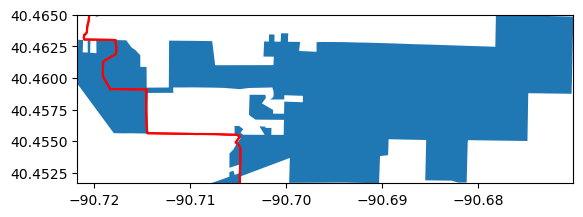

In [262]:
ax = il_2022_shps[il_2022_shps["UNIQUE_ID"].str.contains("MCDONOUGH-:-MACOMB CITY #3")].plot()
country_boundary_us = il_2022_shps[il_2022_shps["UNIQUE_ID"].str.contains("MCDONOUGH-:-MACOMB CITY #3")]
xlim = ([country_boundary_us.total_bounds[0],  country_boundary_us.total_bounds[2]])
ylim = ([country_boundary_us.total_bounds[1],  country_boundary_us.total_bounds[3]])

ax.set_xlim(xlim)
ax.set_ylim(ylim)
il_cong_dists[il_cong_dists["DISTRICT"].isin(["15","17"])].boundary.plot(ax = ax,color="red")

In [263]:
rename_dict_cong = {"MCDONOUGH-:-EMMET-(CONG-15)":"MCDONOUGH-:-EMMET-11/12",
                   "MCDONOUGH-:-EMMET-(CONG-17)":"MCDONOUGH-:-EMMET-13",
                    
                   "MCDONOUGH-:-MOUND-(CONG-15)":"MCDONOUGH-:-MOUND-34",
                   "MCDONOUGH-:-MOUND-(CONG-17)":"MCDONOUGH-:-MOUND-35",
                   "MCDONOUGH-:-SCOTLAND-(CONG-15)":"MCDONOUGH-:-SCOTLAND-40",
                   "MCDONOUGH-:-SCOTLAND-(CONG-17)":"MCDONOUGH-:-SCOTLAND-41",
                   "MCDONOUGH-:-MACOMB CITY #1-(CONG-15)":"MCDONOUGH-:-MACOMB CITY 1-18",
                   "MCDONOUGH-:-MACOMB CITY #1-(CONG-17)":"MCDONOUGH-:-MACOMB CITY 1-19",
                   "MCDONOUGH-:-MACOMB CITY #2-(CONG-15)":"MCDONOUGH-:-MACOMB CITY 2-20",
                   "MCDONOUGH-:-MACOMB CITY #2-(CONG-17)":"MCDONOUGH-:-MACOMB CITY 2-21",
                   "MCDONOUGH-:-MACOMB CITY #3-(CONG-15)":"MCDONOUGH-:-MACOMB CITY 3-22",
                   "MCDONOUGH-:-MACOMB CITY #3-(CONG-17)":"MCDONOUGH-:-MACOMB CITY 3-23",
                   "MCDONOUGH-:-MACOMB CITY 7-28/30-(CONG-15)":"MCDONOUGH-:-MACOMB CITY 7-28",
                   "MCDONOUGH-:-MACOMB CITY 7-28/30-(CONG-17)":"MCDONOUGH-:-MACOMB CITY 7-30",
                   'KANE-:-AU0009-(CONG-11)':'KANE-:-AU0009-11',
'KANE-:-AU0009-(CONG-14)':'KANE-:-AU0009-12',
'KANE-:-AU0021-(CONG-14)':'KANE-:-AU0021-25',
'KANE-:-AU0021-(CONG-11)':'KANE-:-AU0021-26',
'KANE-:-AU0050-(CONG-11)':'KANE-:-AU0050-56',
'KANE-:-AU0050-(CONG-14)':'KANE-:-AU0050-57',
'KANE-:-RU0013-(CONG-11)':'KANE-:-RU0013-314',
                    
'KANE-:-RU0013-(CONG-08)':'KANE-:-RU0013-315',
                    
'KANE-:-SC0013-(CONG-11)':'KANE-:-SC0013-331',
    
'KANE-:-SC0013-(CONG-08)':'KANE-:-SC0013-332',
'KANE-:-GE0010-253/255-(CONG-08)':'KANE-:-GE0010-253',
'KANE-:-GE0010-253/255-(CONG-11)':'KANE-:-GE0010-255',
'PEORIA-:-LI01-(CONG-17)':'PEORIA-:-LI01 - 25',
'PEORIA-:-LI01-(CONG-16)':'PEORIA-:-LI01 - 26',
'PEORIA-:-RI01-(CONG-17)':'PEORIA-:-RI01 - 172',
'PEORIA-:-RI01-(CONG-16)':'PEORIA-:-RI01 - 173',
'PEORIA-:-RO01-(CONG-17)':'PEORIA-:-RO01 - 178',
'PEORIA-:-RO01-(CONG-16)':'PEORIA-:-RO01 - 179',
                   
 'PEORIA-:-KI01 - 20/22&21/23-(CONG-16)':'PEORIA-:-KI01 - 21/23',
 'PEORIA-:-KI01 - 20/22&21/23-(CONG-17)':'PEORIA-:-KI01 - 20/22',

'PEORIA-:-LI02 - 29&30-(CONG-16)' :'PEORIA-:-LI02 - 29',
'PEORIA-:-LI02 - 29&30-(CONG-17)' :'PEORIA-:-LI02 - 30',
    'DUPAGE-:-LISLE 015-(CONG-11)':'DUPAGE-:-LISLE 015-0606',
'DUPAGE-:-LISLE 015-(CONG-06)':'DUPAGE-:-LISLE 015-0607',
'WILL-:-DU PAGE PCT 032-(CONG-11)':'WILL-:-DUPAGE PCT 032-STYLE 67',
'WILL-:-DU PAGE PCT 032-(CONG-14)':'WILL-:-DUPAGE PCT 032-STYLE 68',
'WILL-:-DU PAGE PCT 033-(CONG-11)':'WILL-:-DUPAGE PCT 033-STYLE 69/71',
'WILL-:-DU PAGE PCT 033-(CONG-14)':'WILL-:-DUPAGE PCT 033-STYLE 70/72',
'WILL-:-DU PAGE PCT 036-(CONG-11)':'WILL-:-DUPAGE PCT 036-STYLE 75',
'WILL-:-DU PAGE PCT 036-(CONG-14)':'WILL-:-DUPAGE PCT 036-STYLE 76',
'WILL-:-TROY PCT 003-(CONG-14)':'WILL-:-TROY PCT 003-STYLE 346',
'WILL-:-TROY PCT 003-(CONG-01)':'WILL-:-TROY PCT 003-STYLE 347',
'WILL-:-TROY PCT 022-(CONG-14)':'WILL-:-TROY PCT 022-STYLE 371',
'WILL-:-TROY PCT 022-(CONG-01)':'WILL-:-TROY PCT 022-STYLE 372',
'WILL-:-PEOTONE PCT 001-STYLE 284/286&285-(CONG-01)':'WILL-:-PEOTONE PCT 001-STYLE 285',
'WILL-:-PEOTONE PCT 001-STYLE 284/286&285-(CONG-02)':'WILL-:-PEOTONE PCT 001-STYLE 284/286',
'WILL-:-PEOTONE PCT 002-STYLE 288/289&292-(CONG-01)':'WILL-:-PEOTONE PCT 002-STYLE 292',
'WILL-:-PEOTONE PCT 002-STYLE 288/289&292-(CONG-02)':'WILL-:-PEOTONE PCT 002-STYLE 288/289',
'WILL-:-PEOTONE PCT 002-STYLE 290&291-(CONG-01)':'WILL-:-PEOTONE PCT 002-STYLE 290',
'WILL-:-PEOTONE PCT 002-STYLE 290&291-(CONG-02)':'WILL-:-PEOTONE PCT 002-STYLE 291'}

In [264]:
il_2022_shps["UNIQUE_ID"] = il_2022_shps["UNIQUE_ID"].map(rename_dict_cong).fillna(il_2022_shps["UNIQUE_ID"])

In [265]:
def return_splits(split_dict, level):
    for val in split_dict.keys():
        if level in val:
            return split_dict[level]

def create_splits_dict(level):
    level_splits_dict = {i:return_splits(split_precincts_list[i], level) for i in split_precincts_list.keys() if return_splits(split_precincts_list[i], level) != None }
    return level_splits_dict

In [266]:
cong_splits_dict = create_splits_dict('CON')
sldl_splits_dict = create_splits_dict('SL')
sldu_splits_dict = create_splits_dict('SU')

In [267]:
sldl_check_list.update(sldl_splits_dict)
sldu_check_list.update(sldu_splits_dict)
cong_check_list.update(cong_splits_dict)


In [268]:
## Look If Splits Are Needed

def is_split_precinct(district_assignment_list):
    c = Counter([x[0] for x in district_assignment_list])
    greater_than_one = {x:[y[1] for y in district_assignment_list if y[0]==x] for x, count in c.items() if count > 1}
    if len(greater_than_one)==0:
        return 0
    else:
        return greater_than_one
    
def get_level_dist(column_name):
    if column_name[0:4] == "GSLP":
        level = "SL"
        dist = "004"
    elif column_name[0:3] == "GSL":
        level = "SL"
        dist = column_name[3:6]
    elif column_name[0:3] == "GSU":
        level = "SU"
        dist = column_name[3:5]
    elif column_name[0:3] == "GCO":
        level = "CON"
        dist = column_name[4:6]
    else:
        print(column_name)
        raise ValueError
    return level,dist

def contains_sldl(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SL":
            return dist_tuple[1]
        
def contains_cong(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "CON":
            return dist_tuple[1]
        
def contains_sldu(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SU":
            return dist_tuple[1]

precinct_mapping_dict = {}
split_precincts_list = {}
for index,row in il_2024.iterrows():
    precinct_list = []
    for contest in race_cols:
        if(row[contest]!=0) and ("GSL" == contest[0:3] or "GCON" == contest[0:4] or "GSU" == contest[0:3]):
            precinct_info = get_level_dist(contest)
            if precinct_info not in precinct_list:
                precinct_list.append(get_level_dist(contest))
    is_split = is_split_precinct(precinct_list)
    if (is_split):
        split_precincts_list[row["UNIQUE_ID"]]=is_split
    precinct_mapping_dict[row["UNIQUE_ID"]]=precinct_list
    
sldl_check_list = {i:contains_sldl(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
cong_check_list = {i:contains_cong(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
sldu_check_list = {i:contains_sldu(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}



In [269]:
il_2024["SLDL_DIST"] = il_2024["UNIQUE_ID"].map(sldl_check_list)
il_2024["SLDU_DIST"] = il_2024["UNIQUE_ID"].map(sldu_check_list)
il_2024["CONG_DIST"] = il_2024["UNIQUE_ID"].map(cong_check_list)

## Election Results:

- Merge two Fulton Astoria Precincts

In [270]:
il_2022_shps.drop(['COUNTYFP'], axis = 1, inplace = True)

In [271]:
il_2022_shps = il_2022_shps[["UNIQUE_ID","geometry"]].copy(deep = True)

In [272]:
il_2022_shps["UNIQUE_ID"].value_counts()

UNIQUE_ID
KANE-:-GE0010-253                        1
CITY OF CHICAGO-:-WARD 45 PRECINCT 04    1
CITY OF CHICAGO-:-WARD 45 PRECINCT 17    1
CITY OF CHICAGO-:-WARD 45 PRECINCT 16    1
CITY OF CHICAGO-:-WARD 46 PRECINCT 09    1
                                        ..
MADISON-:-OLIVE 02                       1
MADISON-:-OLIVE 01                       1
MADISON-:-NEW DOUGLAS 01                 1
MADISON-:-NAMEOKI 08                     1
FULTON-:-YOUNG HICKORY-3                 1
Name: count, Length: 8657, dtype: int64

In [273]:
from shapely.geometry import Point

In [274]:
pt = Point(425500, 4.63738e+06)


 
# If gdf is in a different CRS (like EPSG:4326), reproject the point or gdf
# Example: if gdf is in EPSG:26916 (UTM zone 16N), make sure the point matches
# Otherwise, do this:
# gdf = gdf.to_crs(epsg=26916)

# Now find intersections
matches = il_2022_shps[il_2022_shps.intersects(pt)]

In [275]:
matches

,UNIQUE_ID,geometry


In [276]:
help(maup.smart_repair)

Help on function smart_repair in module maup.smart_repair:

smart_repair(geometries_df, snapped=True, snap_precision=10, fill_gaps=True, fill_gaps_threshold=0.1, disconnection_threshold=0.0001, nest_within_regions=None, min_rook_length=None)
    Repairs topology issues (overlaps, gaps, invalid polygons) in a geopandas
    GeoDataFrame or GeoSeries, with an emphasis on preserving intended adjacency
    relations between geometries as closely as possible.
    
    Specifically, the algorithm
    (1) Applies shapely.make_valid to all polygon geometries.
    (2) If snapped = True (default), snaps all polygon vertices to a grid of size no
        more than 10^(-snap_precision) times the max of width/height of the entire
        extent of the input. HIGHLY RECOMMENDED to avoid topological exceptions due to
        rounding errors.  Default value for snap_precision is 10; if topological
        exceptions still occur, try reducing snap_precision (which must be integer-
        valued) to 9 or

In [277]:
# import maup
# import warnings

# counties = gp.read_file("/Users/peterhorton/Documents/RDH/raw_data/census/2020_TIGER_CNTY/il_cnty_2020_bound/il_cnty_2020_bound.shp")
# counties = counties.to_crs(il_2022_shps.crs)
# counties = counties.to_crs(il_2022_shps.estimate_utm_crs())
# # counties = counties[counties["NAME20"]=="Montgomery"]

# warnings.filterwarnings('ignore')

# il_2022_shps = il_2022_shps.to_crs(il_2022_shps.estimate_utm_crs())

# from shapely.validation import make_valid

# # Fix invalid geometries
# il_2022_shps['geometry'] = il_2022_shps['geometry'].apply(make_valid)
# il_2022_shps['geometry'] = il_2022_shps['geometry'].buffer(0)

# il_2022_shps.reset_index(inplace = True, drop = True)

# test_final = maup.quick_repair(il_2022_shps)

# test_final.to_file("./repaired_shpsv2.shp")

In [278]:
joined = gp.GeoDataFrame(pd.merge(il_2024,il_2022_shps,on="UNIQUE_ID",how="outer",indicator=True, validate = "1:1"))

In [279]:
joined["_merge"].value_counts()

_merge
both          8657
left_only       10
right_only       0
Name: count, dtype: int64

In [280]:
contest_list = [i for i in il_2024.columns if i not in ["UNIQUE_ID","COUNTYFP","JurisName","Precinct","County",'OTH_SUM',
 'SLDL_DIST',
 'SLDU_DIST',
 'CONG_DIST']]

for contest in contest_list:
    if il_2024[contest].sum()-raw_totals[contest].sum() != 0:
        print(contest)
        print(il_2024[contest].sum()-raw_totals[contest].sum())

In [281]:
ser = il_2024.groupby("COUNTYFP")["G24PREDHAR"].sum()-raw_totals.groupby("COUNTYFP")["G24PREDHAR"].sum()

In [282]:
ser[ser!=0]

Series([], Name: G24PREDHAR, dtype: int64)

In [283]:
contest_list

['G24BI1NO',
 'G24BI1YES',
 'G24BI2NO',
 'G24BI2YES',
 'G24BI3NO',
 'G24BI3YES',
 'G24PREDHAR',
 'G24PREIKEN',
 'G24PREOWRI',
 'G24PRERTRU',
 'GCON01DJAC',
 'GCON01OWRI',
 'GCON01RLEW',
 'GCON02DKEL',
 'GCON02OWRI',
 'GCON02RRAM',
 'GCON03DRAM',
 'GCON03OWRI',
 'GCON03RBOO',
 'GCON04DGAR',
 'GCON04OWRI',
 'GCON04RCAS',
 'GCON04WHER',
 'GCON05DQUI',
 'GCON05OWRI',
 'GCON05RHAN',
 'GCON06DCAS',
 'GCON06OWRI',
 'GCON06RCON',
 'GCON07DDAV',
 'GCON07OWRI',
 'GCON07RKOP',
 'GCON08DKRI',
 'GCON08RRIC',
 'GCON09DSCH',
 'GCON09RCOH',
 'GCON10DSCH',
 'GCON10OWRI',
 'GCON10RCAR',
 'GCON11DFOS',
 'GCON11OWRI',
 'GCON11REVA',
 'GCON12DROB',
 'GCON12RBOS',
 'GCON13DBUD',
 'GCON13OWRI',
 'GCON13RLOY',
 'GCON14DUND',
 'GCON14OWRI',
 'GCON14RMAR',
 'GCON15OWRI',
 'GCON15RMIL',
 'GCON16OWRI',
 'GCON16RLAH',
 'GCON17DSOR',
 'GCON17RMCG',
 'GSC1DCUN',
 'GSC4RWHI',
 'GSL001DORT',
 'GSL002DHER',
 'GSL002RHRU',
 'GSL003DDEL',
 'GSL004DJIM',
 'GSL005DDUB',
 'GSL005RRAS',
 'GSL006DHAR',
 'GSL006RDWY',
 'GSL007

In [284]:
joined["_merge"].value_counts()

_merge
both          8657
left_only       10
right_only       0
Name: count, dtype: int64

In [285]:
to_allocate = joined[joined["_merge"]!="both"].copy(deep = True)
test_final = joined[joined["_merge"]=="both"].copy(deep = True)

In [286]:
test_final["COUNTYFP"] = test_final["COUNTYFP"].astype(float).astype(int).astype(str).str.zfill(3)

In [287]:
test_final.drop("_merge", axis = 1, inplace = True)

In [288]:
#export.to_file("./il_temp.shp")

In [289]:
def is_split_precinct(district_assignment_list):
    c = Counter([x[0] for x in district_assignment_list])
    greater_than_one = {x:[y[1] for y in district_assignment_list if y[0]==x] for x, count in c.items() if count > 1}
    if len(greater_than_one)==0:
        return 0
    else:
        return greater_than_one
    
def get_level_dist(column_name):
    if column_name[0:3] == "GSL" or column_name[0:3] == "PSL":
        level = "SL"
        dist = column_name[3:6]
    elif column_name[0:3] == "GSU" or column_name[0:3] == "PSU":
        level = "SU"
        dist = column_name[3:5]
    elif column_name[0:3] == "GCO"  or column_name[0:3] == "PCO":
        level = "CON"
        dist = column_name[4:6]
    else:
        print(column_name)
        raise ValueError
    return level,dist

def contains_sldl(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SL":
            return dist_tuple[1]
        
def contains_cong(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "CON":
            return dist_tuple[1]
        
def contains_sldu(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SU":
            return dist_tuple[1]

precinct_mapping_dict = {}
split_precincts_list = {}
for index,row in test_final.iterrows():
    precinct_list = []
    for contest in contest_list:
        if(row[contest]!=0) and ("GSL" in contest or "GCO" in contest or "GSU" in contest or "PCO" in contest or "PSU" in contest or "PSL" in contest):
            precinct_info = get_level_dist(contest)
            if precinct_info not in precinct_list:
                precinct_list.append(get_level_dist(contest))
    is_split = is_split_precinct(precinct_list)
    if (is_split):
        split_precincts_list[row["UNIQUE_ID"]]=is_split
    precinct_mapping_dict[row["UNIQUE_ID"]]=precinct_list
    
cong_check_list = {i:contains_cong(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
sldu_check_list = {i:contains_sldu(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
sldl_check_list = {i:contains_sldl(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}


In [290]:
def return_splits(split_dict, level):
    for val in split_dict.keys():
        if level in val:
            return split_dict[level]

def create_splits_dict(level):
    level_splits_dict = {i:return_splits(split_precincts_list[i], level) for i in split_precincts_list.keys() if return_splits(split_precincts_list[i], level) != None }
    return level_splits_dict

cong_splits_dict = create_splits_dict('CON')
sldl_splits_dict = create_splits_dict('SL')
sldu_splits_dict = create_splits_dict('SU')


In [291]:
test_final["COUNTYFP"] = test_final["COUNTYFP"].astype(float).astype(int).astype(str).str.zfill(3)

In [292]:
test_final.columns

Index(['UNIQUE_ID', 'COUNTYFP', 'JurisName', 'Precinct', 'County', 'G24BI1NO',
       'G24BI1YES', 'G24BI2NO', 'G24BI2YES', 'G24BI3NO',
       ...
       'GSU52DFAR', 'GSU52RBRO', 'GSU53RBAL', 'GSU55RPLU', 'GSU58RBRY',
       'OTH_SUM', 'SLDL_DIST', 'SLDU_DIST', 'CONG_DIST', 'geometry'],
      dtype='object', length=287)

## Allocate Votes

In [293]:
to_allocate

,UNIQUE_ID,COUNTYFP,JurisName,Precinct,County,G24BI1NO,G24BI1YES,G24BI2NO,G24BI2YES,G24BI3NO,...,GSU52RBRO,GSU53RBAL,GSU55RPLU,GSU58RBRY,OTH_SUM,SLDL_DIST,SLDU_DIST,CONG_DIST,geometry,_merge
141,BOONE-:-PRESIDENT ONLY,7,BOONE,PRESIDENT ONLY,BOONE,0,0,0,0,0,...,0,0,0,0,0,None,None,None,None,left_only
220,CARROLL-:-PRESIDENTIAL BALLOT ONLY,15,CARROLL,PRESIDENTIAL BALLOT ONLY,CARROLL,0,0,0,0,0,...,0,0,0,0,0,None,None,None,None,left_only
3822,DUPAGE-:-FEDERAL-F03,43,DuPAGE,FEDERAL-F03,DuPAGE,0,0,0,0,0,...,0,0,0,0,0,None,None,03,None,left_only
3823,DUPAGE-:-FEDERAL-F04,43,DuPAGE,FEDERAL-F04,DuPAGE,0,0,0,0,0,...,0,0,0,0,0,None,None,04,None,left_only
3824,DUPAGE-:-FEDERAL-F06,43,DuPAGE,FEDERAL-F06,DuPAGE,0,0,0,0,0,...,0,0,0,0,0,None,None,06,None,left_only
3825,DUPAGE-:-FEDERAL-F08,43,DuPAGE,FEDERAL-F08,DuPAGE,0,0,0,0,0,...,0,0,0,0,0,None,None,08,None,left_only
3826,DUPAGE-:-FEDERAL-F11,43,DuPAGE,FEDERAL-F11,DuPAGE,0,0,0,0,0,...,0,0,0,0,0,None,None,11,None,left_only
6044,MACON-:-PRESIDENTIAL ONLY BALLOT,115,MACON,PRESIDENTIAL ONLY BALLOT,MACON,0,0,0,0,0,...,0,0,0,0,0,None,None,None,None,left_only
6749,MERCER-:-PRESIDENTIAL ONLY BALLOT,131,MERCER,PRESIDENTIAL ONLY BALLOT,MERCER,0,0,0,0,0,...,0,0,0,0,0,None,None,None,None,left_only
7842,TAZEWELL-:-PRESIDENTIAL ONLY BALLOT,179,TAZEWELL,PRESIDENTIAL ONLY BALLOT,TAZEWELL,0,0,0,0,0,...,0,0,0,0,0,None,None,None,None,left_only


In [294]:
test_final["Allocate_Column"] = test_final['County']
to_allocate["Allocate_Column"] = to_allocate['County']

In [295]:
test_final.loc[test_final["County"]=="DuPAGE","Allocate_Column"] = test_final.loc[test_final["County"]=="DuPAGE","CONG_DIST"]


In [296]:
to_allocate.loc[to_allocate["County"]=="DuPAGE","Allocate_Column"] = to_allocate.loc[to_allocate["County"]=="DuPAGE","Precinct"].str[-2:]

In [297]:
import pber_functions_v1 as pber 

In [298]:
test_final = pber.allocate_absentee(test_final, to_allocate, contest_list, "Allocate_Column", allocating_to_all_empty_precs=False)

In [299]:
test_final.drop([ 'OTH_SUM', 'SLDL_DIST', 'SLDU_DIST', 'CONG_DIST','Allocate_Column'], axis = 1, inplace = True)

In [300]:
keep_names = ["UNIQUE_ID","COUNTYFP","JurisName","Precinct","County"]

#keep_names = ["UNIQUE_ID","geometry","COUNTYFP","county","precinct"]
st_columns = [i for i in test_final.columns if i not in keep_names and "GCON" not in i and "GSL" not in i and 'GSU' not in i]
cong_columns = [i for i in test_final.columns if i not in keep_names and "GCON" in i]
sldl_columns = [i for i in test_final.columns if i not in keep_names and "GSL" in i]
sldu_columns = [i for i in test_final.columns if i not in keep_names and "GSU" in i]

il_elec_prec_pre_splits = test_final.copy(deep = True)
il_24_cong_prec = gp.GeoDataFrame(test_final[keep_names + cong_columns + ["geometry"]].copy(deep = True))
il_24_sldl_prec = gp.GeoDataFrame(test_final[keep_names + sldl_columns + ["geometry"]].copy(deep = True))
il_24_sldu_prec = gp.GeoDataFrame(test_final[keep_names + sldu_columns + ["geometry"]].copy(deep = True))

# Make the Needed Splits

il_24_cong_prec["CONG_DIST"] = il_24_cong_prec["UNIQUE_ID"].map(cong_check_list)
il_24_sldl_prec["SLDL_DIST"] = il_24_sldl_prec["UNIQUE_ID"].map(sldl_check_list)
il_24_sldu_prec["SLDU_DIST"] = il_24_sldu_prec["UNIQUE_ID"].map(sldu_check_list)






In [301]:
def return_splits(split_dict, level):
    for val in split_dict.keys():
        if level in val:
            return split_dict[level]

def create_splits_dict(level):
    level_splits_dict = {i:return_splits(split_precincts_list[i], level) for i in split_precincts_list.keys() if return_splits(split_precincts_list[i], level) != None }
    return level_splits_dict

# Load in CONG and SLDL shapefiles
il_cong_districts = gp.read_file("/Users/peterhorton/Documents/RDH/raw_data/cong/national_cong119_boundary/national_cong119_boundary/national_cong119_boundary.shp")
il_sldl_districts = gp.read_file("/Users/peterhorton/Documents/RDH/raw_data/state_leg/national_2024_elections_st_leg_boundaries/national_2024_elections_st_leg_lower_boundaries/national_2024_elections_st_leg_lower_boundaries.shp")
il_sldu_districts = gp.read_file("/Users/peterhorton/Documents/RDH/raw_data/state_leg/national_2024_elections_st_leg_boundaries/national_2024_elections_st_leg_upper_boundaries/national_2024_elections_st_leg_upper_boundaries.shp")

il_cong_districts = il_cong_districts.to_crs(test_final.crs)
il_sldl_districts = il_sldl_districts.to_crs(test_final.crs)
il_sldu_districts = il_sldu_districts.to_crs(test_final.crs)

il_cong_districts = il_cong_districts[il_cong_districts["STATE"]=="IL"]
il_sldl_districts = il_sldl_districts[il_sldl_districts["STATE"]=="IL"]
il_sldu_districts = il_sldu_districts[il_sldu_districts["STATE"]=="IL"]

cong_splits_dict = create_splits_dict('CON')
sldl_splits_dict = create_splits_dict('SL')
sldu_splits_dict = create_splits_dict('SU')

In [302]:
il_24_sldl_prec, sldl_diff = pber.district_splits_comb("SLDL", list(sldl_splits_dict.keys()), il_24_sldl_prec, il_sldl_districts, "UNIQUE_ID", "DISTRICT", sldl_columns, "SLDL_DIST", sldl_splits_dict, fill_level = 3, remove_zero_vote_precs = True)
il_24_sldu_prec, sldu_diff = pber.district_splits_comb("SLDU", list(sldu_splits_dict.keys()), il_24_sldu_prec, il_sldu_districts, "UNIQUE_ID", "DISTRICT", sldu_columns, "SLDU_DIST", sldu_splits_dict, remove_zero_vote_precs = True)
il_24_cong_prec, cong_diff = pber.district_splits_comb("CONG", list(cong_splits_dict.keys()), il_24_cong_prec, il_cong_districts, "UNIQUE_ID", "DISTRICT", cong_columns, "CONG_DIST", cong_splits_dict, remove_zero_vote_precs = True)
print(sldl_diff)
print(sldu_diff)
print(cong_diff)






                          GSL069DJAN  GSL069RSOS  GSL087IGIL  GSL087RHAU  \
UNIQUE_ID                                                                  
MACON-:-AUSTIN                     0           0           0           0   
MACON-:-MAROA                      0           0           0           0   
MCLEAN-:-NORMAL 12                 0           0           0           0   
ST. CLAIR-:-CASEYVILLE 8           0           0           0           0   
ST. CLAIR-:-O FALLON 5             0           0           0           0   
TAZEWELL-:-CINCINNATI 3            0           0           1           1   
TAZEWELL-:-GROVELAND 6             0           0           0           0   
WINNEBAGO-:-ROCKFORD 8             2           2           0           0   

                          GSL091RAND  GSL096DSCH  GSL096RSMI  GSL105RTIP  \
UNIQUE_ID                                                                  
MACON-:-AUSTIN                     0           0           4           0   
MACON-:-MAR

In [314]:
MACON-:-MAROA, ST. CLAIR-:-O FALLON 5, MACON-:-AUSTIN,
       ST. CLAIR-:-CASEYVILLE 8, WINNEBAGO-:-ROCKFORD 8,
       TAZEWELL-:-CINCINNATI 3, MCLEAN-:-NORMAL 12,
       TAZEWELL-:-GROVELAND 6

Index(['MACON-:-MAROA', 'ST. CLAIR-:-O FALLON 5', 'MACON-:-AUSTIN',
       'ST. CLAIR-:-CASEYVILLE 8', 'WINNEBAGO-:-ROCKFORD 8',
       'TAZEWELL-:-CINCINNATI 3', 'MCLEAN-:-NORMAL 12',
       'TAZEWELL-:-GROVELAND 6'],
      dtype='object', name='UNIQUE_ID')

In [303]:
if cong_diff.shape[0] > 0:
    cong_diff.sort_values("Tot_Votes", inplace = True, ascending = False)
    cong_diff.to_csv("./lost_cong_votes.csv")
    
if sldl_diff.shape[0] > 0:
    sldl_diff.sort_values("Tot_Votes", inplace = True, ascending = False)
    sldl_diff.to_csv("./lost_sldl_votes.csv")
    
if sldu_diff.shape[0] > 0:
    sldu_diff.sort_values("Tot_Votes", inplace = True, ascending = False)
    sldu_diff.to_csv("./lost_sldu_votes.csv")



## If needed: clean n/a district assignments

print(il_24_cong_prec[il_24_cong_prec["CONG_DIST"].isna()].shape[0])
print(il_24_sldl_prec[il_24_sldl_prec["SLDL_DIST"].isna()].shape[0])
print(il_24_sldu_prec[il_24_sldu_prec["SLDU_DIST"].isna()].shape[0])


0
0
5232


In [304]:
def merge_geometries(gdf, idx1, idx2):
    combined_geom = unary_union([gdf.loc[idx1, 'geometry'], gdf.loc[idx2, 'geometry']])
    gdf.at[idx1, 'geometry'] = combined_geom
    gdf = gdf.drop(index=idx2).reset_index(drop=True)
    return gdf

In [305]:
def clean_na_dist_assignments(elections_gdf, district_gdf, unique_ID_col, elections_gdf_dist_ID, district_gdf_ID, ):
    
    if elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()].shape[0]==0:
        return elections_gdf
    
    else:
        print("Fixing ",elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()].shape[0], "precincts")
    
    original_crs = elections_gdf.crs
    elections_gdf = elections_gdf.to_crs(3857)
    
    district_gdf = district_gdf.to_crs(3857)
    
    dist_clean = gp.overlay(elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()], district_gdf, how = "intersection")

    dist_clean['area'] = dist_clean.area

    na_assignment_dict = {}

    for val in dist_clean[unique_ID_col].unique():

        assignment = dist_clean.loc[dist_clean[unique_ID_col] == val].nlargest(1, 'area')[district_gdf_ID].values[0]
        na_assignment_dict[val] = assignment

    elections_gdf[elections_gdf_dist_ID] = elections_gdf[unique_ID_col].map(na_assignment_dict).fillna(elections_gdf[elections_gdf_dist_ID])    

    elections_gdf = elections_gdf.to_crs(original_crs)
    
    return elections_gdf


# # Clean na district assignments
il_24_sldu_prec = clean_na_dist_assignments(il_24_sldu_prec, il_sldu_districts, "UNIQUE_ID", "SLDU_DIST", "DISTRICT")
il_24_sldl_prec = clean_na_dist_assignments(il_24_sldl_prec, il_sldl_districts, "UNIQUE_ID", "SLDL_DIST", "DISTRICT")
il_24_cong_prec = clean_na_dist_assignments(il_24_cong_prec, il_cong_districts, "UNIQUE_ID", "CONG_DIST", "DISTRICT")

Fixing  5232 precincts


Checking 17 districts for differences of greater than 0.1 km^2

1) For 01 difference in area is 3.016922070089066
2) For 02 difference in area is 2.8618255483124773
3) For 03 difference in area is 0.6841850417304897
4) For 04 difference in area is 0.6297380425911281
5) For 05 difference in area is 4.708118285403197
6) For 06 difference in area is 0.7782406807678549
7) For 07 difference in area is 0.3282342137023932
8) For 08 difference in area is 6.021096670753464
9) For 09 difference in area is 0.1984903382537132
10) For 10 difference in area is 0.21504449867034922
11) For 11 difference in area is 0.5276105138630514
12) For 12 difference in area is 4.154848304063074
13) For 13 difference in area is 1.9610747040992578
14) For 14 difference in area is 2.3049828186689756
15) For 15 difference in area is 3.8024987484922574
16) For 16 difference in area is 5.6550957024586115
17) For 17 difference in area is 2.480037099728486

Scroll down to see plots of any differences

Of the 17 districts

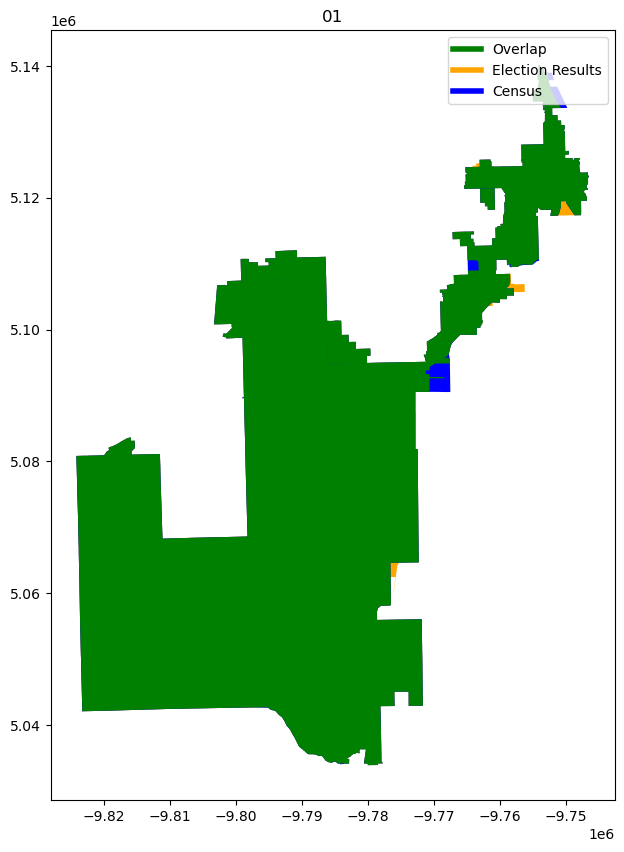

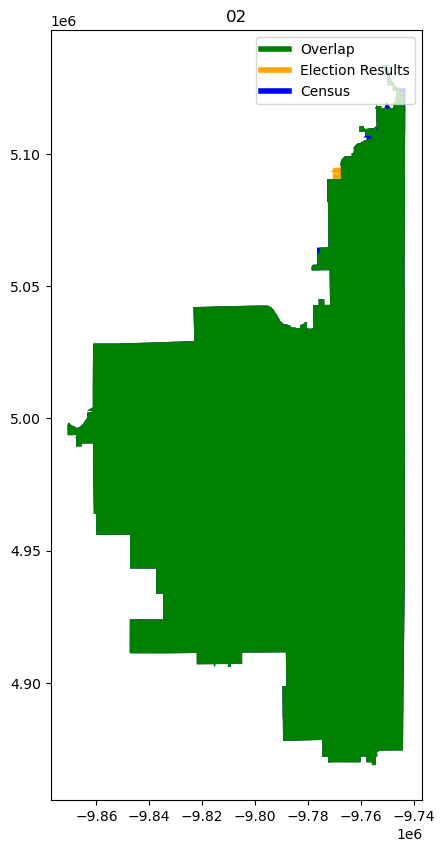

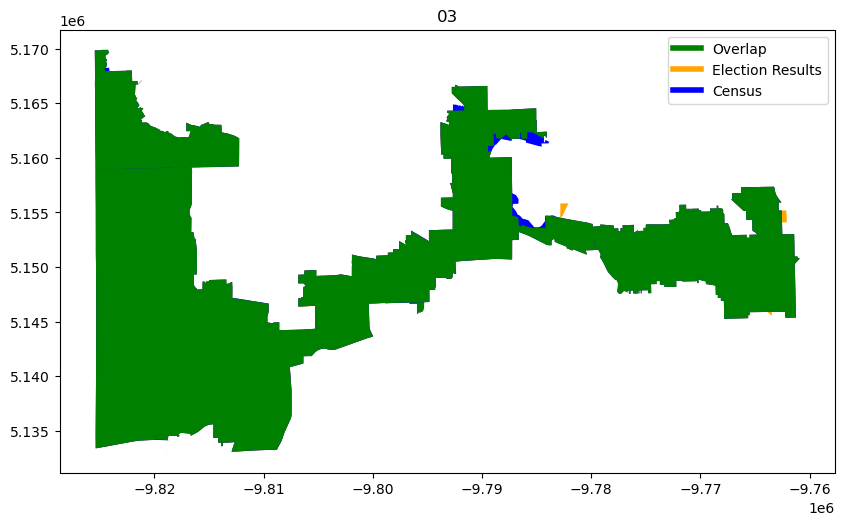

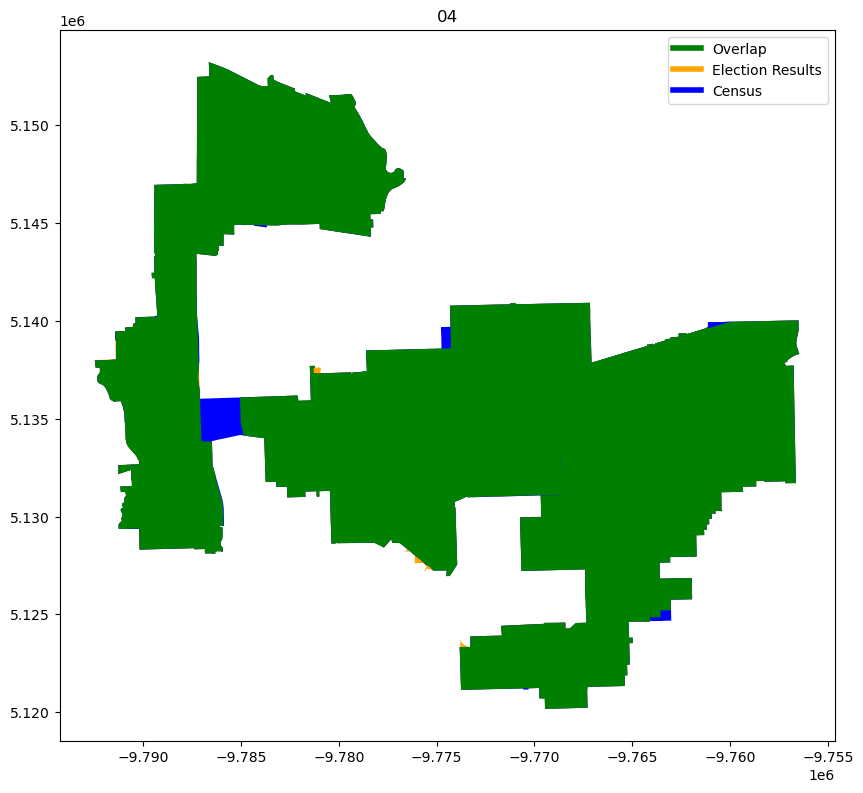

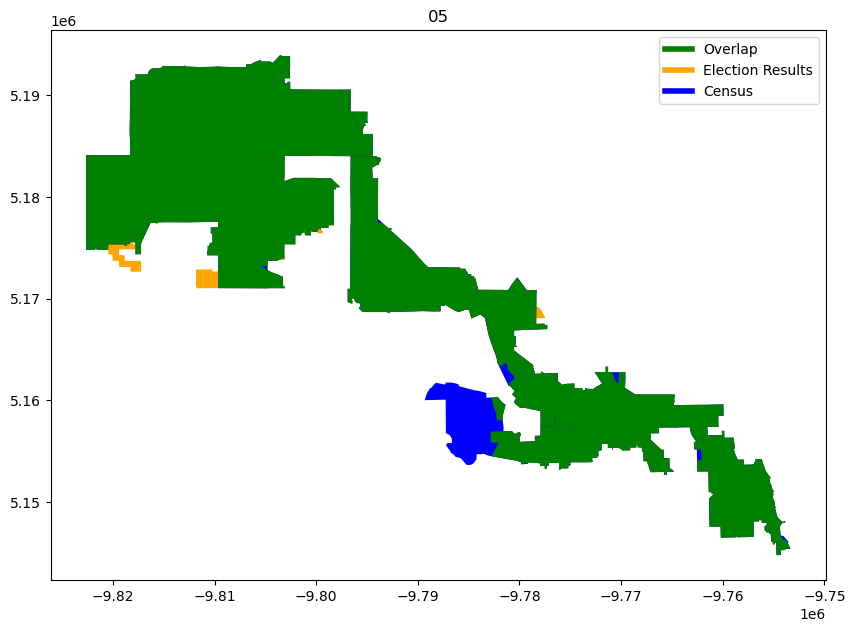

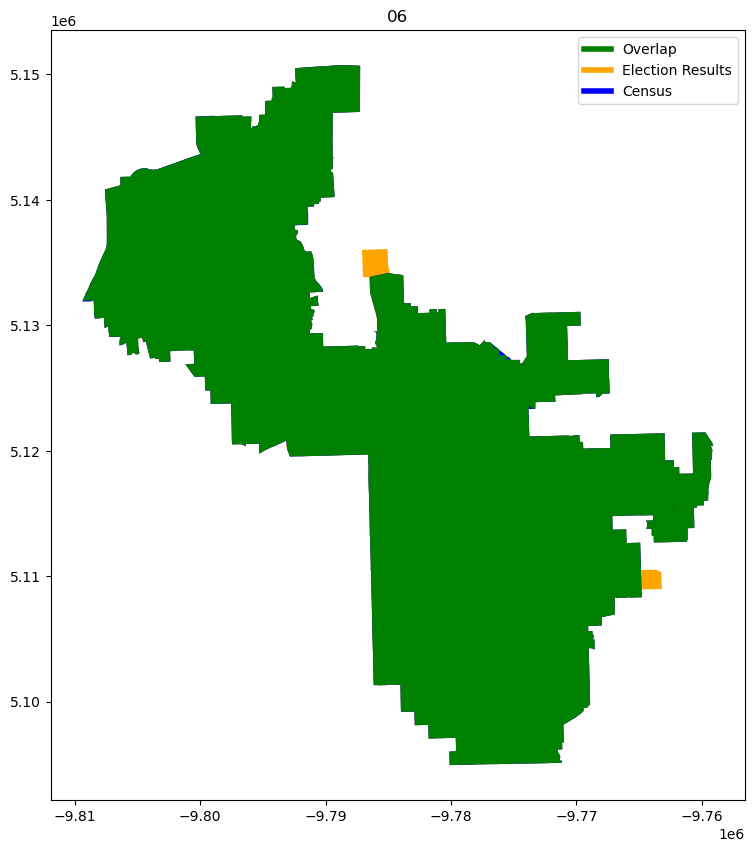

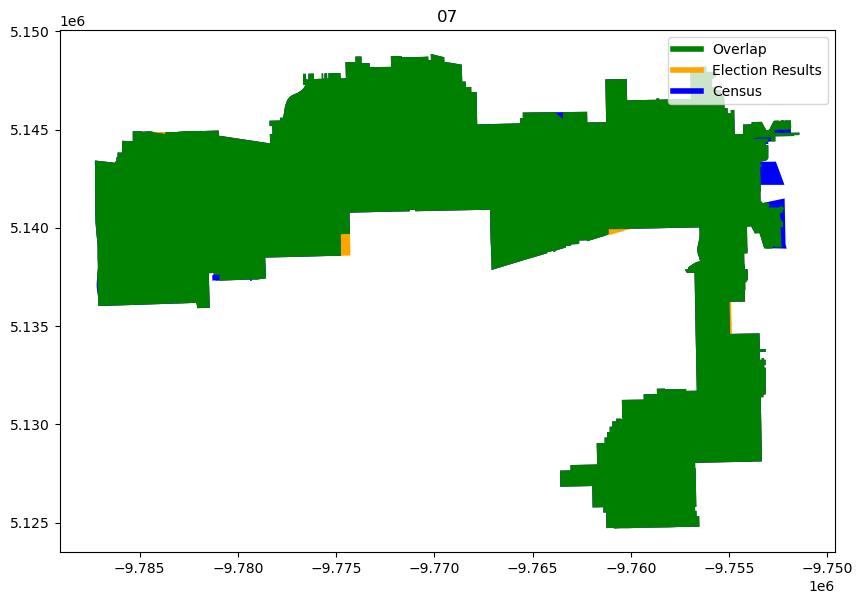

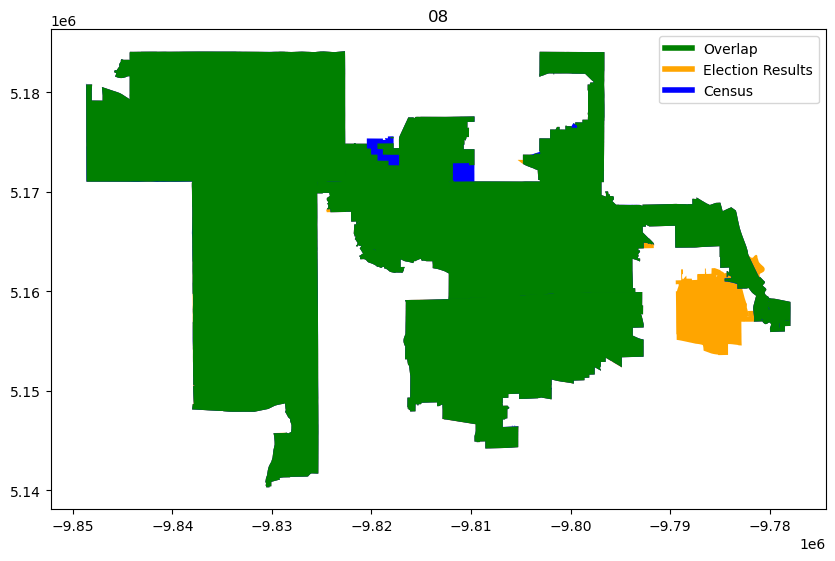

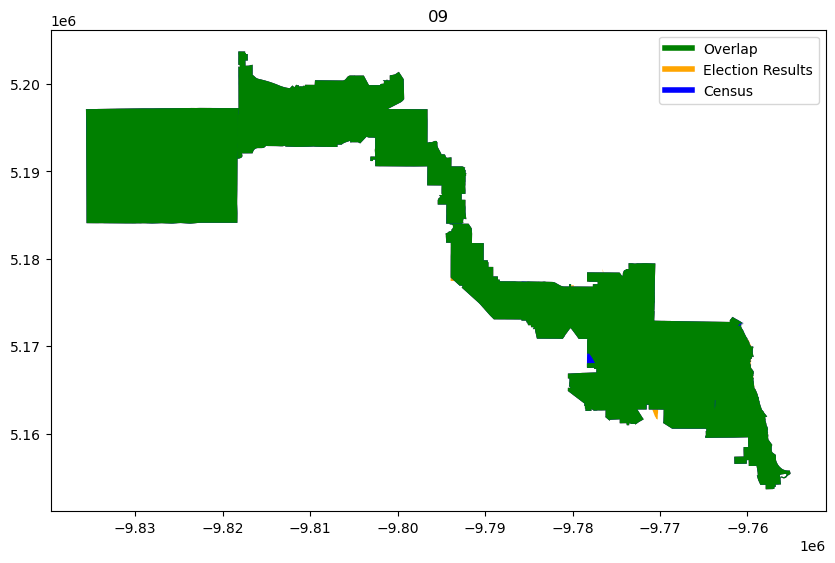

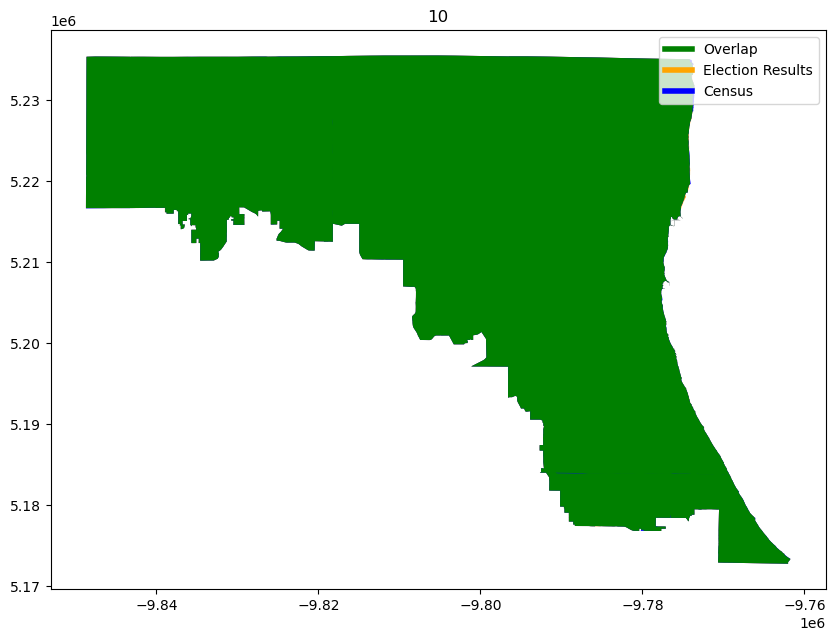

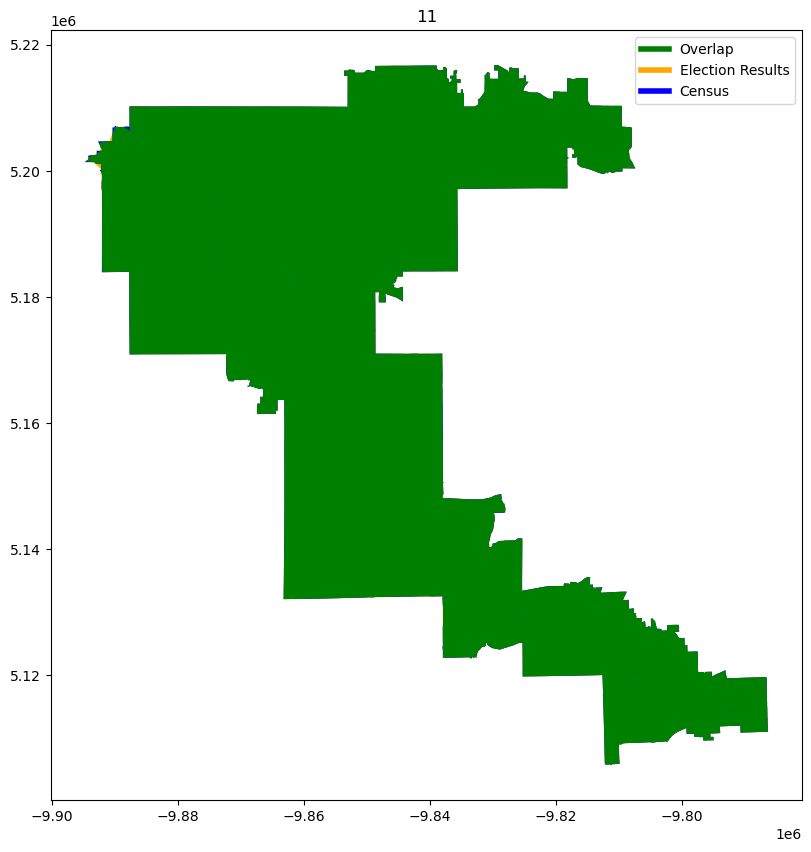

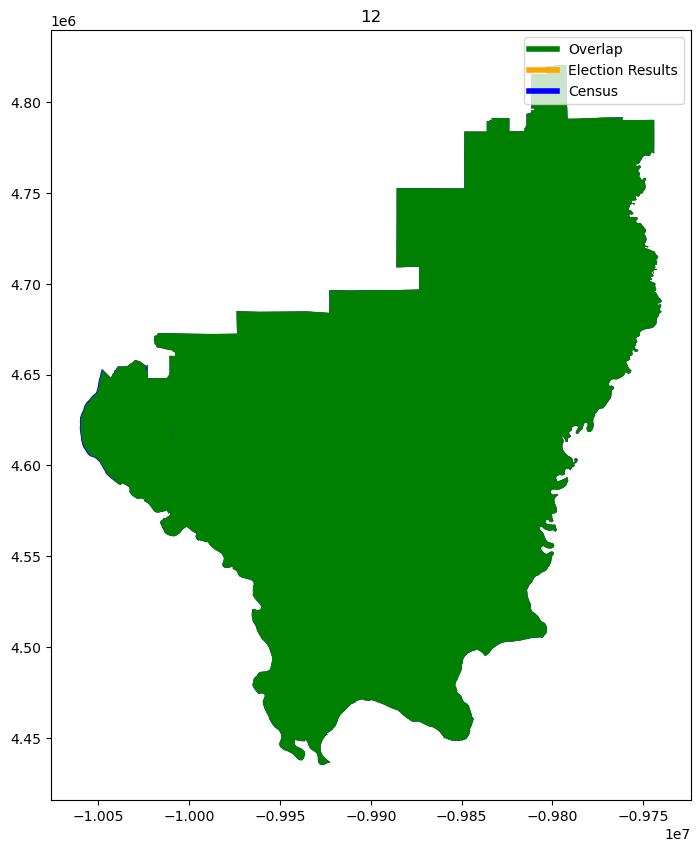

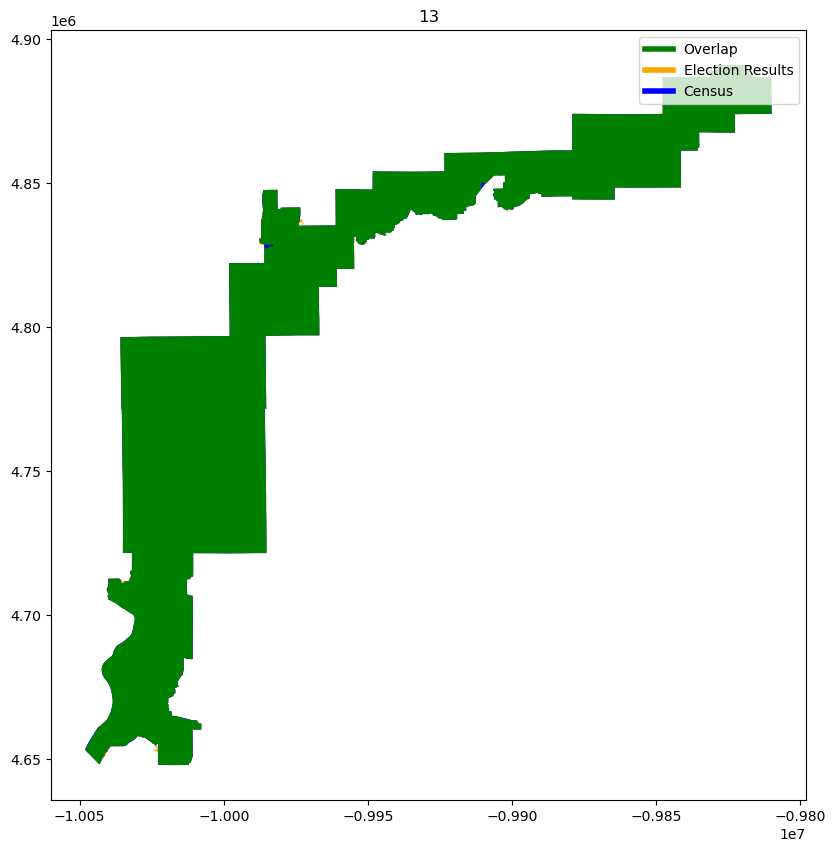

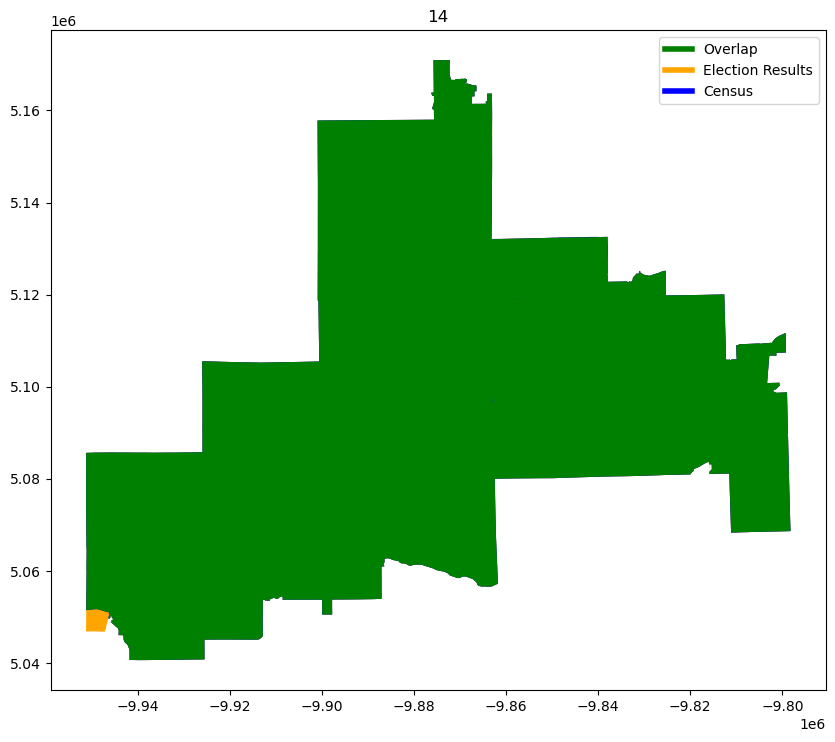

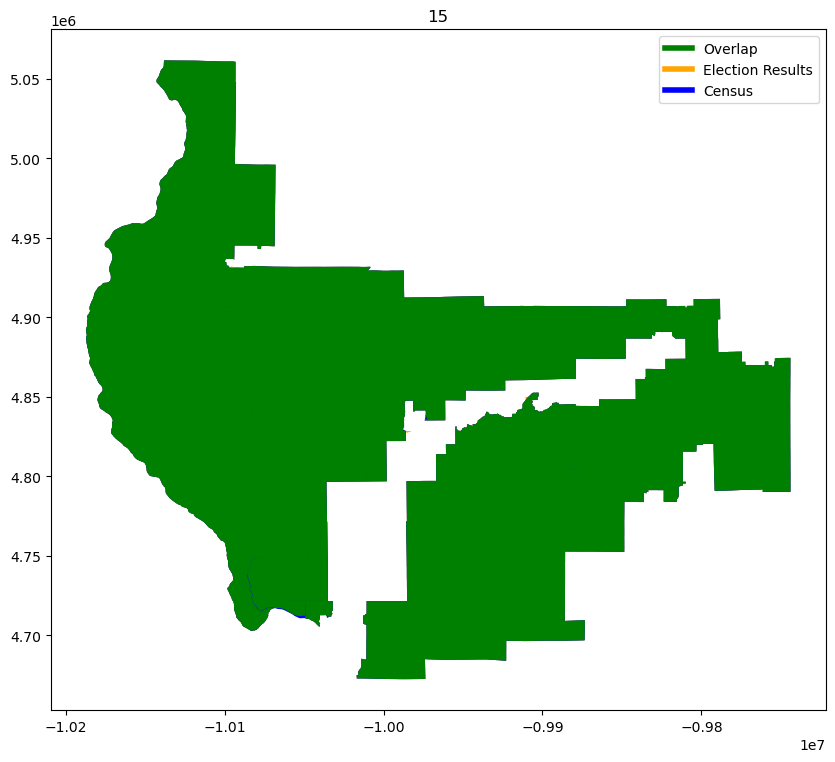

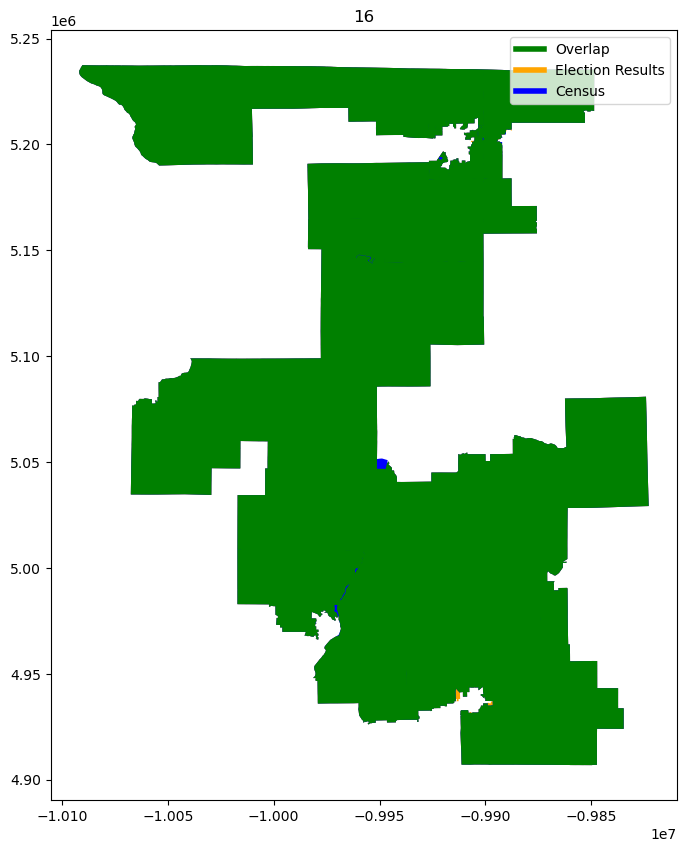

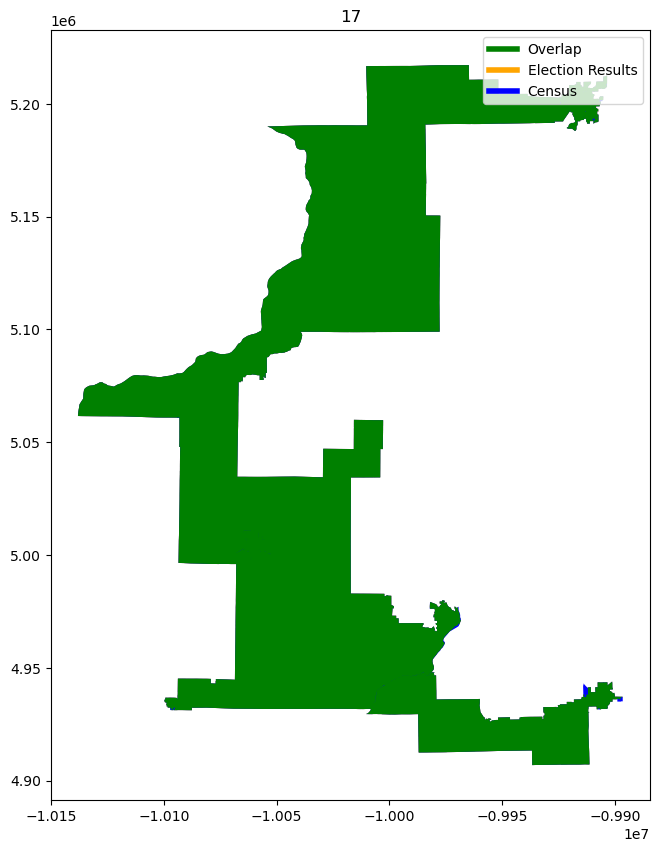

In [306]:


## Check Assignments

il_24_sldl_prec["SLDL_DIST"] = il_24_sldl_prec["SLDL_DIST"].astype(int).astype(str).str.zfill(3)
il_24_sldu_prec["SLDU_DIST"] = il_24_sldu_prec["SLDU_DIST"].astype(int).astype(str).str.zfill(2)
il_24_cong_prec["CONG_DIST"] = il_24_cong_prec["CONG_DIST"].astype(int).astype(str).str.zfill(2)



il_cong_districts.rename(columns = {"DISTRICT":"CONG_DIST"}, inplace = True)
il_sldl_districts.rename(columns = {"DISTRICT":"SLDL_DIST"}, inplace = True)
il_sldu_districts.rename(columns = {"DISTRICT":"SLDU_DIST"}, inplace = True)

il_sldl_districts["SLDL_DIST"] = il_sldl_districts["SLDL_DIST"].astype(int).astype(str).str.zfill(3)
il_sldu_districts["SLDU_DIST"] = il_sldu_districts["SLDU_DIST"].astype(int).astype(str).str.zfill(2)
il_cong_districts["CONG_DIST"] = il_cong_districts["CONG_DIST"].astype(int).astype(str).str.zfill(2)

filtered_cong_results = il_24_cong_prec[il_24_cong_prec["CONG_DIST"]!="n/a"].dissolve("CONG_DIST")
filtered_cong_results.reset_index(inplace=True, drop=False)

filtered_sldl_results = il_24_sldl_prec[il_24_sldl_prec["SLDL_DIST"]!="n/a"].dissolve("SLDL_DIST")
filtered_sldl_results.reset_index(inplace=True, drop=False)

filtered_sldu_results = il_24_sldu_prec[il_24_sldu_prec["SLDU_DIST"]!="n/a"].dissolve("SLDU_DIST")
filtered_sldu_results.reset_index(inplace=True, drop=False)


pber.compare_geometries(filtered_cong_results, il_cong_districts ,"Election Results", "Census", "CONG_DIST","districts",area_threshold=.1)





for col in sldl_columns:
    il_24_sldl_prec[col] = il_24_sldl_prec[col].astype(int)
    
for col in cong_columns:
    il_24_cong_prec[col] = il_24_cong_prec[col].astype(int)
    
for col in sldu_columns:
    il_24_sldu_prec[col] = il_24_sldu_prec[col].astype(int)
    

import os



Checking 118 districts for differences of greater than 1 km^2

1) For 002 difference in area is 1.1368092785663304
2) For 020 difference in area is 4.926159986314792
3) For 021 difference in area is 1.2196578542019092
4) For 025 difference in area is 1.2601884791502092
5) For 026 difference in area is 1.0469784618009836
6) For 029 difference in area is 1.5782220190706693
7) For 033 difference in area is 1.0456975030664593
8) For 059 difference in area is 1.0636436508984495
9) For 060 difference in area is 1.0978234429005616
10) For 077 difference in area is 4.564218476015787
11) For 080 difference in area is 1.3109556324638028
12) For 087 difference in area is 3.4804940989900133
13) For 088 difference in area is 3.6100093301437544
14) For 091 difference in area is 2.2522668402757873
15) For 092 difference in area is 1.520916358435014
16) For 099 difference in area is 8.591249213462845
17) For 100 difference in area is 11.270514213997036
18) For 115 difference in area is 11.027589830898

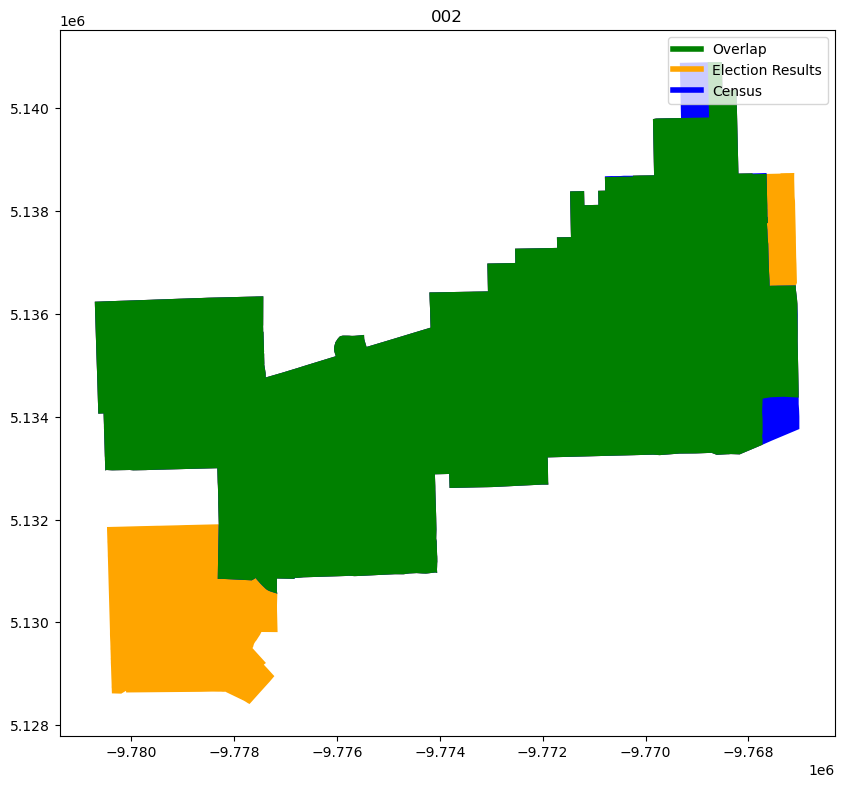

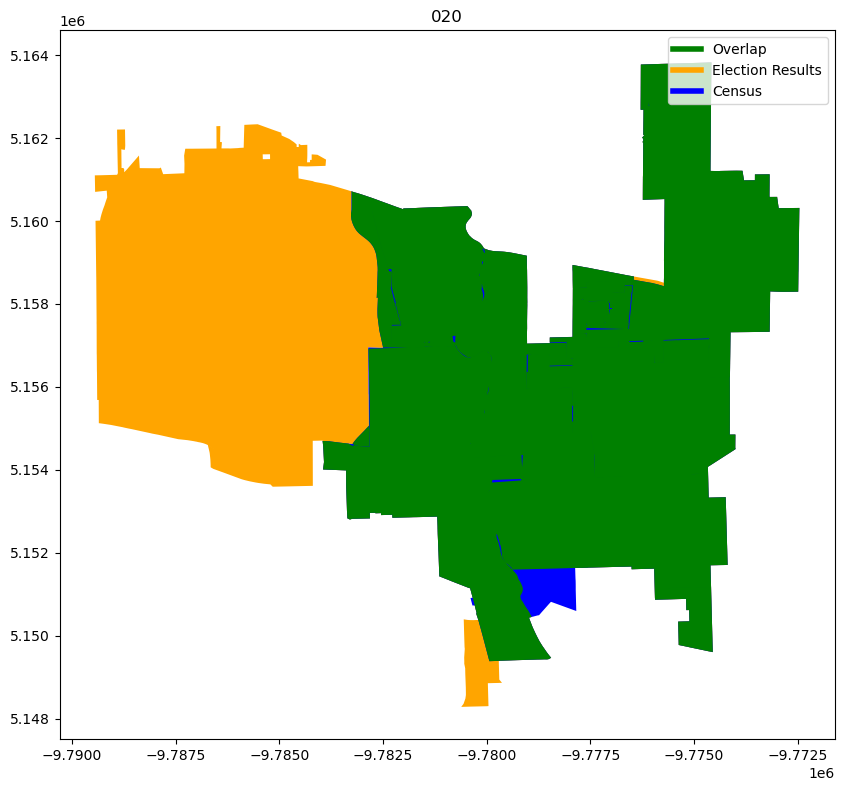

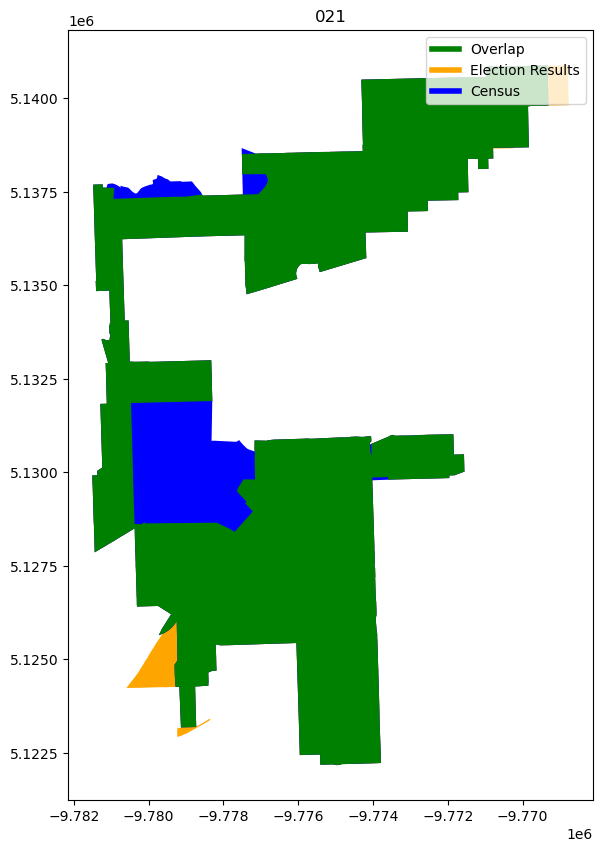

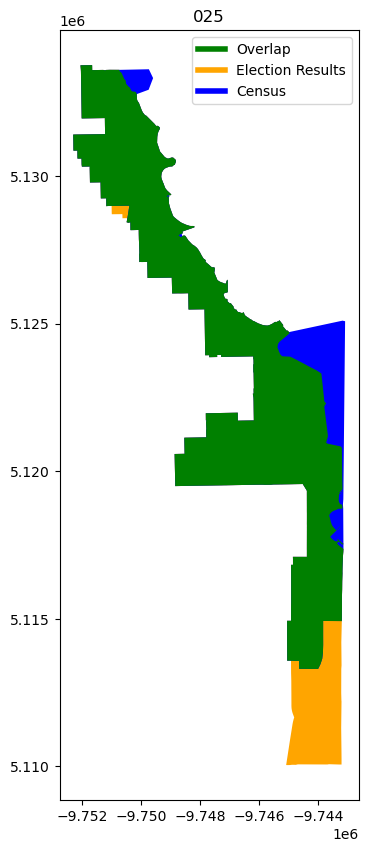

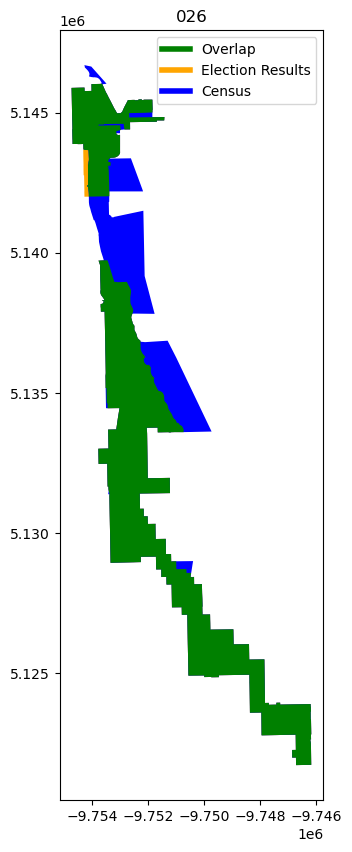

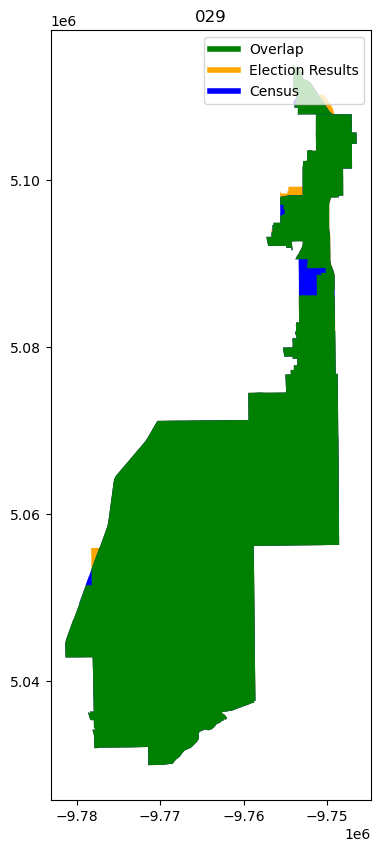

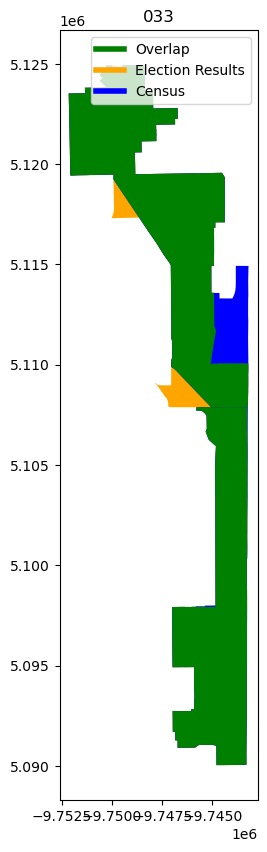

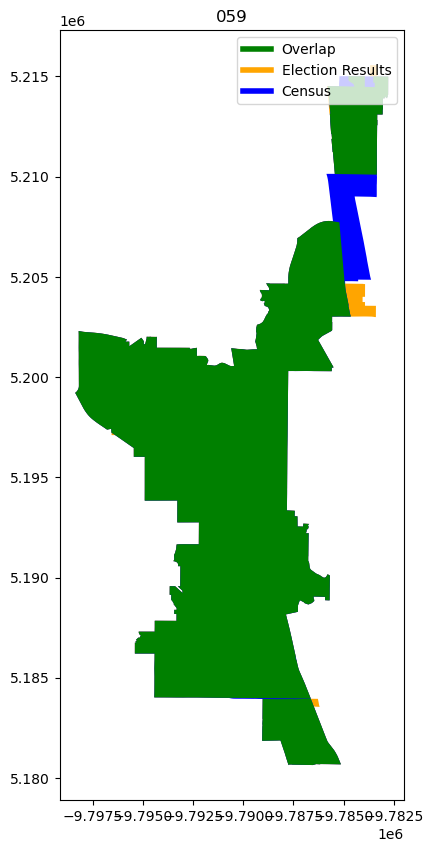

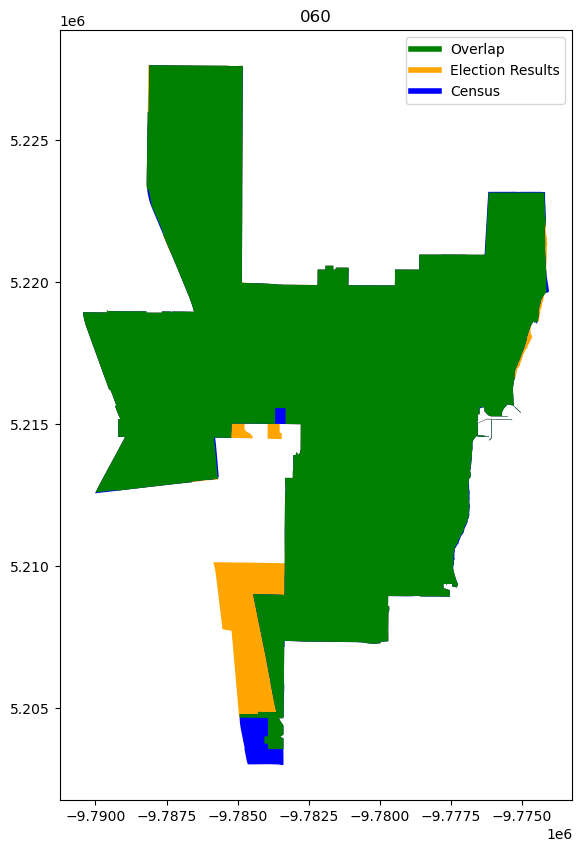

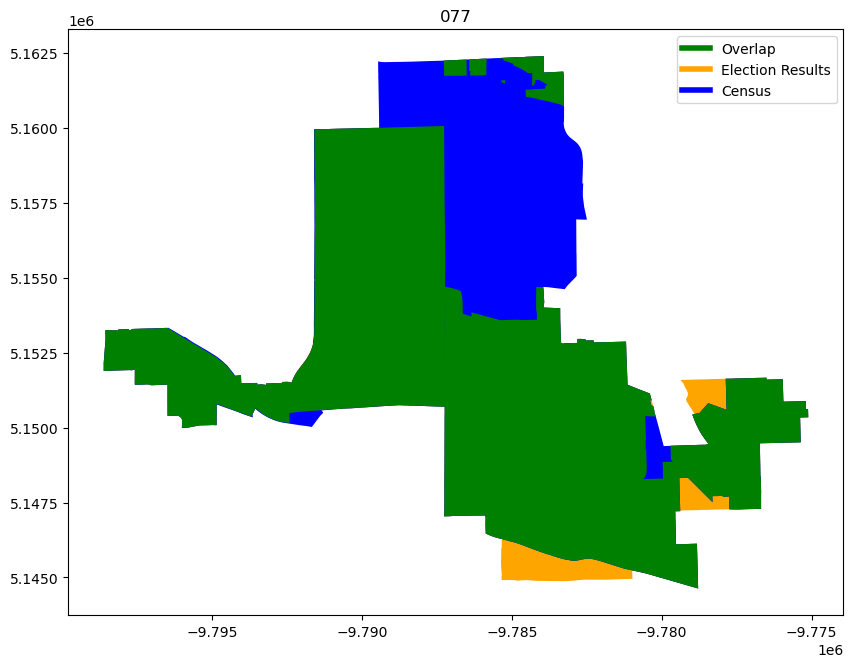

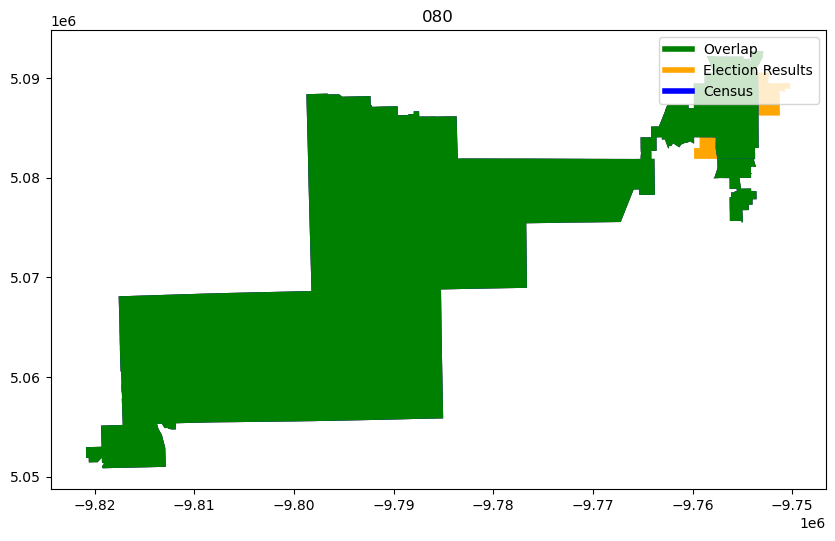

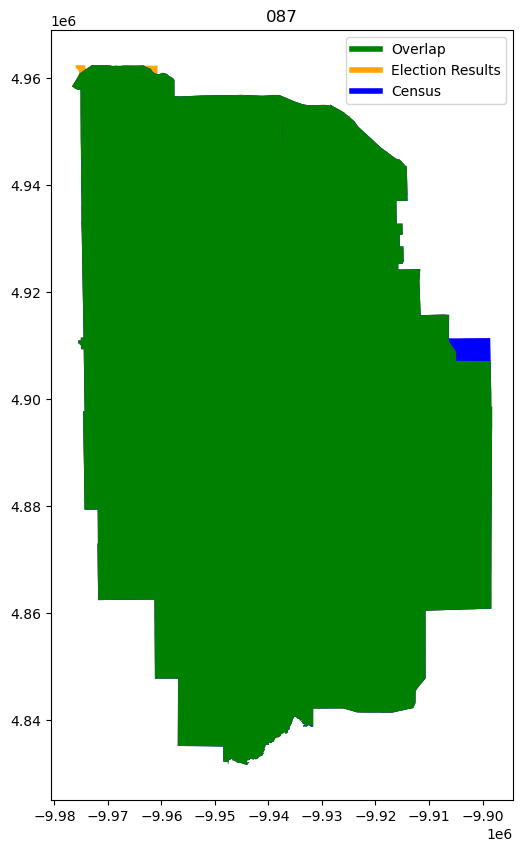

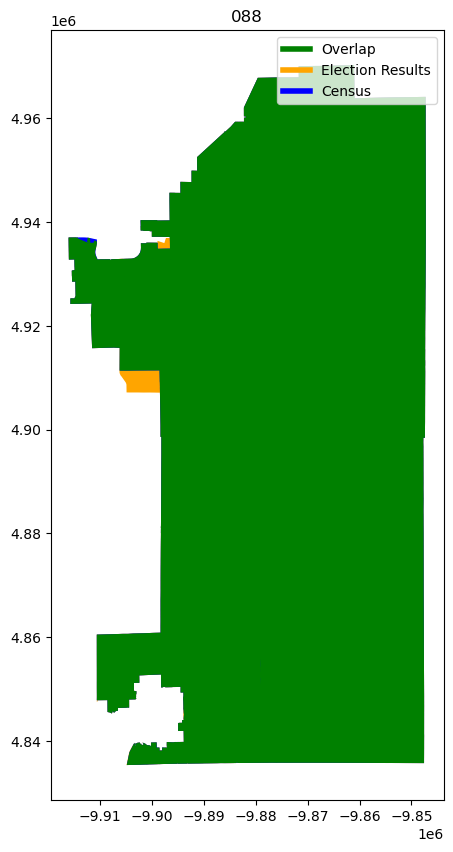

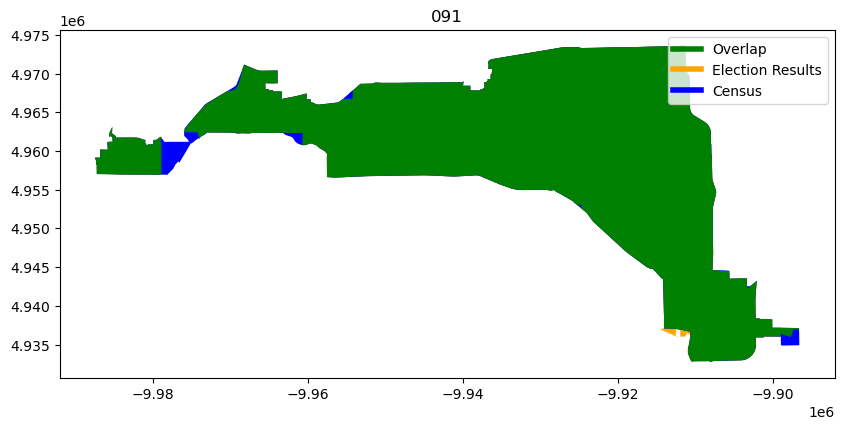

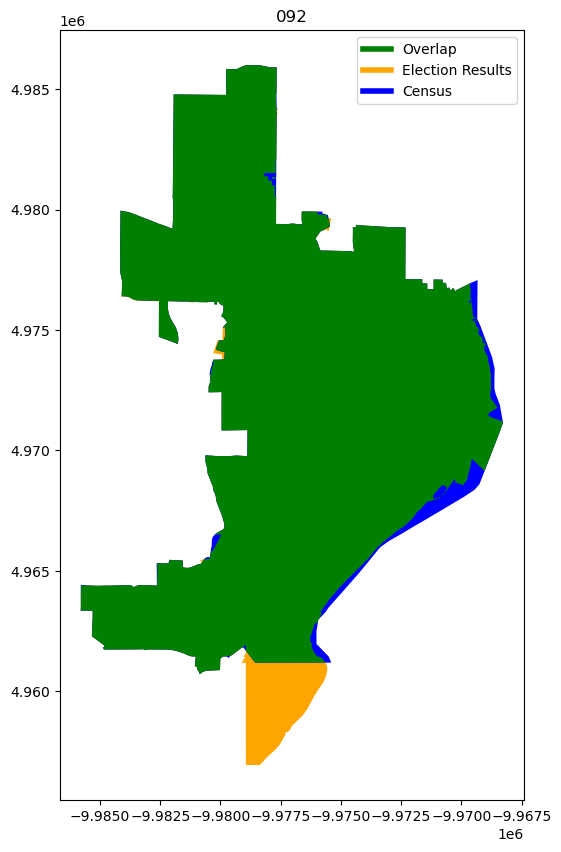

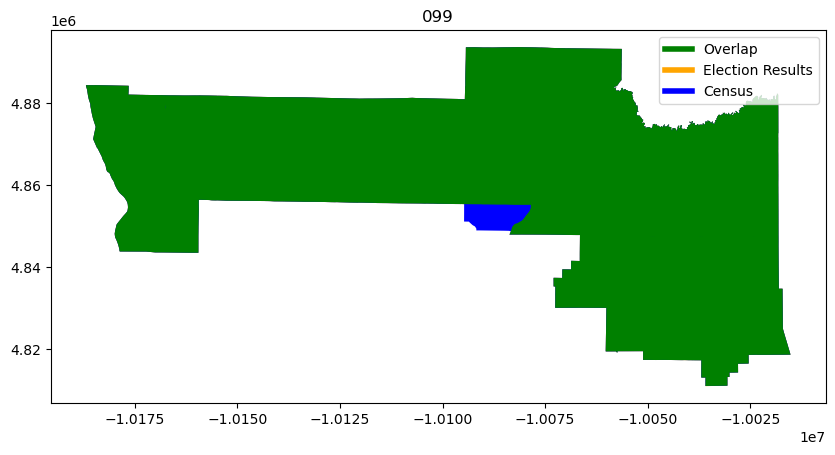

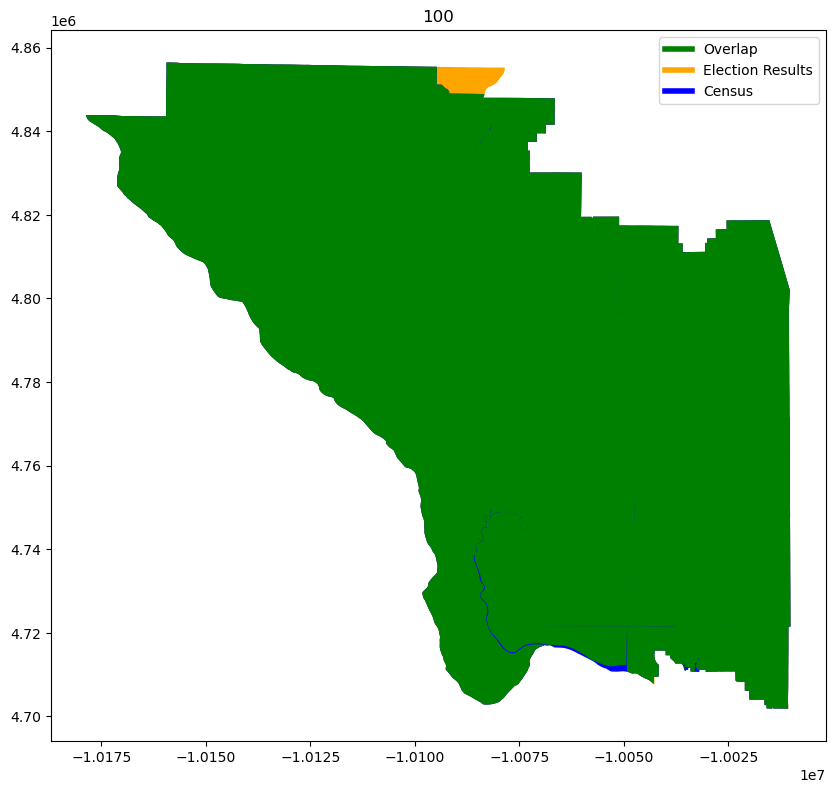

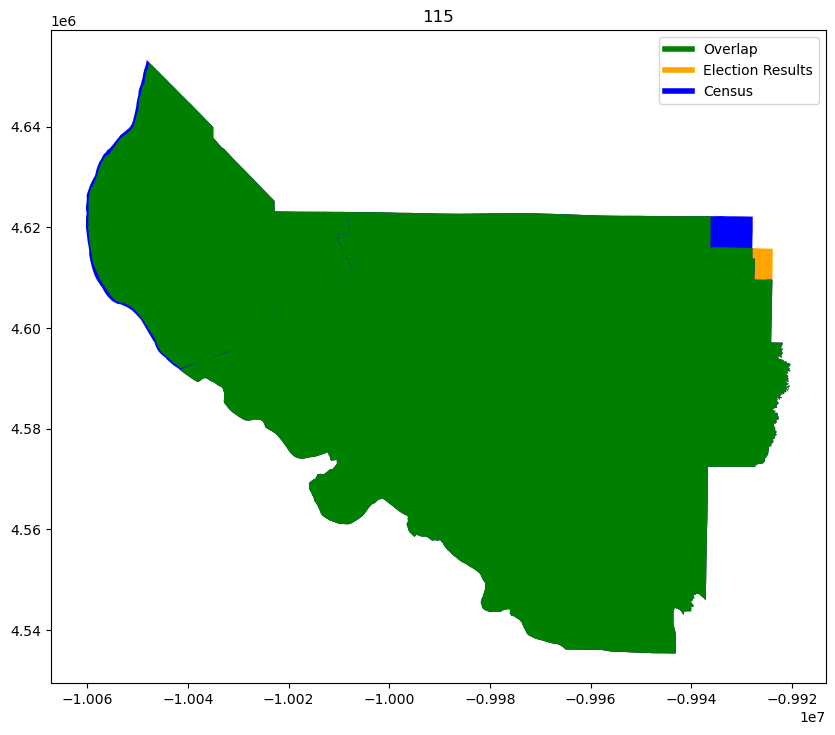

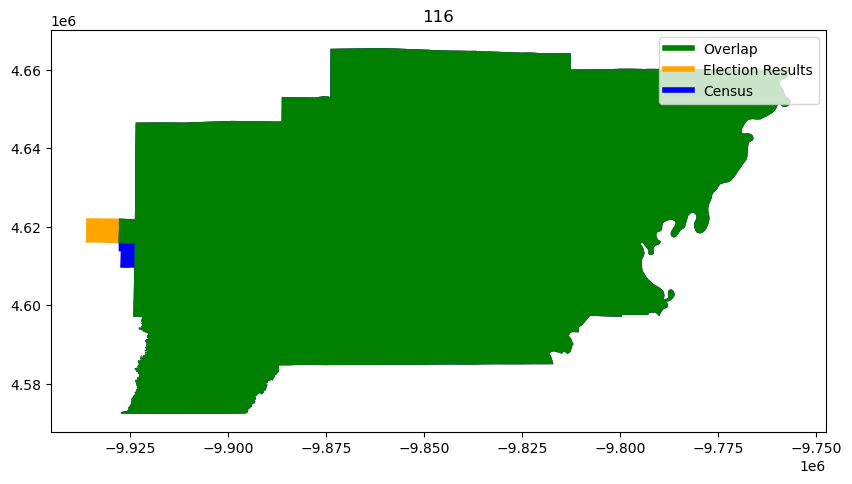

In [307]:
pber.compare_geometries(filtered_sldl_results, il_sldl_districts ,"Election Results", "Census", "SLDL_DIST","districts",area_threshold=1)


Checking 59 districts for differences of greater than 1 km^2

1) For 01 difference in area is 3.5317044805703355
2) For 03 difference in area is 1.0004568863964667
3) For 04 difference in area is 3.5875500470160917
4) For 08 difference in area is 1.749530095816421
5) For 10 difference in area is 6.248148015184135
6) For 11 difference in area is 6.3541431897016025
7) For 12 difference in area is 1.5924438663188378
8) For 13 difference in area is 2.7324136969987767
9) For 14 difference in area is 2.893602922117073
10) For 15 difference in area is 13.075052042691409
11) For 16 difference in area is 4.944954034171451
12) For 17 difference in area is 7.098430698014951
13) For 18 difference in area is 3.0033685754552804
14) For 19 difference in area is 2.543320985875069
15) For 26 difference in area is 4.623063782328307
16) For 28 difference in area is 1.7424665985214278
17) For 31 difference in area is 5.071407796569374
18) For 32 difference in area is 1.3979500962748013
19) For 34 differen

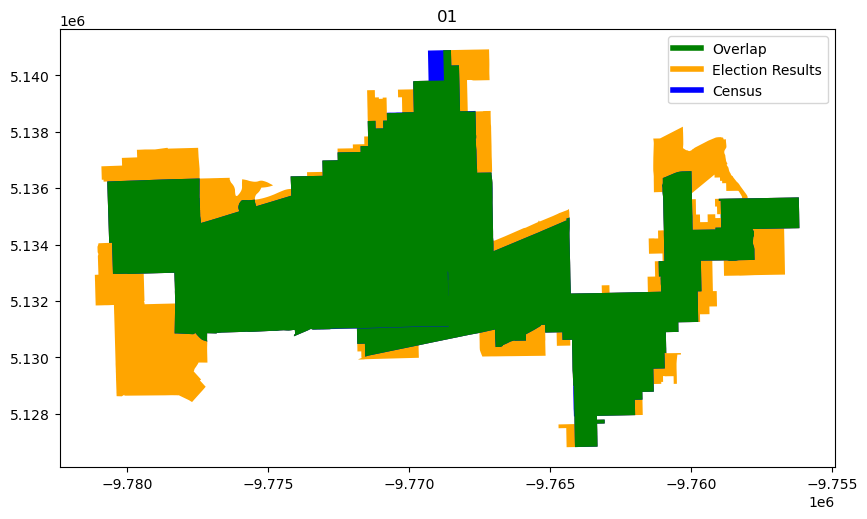

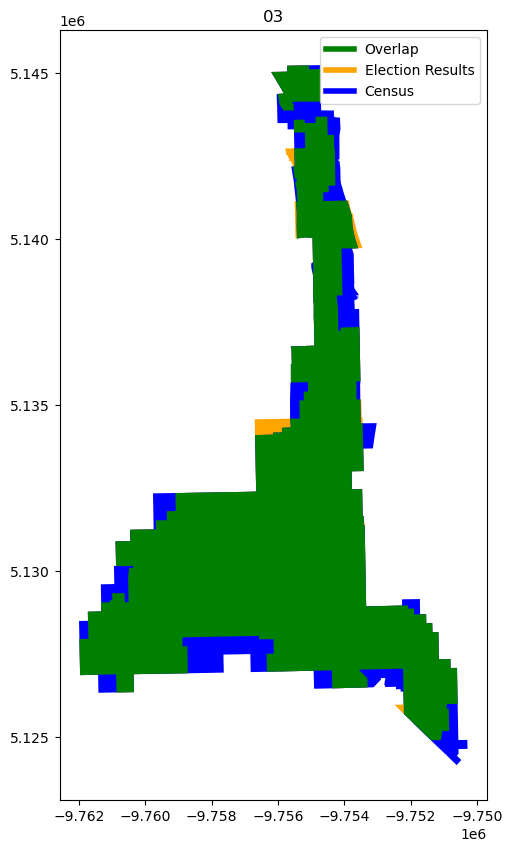

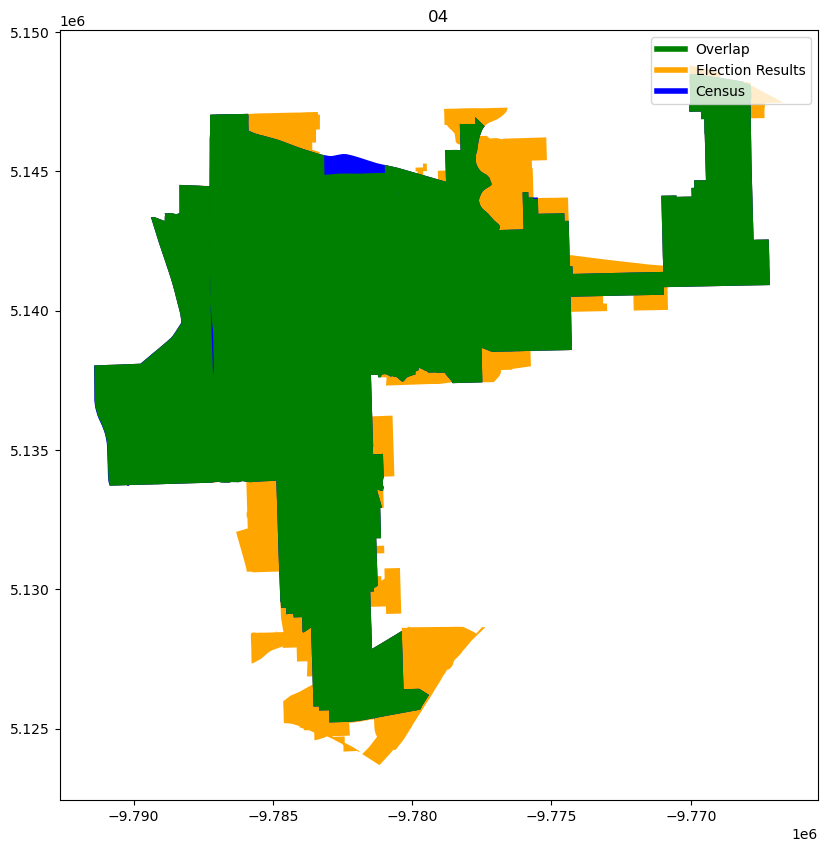

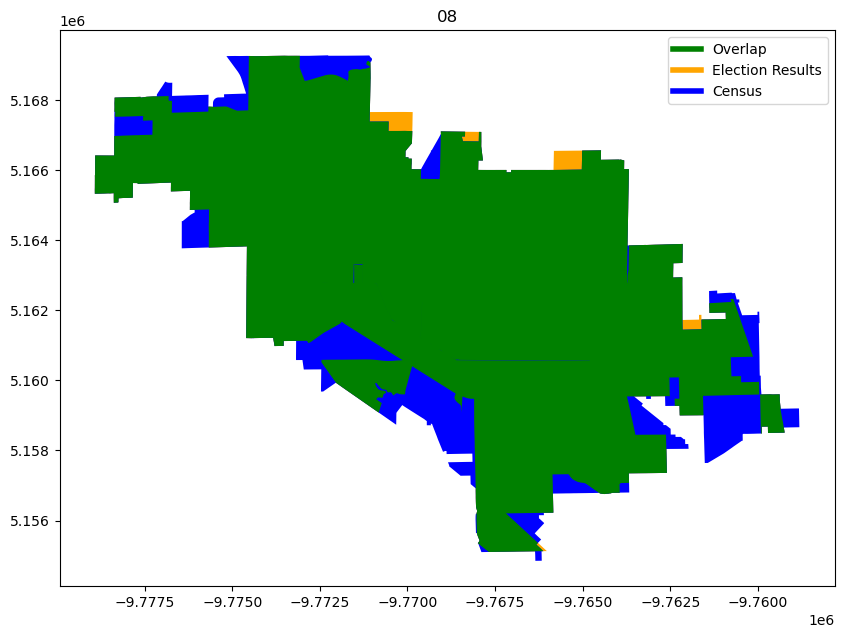

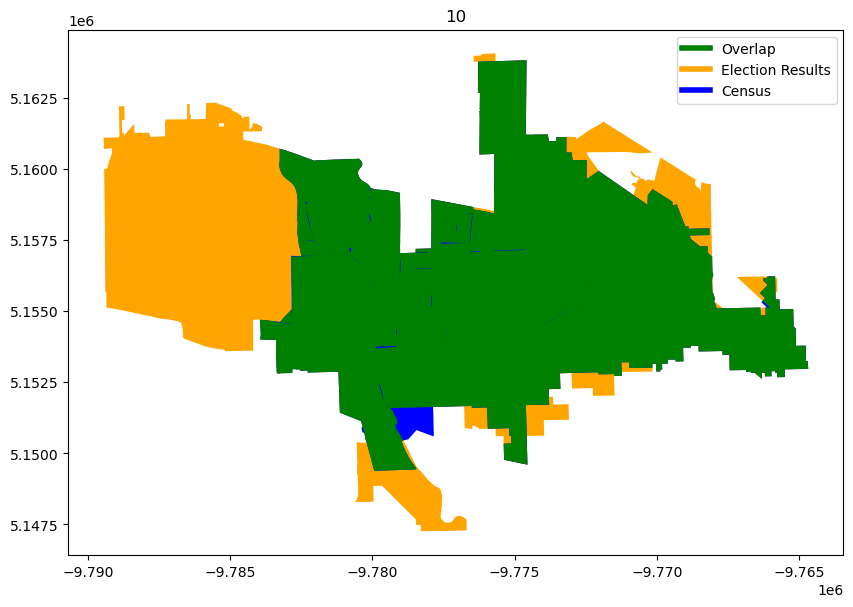

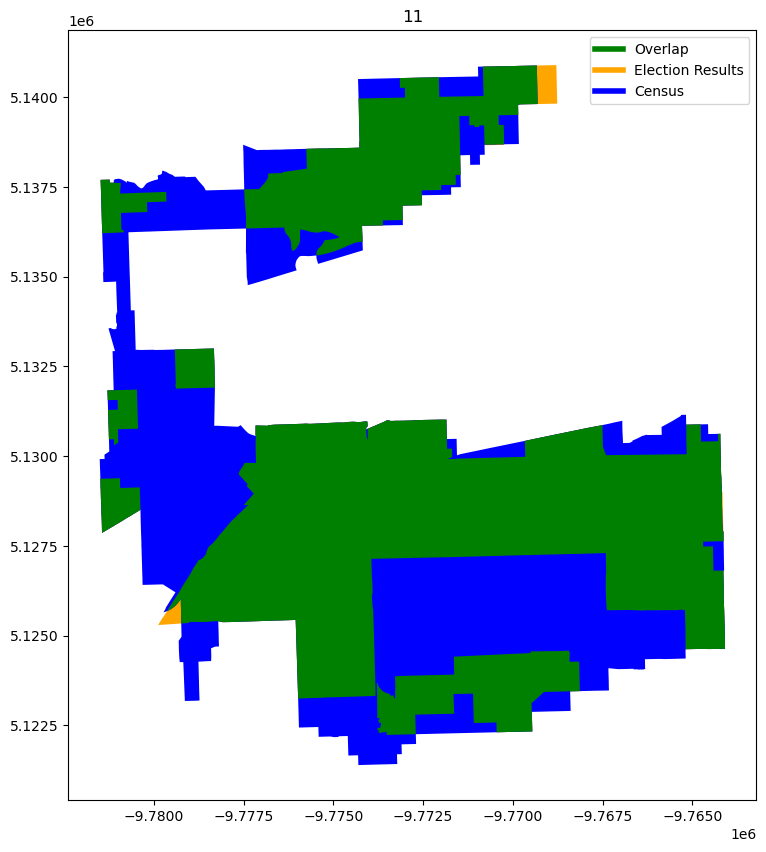

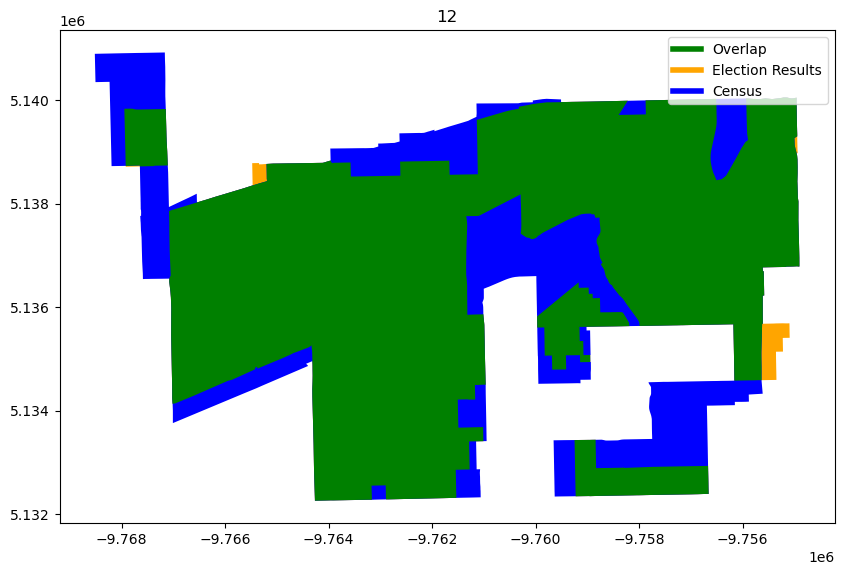

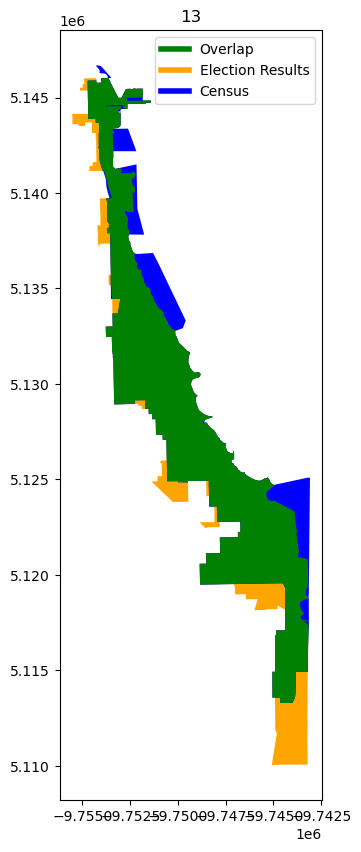

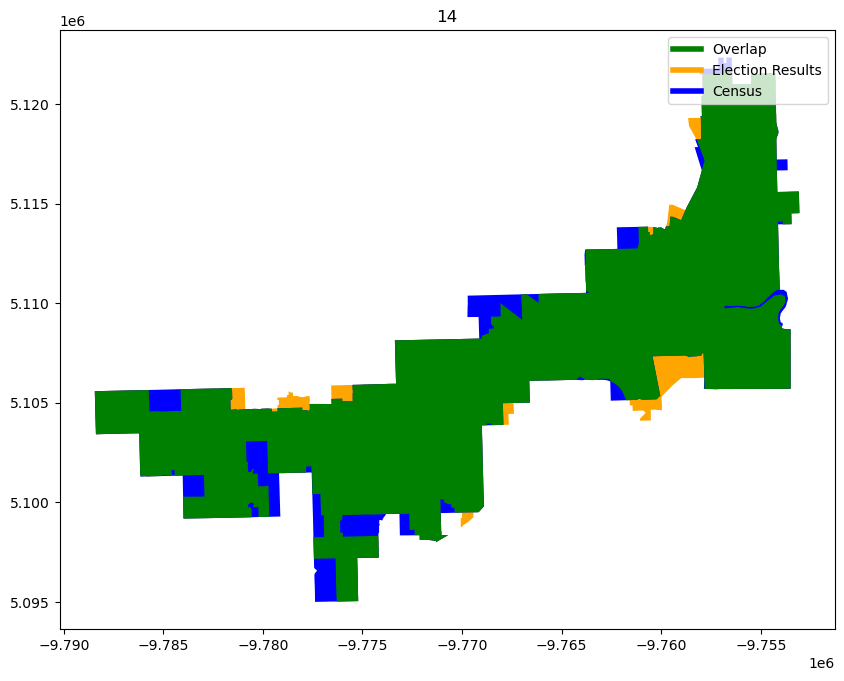

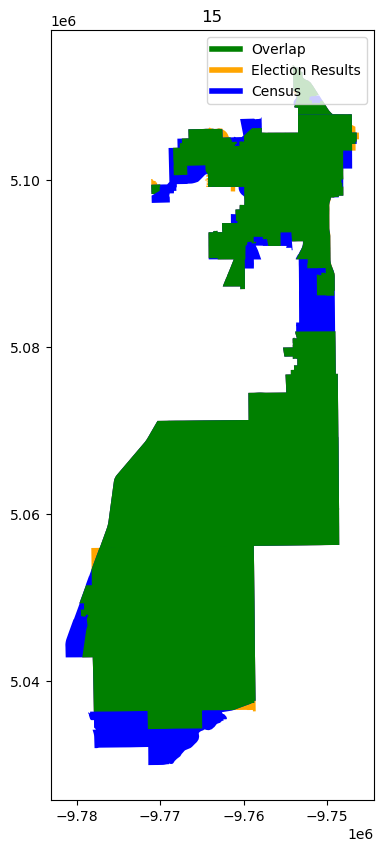

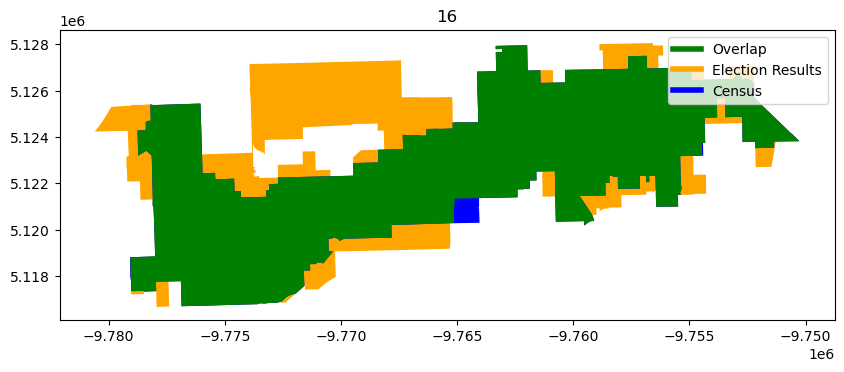

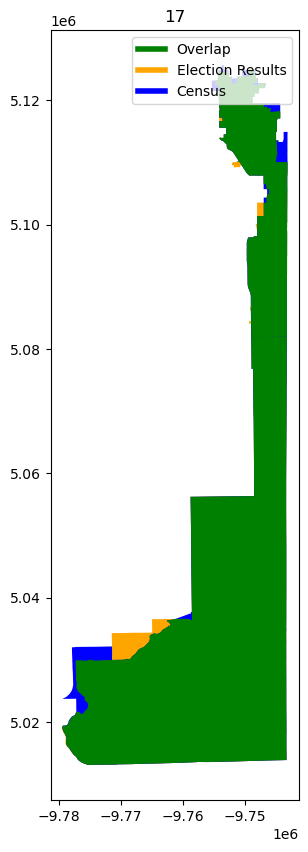

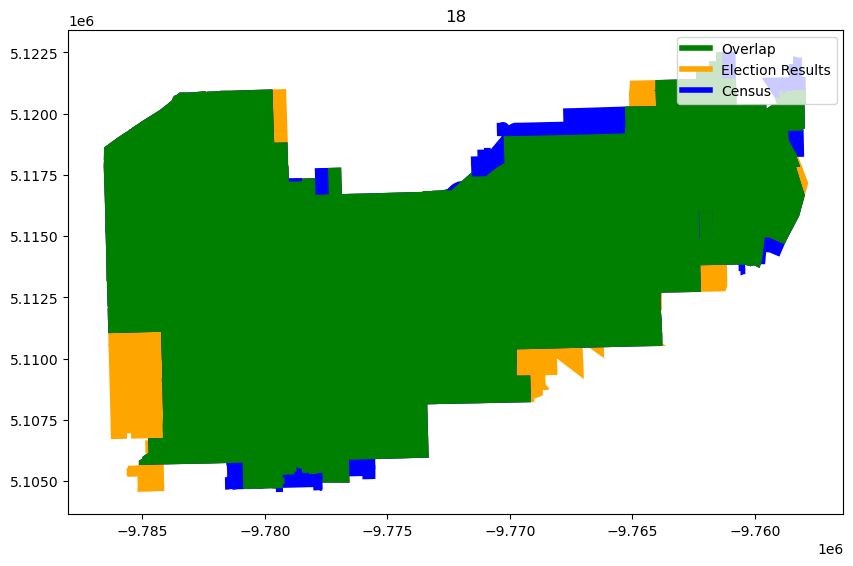

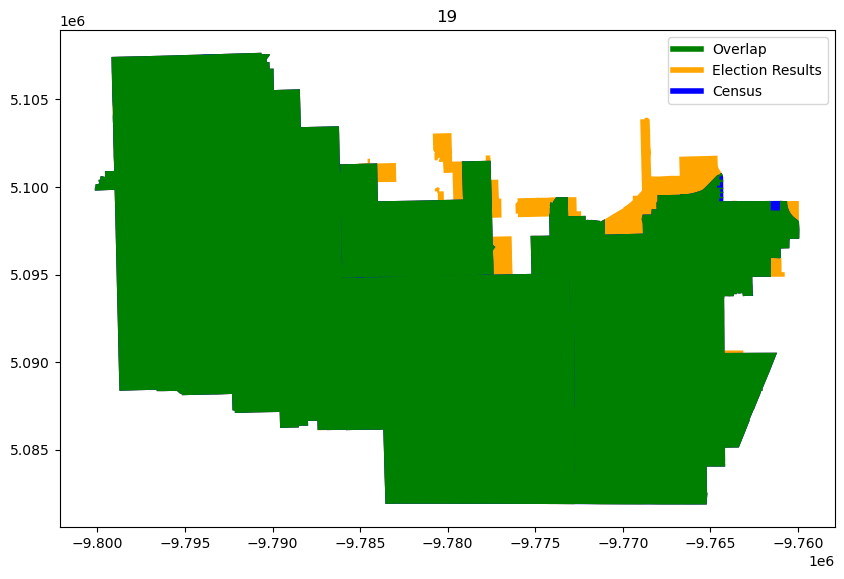

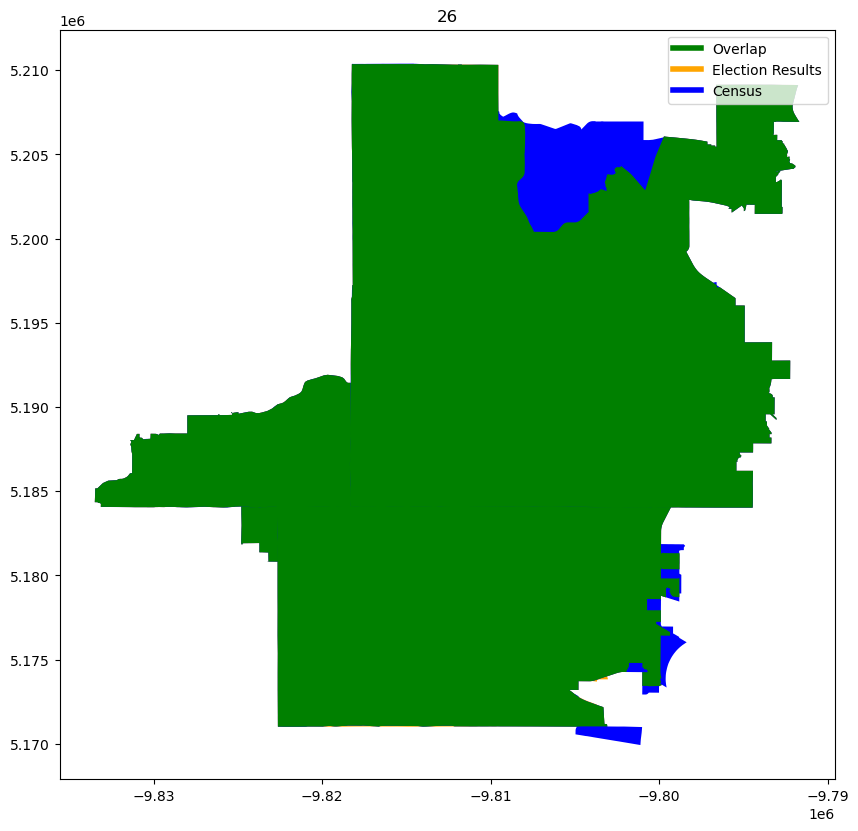

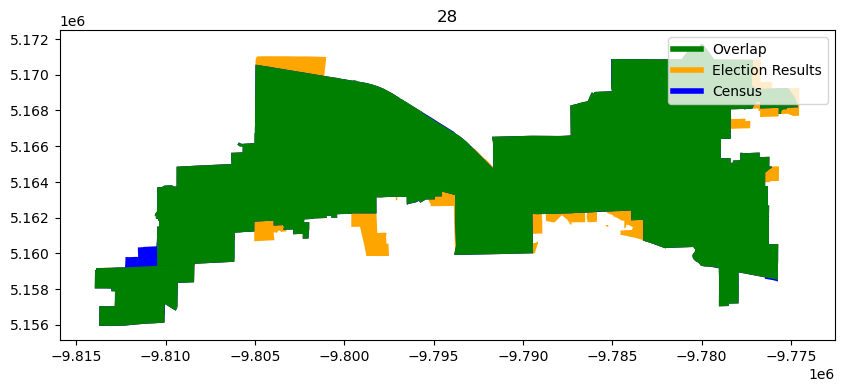

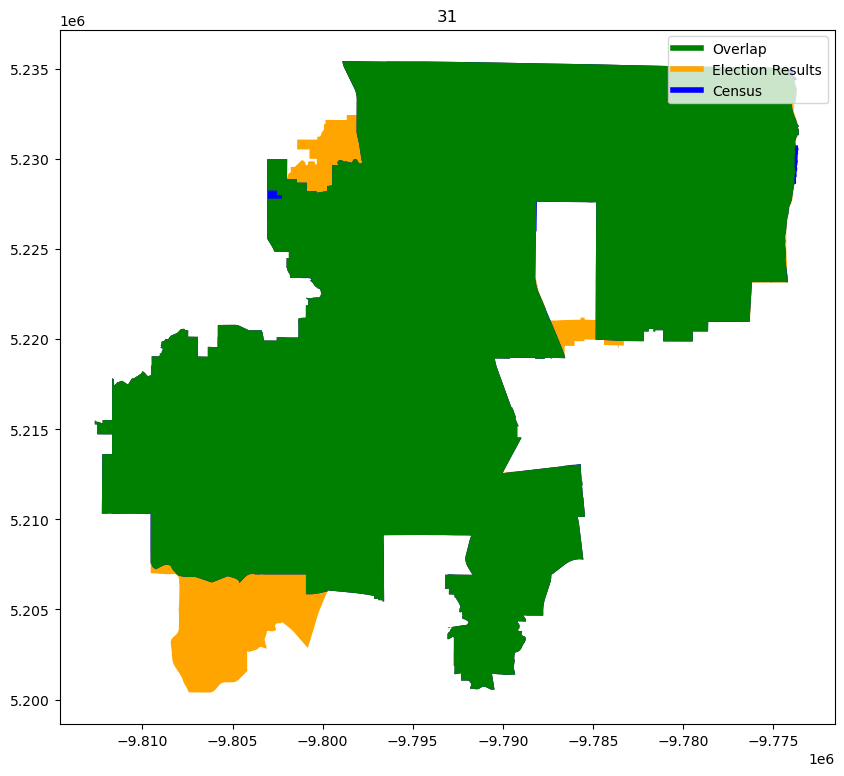

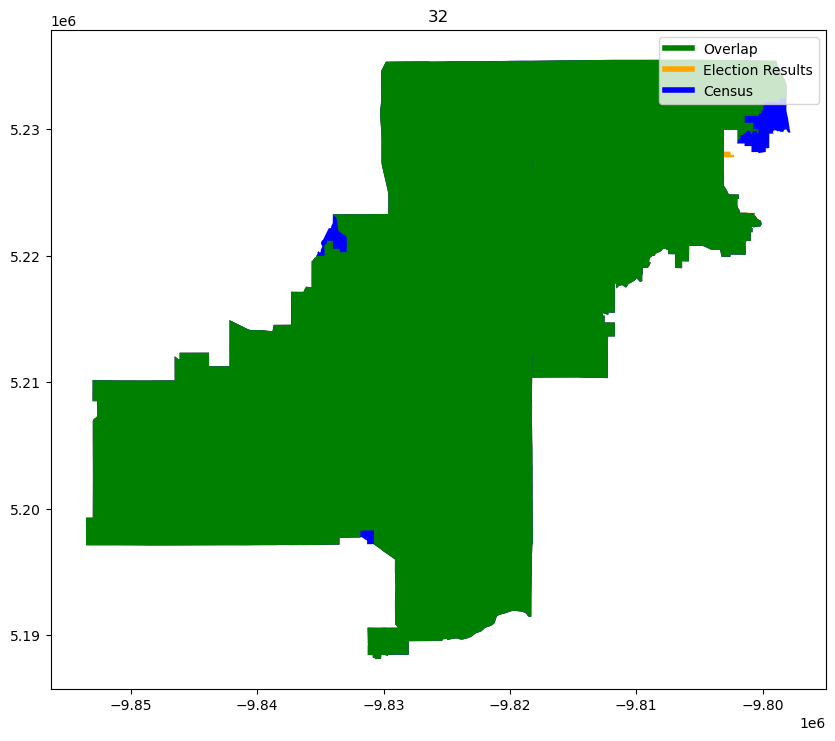

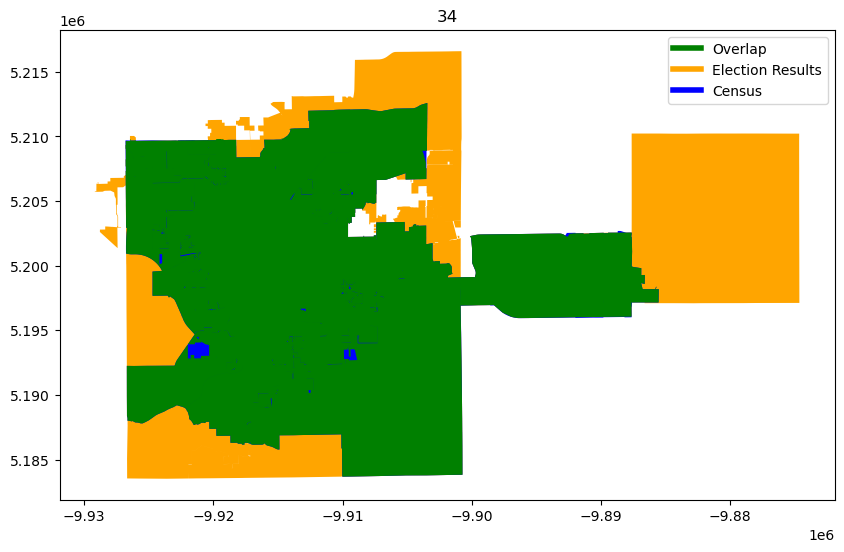

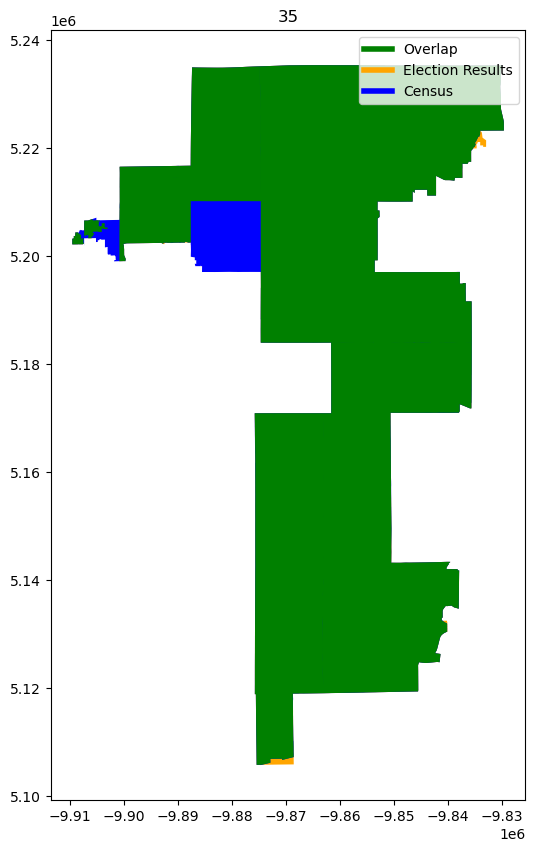

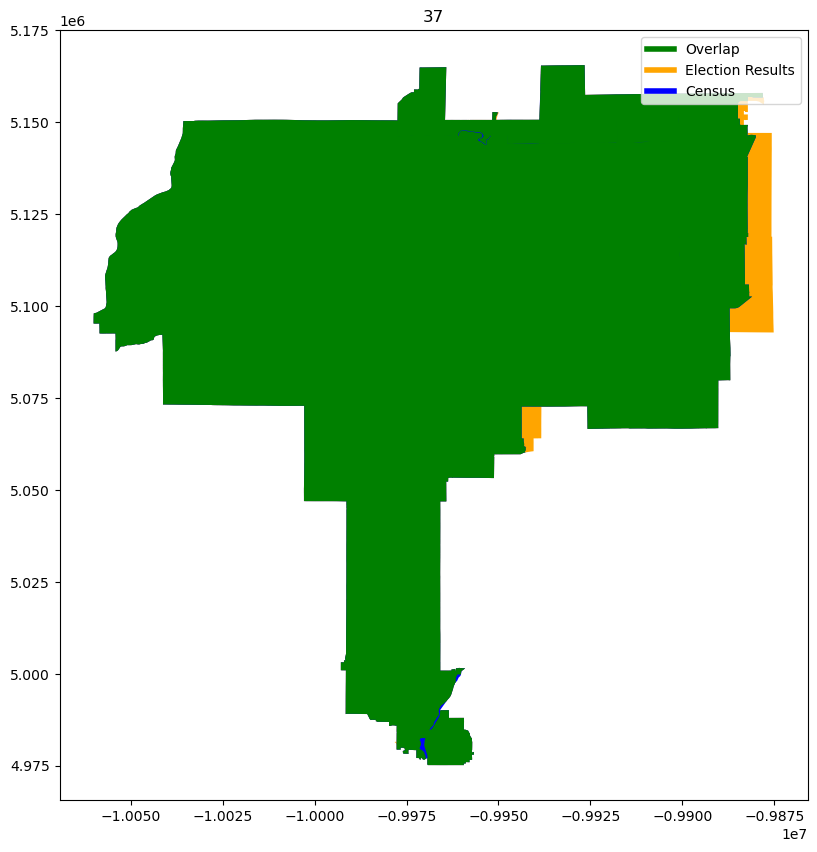

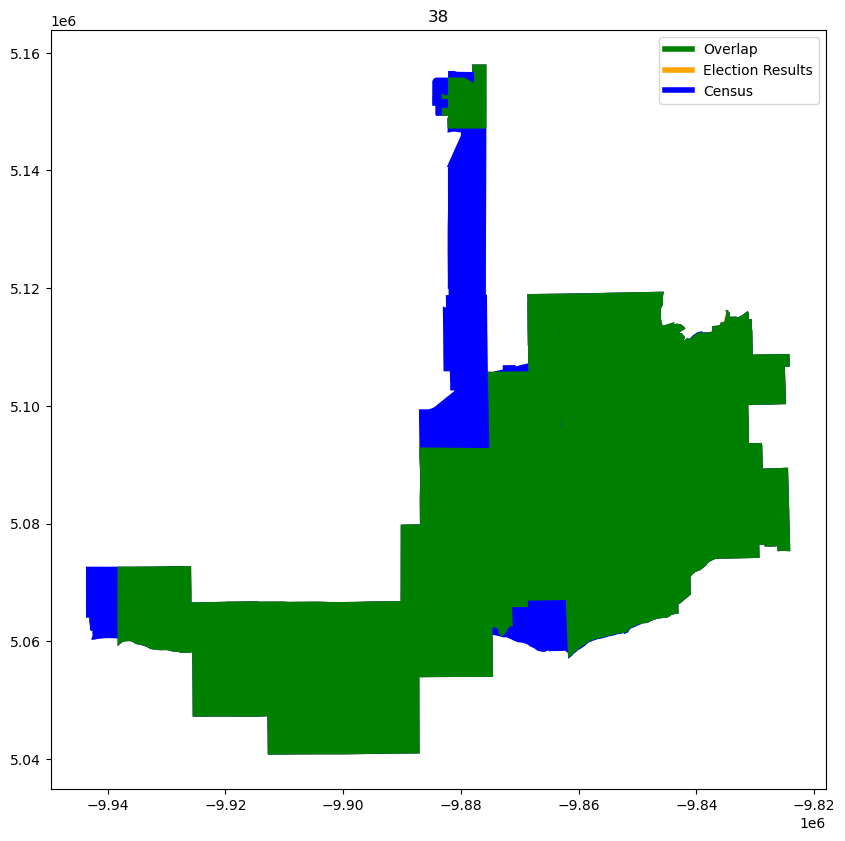

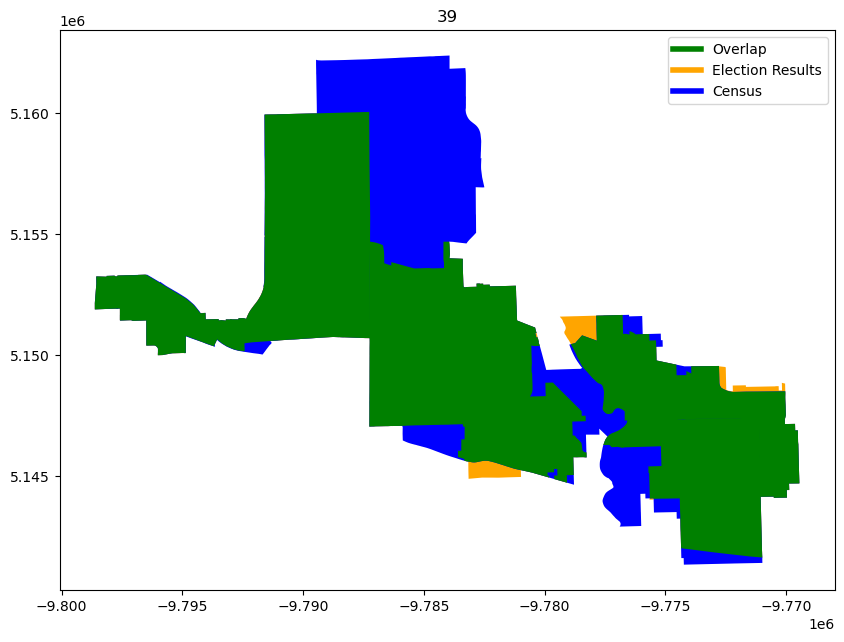

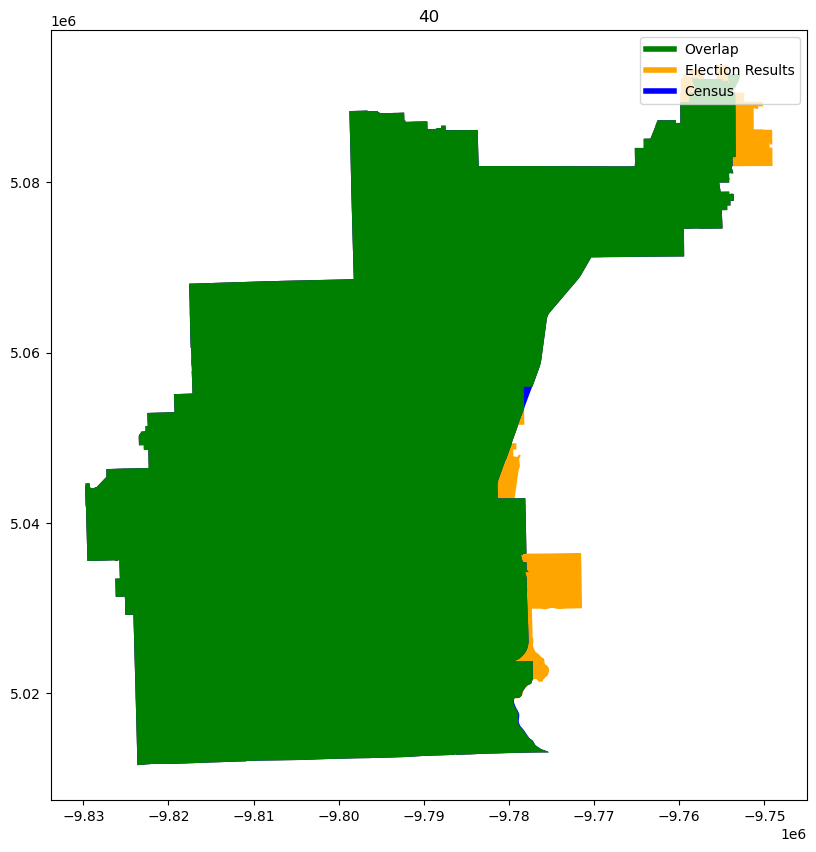

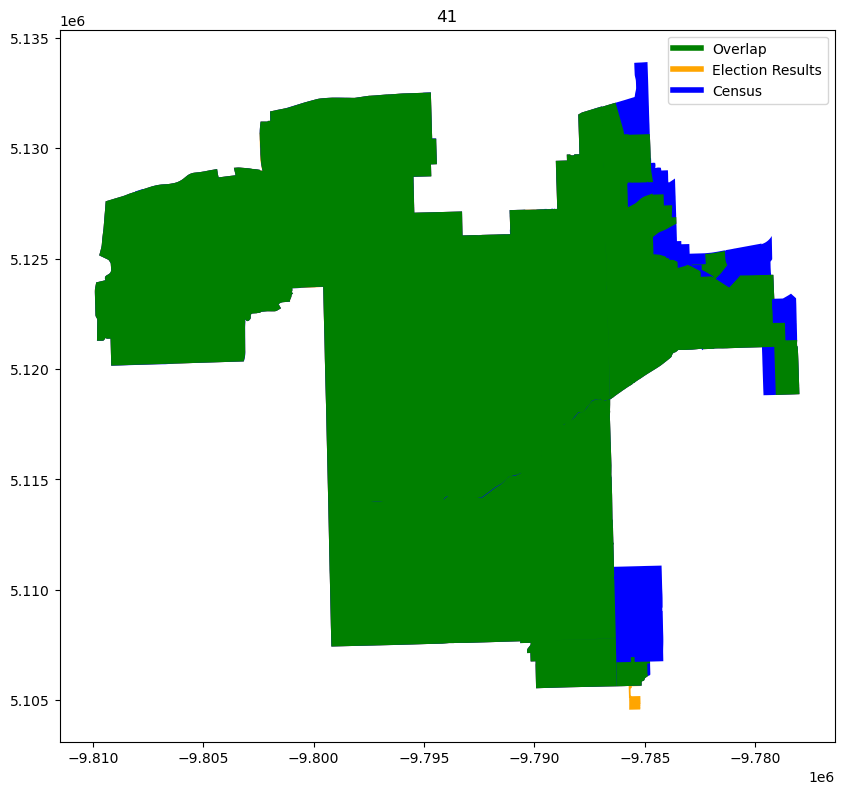

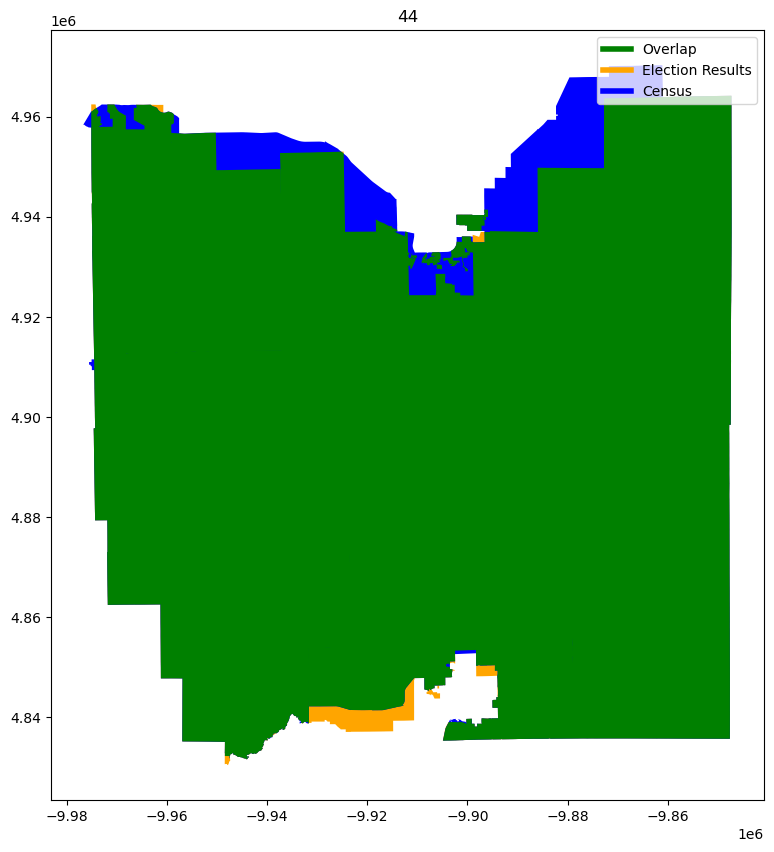

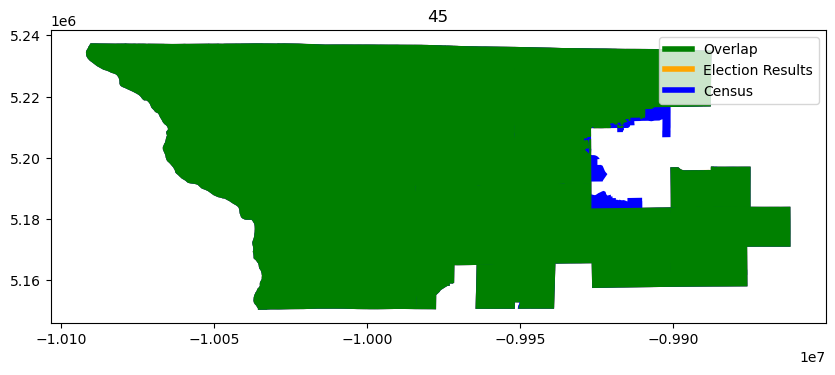

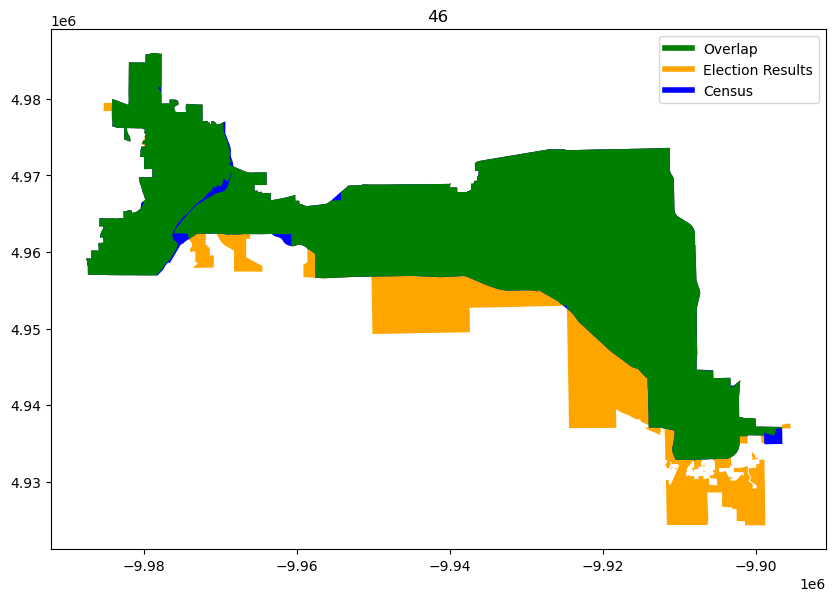

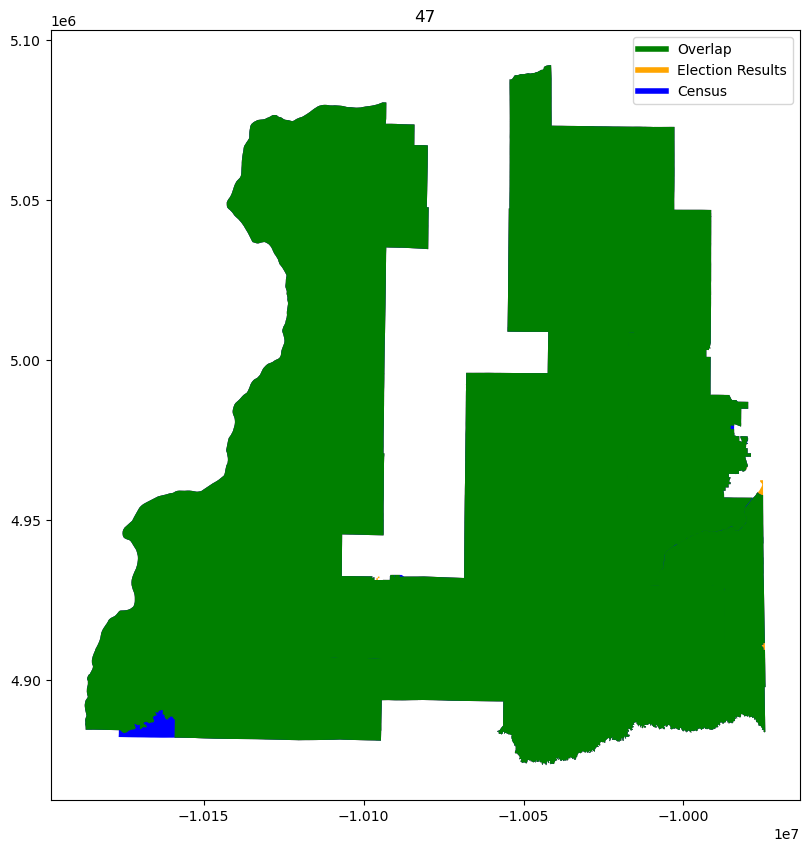

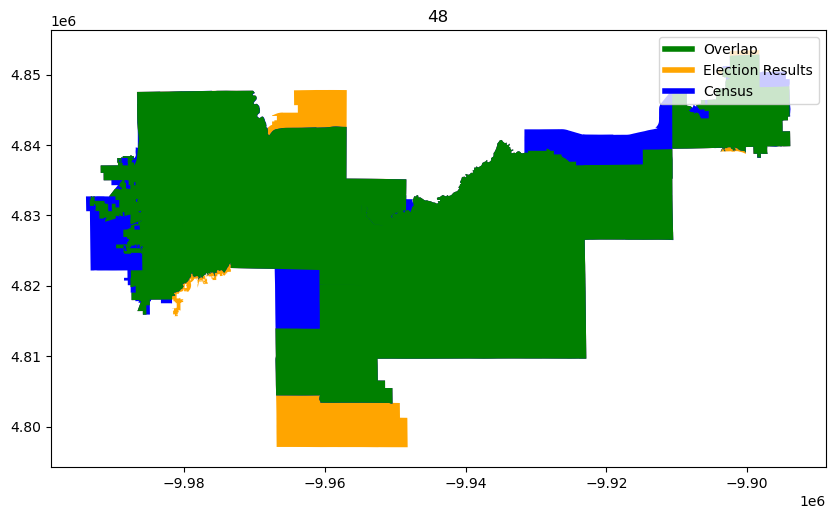

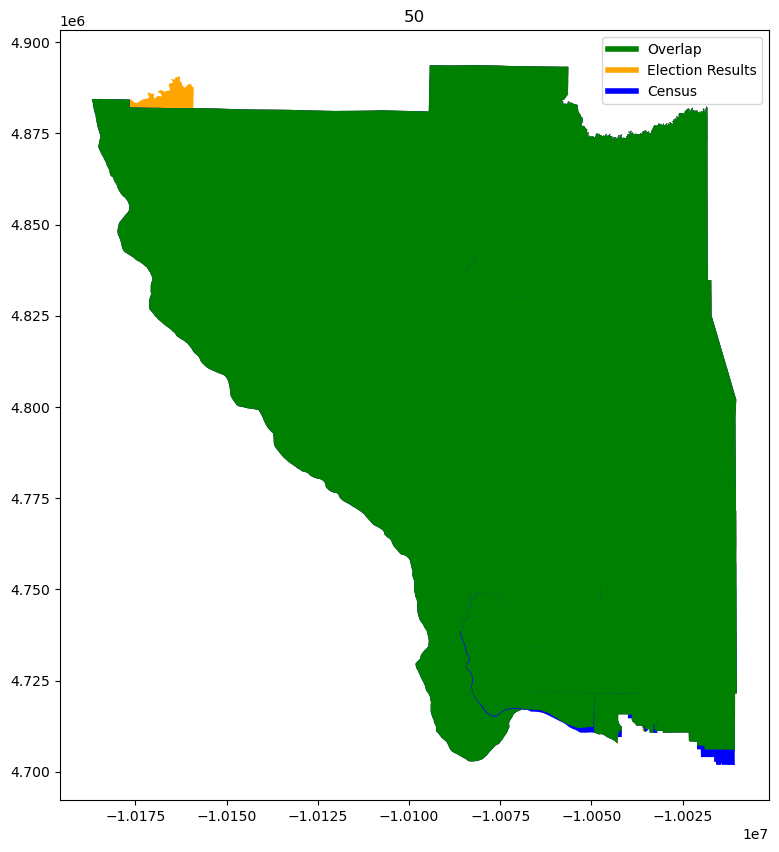

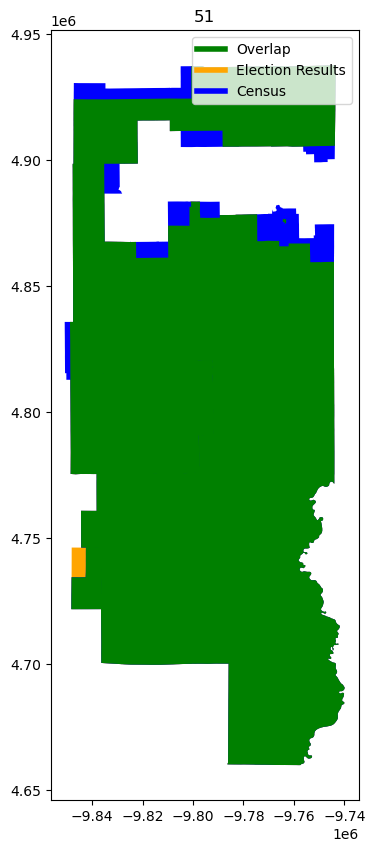

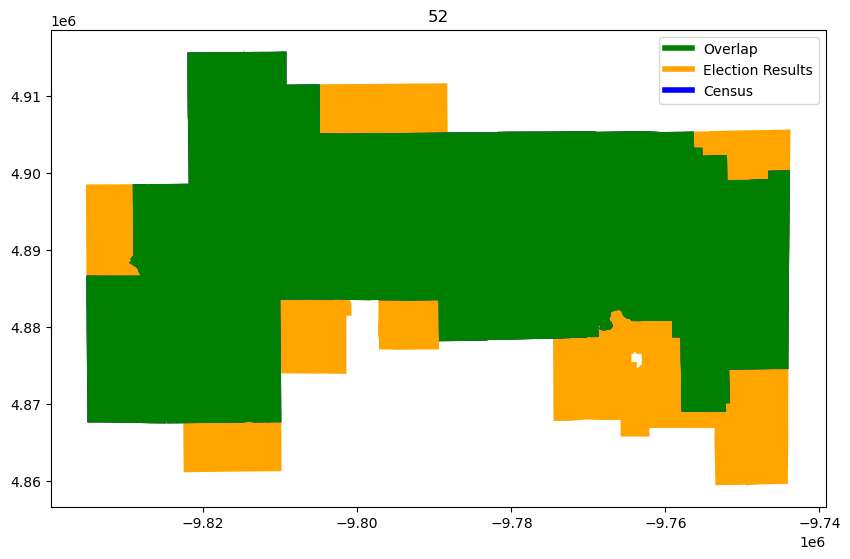

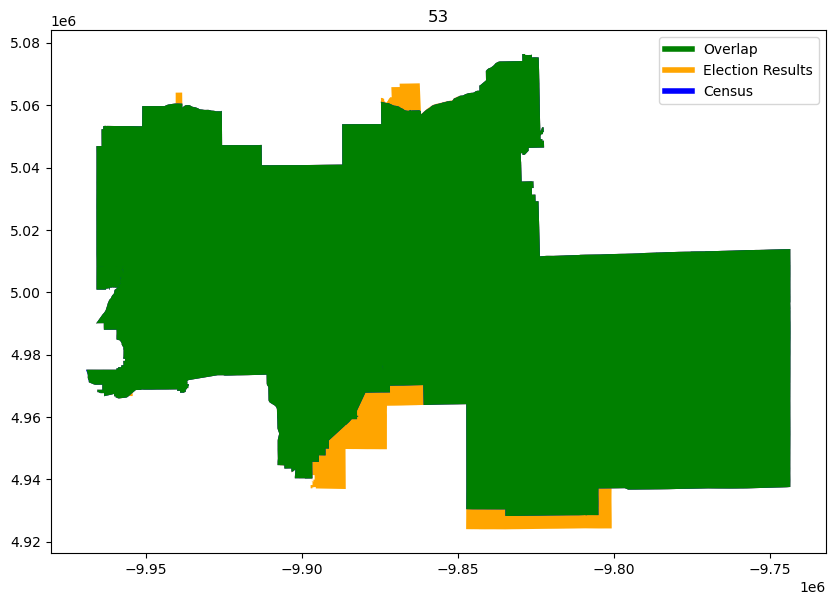

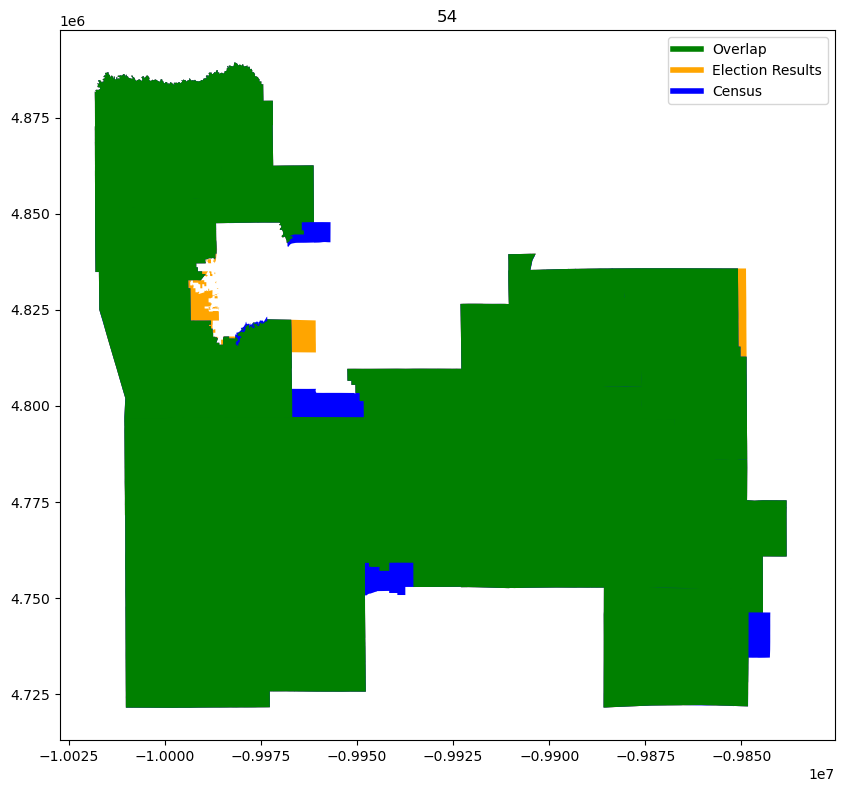

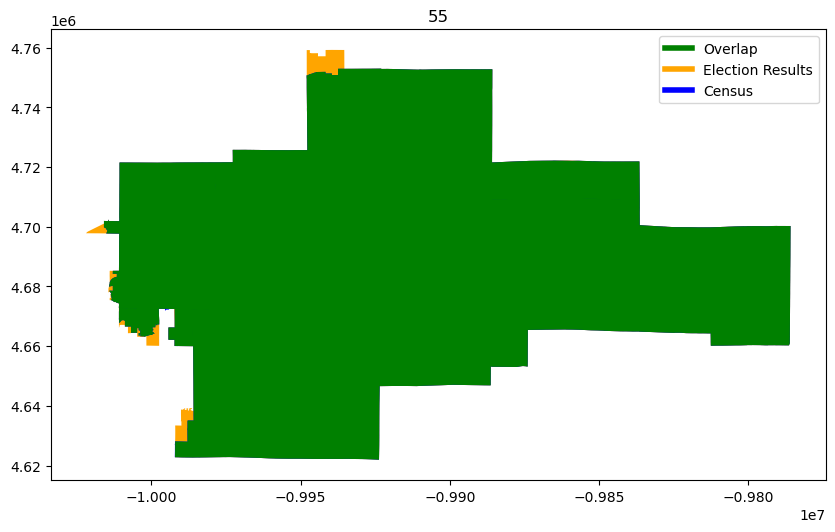

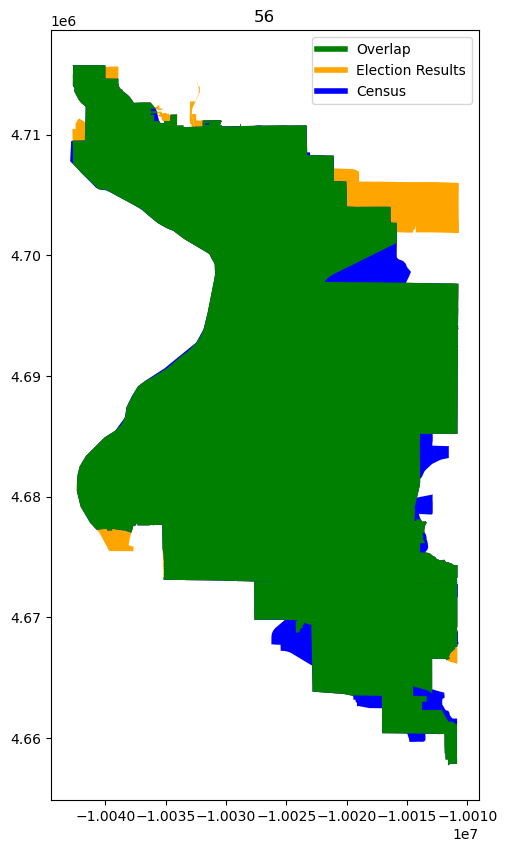

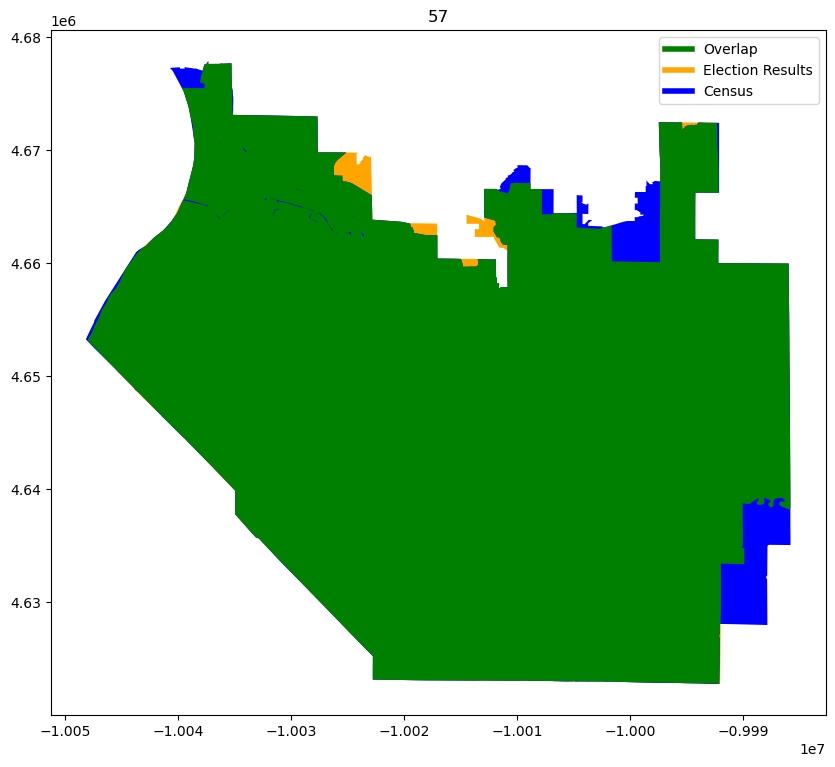

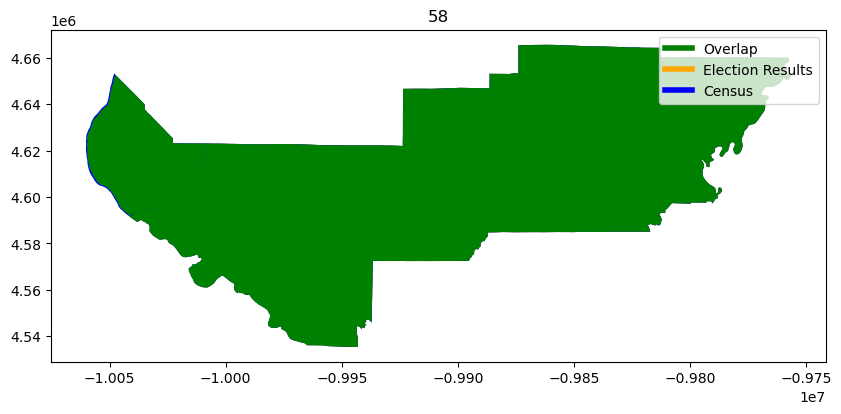

In [308]:
pber.compare_geometries(filtered_sldu_results, il_sldu_districts ,"Election Results", "Census", "SLDU_DIST","districts",area_threshold=1)


<!-- CLARKE (SWAP), DALLAS (SWAP), WASHINGTON (SWAP) -->

In [309]:
## Final File Cleaning and Export File

if not os.path.exists("./il_2024_gen_prec"):
    os.mkdir("./il_2024_gen_prec/")
    
if not os.path.exists("./il_2024_gen_prec/il_2024_gen_cong_prec"):
    os.mkdir("./il_2024_gen_prec/il_2024_gen_cong_prec")
if not os.path.exists("./il_2024_gen_prec/il_2024_gen_sldl_prec"):
    os.mkdir("./il_2024_gen_prec/il_2024_gen_sldl_prec")
if not os.path.exists("./il_2024_gen_prec/il_2024_gen_sldu_prec"):
    os.mkdir("./il_2024_gen_prec/il_2024_gen_sldu_prec")
if not os.path.exists("./il_2024_gen_prec/il_2024_gen_all_prec"):
    os.mkdir("./il_2024_gen_prec/il_2024_gen_all_prec")
    





In [310]:
column_c = il_24_sldl_prec.pop('SLDL_DIST')
il_24_sldl_prec.insert(5, 'SLDL_DIST', column_c)

column_c = il_24_cong_prec.pop('CONG_DIST')
il_24_cong_prec.insert(5, 'CONG_DIST', column_c)

column_c = il_24_sldu_prec.pop('SLDU_DIST')
il_24_sldu_prec.insert(5, 'SLDU_DIST', column_c)

column_c = il_elec_prec_pre_splits.pop('COUNTYFP')
il_elec_prec_pre_splits.insert(1, 'COUNTYFP', column_c)




In [311]:
il_elec_prec_pre_splits.to_file("./il_2024_gen_prec/il_2024_gen_all_prec/il_2024_gen_all_prec.shp")
il_24_cong_prec.to_file("./il_2024_gen_prec/il_2024_gen_cong_prec/il_2024_gen_cong_prec.shp")
il_24_sldl_prec.to_file("./il_2024_gen_prec/il_2024_gen_sldl_prec/il_2024_gen_sldl_prec.shp")
il_24_sldu_prec.to_file("./il_2024_gen_prec/il_2024_gen_sldu_prec/il_2024_gen_sldu_prec.shp")

In [318]:
il_24_sldu_prec

,UNIQUE_ID,COUNTYFP,JurisName,Precinct,County,SLDU_DIST,GSU01DCER,GSU04DLIG,GSU04RSUM,GSU05DCOL,...,GSU46DKOE,GSU46ROWE,GSU49DCAP,GSU49RDEA,GSU52DFAR,GSU52RBRO,GSU53RBAL,GSU55RPLU,GSU58RBRY,geometry
0,BUREAU-:-ARISPIE-(SLDU-37),011,BUREAU,ARISPIE,BUREAU,37,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"MULTIPOLYGON (((-89.50992 41.25557, -89.50991 ..."
1,BUREAU-:-ARISPIE-(SLDU-53),011,BUREAU,ARISPIE,BUREAU,53,0,0,0,0,...,0,0,0,0,0,0,68,0,0,"MULTIPOLYGON (((-89.39337 41.27053, -89.39341 ..."
2,BUREAU-:-SELBY 2-(SLDU-37),011,BUREAU,SELBY 2,BUREAU,37,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"POLYGON ((-89.39274 41.33560, -89.39269 41.339..."
3,BUREAU-:-SELBY 2-(SLDU-53),011,BUREAU,SELBY 2,BUREAU,53,0,0,0,0,...,0,0,0,0,0,0,18,0,0,"MULTIPOLYGON (((-89.39270 41.32043, -89.39266 ..."
4,CITY OF CHICAGO-:-WARD 14 PRECINCT 01-(SLDU-01),031,CITY OF CHICAGO,Ward 14 Precinct 01,COOK,01,382,0,0,0,...,0,0,0,0,0,0,0,0,0,"MULTIPOLYGON (((-87.71026 41.77249, -87.71026 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8704,WOODFORD-:-WORTH 3,203,WOODFORD,WORTH 3,WOODFORD,37,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"POLYGON ((-89.46696 40.77673, -89.46696 40.777..."
8705,WOODFORD-:-WORTH 4,203,WOODFORD,WORTH 4,WOODFORD,37,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"POLYGON ((-89.48612 40.79125, -89.48579 40.791..."
8706,WOODFORD-:-WORTH 5,203,WOODFORD,WORTH 5,WOODFORD,37,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"POLYGON ((-89.48593 40.78603, -89.48545 40.785..."
8707,WOODFORD-:-WORTH 6,203,WOODFORD,WORTH 6,WOODFORD,37,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"POLYGON ((-89.48597 40.76208, -89.48598 40.762..."


In [ ]:
raw_totals = pd.read_csv("./raw-from-source/il_2024_gen_prec_csv/il_2024_gen_prec_csv.csv")

In [319]:
import shutil

In [320]:
shutil.make_archive("./il_2024_gen_prec","zip","./il_2024_gen_prec")

'/Users/peterhorton/Documents/RDH/pber_local/IL_2024/il_2024_gen_prec.zip'